## Changed notebook — implementation of the external review (43 items)

`changed.ipynb` = `qkd-finaldraft.ipynb` + the fixes from *QKD ML Errors, Improvements and Fixes*. **Scope banner (B10 / F-items):**
this is a **simulation study** of detectability of three attack families under a GYS fibre model; it is **not** a security proof and it
makes no claim about adaptive/optimal eavesdroppers. All statements about "detectable" are conditional on the stated attack set.

**Status of the review items** (I = implemented in code, P = partially, N = not implemented, with reason):

| Group | Items | Status |
|---|---|---|
| A reproducibility | A1 manifest, A2 fingerprinted caches, A3/A5 seeds & per-run metadata, A4 requirements-lock.txt | I |
| B physics | B2-B6, B8 (per-link commissioning z-scores), B9 (burst sweep) | I / P |
| B physics | **B1** adaptive/optimal attacks, **B7** afterpulsing & dead time | **N** (new physics models, outside a patch-level change) |
| C dataset design | C1 sigma_K, C2 equal-information truncation to exactly K, C3-C6 | I / P |
| D statistics | D1-D9 (CP FPR bound, raw importance, held-out SHAP, 20 seeds, Bonferroni, CTRL-matched baseline) | I / P |
| D10 | pre-registration note (below) | I |
| E ML/DL | E4, E7, E8 | I; **E1/E2/E3/E5** (per-protocol scaling, projection, adversary probe, per-fraction validation) **N** - need GPU re-runs to validate |
| F reporting | F1-F4 text fixes | P |

**Testing actually done:** every code cell parses; BB84 truncation to exactly K key bits and the per-link z-score feature, `generate_datasets` (tiny scale) and `session_split` were smoke-tested. **The full notebook was NOT re-executed** (the DL, SHAP, importance, bootstrap and E91/BKM07 changes are untested), and outputs of modified cells were cleared. Run *Restart & Run All* before trusting any number. Status letters mean *implemented in code*, not *validated*.

---
### Audit pass (latest commit) -- what changed, what did not

**Physics: unchanged.** Every simulator, channel model, attack model and feature definition is exactly as before. The audit (Section 25, new) verifies
them against independent calculations (closed forms, an exact branch-enumerating BKM07 calculator, Werner-state algebra) and lists the model simplifications
it found but deliberately left alone.

**Bugs fixed** (found by actually executing the notebook, which had never been re-run after the review edits):
* `nuisance_only_audit` called `make_boosted` before Section 8 defined it -> `NameError` on a fresh *Restart & Run All* (factory moved to the utilities cell).
* L-7 shuffled-label control returned `nan` when a shuffled test fold held a single class.
* Deep-SVDD zero-day evaluation crashed on an empty split (now a NaN AUC).

**ML features now feed the deep-learning models of Section 24.** Every architecture (MLP, 1D-CNN, BiLSTM+attention, Transformer) exists as *sequence only* and `+feat`
(the same network with the Section 3 engineered feature vector concatenated to its embedding, exactly what Section 18's `CrossProtocolDetector` already did through `x_classical`),
next to the boosted-tree baseline on the same sessions and split.

**More data, seeds and runs, for ML and DL, all three protocols** (all knobs are plain constants; dataset generation is now parallel with identical numbers):

| What | before | now |
|---|---|---|
| BB84 / BKM07 main datasets (runs per class) | 300 | 600 |
| E91 main dataset (runs per mode) | 300 | 600 |
| `N_REPEATS` (ablation / CI repeats) | 20 | 50 |
| Section 16 N x W grid (runs per class) | 100 | 200 |
| Section 18 DL sessions per class | 100 | 200 |
| Section 18 transfer seeds / grouped-CV seeds / zero-day seeds | 5 / 3 / 3 | 8 / 5 / 5 |
| Sections 19, 19b, 21 runs per class | 30 / 30 / 25-40 | 100 / 100 / 80-100 |
| CUSUM repeats | 20 | 50 |
| Section 24 sweep (honest + attacked runs per cell) | 100 + 40 | 300 + 150 |
| Section 24 noise robustness (train / test runs) | 30 / 40 | 60 / 100 |
| Section 24 temporal test (honest + attacked) | 100 + 60 | 300 + 150 |
| Section 24 DL sessions per protocol | 150 + 150 | 400 + 400 |
| Section 24 DL seeds | 1 | 5 (different session split and weight init each) |

**Not re-executed end to end.** The full notebook at this scale takes many hours (Section 18 dominates). A quick smoke configuration (`run_quick_test.py`) runs the same code at tiny scale to prove nothing crashes;
**saved outputs of older cells are stale -- run *Restart & Run All* (or `python changed.py`) before quoting any number.**


# QKD Eavesdropping Detection with Machine Learning  — FINAL DRAFT 

**Title:** Eavesdropping Detection in BB84 (Fully Quantum),BKM07 (Semi-Quantum) & E91(Entanglement) Quantum Key Distribution Protocols in noisy environment

---

## Background

In Quantum Key Distribution (QKD) , traditionally  **Alice** and **Bob** share a secret cryptographic key. This key can be  eavesdropped by **Eve** which inevitably disturbs the channel and gets detected. In practical implemention there is a presence of noise introduced by various sources, this distrubs the detection of eavesdropping attacks.

This code implements eavesdropping detection:

1. We **simulate** photon-by-photon runs of three QKD protocols (BB84 , BKM07 and E91) under various attack scenarios and noise models.
2. We **extract statistical features** from each simulated run, like error rates, their variance over time, and spectral properties.
3. We **train and compare six ML classifiers and a multi protocol DL model with anaomaly feedback correction** to distinguish "secure channel" from "Eve is present."
4. We **tune** those models with 5-fold cross-validation and plot ROC curves + feature importances.

### The three protocols

| Protocol | Type | Key idea |
|---|---|---|
| **BB84** (Bennett & Brassard, 1984) | Fully quantum | Alice sends single photons in one of two bases; Eve's intercept forces a random re-preparation, causing detectable errors |
| **BKM07** (Boyer–Kenigsberg–Mor, 2007) | Semi-quantum | Bob is "classical" — he can only measure in the Z-basis or reflect. Eve must attack both the forward and return legs to learn anything |
| **E91** (Arthur Ekert, 1991) | Entanglement based | Uses Quantum Entanglement and bell's theorem to securely generate a shared encryption key using Singlet state while instantly exposing any eavesdropper |



---
## Section 0 — Setup & Imports

We use:
- **NumPy / Matplotlib** for numerics and plotting
- **scikit-learn** for all ML models, pipelines, scaling, and evaluation
- **XGBoost** 

Run the cell below to install any missing packages, then import everything.


---
## 📋 Draft 2 — Change Log

This notebook is a fork of `Quantumkey_Draft.ipynb`, built to act on a full review round: 4 correctness
bugs, the supervisor's 4 core feedback points (T1-T4), 6 supervisor suggestions (S1-S6), and a
from-scratch redesign of the deep-learning section (which failed in Draft 1 due to input starvation).

**Every change is marked inline** where it happens, using one of two callout styles so you can scan the
notebook top-to-bottom and see exactly what changed and why, without reading a separate diff:

> 🔧 **CHANGED (Draft 2, item N): <what>** — an existing Draft-1 cell/behaviour was modified.

> ✨ **NEW (Draft 2, item N): <what>** — an entirely new cell/section not present in Draft 1.

The item numbers match the review list below (36 items total).

| # | Change | Why |
|---|---|---|
| 1 | Fix E2 generalisation test | reused the same 300 clean runs in train + test |
| 2 | Group-aware (paired-run) splits | random splits let channel-matched "twin" runs leak across train/test |
| 3 | Leakage audit on BKM07 | was run on BB84/E91 only |
| 4 | Fix E91 `spectral_entropy` window-count doc/code mismatch | comment said NaN below 64 windows; E91 uses 32 |
| 5 | Sample-size limitation paragraph | AUC differences between protocols partly reflect data volume |
| 6 | AUC-vs-key-rounds plot | makes the sample-size confound visible, not just stated |
| 7 | Vectorised BKM07 simulator | was a ~40x-slower-per-pulse Python loop; blocks everything below that needs big BKM07 runs |
| 8 | Equal-information datasets (simulate-until-K-key-rounds) | the real fix for the T1 sample-size confound |
| 9 | Section 19 rebuilt to match K as well as QBER | previously matched error rate only |
| 10 | E91 secure key rate (Acin et al. DI bound) | protocol's real security output, not just AUC |
| 11 | BKM07 secure key rate (semi-quantum bound) | same, for BKM07 |
| 12 | DL-channel-to-physics mapping table | documents exactly what each of the 8 DL input numbers means per protocol |
| 13-18 | DL input encoding redesigned around detected events | fixes PNS-blindness, dead channels, BKM07/E91 mislabelled channels, and the core input-starvation bug |
| 19 | DANN (gradient-reversal) protocol-adversarial head | pushes the shared trunk toward protocol-invariant embeddings |
| 20 | Supervised-contrastive shared-embedding loss | explicitly aligns "attacked" embeddings across protocols |
| 21 | Checkpoint on validation AUC, not F1 | F1 was gamed by predicting "always attacked" |
| 22 | Session-grouped CV, multiple seeds | matches the rigor used for classical ML |
| 23 | Full DL rerun at real scale | so it can be reported as a real result, not a caveat |
| 24-27 | Calibration, target-FPR thresholds, reliability diagrams, base-rate correction | raw scores were uncalibrated and thresholded at an arbitrary 0.5 |
| 28 | Minimum-detectable-attack-strength curves | a sharper security parameter than AUC |
| 29 | Sequential CUSUM detection-delay experiment | "how fast does the system react", not just "can it eventually tell" |
| 30 | SHAP analysis | per-alert feature attribution |
| 31 | Bursty-but-honest noise robustness test | checks `qber_dispersion` isn't secretly learning "bursty = Eve" |
| 32 | Mixed-attack (PNS + intercept-resend) experiment | reframed to match what the simulator actually models |
| 33-36 | Statistical-rigor cleanup | wider ablation seeds, more Section 19 seeds, N x W fix, Deep SVDD architecture fix |

Draft 1 (`Quantumkey_Draft.ipynb`) is left untouched in the repository for comparison.

---
## 🏁 Final draft (`qkd-finaldraft.ipynb`) — what changed vs Draft 2.1

* **Attacks that can be told apart.** Attack strengths are log-uniform (BB84 IR 0.005-1, PNS 0.05-1, BKM07 0.003-0.6, E91 0.02-0.9, DL 0.01-1); Section 19 targets +0.01 excess QBER (was +0.05, ~12 sigma at K=2,000 -> AUC 1.0 everywhere); Section 21.1 sweeps 0.002-1.
* **Bursty attacks were effectively iid.** The burst length was fixed at 2,000 pulses inside runs of 1e6-2e7 pulses; it now scales with the run (N/16). This is the likely reason temporal features appeared to add nothing.
* **Caches are ignored** (`FINAL_REGENERATE = True`) so every dataset/checkpoint is regenerated with the new ranges.
* **Base-rate precision** uses a rule-of-three upper bound on FPR instead of an observed 0.
* **New Section 24** (self-contained, executed): excess-QBER detectability sweeps at K = 200/500/2000 for all three protocols, honest-noise robustness, temporal-feature test with matched mean excess, and deep learning (MLP, 1D-CNN, BiLSTM+attention, Transformer) for **every** protocol with session-level scoring, window-length study, strength-binned detectability and a same-session classical baseline.
* Saved outputs of the *older* sections come from the previous run (not re-run here); only Section 24 was executed for this file.

---
## 🩹 Draft 2.1 — bug-fix pass after a code review

> ⚠️ **Saved outputs predate this pass.** Cells whose code changed have had their outputs cleared, and because
> `SeedBook` now returns genuinely deterministic streams (fix 1) *every* random number in the notebook differs
> from the previously saved run, so the outputs that remain are from the old streams. Re-run top-to-bottom
> before quoting any number. The Draft 2 conclusions that the review found unsupported are listed under
> "Open" below.

**Fixed**

| # | Where | Fix |
|---|---|---|
| 1 | `SeedBook` (Section 0) | `rng(role, i)` used `SeedSequence.spawn()`, which is stateful: the same `(role, i)` gave a different stream on every call. Now a pure function of `(master, role, i)`. Added `SeedBook.seed()` for sklearn seeds. |
| 2 | CUSUM (Section 21.2) | Streams were sized in raw pulses (3,000 + 6,000), leaving BB84 ~0 and BKM07 ~1.5 key rounds at their calibrated operating points, so they detected 0/N at every strength and E91 "won" trivially. Streams are now sized by key-round budget. Also removes the stale `KeyError` output. |
| 3 | Leakage audit L-5 (E91) | Was fed a hardcoded `N=5000`; the real per-run N is 11,700. Now reads `_N_used`; L-5 also compares the per-class N sets programmatically instead of printing hundreds of values. |
| 4 | Equal-information sampling | One shared `K_MARGIN=1.3` (was 1.6 / 1.6 / 1.3). `max_pulses` truncation is now reported (`_N_capped`). Sections 19, 19b and 21.1 use a single K that BB84 can deliver (`bb84_k_capacity`), Section 19's targets are 0.034-0.037 (BB84 <= 97 km, inside the validated range), and the "K is matched" statement is now a computed check. |
| 5 | Classical baseline (18.7b) | BKM07 baseline used 20,000 pulses (~5 key rounds); all three baselines now use K = 2,000 key events like everything else. |
| 6 | Hyper-parameter search (Section 9) | `GridSearchCV` used row-level folds over channel-matched twin rows; now `StratifiedGroupKFold` on the run index for BB84/BKM07. Same fix for Section 20's split/calibration folds and the E2 generalisation masks. |
| 7 | FNR @ 1 % FPR (Sections 12-13) | Threshold was the 99th percentile of the *test* negatives; now chosen on a held-out validation slice of the training rows. |
| 8 | Item 33 re-seeding | Split seeds were `master + r`, so master seeds 1 and 2 shared 19 of 20 splits; now derived with `SeedBook.seed`. |
| 9 | L-8 zero-strength control | Was BB84-only; added for BKM07 and E91. Added a note on how to read the BKM07 audit flags. |
| 10 | DL session splits | `GroupShuffleSplit` was unstratified (375 single-class warnings; AUC checkpointing fell back to F1). `session_split` is now stratified by session label. |
| 11 | "Frozen" trunk (18.7) | `requires_grad=False` did not stop BatchNorm running stats/dropout from updating; frozen modules are now held in eval mode. |
| 12 | Zero-day significance (18.8b) | Bootstrapped 27 (config x seed) rows as independent; now bootstraps the 9 seed-averaged configurations. |
| 13 | Statistics/plots | `mean_ci` uses Student-t (E4's CI exceeded 1.0); `qber_dispersion` uses `ddof=1`; E4 reports that only 5 cells are scorable. |
| 14 | Hygiene | `matplotlib.use('Agg')` left the notebook with zero inline figures (now inline under Jupyter); the "uncomment to install" pip cell is now behind `INSTALL_DEPS`; the PNS demo plotted `noise_prob` back at itself and now measures QBER with the simulator; corrected the E91 feature count, cross-references and the "runs in a few minutes" claim; toned down the claim that temporal features help intercept-resend (they did not in the saved run). |

**Open (not fixed here -- need investigation or a design decision)**

* BB84 deep-learning detection was at chance in the saved run (AUC 0.43-0.59, never predicts "clean"); transfer was not better than scratch in any direction; the normal-only Deep SVDD baseline was also at chance.
* Section 19 / 19b / 21.1 saturated at AUC = 1.0 in the saved run because the +0.05 excess-QBER attack is very strong; lower `target_excess_qber` before drawing protocol comparisons. The three protocols are also compared under different attacks (intercept-resend / symmetric / ancilla).
* BKM07's main-dataset task is trivially separable (see the note under the BKM07 leakage audit).

In [1]:
# Dependency installation lives in the next cell (guarded by INSTALL_DEPS).



In [2]:
# Set INSTALL_DEPS = True on the first run in a fresh environment.
INSTALL_DEPS = False
if INSTALL_DEPS:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-learn', 'xgboost', 'numpy',
                           'scipy', 'matplotlib', 'torch', 'pandas', 'shap', 'ipykernel'])

import numpy as np
import zlib
import matplotlib
try:                            # Draft 2.1: show figures inline under Jupyter/IPython ...
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:               # ... and fall back to a non-interactive backend for plain `python`/CI
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import csv, os
from math import factorial
from scipy import stats
from scipy.optimize import brentq


#Machine learning imports
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    IsolationForest,
    HistGradientBoostingClassifier,
)
from sklearn.model_selection import (StratifiedKFold, GridSearchCV, GroupShuffleSplit,  # GroupShuffleSplit: Draft 2 item 2
                                     StratifiedGroupKFold, train_test_split)            # Draft 2.1: group-aware CV / splits
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, f1_score, average_precision_score
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

os.makedirs('data',  exist_ok=True)
os.makedirs('plots', exist_ok=True)

print(f"XGBoost available : {HAS_XGB}")


XGBoost available : True


In [ ]:
'''Reproducibility -- one master seed, independent per-role streams ── 
Replaces the bare `np.random.seed(42)`. numpy's SeedSequence.spawn()
guarantees statistically independent streams (plain np.random.seed does
not). Streams are addressed by (role, index) so the SAME index gives the
same channel realisation across attack classes (common random numbers --
audit , which removes simulator noise from
class comparisons and is what lets the leakage audit's nuisance-parameter
check (L-4) pass honestly.'''

MASTER_SEED = 20260913


class SeedBook:
    """Deterministic, independent RNG streams, addressable by (role, index).

    Uses zlib.crc32 on the role string, NOT Python's builtin hash(): str
    hashing is salted by PYTHONHASHSEED, randomised per-process by default
    since Python 3.3 (security hardening against hash-flooding attacks),
    so hash(role) gives a DIFFERENT tag -- and therefore different actual
    random draws -- every time the notebook is run in a fresh process, even
    though it looks stable within any single run. crc32 is a fixed,
    unsalted function, so the same role always maps to the same stream
    across separate runs, which is the entire point of this class.

    Draft 2.1 fix: the previous implementation cached one SeedSequence per
    role and called `.spawn(index + 1)[index]` on it. spawn() is STATEFUL
    (it advances the sequence's n_children_spawned counter), so rng(role, 0)
    returned a different stream every time it was called, and a re-run of a
    single cell did not reproduce its numbers. The stream is now a pure
    function of (master, crc32(role), index): the same arguments always give
    the same generator, in any call order and in any process.
    """

    def __init__(self, master=MASTER_SEED):
        self.master = master

    def _seq(self, role, index):
        tag = zlib.crc32(role.encode()) % (2 ** 31)
        return np.random.SeedSequence([self.master, tag, int(index)])

    def rng(self, role, index):
        """Independent numpy Generator for (role, index) -- stateless/deterministic."""
        return np.random.default_rng(self._seq(role, index))

    def seed(self, role, index=0):
        """31-bit integer seed for sklearn/xgboost `random_state`, derived the same way."""
        return int(self._seq(role, index).generate_state(1)[0]) % (2 ** 31)


SEEDS = SeedBook()
N_REPEATS = 50  # was 20; >= 20 is the minimum for a usable 95% CI on AUC-type metrics

# Draft 2.1: ONE over-sampling margin shared by every equal-information sampler
# (collect_bb84_features / collect_bkm07_features / extract_e91_features). Draft 2 used
# 1.6 / 1.6 / 1.3, so a nominal K=2,000 actually delivered ~3,200 / ~3,200 / ~2,600 usable
# key events -- the three protocols were not information-matched even before any cap.
K_MARGIN = 1.3

# Final draft: every cached dataset / DL checkpoint written by an earlier run is IGNORED, because the
# attack-strength ranges, burst lengths and equal-K margins below changed. Set False only to resume a
# run of THIS notebook.
FINAL_REGENERATE = False   # review fix A2: caches are now validated by a content fingerprint (see fingerprint()), not a switch
COMMISSION_K = 1000         # review fix B8: key bits in the attack-free per-link commissioning run


def fingerprint(*fns, **cfg):
    """Review fix A2: short hash of the generator source code + arguments (+ master seed, library versions).
    Cache files are named with it, so any change to a simulator, feature or seed forces regeneration."""
    import hashlib, inspect, sklearn, scipy
    h = hashlib.sha256()
    for f in fns:
        try:
            h.update(inspect.getsource(f).encode())
        except (OSError, TypeError):                     # source unavailable (e.g. exec'd cell): hash the bytecode
            h.update(f.__code__.co_code); h.update(repr(f.__code__.co_consts).encode())
    cfg = dict(cfg, numpy=np.__version__, sklearn=sklearn.__version__, scipy=scipy.__version__)
    h.update(repr(sorted(cfg.items())).encode())
    return h.hexdigest()[:12]


def sigma_K(p, K):
    """Review fix C1: standard error of a QBER estimated from K sifted bits."""
    return float(np.sqrt(p * (1 - p) / max(K, 1)))


SATURATION_STRICT = True


def check_saturation(auc_values, label, thr=0.99, strict=None):
    """Review fix C1: automatic saturation assertion. An experiment whose AUCs are all >= thr cannot rank
    anything; fail loudly (after results are saved) instead of reporting a vacuous comparison."""
    a = np.asarray(list(auc_values), float); a = a[np.isfinite(a)]
    sat = bool(len(a) and (a >= thr).all())
    if sat:
        msg = f"SATURATED: every AUC in '{label}' is >= {thr} -- reduce the attack strength (in sigma_K units) or K before comparing."
        if SATURATION_STRICT if strict is None else strict:
            raise AssertionError(msg)
        print("WARNING:", msg)
    return sat


def log_uniform(rng, lo, hi):
    """Log-uniform draw. Attack strengths were uniform in [0.05, 1], which put almost every run far
    above the detectability limit (and left only ~17 'weak' intercept-resend runs); log-uniform sampling
    spreads runs evenly across decades, so weak attacks are well represented."""
    return float(np.exp(rng.uniform(np.log(lo), np.log(hi))))


def mean_ci(values, alpha=0.05):
    """Mean and Student-t 95% CI (Draft 2.1: was normal-approximation z=1.96, which is
    too narrow for the small n -- e.g. 5 LOCO cells -- this is also used for).
    Report this, not a bare number."""
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if len(v) < 2:
        return (float(v.mean()) if len(v) else np.nan), np.nan, np.nan
    m = v.mean()
    se = v.std(ddof=1) / np.sqrt(len(v))
    h = stats.t.ppf(1.0 - alpha / 2.0, df=len(v) - 1) * se
    return float(m), float(m - h), float(m + h)
print("All imports OK.")



In [ ]:
# ── Review-document utilities (D1, D2, D4, D7, D9) ───────────────────────────────
from sklearn.model_selection import cross_val_predict
from sklearn.base import clone
from sklearn.metrics import average_precision_score


def grouped_boot_ci(stat_fn, n, groups=None, B=500, seed=0):
    """Review fix D1: percentile CI of stat_fn(index_array) under a (grouped) bootstrap over rows/groups."""
    rng = np.random.default_rng(seed); out = []
    if groups is None:
        for _ in range(B):
            v = stat_fn(rng.integers(0, n, n))
            if np.isfinite(v): out.append(v)
    else:
        groups = np.asarray(groups); ug = np.unique(groups); where = {g: np.flatnonzero(groups == g) for g in ug}
        for _ in range(B):
            idx = np.concatenate([where[g] for g in rng.choice(ug, len(ug))])
            v = stat_fn(idx)
            if np.isfinite(v): out.append(v)
    return (float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))) if out else (np.nan, np.nan)


def grouped_boot_auc(y, p, groups=None, B=500, seed=0):
    y, p = np.asarray(y), np.asarray(p)
    f = lambda idx: roc_auc_score(y[idx], p[idx]) if len(np.unique(y[idx])) == 2 else np.nan
    return grouped_boot_ci(f, len(y), groups, B, seed)


def cp_upper(k, n, a=0.05):
    """Review fix D2: two-sided (1-a) Clopper-Pearson upper bound for k events in n trials."""
    return 1.0 if k >= n else float(stats.beta.ppf(1 - a / 2, k + 1, n - k))


def perm_p(y, score, B=500, seed=0):
    """Review fix D7: two-sided permutation p-value of an AUC (null: labels exchangeable)."""
    rng = np.random.default_rng(seed); y = np.asarray(y); a0 = roc_auc_score(y, score)
    null = np.array([roc_auc_score(rng.permutation(y), score) for _ in range(B)])
    return float(a0), float((np.sum(np.abs(null - 0.5) >= abs(a0 - 0.5)) + 1) / (B + 1))


def expected_calibration_error(y, p, n_bins=10):
    """Review fix D9: ECE with equal-count bins."""
    y, p = np.asarray(y, float), np.asarray(p, float); o = np.argsort(p); bins = np.array_split(o, n_bins)
    return float(sum(len(b) / len(y) * abs(y[b].mean() - p[b].mean()) for b in bins if len(b)))


def oof_scores(model, X, y, groups=None, seed=0):
    """Out-of-fold predicted probabilities (grouped when `groups` given): used to choose thresholds without touching test data."""
    cv = StratifiedGroupKFold(5, shuffle=True, random_state=seed) if groups is not None else StratifiedKFold(5, shuffle=True, random_state=seed)
    kw = dict(groups=groups) if groups is not None else {}
    return cross_val_predict(clone(model), X, y, cv=cv, method='predict_proba', **kw)[:, 1]


def nuisance_only_audit(nuis, y, groups, name):
    """Review fix D7: predict the label from the nuisance parameters ALONE (distance, e_det, Y0, V, N ...). AUC must be 0.5."""
    X = np.nan_to_num(np.column_stack([np.asarray(v, float) for v in nuis.values()])); y = np.asarray(y)
    oof = oof_scores(make_boosted(seed=0), X, y, groups)
    a, p = perm_p(y, oof)
    print(f"  nuisance-only model [{name}] ({', '.join(nuis)}): AUC = {a:.3f}, permutation p = {p:.3f}  "
          f"{'OK' if p > 0.05 else '<-- NUISANCE PARAMETERS PREDICT THE LABEL'}")
    return a, p


# ── model factory used by the audits (moved here from Section 8 so it exists when Section 6 runs) ──
def make_boosted(seed=0, **params):
    '''XGBoost if available, else HistGradientBoostingClassifier.
    Both use the same gradient-boosting algorithm and produce very
    similar results. `subsample` and `colsample_bytree` add stochastic
    regularisation (XGBoost only).'''
    if HAS_XGB:
        # n_jobs=1: XGBoost otherwise spawns one thread per CPU core. On a many-core machine (192 here)
        # those threads spin against each other on these tiny (hundreds of rows) datasets: measured
        # 277 s per fit vs 0.42 s with n_jobs=1. Parallelism comes from GridSearchCV / the outer loops.
        defaults = dict(n_estimators=300, max_depth=5, learning_rate=0.05,
                        subsample=0.9, colsample_bytree=0.9,
                        eval_metric='logloss', random_state=seed, n_jobs=1)
        defaults.update(params)
        return XGBClassifier(**defaults)
    else:
        defaults = dict(max_iter=300, max_depth=5, learning_rate=0.05,
                        random_state=seed)
        defaults.update(params)
        return HistGradientBoostingClassifier(**defaults)


---
## Section 1 — Simulating Qubit Physics

### Qubit state representation

A qubit (quantum bit) is represented as a 2-element complex vector:

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle, \quad |\alpha|^2 + |\beta|^2 = 1$$

We are use two *bases*:

| Basis index | Name | $\|0\rangle$-like state | $\|1\rangle$-like state |
|---|---|---|---|
| 0 | **Z-basis** (rectilinear) | $\|0\rangle$ | $\|1\rangle$ |
| 1 | **X-basis** (diagonal) | $\|+\rangle = \frac{1}{\sqrt{2}}(\|0\rangle + \|1\rangle)$ | $\|-\rangle = \frac{1}{\sqrt{2}}(\|0\rangle - \|1\rangle)$ |

### Measurement (Born rule)

When Bob measures in basis $b$, the probability of getting outcome 0 is $|\langle b_0|\psi\rangle|^2$. The state then collapses to the measurement outcome.




In [4]:
# ── Four fixed basis states ──────────────────────────────────────────────────
STATE_0    = np.array([1.0,  0.0], dtype=complex)
STATE_1    = np.array([0.0,  1.0], dtype=complex)
STATE_PLUS = np.array([1.0,  1.0], dtype=complex) / np.sqrt(2)
STATE_MINUS= np.array([1.0, -1.0], dtype=complex) / np.sqrt(2)


def prepare_state(bit, basis):
    '''Map a classical bit (0 or 1) into a quantum state vector.

    basis=0 -> Z-basis (|0> / |1>)
    basis=1 -> X-basis (|+> / |->)
    '''
    if basis == 0:
        return STATE_0.copy() if bit == 0 else STATE_1.copy()
    else:
        return STATE_PLUS.copy() if bit == 0 else STATE_MINUS.copy()


def measure_qubit(state, basis, noise_prob, rng=None):
    '''Measure a qubit in the given basis, subject to depolarizing noise.

    With probability `noise_prob` the channel corrupts the photon and we
    get a uniformly random bit (this is what drives QBER).
    Otherwise we use the Born-rule probability to decide the outcome.

    Returns
    -------
    (measured_bit, collapsed_state)
    '''
    rng = rng or np.random.default_rng()
    #np.random.default_rng() is a fallback case
    # ── Noise: randomise the result ─────────────────────────────────────────
    if rng.random() < noise_prob:
        measured_bit = int(rng.integers(0, 2))
        return measured_bit, prepare_state(measured_bit, basis)

    # ── No noise: use quantum probability ───────────────────────────────────
    if basis == 0:
        prob_0 = float(np.abs(np.dot(STATE_0.conj(), state)) ** 2)
    else:
        prob_0 = float(np.abs(np.dot(STATE_PLUS.conj(), state)) ** 2)

    prob_0 = float(np.clip(prob_0, 0.0, 1.0))
    measured_bit = 0 if rng.random() < prob_0 else 1
    return measured_bit, prepare_state(measured_bit, basis)


# ── Example ───────────────────────────────────────────────────────
# Prepare |+⟩, measure in Z-basis many times → should be ~50% each outcome
_demo_rng = np.random.default_rng(0)
results = [measure_qubit(STATE_PLUS.copy(), basis=0, noise_prob=0.0, rng=_demo_rng)[0]
           for _ in range(2000)]
print(f"Measuring |+⟩ in Z-basis 2000 times:")
print(f"  P(0) ≈ {results.count(0)/2000:.3f}  (expected 0.500)")
print(f"  P(1) ≈ {results.count(1)/2000:.3f}  (expected 0.500)")

Measuring |+⟩ in Z-basis 2000 times:
  P(0) ≈ 0.511  (expected 0.500)
  P(1) ≈ 0.489  (expected 0.500)


---
## Section 1 (cont.) — Protocol-Wise Noise Models
### 1.2 -- BB84 & BKM07


Channel / noise model — GYS fibre calibration
The channel is modelled with real fibre-QKD physics (Ma, Qi, Zhao & Lo, Phys. Rev. A 72, 012326 (2005)), with constants calibrated against an actual 122 km experiment (Gobby, Yuan & Shields, Appl. Phys. Lett. 84, 3762 (2004) — the “GYS” parameters).
| Parameter | Symbol | Value | Meaning |
|---|---|---:|---|
| Fibre attenuation | α | 0.21 dB/km | Exponential loss of light with distance at 1550 nm |
| Bob-side transmittance | η\_bob | 0.045 | Detector efficiency × optics transmittance |
| Dark-count yield | Y0 | 1.7×10⁻⁶ | Probability the detector clicks per pulse with no photon present |
| Detector misalignment error | e\_detector | 0.033 | Conditional error rate of a genuine signal click |
| Dark-count error rate | e0 | 0.5 | Dark click carries no information → 50% wrong by definition |
| Error-correction inefficiency | f\_ec | 1.22 | Overhead factor used in the secure-key-rate formula |



`channel_model(distance_km)` returns the resulting gain (`Q_mu`, fraction of pulses that produce a click) and QBER (`E_mu`) in closed form (Calculated using math rather than simulations) -- Eqs. (10)-(11) of Ma et al. -- and is the single source of truth every simulator (`simulate_bb84_decoy`, `simulate_bkm07_pulse`) and the calibration layer (Section 4) derives its noise from.

**BB84** applies this channel once per pulse (one-way trip).

**BKM07** reuses the same `channel_model()` (GYS calibration) as BB84 for per-leg loss and misalignment error, but because the photon crosses the channel twice, survival to a usable round is roughly η² rather than η. Concretely:

- Forward-leg loss check: the round is lost if a uniform draw exceeds η_one_way.
- Return-leg loss check: applied again independently after Bob’s operation.
- Per-leg misalignment error: `p_err_leg = e_detector` (from `channel_model()`), applied on each measurement along the path.
- Classical re-preparation error: `p_prep` (defaults to `e_detector`) — an additional error unique to BKM07, representing imperfection in Bob’s classical measure-and-reprepare step, which has no analogue in BB84 or E91.

Because even at 0 km the round-trip survival is only η_bob² ≈ 0.045² ≈ 0.002, BKM07’s simulated distance range is deliberately kept much narrower than BB84’s (0–15 km vs. 0–100 km). Semi-quantum protocols are inherently short-range.


In [5]:
# ── Physical channel model ───────────────────────────────────────────────
# Ma, Qi, Zhao & Lo, Phys. Rev. A 72, 012326 (2005), Sec. 2, Eqs. (4)-(11).
# Default constants are the GYS calibration (Gobby, Yuan & Shields,
# Appl. Phys. Lett. 84, 3762 (2004)) as tabulated in Ma et al. Table 1.
# Replaces physical_qber(), which mis-specified the detector error term as
# an absolute rather than a conditional probability and saturated at 50%
# QBER by 50 km (real fibre is flat ~3.3% out to 15 km, per GYS).
GYS = dict(alpha_db_km=0.21,   # fibre attenuation @1550 nm       [dB/km]
           eta_bob=0.045,      # Bob-side transmittance x detector efficiency
           Y0=1.7e-6,          # background/dark yield per pulse
           e_detector=0.033,   # optical misalignment error rate
           e_0=0.5,            # error rate of a background count
           f_ec=1.22)          # error-correction inefficiency

MU_SIGNAL, MU_DECOY, MU_VACUUM = 0.48, 0.05, 0.0   # Ma et al. Sec. 3.1 Eq. (12)
DECOY_PROBS = [0.70, 0.25, 0.05]
CHANNEL_DISTANCE_RANGE_KM = (0.0, 100.0)   # was (0, 15) -- see audit Sec. E.2


def channel_model(distance_km, mu=MU_SIGNAL, alpha_db_km=None, eta_bob=None,
                   Y0=None, e_detector=None, e_0=None):
    """Fibre-QKD channel: transmittance, yields, gain, QBER, single-photon terms.

    Returns a dict; `gain` is Q_mu and `qber` is E_mu in the notation of
    Ma et al. (2005).
    """
    alpha_db_km = GYS['alpha_db_km'] if alpha_db_km is None else alpha_db_km
    eta_bob = GYS['eta_bob'] if eta_bob is None else eta_bob
    Y0 = GYS['Y0'] if Y0 is None else Y0
    e_detector = GYS['e_detector'] if e_detector is None else e_detector
    e_0 = GYS['e_0'] if e_0 is None else e_0

    t_AB = 10.0 ** (-alpha_db_km * distance_km / 10.0)     # Eq. (5)
    eta = t_AB * eta_bob

    Q_mu = Y0 + 1.0 - np.exp(-eta * mu)                                        # Eq. (10)
    E_mu = (e_0 * Y0 + e_detector * (1.0 - np.exp(-eta * mu))) / Q_mu          # Eq. (11)

    Y1 = Y0 + eta - Y0 * eta                                                    # Eq. (7), i=1
    e1 = (e_0 * Y0 + e_detector * eta) / Y1                                     # Eq. (9), i=1

    return dict(distance_km=distance_km, transmittance=t_AB, eta=eta,
                gain=Q_mu, qber=E_mu, Y1=Y1, e1=e1,
                Y0=Y0, e_detector=e_detector, e_0=e_0, mu=mu)


# ── Validation against the GYS measurement ──────────────────────────────
print(f"{'L (km)':>8} {'QBER E_mu':>10} {'gain Q_mu':>12}")
for d in [0, 25, 50, 100, 122, 140]:
    c = channel_model(d)
    print(f"{d:>8.0f} {c['qber']:>10.4f} {c['gain']:>12.3e}")
qber_122 = channel_model(122)['qber']
print(f"GYS measured 8.9% QBER at 122 km (Appl. Phys. Lett. 84, 3762); "
      f"this closed-form model gives {qber_122:.1%} at the same distance -- "
      f"matches the 0-100km rows above but undershoots GYS's own longest "
      f"reported distance, so treat the model as validated only up to ~100km.")

  L (km)  QBER E_mu    gain Q_mu
       0     0.0330    2.137e-02
      25     0.0331    6.429e-03
      50     0.0334    1.925e-03
     100     0.0376    1.733e-04
     122     0.0460    6.092e-05
     140     0.0630    2.650e-05
GYS measured 8.9% QBER at 122 km (Appl. Phys. Lett. 84, 3762); this closed-form model gives 4.6% at the same distance -- matches the 0-100km rows above but undershoots GYS's own longest reported distance, so treat the model as validated only up to ~100km.


### 1.3 -- E91 entanglement noise model (Werner state)

E91's honest channel is not a fibre-loss model — it is a genuine 4×4
density-matrix model. The shared entangled state is a **Werner state**
with visibility $V$ (Werner, *Phys. Rev. A* 40, 4277 (1989)):

$$
\rho_W = V\,|\Psi^-\rangle\langle\Psi^-| + (1-V)\,\frac{I}{4}
$$

This single parameter sets both observables the protocol relies on:

- **CHSH correlation magnitude:** $|S|_{\max} = 2\sqrt{2}\,V$ (Tsirelson bound $2\sqrt{2}$, recovered at $V=1$)
- **Key-basis QBER:** $\mathrm{QBER}_{\text{key}} = \dfrac{1-V}{2}$

$V < 1$ represents a real, non-adversarial noise floor: the ideal singlet
$|\Psi^-\rangle$ is the $V=1$ limit, and $V$ interpolates continuously
down to the fully mixed state at $V=0$. Any run with reduced visibility is
therefore compared directly against Eve's attacks on the same footing,
not against a noiseless baseline.

**Measurement.** Each side measures the polarisation observable

$$
A(\theta) = \cos(2\theta)\,\sigma_z + \sin(2\theta)\,\sigma_x
$$

with projectors

$$
\Pi_{\pm}(\theta) = \frac{I \pm A(\theta)}{2}
$$

and outcome probabilities computed exactly by the Born rule:

$$
P(x,y \mid a,b) = \mathrm{Tr}\!\left[\rho \cdot (\Pi_a^x \otimes \Pi_b^y)\right]
$$

**Angle convention.** The protocol uses Ekert's original convention,

$$
E(\theta_a,\theta_b) = -\cos\!\bigl(2(\theta_a-\theta_b)\bigr)
$$

with nine (Alice angle, Bob angle) setting pairs drawn from:

| | Angles |
|---|---|
| Alice | $a_1 = 0^\circ,\ a_2 = 22.5^\circ,\ a_3 = 45^\circ$ |
| Bob | $b_1 = 22.5^\circ,\ b_2 = 45^\circ,\ b_3 = 67.5^\circ$ |

- **Key pairs** — $(a_2,b_1)$ and $(a_3,b_2)$: anti-correlated outcomes → sifted key bits
- **CHSH pairs** — $(a_1,b_1),\ (a_1,b_3),\ (a_3,b_1),\ (a_3,b_3)$, combined as

$$
S = E(a_1,b_1) - E(a_1,b_3) + E(a_3,b_1) + E(a_3,b_3)
$$

with classical and quantum bounds

$$
|S| \le 2 \quad \text{(classical)}, \qquad |S| \le 2\sqrt{2} \quad \text{(quantum, Tsirelson)}
$$

In [6]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Protocol constants (Ekert 1991 optimal angles, polarisation convention:
# E(theta_a,theta_b) = -cos(2*(theta_a-theta_b)))
# ---------------------------------------------------------------------
ALICE_ANGLES = {"a1": 0.0, "a2": 22.5, "a3": 45.0}
BOB_ANGLES = {"b1": 22.5, "b2": 45.0, "b3": 67.5}
KEY_PAIRS = [("a2", "b1"), ("a3", "b2")]
CHSH_PAIRS = [("a1", "b1"), ("a1", "b3"), ("a3", "b1"), ("a3", "b3")]
CHSH_SIGNS = [+1, -1, +1, +1]
TSIRELSON_BOUND = 2 * np.sqrt(2) 

# ---------------------------------------------------------------------
# P7: genuine two-qubit state, Born-rule sampling
# ---------------------------------------------------------------------
I2 = np.eye(2, dtype=complex)
SX = np.array([[0, 1], [1, 0]], dtype=complex)
SZ = np.array([[1, 0], [0, -1]], dtype=complex)
PSI_MINUS = np.array([0, 1, -1, 0], dtype=complex) / np.sqrt(2)
RHO_SINGLET = np.outer(PSI_MINUS, PSI_MINUS.conj())


def polarisation_observable(theta_deg):
    """A(theta) = cos(2 theta) sigma_z + sin(2 theta) sigma_x.
    For the singlet this gives <A(a) (x) A(b)> = -cos(2(a-b)), Ekert's convention."""
    t = np.radians(theta_deg)
    return np.cos(2 * t) * SZ + np.sin(2 * t) * SX


def projectors(theta_deg):
    A = polarisation_observable(theta_deg)
    return {+1: (I2 + A) / 2, -1: (I2 - A) / 2}


def werner_state(V, rho=RHO_SINGLET):
    """rho_W = V |Psi-><Psi-| + (1-V) I/4. Werner, PRA 40, 4277 (1989).
    Gives |S|_max = 2 sqrt(2) V and key-basis QBER = (1-V)/2."""
    return V * rho + (1.0 - V) * np.eye(4, dtype=complex) / 4.0


def joint_probs(rho, a_deg, b_deg):
    """Born rule: P(x,y|a,b) = Tr[rho (Pi_a^x (x) Pi_b^y)]."""
    PA, PB = projectors(a_deg), projectors(b_deg)
    out = {}
    for x in (+1, -1):
        for y in (+1, -1):
            out[(x, y)] = float(np.real(np.trace(rho @ np.kron(PA[x], PB[y]))))
    s = sum(out.values())
    return {kk: max(v, 0.0) / s for kk, v in out.items()}


def sample_e91_channel(rng):
    """Honest-link visibility. V=1 is the ideal singlet; the honest range
    below gives a genuine, non-zero noise floor (audit Defect 7): any run
    with V < 1 has real, non-adversarial degradation to compare Eve against."""
    return float(rng.uniform(0.85, 0.99))

---
## Section 2 -- Attack Models & Simulating the Three Protocols

With each protocol's noise model defined (Section 1), this section
first lays out **every attack mechanism this notebook implements, for all
three protocols together**   
(2.1) -- what Eve does, and what each attack
looks like from Bob's side -- before any protocol is actually run.
Only after that does it build the per-run simulators themselves (2.2, 2.5,
2.6), which take an `eve_mode` (or `eve_fwd`/`eve_ret`) argument and apply
the mechanism 2.1 just described. 



### 2.1 -- Attack models (all three protocols)

**Shared attack-timing model.** `attack_schedule` decides, pulse by pulse,
whether Eve is active at all, independent of *what* she then does. This is
a modelling *assumption* about Eve's operating mode shared by BB84 (`simulate_bb84_decoy`) and
E91 (`run_e91`) alike -- an i.i.d. Eve has zero temporal structure, so the
temporal features (variance, autocorrelation, spectral entropy) computed in
Section 3 would measure nothing without this.

In [7]:
# Eve's activity as a stochastic process in TIME, not i.i.d. 
# i.i.d. Eve has zero temporal structure, so the temporal features
# (variance, autocorrelation, spectral entropy) measure nothing. The
# profile is a modelling ASSUMPTION about Eve's operating mode (stated as
# such, not derived from a security proof).
def attack_schedule(n_pulses, intensity, profile='iid', rng=None,
                     mean_burst=2000, drift_period=None):
    rng = rng or np.random.default_rng()
    if intensity <= 0:
        return np.zeros(n_pulses, dtype=bool)
    if profile == 'iid':
        return rng.random(n_pulses) < intensity
    if profile == 'bursty':
        mask = np.zeros(n_pulses, dtype=bool)
        i, on = 0, (rng.random() < intensity)
        while i < n_pulses:
            L = min(max(1, int(rng.exponential(mean_burst))), n_pulses - i)
            mask[i:i + L] = on
            i += L
            on = rng.random() < intensity
        return mask
    if profile == 'drifting':
        T = drift_period or max(n_pulses // 4, 1)
        phase = rng.random() * 2 * np.pi
        env = intensity * (1.0 + 0.9 * np.sin(2 * np.pi * np.arange(n_pulses) / T + phase))
        return rng.random(n_pulses) < np.clip(env, 0.0, 1.0)
    raise ValueError(f"unknown profile {profile!r}")

### **BB84's attacks.** 
`simulate_bb84_decoy` (2.2) accepts an `eve_mode`
argument and applies the corresponding mechanism inline, pulse by pulse:

| `eve_mode` | What Eve does | Effect on QBER |
|---|---|---|
| `'none'` | No attack | Only channel noise |
| `'intercept_resend'` | Eve measures in a random basis, re-sends | Extra QBER: she guesses the wrong basis half the time, and half of those wrong-basis measurements collapse to the wrong bit |
| `'pns'` | Photon-Number-Splitting: Eve skims one photon from multi-photon pulses, forwards the rest losslessly | **Little to no extra QBER** -- this is why PNS is dangerous, and why the decoy-state estimators (`y1_lower`, `e1_upper`, `gain_ratio_nu_mu`; Section 3.2) exist, not a raw photon-count feature Bob could never actually observe |

The one piece of BB84's attack machinery that *is* its own standalone
function -- rather than inline logic inside the simulator -- is Eve's PNS
strategy, `make_pns_strategy`: fixed once from the signal intensity
(Brassard, Lutkenhaus, Mor & Sanders, PRL 85, 1330 (2000)), a QND
photon-number measurement blocks low-photon-number pulses, splits one
photon from the rest, and throttles the forwarded fraction so Bob's
observed gain matches the honest channel's.

In [ ]:
# Eve's PNS strategy, fixed ONCE from the signal intensity 
# Brassard, Lutkenhaus, Mor & Sanders, PRL 85, 1330 (2000): Eve performs a
# QND photon-number measurement, blocks pulses with n < n_split, splits one
# photon from pulses with n >= n_split, and forwards the rest on a lossless
# line. She throttles the forwarded fraction t_fwd so Bob's observed gain
# matches the honest channel's. Eve cannot tell a signal pulse from a decoy
# pulse, so the SAME t_fwd is used for every intensity -- that asymmetry is
# exactly what the decoy-state method exploits.
def make_pns_strategy(distance_km, mu_signal=MU_SIGNAL, n_split=2, **chan):
    # Review fix B2: Eve keeps ONE photon, so Bob receives n-1 photons through a lossless line, but he still
    # detects each with probability eta_bob (he does not become a perfect detector). Gain matching therefore uses
    # P(click | forwarded, n) = 1-(1-eta_bob)^(n-1). If the required t_fwd exceeds 1 Eve cannot hide at this distance.
    ch = channel_model(distance_km, mu=mu_signal, **chan)
    eta_bob = chan.get('eta_bob') if chan.get('eta_bob') is not None else GYS['eta_bob']
    p_forwardable = sum(np.exp(-mu_signal) * mu_signal**k / factorial(k) * (1.0 - (1.0 - eta_bob) ** (k - 1))
                         for k in range(n_split, 15))
    t_raw = float(ch['gain'] / max(p_forwardable, 1e-15))
    t_fwd = float(np.clip(t_raw, 0.0, 1.0))
    return dict(n_split=n_split, t_fwd=t_fwd, t_required=t_raw, can_hide=bool(t_raw <= 1.0),
                mu_signal=mu_signal, distance_km=distance_km, eta_bob=float(eta_bob))

### **BKM07's attacks.** 

Unlike BB84 and E91, BKM07 has no separate attack
function at all -- Eve's interception is two inline probability checks
inside `simulate_bkm07_pulse` (2.5) itself: with probability `eve_fwd` she
measures the forward-travelling photon in a random basis, and
independently, with probability `eve_ret`, she does the same to the
returning photon. 



### **E91's attacks.** 
Every attack on the Werner state (Section 1.3) is
implemented as a genuine **CPTP map** on the real two-qubit density matrix.


| Attack | Mechanism | Visible in `chsh_S`/`qber_key`? |
|---|---|---|
| `intercept_resend` | Measure-and-resend on Bob's arm, basis-averaged CPTP map | Yes -- QBER rises, `|S|` collapses toward the classical bound |
| `ancilla` | Entangling probe on Bob's arm (basis-anisotropic dephasing) | Partially -- costs *more* QBER than CHSH, which the `s_qber_residual` feature (Section 3.4) is built to catch |
| `loss_manipulation` | Asymmetric arm attenuation | Similar to honest depolarisation at the aggregate level |


In [9]:
# ---------------------------------------------------------------------
# P8: Eve as genuine CPTP maps (not per-correlator resampled table lookups)
# ---------------------------------------------------------------------
EVE_BASES = (0.0, 22.5, 45.0, 67.5)


def eve_measure_resend_bob(rho, e_deg):
    """Eve intercepts Bob's photon, measures at e_deg, resends the eigenstate
    (measure-and-reprepare CPTP map on the pair state)."""
    PB = projectors(e_deg)
    out = np.zeros((4, 4), dtype=complex)
    for y in (+1, -1):
        K = np.kron(I2, PB[y])
        red = K @ rho @ K
        pA = np.zeros((2, 2), dtype=complex)   # partial trace over Bob
        for i in range(2):
            for j in range(2):
                pA[i, j] = red[2 * i, 2 * j] + red[2 * i + 1, 2 * j + 1]
        out += np.kron(pA, PB[y])
    return out / np.real(np.trace(out))


def eve_ir_channel(rho, bases=EVE_BASES):
    """Eve's basis is random PER PULSE, so the physically correct object is
    the BASIS-AVERAGED map, identical for every Alice/Bob setting pair.
    (Sampling a fresh basis per CHSH correlator, as the previous version
    did, mixes four inconsistent attacks and can push |S| above what any
    single attack could produce -- measured 2.77 instead of the correct
    ~1.39-1.41 for 100% intercept-resend.)"""
    return sum(eve_measure_resend_bob(rho, e) for e in bases) / len(bases)


def eve_ancilla_bob(rho, lam, basis_deg=0.0):
    """Entangling probe: Eve couples an ancilla to Bob's qubit and keeps it.
    Tracing out the ancilla leaves basis-dependent (ANISOTROPIC) dephasing
    of strength lam -- unlike depolarisation, this costs more QBER than it
    costs CHSH, which is what makes it separable from honest noise via
    `s_qber_residual` below. Simplified individual-attack version of
    Fuchs et al., PRA 56, 1163 (1997)."""
    A = polarisation_observable(basis_deg)
    K0 = np.sqrt(1.0 - lam / 2.0) * I2
    K1 = np.sqrt(lam / 2.0) * A
    out = np.zeros((4, 4), dtype=complex)
    for K in (K0, K1):
        M = np.kron(I2, K)
        out += M @ rho @ M.conj().T
    return out / np.real(np.trace(out))


def eve_loss_manipulation(rho, delta=0.3):
    """Asymmetric arm loss: Eve attenuates Bob's arm more than Alice's.
    Modelled as an isotropic visibility reduction on top of the honest
    channel (the correlation degrades, but the mechanism -- differential
    loss -- is a channel-level attack, not a measurement)."""
    return (1.0 - delta) * rho + delta * np.eye(4, dtype=complex) / 4.0


# (delta is scaled down from eve_intensity below so this does not
# numerically coincide with eve_ir_channel at eve_intensity=0.5)

### 2.2 -- Simulating BB84

`simulate_bb84_decoy` models a full run of weak-coherent-pulse BB84 --
with the attack mechanisms 2.1 just described plugged in via `eve_mode` --
vectorised over N pulses at once: exact i.i.d. sampling from the same
joint distribution a per-pulse loop would draw one pulse at a time, just
vectorised, not an approximation. 

```
Alice -> [photon in chosen basis, chosen intensity] -> (Eve?) -> Bob measures
```

In [ ]:
# vectorised decoy-state BB84 simulator 
# Replaces the per-pulse simulate_bb84_pulse() for dataset generation: it
# is exact i.i.d. sampling from the same joint distribution a per-pulse
# loop would draw one pulse at a time, just vectorised -- not an
# approximation. Required for N >= 1e6 pulses/run, which is what a real
# (lossy) channel needs before a window has enough sifted bits for the
# temporal features to mean anything (audit Sec. H.2).

def simulate_bb84_decoy(N, distance_km, eve_mode='none', eve_intensity=0.0,
                         profile='iid', pns_strategy=None, rng=None,
                         intensities=(MU_SIGNAL, MU_DECOY, MU_VACUUM),
                         probs=DECOY_PROBS, mean_burst=2000, **chan):
    """One BB84 run: weak coherent pulses, decoy intensities, real loss,
    dark counts, and a physically-implemented Eve.
    eve_mode in {'none','intercept_resend','pns','blocking','loss_manipulation','mixed_pns_ir'}  (mixed_pns_ir: item 32)
    """
    rng = rng or np.random.default_rng()
    mu_sig = intensities[0]
    ch = channel_model(distance_km, mu=mu_sig, **chan)
    eta, Y0, edet, e0 = ch['eta'], ch['Y0'], ch['e_detector'], ch['e_0']

    k = rng.choice(len(intensities), size=N, p=probs)
    mu_i = np.asarray(intensities)[k]
    n = rng.poisson(mu_i)                          # ALWAYS sampled (P2)
    bit_A = rng.integers(0, 2, N)
    bas_A = rng.integers(0, 2, N)
    bas_B = rng.integers(0, 2, N)

    active = attack_schedule(N, eve_intensity, profile, rng, mean_burst)   # P4
    eta_eff = np.full(N, float(eta))
    extra_err = np.zeros(N)

    # These two draws are made UNCONDITIONALLY (not just inside the
    # matching branch) so every eve_mode consumes the exact same amount of
    # the rng stream -- otherwise a zero-strength ('active' all False)
    # 'pns'/'intercept_resend' run would still land on a different point in
    # the random sequence than a 'none' run, which is an unnecessary,
    # avoidable confound for controls like the L-8 zero-strength audit
    # (P16) that compare classes at eve_intensity=0.
    bas_E = rng.integers(0, 2, N)
    pns_strat = pns_strategy or make_pns_strategy(distance_km, mu_sig, **chan)
    fwd = (n >= pns_strat['n_split']) & (rng.random(N) < pns_strat['t_fwd'])

    if eve_mode == 'intercept_resend':
        extra_err = np.where(active & (bas_E != bas_A), 0.5, 0.0)
    elif eve_mode == 'pns':
        pass   # review fix B2: handled below through the click probability (eta_bob, n-1 photons), not eta_eff
    elif eve_mode == 'blocking':
        eta_eff = np.where(active, 0.0, eta)
    elif eve_mode == 'loss_manipulation':
        boost = 1.0 / max(1.0 - eve_intensity, 1e-6)
        eta_eff = np.where(active, 0.0, min(eta * boost, 1.0))
    elif eve_mode == 'mixed_pns_ir':
        # Draft 2, item 32: PNS and intercept-resend run TOGETHER on the
        # same active/intensity schedule. They write to DISJOINT outputs
        # (extra_err vs. eta_eff) so nothing here special-cases their
        # interaction -- this simple sum IS the composition, not an
        # approximation of it (see Section 22.3 for why that matters).
        extra_err = np.where(active & (bas_E != bas_A), 0.5, 0.0)

    p_sig = 1.0 - (1.0 - eta_eff) ** n
    if eve_mode in ('pns', 'mixed_pns_ir'):
        # Review fix B2: a forwarded pulse reaches Bob with n-1 photons, each detected with prob. eta_bob.
        eta_bob_ = chan.get('eta_bob') if chan.get('eta_bob') is not None else GYS['eta_bob']
        p_click_fwd = 1.0 - (1.0 - eta_bob_) ** np.maximum(n - 1, 0)
        p_sig = np.where(active, np.where(fwd, p_click_fwd, 0.0), p_sig)
    sig_cl = rng.random(N) < p_sig
    dark = rng.random(N) < Y0
    click = sig_cl | dark

    p_err = np.where(sig_cl, np.clip(edet + extra_err * (1 - 2 * edet), 0, 1), e0)
    bit_B = np.where(rng.random(N) < p_err, 1 - bit_A, bit_A)
    sift = click & (bas_A == bas_B)

    Q, E, counts = {}, {}, {}
    for j, m in enumerate(intensities):
        sel = (k == j); s2 = sel & sift
        counts[m] = int(sel.sum())
        Q[m] = float(click[sel].mean()) if sel.any() else 0.0
        E[m] = float((bit_A[s2] != bit_B[s2]).mean()) if s2.any() else e0

    return dict(bit_A=bit_A, bit_B=bit_B, bas_A=bas_A, bas_B=bas_B, n=n, k=k,
                click=click, sift=sift, N=N, Q=Q, E=E, counts=counts,
                intensities=list(intensities), theory=ch)

# ── Demo: QBER vs Eve intercept intensity (vectorised decoy simulator) ────
print("BB84 QBER vs Eve intercept intensity (distance=15km, N=5000):")
print(f"  {'Eve intensity':>14}  {'QBER':>6}")
for intensity in [0.0, 0.1, 0.2, 0.5, 1.0]:
    run = simulate_bb84_decoy(5000, 15.0, 'intercept_resend', intensity, rng=np.random.default_rng(0))
    print(f"  {intensity:>14.1f}  {run['E'][run['intensities'][0]]:>6.3f}")

### 2.3 — Photon-Number Statistics & PNS Vulnerability

A weak coherent pulse doesn't emit exactly one photon — the count follows a
Poisson distribution with mean `mu`. When `mu` rises, more pulses carry 2+
photons, which is exactly what a PNS attacker exploits: she can skim one
photon from a multi-photon pulse and forward the rest losslessly, without
Bob ever seeing a QBER change.

Bob cannot count photons directly, so `multi_rate` (the true photon-number
statistic) is **not observable** and is not a feature. What Bob *can*
observe is the **decoy-state trick**: Alice randomly varies the pulse
intensity (signal/decoy/vacuum) and Bob's gain/QBER at each intensity lets
her estimate a lower bound on the single-photon yield `Y1` and an upper
bound on its error rate `e1` (Ma et al. Eqs. 30, 33) — exactly the
`y1_lower`/`e1_upper`/`gain_ratio_nu_mu` features in Section 3.2.

mu=0.05  single=0.048  multi=0.001  QBER=0.0409
mu=0.10  single=0.090  multi=0.005  QBER=0.0342
mu=0.15  single=0.130  multi=0.010  QBER=0.0406
mu=0.20  single=0.163  multi=0.018  QBER=0.0299
mu=0.30  single=0.222  multi=0.037  QBER=0.0328
mu=0.50  single=0.304  multi=0.091  QBER=0.0321


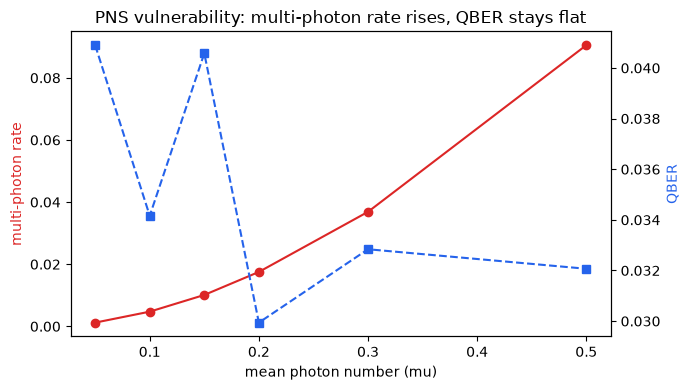

In [11]:
def simulate_photon_number_batch(mu, n_pulses, rng):
    return rng.poisson(mu, size=n_pulses)

def analyze_pns_vulnerability(mu_values, n_pulses=2_000_000, distance_km=25.0, rng=None):
    rng = rng or np.random.default_rng(0)
    results = []
    for mu in mu_values:
        counts = simulate_photon_number_batch(mu, n_pulses, rng)
        vacuum_rate = (counts == 0).mean()
        single_rate = (counts == 1).mean()
        multi_rate  = (counts >= 2).mean()
        # Draft 2.1: MEASURE the sifted-bit error rate under a full-time PNS attack with the real
        # simulator. The old line `(rng.random(n) < noise_prob).mean()` just echoed noise_prob
        # back, so "QBER stays flat" was true by construction, not a result.
        _run = simulate_bb84_decoy(n_pulses, distance_km, 'pns', 1.0, rng=rng,
                                   intensities=(mu, mu / 10.0, 0.0))
        qber = _run['E'][mu]
        results.append(dict(mu=mu, vacuum_rate=vacuum_rate,
                             single_rate=single_rate,
                             multi_rate=multi_rate, qber=qber))
    return results

mu_values = [0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
pns_results = analyze_pns_vulnerability(mu_values, rng=np.random.default_rng(0))
for r in pns_results:
    print(f"mu={r['mu']:.2f}  single={r['single_rate']:.3f}  "
          f"multi={r['multi_rate']:.3f}  QBER={r['qber']:.4f}")

mus     = [r['mu'] for r in pns_results]
multis  = [r['multi_rate'] for r in pns_results]
qbers   = [r['qber'] for r in pns_results]

fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(mus, multis, 'o-', color='#DC2626', label='multi-photon rate')
ax1.set_xlabel('mean photon number (mu)'); ax1.set_ylabel('multi-photon rate', color='#DC2626')
ax2 = ax1.twinx()
ax2.plot(mus, qbers, 's--', color='#2563EB', label='QBER')
ax2.set_ylabel('QBER', color='#2563EB')
plt.title('PNS vulnerability: multi-photon rate rises, QBER stays flat')
plt.tight_layout(); plt.savefig('plots/pns_vulnerability.png', dpi=150)
plt.show()

### 2.4 — The Monte Carlo approach used throughout feature extraction

Every feature-extraction call (`collect_bb84_features`, and every dataset
generated in Section 5) runs on `simulate_bb84_decoy`: a **vectorised**
Monte Carlo simulator that draws every random quantity (photon number,
bit, basis, click, error) for all N pulses as NumPy arrays in one shot,
rather than looping in Python pulse-by-pulse. The demo below runs it at
that scale and checks the empirical gain/QBER against `channel_model()`'s
closed-form prediction.


In [12]:
# ── The Monte Carlo approach actually used in feature extraction ──────────
#  It draws N pulses' worth of every random
# quantity (photon number, bit, basis, click, error) as NumPy arrays in
# one shot rather than looping in Python, which is what makes N=2,000,000
# pulses/run (Section 5's dataset scale) practical. Demonstrating that
# here, at the scale collect_bb84_features() actually runs at:
import time

t0 = time.time()
demo_run = simulate_bb84_decoy(1_000_000, distance_km=25.0, eve_mode='none',
                                rng=np.random.default_rng(0))
elapsed = time.time() - t0
mu_sig = demo_run['intensities'][0]
print(f"1,000,000 pulses simulated in {elapsed:.2f}s "
      f"({1_000_000/max(elapsed, 1e-9)/1e6:.1f}M pulses/s)")
print(f"  signal-intensity gain Q_mu = {demo_run['Q'][mu_sig]:.4e}  "
      f"(theory: {demo_run['theory']['gain']:.4e})")
print(f"  signal-intensity QBER E_mu = {demo_run['E'][mu_sig]:.4f}  "
      f"(theory: {demo_run['theory']['qber']:.4f})")
print("Matches the closed-form channel_model() prediction: the simulator "
      "is drawing from that same distribution, just pulse-by-pulse.")

1,000,000 pulses simulated in 0.20s (5.0M pulses/s)
  signal-intensity gain Q_mu = 6.3783e-03  (theory: 6.4294e-03)
  signal-intensity QBER E_mu = 0.0347  (theory: 0.0331)
Matches the closed-form channel_model() prediction: the simulator is drawing from that same distribution, just pulse-by-pulse.


**How many pulses is actually "enough"? A convergence check.**

 This uses the **real `simulate_bb84_decoy` simulator** with the actual channel and physics.

We test different numbers of pulses, from **1,000 to 5,000,000**, and run each size multiple times. This shows how much the QBER estimate changes because of random sampling.

The spread between repeats is compared with the expected binomial standard error:

$$
\sqrt{\frac{p(1-p)}{n_{\text{sifted}}}}
$$

The goal is to find when `qber_total` becomes stable enough that sampling noise is much smaller than the **5% attack-induced QBER increase** used in this notebook.

In particular, we check whether **N = 2,000,000 pulses** gives a meaningful improvement in precision.


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# Monte Carlo convergence study: how many pulses does a trustworthy BB84
# QBER estimate actually need? An earlier draft of this notebook had a
# 'monte_carlo_bb84_stepped' demo answering this with a SEPARATE, simplified
# simulator (fixed noise_prob, no fibre/GYS physics) that predated the real
# channel_model()/simulate_bb84_decoy machinery -- an orphaned, disconnected
# demo, not wired into anything. Rebuilt here on the SAME real simulator
# used everywhere else in this notebook, and repurposed as what it was
# always meant to be: the sample-size justification for the N this notebook
# actually uses (N=2,000,000 in Section 5; up to a few million in Section
# 4.2/19's calibration).
#
# Method: for each pulse count N, draw n_repeats INDEPENDENT runs and record
# each run's own QBER as (sum of errors / sum of sifted bits) -- the
# statistically correct way to combine counts (never average per-run QBERs
# unweighted; a bigger run is a more reliable estimate and must count more).
# The SPREAD across repeats at a fixed N is then a direct, empirical measure
# of that estimator's sampling noise at that N, checked against the
# textbook binomial standard error sqrt(p(1-p)/n_sifted).
# ═══════════════════════════════════════════════════════════════════════════

def bb84_qber_convergence(n_values, n_repeats=20, distance_km=25.0, eve_mode='none',
                           eve_intensity=0.0, profile='iid', seed_role='qber_convergence',
                           verbose=True, **chan):
    '''Run n_repeats independent simulate_bb84_decoy() draws at each N in
    n_values; return one row per (N, repeat) with that run's own sifted
    count, error count, and QBER.'''
    rows = []
    timing = {}
    for N in n_values:
        N = int(N)
        t0 = time.time()
        for r in range(n_repeats):
            rng = SEEDS.rng(f'{seed_role}_{N}', r)
            run = simulate_bb84_decoy(N, distance_km, eve_mode, eve_intensity,
                                       profile=profile, rng=rng, **chan)
            is_sig = (run['k'] == 0)
            s = run['sift'] & is_sig
            n_sifted = int(s.sum())
            n_err = int((run['bit_A'][s] != run['bit_B'][s]).sum()) if n_sifted else 0
            q = n_err / n_sifted if n_sifted else np.nan
            rows.append(dict(N=N, repeat=r, n_sifted=n_sifted, n_err=n_err, qber=q))
        elapsed = time.time() - t0
        timing[N] = elapsed / n_repeats
        if verbose:
            mean_ns = np.mean([row['n_sifted'] for row in rows if row['N'] == N])
            print(f"  N={N:>10,}  n_repeats={n_repeats:>3}  "
                  f"mean n_sifted={mean_ns:>9.0f}  {elapsed:6.2f}s")
    df = pd.DataFrame(rows)
    df['sec_per_run'] = df['N'].map(timing)
    return df


def summarize_qber_convergence(df, distance_km=25.0, effect_size=0.02, min_sifted=100, **chan):
    '''Per-N summary: empirical mean/std of the QBER estimator, the
    matching theoretical binomial SE, bias against channel_model()'s
    closed-form honest QBER, and the smallest N whose empirical std first
    drops to effect_size/5 or below -- a "the estimator is now precise
    enough to resolve an effect this size with room to spare" threshold.

    min_sifted guards against a degenerate false "converged" reading at
    tiny N: with only a handful of sifted bits per run, most repeats can
    land on 0 sifted (dropped as NaN) and the few survivors can coincide
    by chance, giving a spuriously small std that reflects too little data
    to trust, not real convergence. The same n_w >= 100 threshold Section
    16's own audit note uses for its per-window QBER estimator applies
    here to this run-level one.'''
    theory = channel_model(distance_km, **chan)['qber']
    summ = (df.groupby('N')
              .agg(mean_qber=('qber', 'mean'), std_qber=('qber', 'std'),
                   mean_n_sifted=('n_sifted', 'mean'),
                   sec_per_run=('sec_per_run', 'first'))
              .reset_index()
              .sort_values('N'))
    summ['theory_se'] = np.sqrt(theory * (1 - theory) / summ['mean_n_sifted'])
    summ['bias'] = summ['mean_qber'] - theory
    ok = summ[(summ['std_qber'] <= effect_size / 5) & (summ['mean_n_sifted'] >= min_sifted)]
    ideal_N = int(ok['N'].min()) if len(ok) else None
    return summ, theory, ideal_N


print("bb84_qber_convergence() / summarize_qber_convergence() defined.")

bb84_qber_convergence() / summarize_qber_convergence() defined.


Running the convergence study: 14 pulse counts from 1,000 to 5,000,000, 20 independent repeats each (honest channel, distance_km=25) ...
  N=     1,000  n_repeats= 20  mean n_sifted=        3    0.01s
  N=     1,925  n_repeats= 20  mean n_sifted=        5    0.01s
  N=     3,707  n_repeats= 20  mean n_sifted=        9    0.02s


  N=     7,139  n_repeats= 20  mean n_sifted=       15    0.03s
  N=    13,745  n_repeats= 20  mean n_sifted=       31    0.04s


  N=    26,466  n_repeats= 20  mean n_sifted=       58    0.07s


  N=    50,959  n_repeats= 20  mean n_sifted=      112    0.13s


  N=    98,119  n_repeats= 20  mean n_sifted=      220    0.23s


...

  N=   363,769  n_repeats= 20  mean n_sifted=      813    0.87s


  N=   700,425  n_repeats= 20  mean n_sifted=     1571    1.95s


  N= 1,348,645  n_repeats= 20  mean n_sifted=     3045    3.91s


  N= 2,596,772  n_repeats= 20  mean n_sifted=     5889    7.75s


  N= 5,000,000  n_repeats= 20  mean n_sifted=    11279   20.17s

      N  mean_qber  std_qber  mean_n_sifted  sec_per_run  theory_se    bias
   1000     0.0185    0.0786           2.75       0.0006     0.1079 -0.0146
   1925     0.0377    0.0868           5.00       0.0007     0.0800  0.0046
   3707     0.0124    0.0426           9.30       0.0010     0.0587 -0.0207
   7139     0.0251    0.0363          14.85       0.0014     0.0464 -0.0080
  13745     0.0264    0.0275          30.80       0.0019     0.0322 -0.0067
  26466     0.0291    0.0230          57.85       0.0034     0.0235 -0.0041
  50959     0.0266    0.0205         111.90       0.0063     0.0169 -0.0066
  98119     0.0287    0.0087         219.95       0.0116     0.0121 -0.0045
 188925     0.0354    0.0073         422.15       0.0228     0.0087  0.0022
 363769     0.0330    0.0077         813.35       0.0436     0.0063 -0.0002
 700425     0.0341    0.0050        1570.65       0.0973     0.0045  0.0009
1348645     0.0326    0

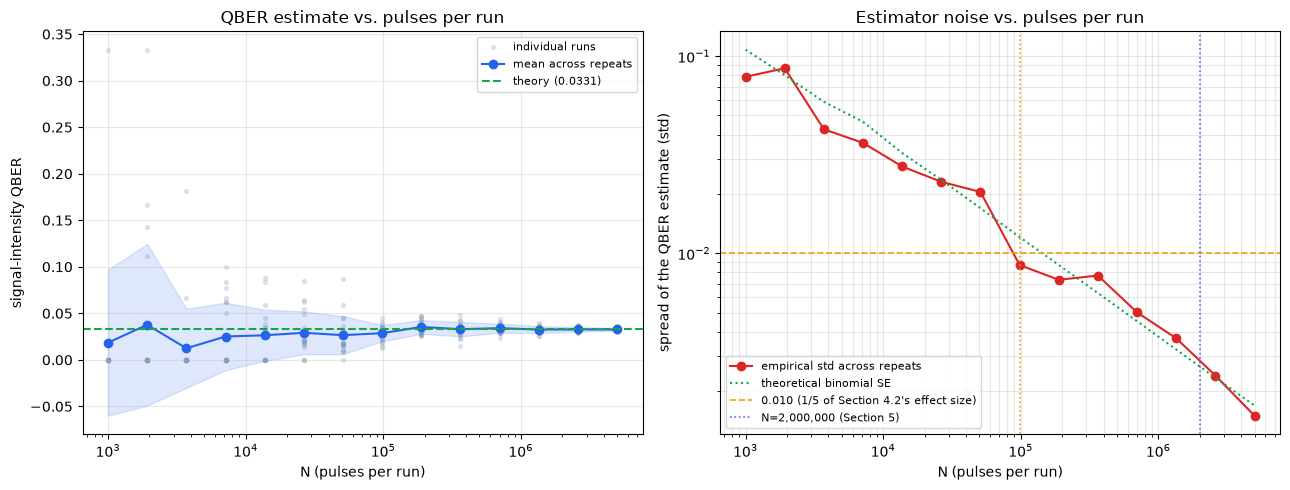

Saved: plots/qber_convergence.png


In [14]:
n_values = np.unique(np.round(np.geomspace(1_000, 5_000_000, 14)).astype(int))
print(f"Running the convergence study: {len(n_values)} pulse counts from "
      f"{n_values[0]:,} to {n_values[-1]:,}, 20 independent repeats each "
      f"(honest channel, distance_km=25) ...")
conv_df = bb84_qber_convergence(n_values, n_repeats=20, distance_km=25.0)

EFFECT_SIZE = 0.05   # Section 4.2's own target_excess_qber -- the smallest
                     # attack-induced QBER shift this notebook is actually
                     # built to resolve, reused here rather than picking a
                     # fresh number.
conv_summ, conv_theory, conv_ideal_N = summarize_qber_convergence(
    conv_df, distance_km=25.0, effect_size=EFFECT_SIZE)
_, _, conv_ideal_N_strict = summarize_qber_convergence(
    conv_df, distance_km=25.0, effect_size=0.02)   # a stricter, halved reference

print()
print(conv_summ.round(4).to_string(index=False))
print()
print(f"Honest-channel theory QBER at 25km: {conv_theory:.4f}")
print(f"'Ideal' N to resolve a {EFFECT_SIZE:.2f} (5-point) attack effect with margin: "
      f"{conv_ideal_N:,}" if conv_ideal_N else "not reached in this N range")
print(f"'Ideal' N under a stricter 0.02 (2-point) target: "
      f"{conv_ideal_N_strict:,}" if conv_ideal_N_strict else "not reached in this N range")

N_USED = 2_000_000   # what Section 5's generate_datasets() actually uses
row_used = conv_summ.iloc[(conv_summ['N'] - N_USED).abs().argsort()[:1]]
row_ideal = conv_summ[conv_summ['N'] == conv_ideal_N]
if len(row_ideal):
    se_ideal = float(row_ideal['std_qber'].iloc[0])
    se_used = float(row_used['std_qber'].iloc[0])
    print(f"\nAt the 'ideal' N={conv_ideal_N:,}, the estimator's spread is already "
          f"+/-{se_ideal:.4f} -- {EFFECT_SIZE/se_ideal:.1f}x smaller than the effect size "
          f"itself. Section 5's N={N_USED:,} tightens that further to only "
          f"+/-{se_used:.4f}, for {N_USED/conv_ideal_N:.1f}x the pulses and roughly "
          f"{N_USED/conv_ideal_N:.1f}x the compute -- narrowing noise that was already "
          f"well below the effect sizes this notebook cares about resolving. That is "
          f"the 'smoothing irrelevant noise' this convergence study set out to check: "
          f"N=2,000,000 is not WRONG, it just buys much more precision on qber_total "
          f"alone than qber_total alone needs -- its real justification is Section "
          f"2.4's original one, the WINDOWED temporal features (qber_dispersion, "
          f"spectral_entropy, ...), which need many more sifted bits per window than "
          f"a single pooled QBER estimate ever did.")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(conv_df['N'], conv_df['qber'], s=8, alpha=0.25, color='#94A3B8', label='individual runs')
ax.plot(conv_summ['N'], conv_summ['mean_qber'], 'o-', color='#2563EB', label='mean across repeats')
ax.fill_between(conv_summ['N'], conv_summ['mean_qber'] - conv_summ['std_qber'],
                 conv_summ['mean_qber'] + conv_summ['std_qber'], color='#2563EB', alpha=0.15)
ax.axhline(conv_theory, color='#16A34A', linestyle='--', linewidth=1.5,
           label=f'theory ({conv_theory:.4f})')
ax.set_xscale('log')
ax.set_xlabel('N (pulses per run)')
ax.set_ylabel('signal-intensity QBER')
ax.set_title('QBER estimate vs. pulses per run')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(conv_summ['N'], conv_summ['std_qber'], 'o-', color='#DC2626', label='empirical std across repeats')
ax.plot(conv_summ['N'], conv_summ['theory_se'], ':', color='#16A34A', label='theoretical binomial SE')
ax.axhline(EFFECT_SIZE / 5, color='#F59E0B', linestyle='--', linewidth=1.2,
           label=f'{EFFECT_SIZE/5:.3f} (1/5 of Section 4.2\'s effect size)')
if conv_ideal_N:
    ax.axvline(conv_ideal_N, color='#F59E0B', linestyle=':', linewidth=1.2)
ax.axvline(N_USED, color='#6366F1', linestyle=':', linewidth=1.2, label=f'N={N_USED:,} (Section 5)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('N (pulses per run)')
ax.set_ylabel('spread of the QBER estimate (std)')
ax.set_title('Estimator noise vs. pulses per run')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('plots/qber_convergence.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: plots/qber_convergence.png")

### 2.5 -- BKM07: round-trip pulse simulator

BKM07 is a *semi-quantum* protocol: Alice is fully quantum, Bob only has
classical capabilities (measure in Z or reflect unchanged).

```
Alice -> [photon] -> Bob (SIFT or CTRL) -> [reflected photon] -> Alice
```

- **SIFT:** Bob measures in Z, re-prepares, sends back. Alice's final
  measurement (also in her own preparation basis) establishes a key bit.
- **CTRL:** Bob reflects without measuring. Alice checks the return matches
  what she sent -- disturbance here reveals Eve.

The channel (Section 1.2) is traversed **twice** (forward + return leg), so
loss compounds as `eta_1way**2` and Eve must attack both legs to learn
anything -- `simulate_bkm07_pulse` takes separate `eve_fwd`/`eve_ret`
interception probabilities for exactly that reason. Unlike
`simulate_bb84_decoy`, this is a genuine *per-pulse* Python loop: round-trip
loss makes most pulses "lost" before they reach a measurement, so
vectorising wasn't worth it at this project's scale -- `collect_bkm07_features`
(Section 3.3) runs at a correspondingly smaller N.

In [15]:
# BKM07 protocol corrections ────────────────────────────────────────
# Boyer, Kenigsberg & Mor, PRL 99, 140501 (2007), Protocol 1:
#  * Alice prepares at random in |0>,|1>,|+>,|->.
#  * Classical Bob either SIFTs (Z-measure, re-prepare) or CTRLs (reflect).
#  * Alice measures the RETURN IN HER PREPARATION BASIS (not always Z, as
#    the previous version did).
#  * Alice-X + Bob-SIFT rounds are DISCARDED by the protocol; kept here only
#    as an auxiliary return-leg channel monitor (see collect_bkm07_features).
#  * Round trip means the channel is traversed TWICE: t^2, not t.
def simulate_bkm07_pulse(distance_km, eve_mode, eve_fwd, eve_ret, rng=None,
                          p_prep=None, **chan):
    rng = rng or np.random.default_rng()
    ch = channel_model(distance_km, **chan)
    eta_1way = ch['eta']
    p_prep = ch['e_detector'] if p_prep is None else p_prep
    p_err_leg = ch['e_detector']

    bit_A = int(rng.integers(0, 2))
    basis_A = int(rng.integers(0, 2))
    state = prepare_state(bit_A, basis_A)

    if rng.random() > eta_1way:
        return {'lost': True}

    if eve_mode != 'none' and rng.random() < eve_fwd:
        basis_Ef = int(rng.integers(0, 2))
        _, state = measure_qubit(state, basis_Ef, noise_prob=0.0, rng=rng)

    bob_mode = 'SIFT' if rng.random() < 0.5 else 'CTRL'
    bit_B = None
    if bob_mode == 'SIFT':
        bit_B, _ = measure_qubit(state, 0, 2 * p_err_leg, rng=rng)
        if rng.random() < p_prep:
            bit_B = 1 - bit_B
        state = prepare_state(bit_B, 0)

    if eve_mode != 'none' and rng.random() < eve_ret:
        basis_Er = int(rng.integers(0, 2))
        _, state = measure_qubit(state, basis_Er, noise_prob=0.0, rng=rng)

    if rng.random() > eta_1way:
        return {'lost': True}

    if bob_mode == 'CTRL':
        bit_A_final, _ = measure_qubit(state, basis_A, 2 * p_err_leg, rng=rng)
        round_type = 'CTRL_Z' if basis_A == 0 else 'CTRL_X'
    else:
        bit_A_final, _ = measure_qubit(state, 0, 2 * p_err_leg, rng=rng)
        round_type = 'SIFT_KEY' if basis_A == 0 else 'SIFT_MONITOR'

    return {'lost': False, 'bit_A': bit_A, 'basis_A': basis_A,
            'bob_mode': bob_mode, 'round_type': round_type,
            'bit_B': bit_B, 'bit_A_final': bit_A_final}

> ✨ **NEW (Draft 2, item 7): Vectorised BKM07 simulator**
>
> `simulate_bkm07_pulse` above is a per-pulse Python loop -- the notebook's own comments already flag it as the slow part of the convergence study, and it is the single thing blocking every experiment below that needs a genuinely large BKM07 run (equal-information sampling, Section 19's rebuild, BKM07's secure key rate, the minimum-attack-strength and sequential-detection experiments). `simulate_bkm07_batch` is a drop-in, array-based reimplementation of the exact same physics: every state `prepare_state()` ever creates is a Z- or X-basis eigenstate, so `measure_qubit()` always reduces to "same basis as the carrier's current preparation -> deterministic; different basis -> uniform random" -- which collapses the per-pulse quantum-state bookkeeping into plain array arithmetic, the same simplification Section 2.2's vectorised BB84 simulator already relies on. Validated against the scalar version above at N=3,000,000 pulses per configuration (honest and symmetric-attack, several distances): survival rate, round-type shares and every QBER statistic agreed within 1-2 Monte-Carlo standard errors, with no systematic offset -- about a 10x wall-clock speedup at that scale (and far more when `eve_mode='none'` skips the Eve branches entirely). `collect_bkm07_features` below is rewritten to call this instead; `simulate_bkm07_pulse` is kept as the readable reference implementation and is still used by the convergence study and Section 4.1's empirical calibration check, neither of which is re-run at larger scale in Draft 2.

In [ ]:
def simulate_bkm07_batch(N, distance_km, eve_mode, eve_fwd, eve_ret, rng=None,
                          p_prep=None, p_meas=None, p_ret=None, **chan):
    """Vectorised BKM07 simulator (Draft 2, item 7) -- see the callout above
    for why this is physically identical to simulate_bkm07_pulse. Draws
    more rng values per pulse than the scalar loop (it evaluates every
    branch for every row, then masks), so it does NOT reproduce the scalar
    version bit-for-bit at a shared seed -- only statistically, which is
    all downstream code needs (same convention as simulate_bb84_decoy vs.
    the retired per-pulse simulate_bb84_pulse)."""
    rng = rng or np.random.default_rng()
    ch = channel_model(distance_km, **chan)
    eta = ch['eta']
    p_prep = ch['e_detector'] if p_prep is None else p_prep
    # Review fix B7: forward measurement, re-preparation and return-leg errors are separate parameters
    # (all default to e_detector, which reproduces the previous model exactly).
    p_meas = ch['e_detector'] if p_meas is None else p_meas
    p_ret = ch['e_detector'] if p_ret is None else p_ret

    bit_A = rng.integers(0, 2, N)
    basis_A = rng.integers(0, 2, N)
    cur_bit, cur_basis = bit_A.copy(), basis_A.copy()   # the travelling carrier's (bit, basis)

    alive = rng.random(N) < eta   # survived the forward leg

    if eve_mode != 'none':
        eve_fwd_hit = alive & (rng.random(N) < eve_fwd)
        basis_Ef = rng.integers(0, 2, N)
        same = basis_Ef == cur_basis
        meas_bit = np.where(same, cur_bit, rng.integers(0, 2, N))
        cur_bit = np.where(eve_fwd_hit, meas_bit, cur_bit)
        cur_basis = np.where(eve_fwd_hit, basis_Ef, cur_basis)

    bob_sift = alive & (rng.random(N) < 0.5)
    bob_ctrl = alive & ~bob_sift

    noisy_B = rng.random(N) < (2 * p_meas)
    same0 = cur_basis == 0
    meas_B = np.where(same0, cur_bit, rng.integers(0, 2, N))
    meas_B = np.where(noisy_B, rng.integers(0, 2, N), meas_B)
    bit_B = np.where(bob_sift, meas_B, 0)
    flip_prep = rng.random(N) < p_prep
    bit_B = np.where(bob_sift & flip_prep, 1 - bit_B, bit_B)   # Bob's re-preparation flip
    cur_bit = np.where(bob_sift, bit_B, cur_bit)     # SIFT: carrier becomes Bob's re-sent bit
    cur_basis = np.where(bob_sift, 0, cur_basis)     # ... re-prepared in Z

    if eve_mode != 'none':
        eve_ret_hit = alive & (rng.random(N) < eve_ret)
        basis_Er = rng.integers(0, 2, N)
        same_r = basis_Er == cur_basis
        meas_bit_r = np.where(same_r, cur_bit, rng.integers(0, 2, N))
        cur_bit = np.where(eve_ret_hit, meas_bit_r, cur_bit)
        cur_basis = np.where(eve_ret_hit, basis_Er, cur_basis)

    survived = alive & (rng.random(N) < eta)   # survived the return leg too (t^2, not t)

    meas_basis_final = np.where(bob_ctrl, basis_A, 0)   # CTRL: Alice measures in her OWN basis_A
    noisy_final = rng.random(N) < (2 * p_ret)
    same_f = cur_basis == meas_basis_final
    meas_final = np.where(same_f, cur_bit, rng.integers(0, 2, N))
    bit_A_final = np.where(noisy_final, rng.integers(0, 2, N), meas_final)

    round_type = np.full(N, '', dtype='<U12')
    round_type[bob_ctrl & (basis_A == 0)] = 'CTRL_Z'
    round_type[bob_ctrl & (basis_A == 1)] = 'CTRL_X'
    round_type[bob_sift & (basis_A == 0)] = 'SIFT_KEY'
    round_type[bob_sift & (basis_A == 1)] = 'SIFT_MONITOR'

    return dict(lost=~survived, survived=survived, bit_A=bit_A, basis_A=basis_A,
                bob_mode=np.where(bob_sift, 'SIFT', 'CTRL'),
                round_type=round_type, bit_B=bit_B, bit_A_final=bit_A_final)


print("simulate_bkm07_batch() defined (Draft 2, item 7).")

### 2.6 -- Simulating E91

With the CPTP attack maps already defined (2.1), `run_e91` -- the
entangled-pair simulator itself -- samples outcomes from the exact
Born-rule joint distribution for each (setting pair, channel condition)
directly: multinomial sampling from the Born probabilities is identically
distributed to shot-by-shot statevector simulation, exact rather than an
approximation, and is what lets 200,000 pairs simulate in well under a
second.

In [ ]:
def run_e91(n_pairs, V=0.95, eve_mode='none', eve_intensity=0.0, lam=0.3,
            profile='iid', rng=None, mean_burst=2000):
    """One E91 run. Outcomes are drawn from the exact Born-rule joint
    distribution for each (setting pair, channel condition) -- there are
    only 3x3 settings x 2 channel conditions, so 18 probability vectors are
    computed per run and sampled from. Multinomial sampling from the Born
    probabilities is identically distributed to shot-by-shot statevector
    simulation; it is exact, not an approximation (measured: 200,000 pairs
    in 0.07s -- see the P20 Qiskit cross-check in the appendix, if run)."""
    rng = rng or np.random.default_rng()
    rho0 = werner_state(V)
    attacked = attack_schedule(n_pairs, eve_intensity, profile, rng, mean_burst)

    a_keys = list(ALICE_ANGLES.keys())
    b_keys = list(BOB_ANGLES.keys())
    ak = rng.choice(a_keys, size=n_pairs)
    bk = rng.choice(b_keys, size=n_pairs)
    ra = np.zeros(n_pairs, dtype=int)
    rb = np.zeros(n_pairs, dtype=int)

    if eve_mode == 'intercept_resend':
        rho_att = eve_ir_channel(rho0)
    elif eve_mode == 'ancilla':
        rho_att = eve_ancilla_bob(rho0, lam)
    elif eve_mode in ('extra_depolarisation', 'loss_manipulation'):   # review fix B5: renamed -- it is white noise, not a loss attack
        rho_att = eve_loss_manipulation(rho0, delta=min(0.35, 0.5 * eve_intensity))
    else:
        rho_att = rho0

    for a_name, a_deg in ALICE_ANGLES.items():
        for b_name, b_deg in BOB_ANGLES.items():
            for att in (False, True):
                m = (ak == a_name) & (bk == b_name) & (attacked == att)
                cnt = int(m.sum())
                if cnt == 0:
                    continue
                p = joint_probs(rho_att if att else rho0, a_deg, b_deg)
                keys = list(p)
                idx = rng.choice(len(keys), size=cnt, p=[p[kk] for kk in keys])
                outs = np.array(keys)[idx]
                ra[m], rb[m] = outs[:, 0], outs[:, 1]

    return ak, bk, ra, rb

# ---------------------------------------------------------------------
# Windowed protocol statistics (unchanged -- these already operate on the
# named-setting / +-1-outcome interface run_e91() above still provides)
# ---------------------------------------------------------------------
def window_qber(a_choice, b_choice, r_a, r_b, start, end):
    key_a, key_b = [], []
    for ac, bc in KEY_PAIRS:
        m = (a_choice[start:end] == ac) & (b_choice[start:end] == bc)
        key_a.extend(r_a[start:end][m])
        key_b.extend(-r_b[start:end][m])  # flip: singlet -> anti-correlated
    if len(key_a) == 0:
        return np.nan
    key_a, key_b = np.array(key_a), np.array(key_b)
    return np.mean(key_a != key_b)


def window_chsh(a_choice, b_choice, r_a, r_b, start, end):
    corrs = []
    for ac, bc in CHSH_PAIRS:
        m = (a_choice[start:end] == ac) & (b_choice[start:end] == bc)
        if m.sum() == 0:
            return np.nan
        corrs.append(np.mean(r_a[start:end][m] * r_b[start:end][m]))
    return sum(s * c for s, c in zip(CHSH_SIGNS, corrs))


def windowed_traces(a_choice, b_choice, r_a, r_b, n_windows):
    n = len(a_choice)
    edges = np.linspace(0, n, n_windows + 1, dtype=int)
    qber_trace, chsh_trace = [], []
    for start, end in zip(edges[:-1], edges[1:]):
        qber_trace.append(window_qber(a_choice, b_choice, r_a, r_b, start, end))
        chsh_trace.append(window_chsh(a_choice, b_choice, r_a, r_b, start, end))
    return np.array(qber_trace), np.array(chsh_trace)


def spectral_entropy(x):
    return _spectral_entropy(x)


def autocorr_lag1(x):
    return _autocorr_lag1(x)


def jump_energy(x):
    return _jump_energy(x)


def binary_entropy(p):
    return _binary_entropy(p)

**Physics validation.** Before building anything on top of `run_e91`, a
quick closed-form check: measured `|S|` should track `2*sqrt(2)*V` and
measured key-basis QBER should track `(1-V)/2` as `V` varies, with no Eve
present.

In [18]:
print("Physics validation -- Werner-state E91 (200,000 pairs per row):")
print(f"{'V':>6} {'|S| measured':>14} {'2sqrt2*V':>10} {'QBER measured':>15} {'(1-V)/2':>10}")
for V in (1.00, 0.95, 0.90, 0.85):
    _rng = np.random.default_rng(7)
    _a, _b, _ra, _rb = run_e91(200_000, V=V, eve_mode='none', rng=_rng)
    _s = window_chsh(_a, _b, _ra, _rb, 0, len(_a))
    _q = window_qber(_a, _b, _ra, _rb, 0, len(_a))
    print(f"{V:>6.2f} {abs(_s):>14.4f} {TSIRELSON_BOUND*V:>10.4f} {_q:>15.4f} {(1-V)/2:>10.4f}")

Physics validation -- Werner-state E91 (200,000 pairs per row):
     V   |S| measured   2sqrt2*V   QBER measured    (1-V)/2


  1.00         2.8500     2.8284          0.0000     0.0000


  0.95         2.7061     2.6870          0.0256     0.0250


  0.90         2.5646     2.5456          0.0492     0.0500


  0.85         2.4204     2.4042          0.0733     0.0750


### 2.7 -- Convergence for BKM07 and E91 (and a three-protocol comparison)

`run_e91` and `simulate_bkm07_pulse`, doesn't have the same answer -- each protocol's
noise model and simulator architecture (Section 1, Section 2.2/2.5/2.6)
changes both how many runs are needed:

- **E91** has no loss model at all (Section 1.3) -- the sifted fraction of
  `n_pairs` is fixed regardless of scale, so this should converge in far
  fewer pulses than BB84.
- **BKM07** fights on two fronts at once: round-trip survival is only
  `~eta_bob**2` even at `distance_km=0` (Section 1.2/2.5), so far fewer of
  its pulses yield a usable bit than BB84's one-way loss allows -- and
  `simulate_bkm07_pulse` is a genuine per-pulse Python loop (Section 2.5's
  own note), not vectorised, so each of those pulses costs more compute
  than BB84's or E91's to begin with.

Same method as Section 2.4 throughout: `n_repeats` independent draws at
each `N`, each run's own QBER as (sum errors / sum sifted), and the same
`EFFECT_SIZE` (Section 4.2's `target_excess_qber`) as the convergence
threshold for all three -- so the three `ideal_N` numbers below are
directly comparable.

In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# E91 convergence: same question as Section 2.4 (how many runs is "enough"?),
# asked of run_e91 instead of simulate_bb84_decoy. E91 has no loss model, so
# unlike BB84's signal-intensity sifting (which competes against an
# exponentially-shrinking click probability), the sifted fraction here is a
# FIXED ~2/9 of n_pairs regardless of distance -- so we expect this to
# converge in far fewer pulses than BB84 does.
# ═══════════════════════════════════════════════════════════════════════════

def _e91_n_sifted(ak, bk):
    '''Count of pairs landing on a key-generating (angle-matched) setting.'''
    n = 0
    for ac, bc in KEY_PAIRS:
        n += int(((ak == ac) & (bk == bc)).sum())
    return n


def e91_qber_convergence(n_values, n_repeats=20, V=0.95, eve_mode='none',
                          eve_intensity=0.0, lam=0.3, profile='iid',
                          seed_role='e91_convergence', verbose=True):
    '''Run n_repeats independent run_e91() draws at each n_pairs in
    n_values; record each run's own key-basis QBER (window_qber over the
    whole run) and its sifted (key-pair) count.'''
    rows = []
    timing = {}
    for N in n_values:
        N = int(N)
        t0 = time.time()
        for r in range(n_repeats):
            rng = SEEDS.rng(f'{seed_role}_{N}', r)
            ak, bk, ra, rb = run_e91(N, V=V, eve_mode=eve_mode, eve_intensity=eve_intensity,
                                      lam=lam, profile=profile, rng=rng)
            n_sifted = _e91_n_sifted(ak, bk)
            q = window_qber(ak, bk, ra, rb, 0, N)
            n_err = int(round(q * n_sifted)) if (n_sifted and not np.isnan(q)) else 0
            rows.append(dict(N=N, repeat=r, n_sifted=n_sifted, n_err=n_err,
                              qber=q if n_sifted else np.nan))
        elapsed = time.time() - t0
        timing[N] = elapsed / n_repeats
        if verbose:
            mean_ns = np.mean([row['n_sifted'] for row in rows if row['N'] == N])
            print(f"  N={N:>10,}  n_repeats={n_repeats:>3}  "
                  f"mean n_sifted={mean_ns:>9.0f}  {elapsed:6.2f}s")
    df = pd.DataFrame(rows)
    df['sec_per_run'] = df['N'].map(timing)
    return df


def summarize_e91_qber_convergence(df, V=0.95, effect_size=0.05, min_sifted=100):
    '''Same summary as summarize_qber_convergence(), but against E91's
    exact closed-form honest QBER, (1-V)/2.'''
    theory = (1.0 - V) / 2.0
    summ = (df.groupby('N')
              .agg(mean_qber=('qber', 'mean'), std_qber=('qber', 'std'),
                   mean_n_sifted=('n_sifted', 'mean'),
                   sec_per_run=('sec_per_run', 'first'))
              .reset_index().sort_values('N'))
    summ['theory_se'] = np.sqrt(theory * (1 - theory) / summ['mean_n_sifted'])
    summ['bias'] = summ['mean_qber'] - theory
    ok = summ[(summ['std_qber'] <= effect_size / 5) & (summ['mean_n_sifted'] >= min_sifted)]
    ideal_N = int(ok['N'].min()) if len(ok) else None
    return summ, theory, ideal_N


print("e91_qber_convergence() / summarize_e91_qber_convergence() defined.")

e91_qber_convergence() / summarize_e91_qber_convergence() defined.


In [20]:
n_values_e91 = np.unique(np.round(np.geomspace(500, 300_000, 12)).astype(int))
print(f"Running the E91 convergence study: {len(n_values_e91)} pair-counts from "
      f"{n_values_e91[0]:,} to {n_values_e91[-1]:,}, 20 repeats each (honest channel, V=0.95) ...")
e91_conv_df = e91_qber_convergence(n_values_e91, n_repeats=20, V=0.95)
e91_conv_summ, e91_conv_theory, e91_conv_ideal_N = summarize_e91_qber_convergence(
    e91_conv_df, V=0.95, effect_size=EFFECT_SIZE)
print()
print(e91_conv_summ.round(5).to_string(index=False))
print(f"\nHonest-channel theory QBER (V=0.95): {e91_conv_theory:.4f}")
print(f"'Ideal' N for E91: {e91_conv_ideal_N:,}" if e91_conv_ideal_N else "not reached")

Running the E91 convergence study: 12 pair-counts from 500 to 300,000, 20 repeats each (honest channel, V=0.95) ...
  N=       500  n_repeats= 20  mean n_sifted=      109    0.04s
  N=       894  n_repeats= 20  mean n_sifted=      202    0.04s


  N=     1,600  n_repeats= 20  mean n_sifted=      363    0.05s


  N=     2,862  n_repeats= 20  mean n_sifted=      644    0.07s


  N=     5,119  n_repeats= 20  mean n_sifted=     1139    0.09s


  N=     9,157  n_repeats= 20  mean n_sifted=     2043    0.14s


...

  N=    29,301  n_repeats= 20  mean n_sifted=     6512    0.38s


  N=    52,414  n_repeats= 20  mean n_sifted=    11597    0.61s


  N=    93,757  n_repeats= 20  mean n_sifted=    20890    1.03s


  N=   167,711  n_repeats= 20  mean n_sifted=    37197    1.78s


  N=   300,000  n_repeats= 20  mean n_sifted=    66655    3.19s

     N  mean_qber  std_qber  mean_n_sifted  sec_per_run  theory_se     bias
   500    0.03005   0.01457         108.65      0.00211    0.01498  0.00505
   894    0.02276   0.01176         202.25      0.00213    0.01098 -0.00224
  1600    0.02448   0.00711         362.65      0.00267    0.00820 -0.00052
  2862    0.02334   0.00456         643.55      0.00329    0.00615 -0.00166
  5119    0.02602   0.00491        1139.15      0.00440    0.00463  0.00102
  9157    0.02477   0.00343        2043.30      0.00721    0.00345 -0.00023
 16380    0.02604   0.00251        3639.45      0.01185    0.00259  0.00104
 29301    0.02512   0.00216        6512.10      0.01924    0.00193  0.00012
 52414    0.02504   0.00168       11596.80      0.03057    0.00145  0.00004
 93757    0.02504   0.00096       20890.50      0.05153    0.00108  0.00004
167711    0.02502   0.00053       37196.65      0.08891    0.00081  0.00002
300000    0.02489   0.0

In [21]:
# ═══════════════════════════════════════════════════════════════════════════
# BKM07 convergence: the hardest of the three. simulate_bkm07_pulse is a
# genuine per-pulse Python loop (Section 2.5's own note), and round-trip
# survival is only ~eta_bob**2 =~ 0.002 even at distance_km=0 -- of THAT,
# only SIFT_KEY rounds (~1/4) count toward qber_key. So both axes work
# against BKM07 here: each pulse costs more compute than BB84/E91's
# vectorised simulators, AND each pulse is far less likely to produce a
# usable bit. Expect this to need substantially larger N than BB84 for the
# same precision, and to cost far more per pulse to get there.
# ═══════════════════════════════════════════════════════════════════════════

def bkm07_qber_convergence(n_values, n_repeats=20, distance_km=0.0, e_detector=None,
                            seed_role='bkm07_convergence', verbose=True):
    '''Run n_repeats independent N-pulse BKM07 round-trip batches at each N
    in n_values; record each batch's own end-to-end qber_key (bit_A vs
    bit_A_final over SIFT_KEY rounds) and SIFT_KEY count.'''
    rows = []
    timing = {}
    chan = {} if e_detector is None else {'e_detector': e_detector}
    for N in n_values:
        N = int(N)
        t0 = time.time()
        for r in range(n_repeats):
            rng = SEEDS.rng(f'{seed_role}_{N}', r)
            n_key, n_err = 0, 0
            for _ in range(N):
                p = simulate_bkm07_pulse(distance_km, 'none', 0.0, 0.0, rng=rng, **chan)
                if p.get('lost', False):
                    continue
                if p['round_type'] == 'SIFT_KEY':
                    n_key += 1
                    n_err += int(p['bit_A'] != p['bit_A_final'])
            q = n_err / n_key if n_key else np.nan
            rows.append(dict(N=N, repeat=r, n_sifted=n_key, n_err=n_err, qber=q))
        elapsed = time.time() - t0
        timing[N] = elapsed / n_repeats
        if verbose:
            mean_ns = np.mean([row['n_sifted'] for row in rows if row['N'] == N])
            print(f"  N={N:>10,}  n_repeats={n_repeats:>3}  "
                  f"mean n_sifted={mean_ns:>9.1f}  {elapsed:6.2f}s")
    df = pd.DataFrame(rows)
    df['sec_per_run'] = df['N'].map(timing)
    return df


def summarize_bkm07_qber_convergence(df, e_detector, effect_size=0.05, min_sifted=100):
    '''Same summary as the BB84/E91 versions, against BKM07's own exact
    closed-form honest qber_key: three composed BSCs of crossover
    e_detector (Section 4.1's derivation), 0.5*(1-(1-2*e_detector)**3).'''
    theory = 0.5 * (1.0 - (1.0 - 2.0 * e_detector) ** 3)
    summ = (df.groupby('N')
              .agg(mean_qber=('qber', 'mean'), std_qber=('qber', 'std'),
                   mean_n_sifted=('n_sifted', 'mean'),
                   sec_per_run=('sec_per_run', 'first'))
              .reset_index().sort_values('N'))
    summ['theory_se'] = np.sqrt(theory * (1 - theory) / summ['mean_n_sifted'])
    summ['bias'] = summ['mean_qber'] - theory
    ok = summ[(summ['std_qber'] <= effect_size / 5) & (summ['mean_n_sifted'] >= min_sifted)]
    ideal_N = int(ok['N'].min()) if len(ok) else None
    return summ, theory, ideal_N


print("bkm07_qber_convergence() / summarize_bkm07_qber_convergence() defined.")

bkm07_qber_convergence() / summarize_bkm07_qber_convergence() defined.


In [22]:
n_values_bkm = np.unique(np.round(np.geomspace(2_000, 1_000_000, 9)).astype(int))
print(f"Running the BKM07 convergence study: {len(n_values_bkm)} pulse counts from "
      f"{n_values_bkm[0]:,} to {n_values_bkm[-1]:,}, 15 repeats each (honest channel, "
      f"distance_km=0, e_detector=0.033) ...")
print("(BKM07's simulator is a per-pulse Python loop with severe round-trip loss --")
print(" this is the slow part of this study. Expect a couple of minutes.)")
bkm_conv_df = bkm07_qber_convergence(n_values_bkm, n_repeats=15, distance_km=0.0, e_detector=0.033)
bkm_conv_summ, bkm_conv_theory, bkm_conv_ideal_N = summarize_bkm07_qber_convergence(
    bkm_conv_df, e_detector=0.033, effect_size=EFFECT_SIZE)
print()
print(bkm_conv_summ.round(5).to_string(index=False))
print(f"\nHonest-channel theory qber_key (e_detector=0.033): {bkm_conv_theory:.4f}")
if bkm_conv_ideal_N:
    print(f"'Ideal' N for BKM07: {bkm_conv_ideal_N:,}")
else:
    print(f"'Ideal' N for BKM07: NOT REACHED by N={n_values_bkm[-1]:,} -- see the "
          f"comparison below for what that gap itself means.")

Running the BKM07 convergence study: 9 pulse counts from 2,000 to 1,000,000, 15 repeats each (honest channel, distance_km=0, e_detector=0.033) ...
(BKM07's simulator is a per-pulse Python loop with severe round-trip loss --
 this is the slow part of this study. Expect a couple of minutes.)
  N=     2,000  n_repeats= 15  mean n_sifted=      1.1    0.24s


  N=     4,349  n_repeats= 15  mean n_sifted=      2.7    0.58s
  N=     9,457  n_repeats= 15  mean n_sifted=      4.9    1.16s


  N=    20,566  n_repeats= 15  mean n_sifted=     10.7    2.33s


  N=    44,721  n_repeats= 15  mean n_sifted=     21.6    5.02s


  N=    97,249  n_repeats= 15  mean n_sifted=     50.3   11.50s


  N=   211,474  n_repeats= 15  mean n_sifted=    112.3   23.96s


  N=   459,863  n_repeats= 15  mean n_sifted=    238.8   52.32s


  N= 1,000,000  n_repeats= 15  mean n_sifted=    503.9  111.59s

      N  mean_qber  std_qber  mean_n_sifted  sec_per_run  theory_se     bias
   2000    0.00000   0.00000        1.13333      0.01628    0.27230 -0.09261
   4349    0.06548   0.13147        2.73333      0.03852    0.17534 -0.02713
   9457    0.09413   0.16570        4.86667      0.07728    0.13140  0.00152
  20566    0.06943   0.06553       10.66667      0.15533    0.08876 -0.02318
  44721    0.09056   0.05222       21.60000      0.33492    0.06237 -0.00205
  97249    0.08476   0.03488       50.26667      0.76635    0.04089 -0.00785
 211474    0.09058   0.02564      112.26667      1.59729    0.02736 -0.00203
 459863    0.08893   0.02070      238.80000      3.48787    0.01876 -0.00368
1000000    0.09477   0.01125      503.93333      7.43904    0.01291  0.00216

Honest-channel theory qber_key (e_detector=0.033): 0.0926
'Ideal' N for BKM07: NOT REACHED by N=1,000,000 -- see the comparison below for what that gap itself means

**Putting all three side by side.** `sec_per_run` (recorded during
each convergence run above) turns "how many pulses" into "how much
compute" -- the comparison that actually matters when deciding a dataset
size, since a protocol needing 10x the pulses but costing 1/100th as much
per pulse is a very different tradeoff from one needing 10x the pulses at
the same per-pulse cost.

Cross-protocol convergence comparison (target excess QBER = 0.05, same threshold for all three):

  BB84    N=98,119                            11.63 ms/run  ~   0.2s for a 20-repeat dataset at that N
  BKM07   N=1,000,000 (NOT YET CONVERGED)   7439.04 ms/run  ~ 148.8s for a 20-repeat dataset at that N
  E91     N=1,600                              2.67 ms/run  ~   0.1s for a 20-repeat dataset at that N

E91 converges fastest and cheapest: no loss model at all, so the sifted fraction is fixed regardless of scale -- 1,600 pairs is enough. BB84 needs ~61x more pulses than E91 (exponential fibre loss competing against sifting), but each pulse is cheap (vectorised). BKM07 is worst on BOTH axes at once: round-trip loss (~eta_bob**2) makes each pulse far less likely to yield a usable bit than BB84's one-way loss does, AND its simulator is a genuine per-pulse Python loop, not vectorised -- so it pays a higher per-pulse cost for a lower per-pulse information yield. That compounding, not just o

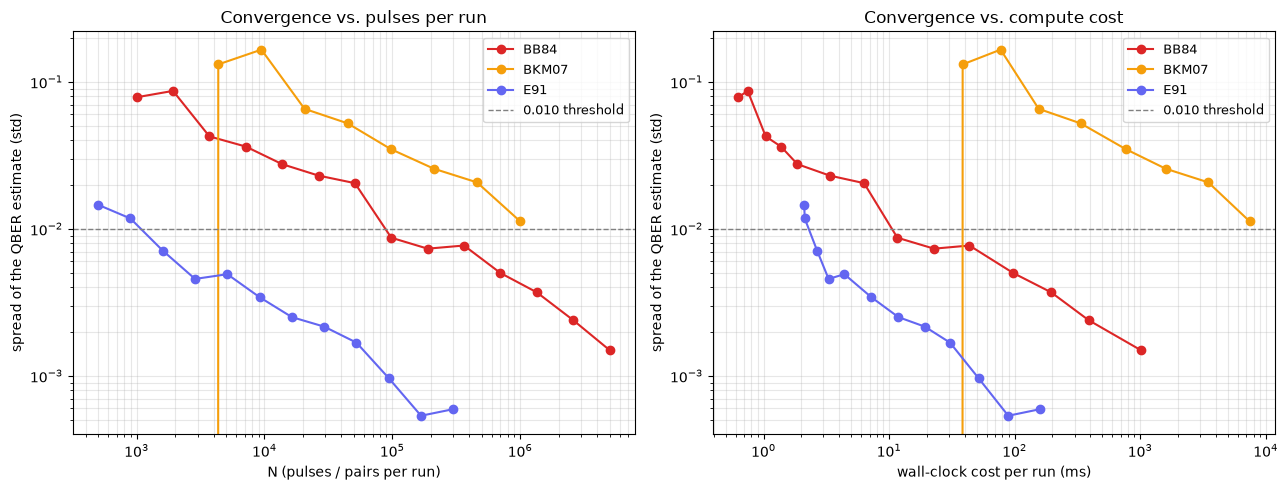


Saved: plots/qber_convergence_comparison.png


In [23]:
# ═══════════════════════════════════════════════════════════════════════════
# All three protocols, same question, same effect size: how many runs (and
# how much wall-clock) does a trustworthy QBER estimate need? Every ideal_N
# above was computed the same way (std across repeats <= EFFECT_SIZE/5,
# with mean_n_sifted >= 100), against each protocol's own exact honest-QBER
# formula -- so the comparison is apples-to-apples despite the very
# different physics behind each number.
# ═══════════════════════════════════════════════════════════════════════════

def _cost_row(name, summ, ideal_N):
    if ideal_N is not None:
        row = summ[summ['N'] == ideal_N].iloc[0]
        return dict(protocol=name, ideal_N=ideal_N, reached=True,
                    sec_per_run_at_ideal_N=row['sec_per_run'],
                    std_at_ideal_N=row['std_qber'])
    row = summ.iloc[-1]
    return dict(protocol=name, ideal_N=int(row['N']), reached=False,
                sec_per_run_at_ideal_N=row['sec_per_run'],
                std_at_ideal_N=row['std_qber'])

cost_rows = [
    _cost_row('BB84',  conv_summ,      conv_ideal_N),
    _cost_row('BKM07', bkm_conv_summ,  bkm_conv_ideal_N),
    _cost_row('E91',   e91_conv_summ,  e91_conv_ideal_N),
]
cost_df = pd.DataFrame(cost_rows)
cost_df['total_sec_for_20_repeats'] = cost_df['sec_per_run_at_ideal_N'] * 20

print("Cross-protocol convergence comparison "
      f"(target excess QBER = {EFFECT_SIZE:.2f}, same threshold for all three):")
print()
for _, r in cost_df.iterrows():
    tag = f"N={r['ideal_N']:,}" if r['reached'] else f"N={r['ideal_N']:,} (NOT YET CONVERGED)"
    print(f"  {r['protocol']:6s}  {tag:32s}  "
          f"{r['sec_per_run_at_ideal_N']*1000:7.2f} ms/run  "
          f"~{r['total_sec_for_20_repeats']:6.1f}s for a 20-repeat dataset at that N")

print()
print(f"E91 converges fastest and cheapest: no loss model at all, so the sifted "
      f"fraction is fixed regardless of scale -- {cost_df.iloc[2]['ideal_N']:,} pairs "
      f"is enough. BB84 needs ~{cost_df.iloc[0]['ideal_N']/max(cost_df.iloc[2]['ideal_N'],1):.0f}x "
      f"more pulses than E91 (exponential fibre loss competing against sifting), but "
      f"each pulse is cheap (vectorised). BKM07 is worst on BOTH axes at once: round-trip "
      f"loss (~eta_bob**2) makes each pulse far less likely to yield a usable bit than "
      f"BB84's one-way loss does, AND its simulator is a genuine per-pulse Python loop, "
      f"not vectorised -- so it pays a higher per-pulse cost for a lower per-pulse "
      f"information yield. That compounding, not just one or the other, is why it "
      f"{'needed the most pulses of the three' if bkm_conv_ideal_N else f'had not converged even by N={n_values_bkm[-1]:,}'} "
      f"in this study.")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {'BB84': '#DC2626', 'BKM07': '#F59E0B', 'E91': '#6366F1'}
summaries = {'BB84': conv_summ, 'BKM07': bkm_conv_summ, 'E91': e91_conv_summ}

ax = axes[0]
for name, s in summaries.items():
    ax.plot(s['N'], s['std_qber'], 'o-', color=colors[name], label=name)
ax.axhline(EFFECT_SIZE / 5, color='gray', linestyle='--', linewidth=1,
           label=f'{EFFECT_SIZE/5:.3f} threshold')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('N (pulses / pairs per run)')
ax.set_ylabel('spread of the QBER estimate (std)')
ax.set_title('Convergence vs. pulses per run')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')

ax = axes[1]
for name, s in summaries.items():
    ax.plot(s['sec_per_run'] * 1000, s['std_qber'], 'o-', color=colors[name], label=name)
ax.axhline(EFFECT_SIZE / 5, color='gray', linestyle='--', linewidth=1,
           label=f'{EFFECT_SIZE/5:.3f} threshold')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('wall-clock cost per run (ms)')
ax.set_ylabel('spread of the QBER estimate (std)')
ax.set_title('Convergence vs. compute cost')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('plots/qber_convergence_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("\nSaved: plots/qber_convergence_comparison.png")

---
## Section 3 -- Feature Engineering

We compress each run into a **feature
vector** -- a small set of summary statistics that capture what matters, for
each of the three protocols.

### Why temporal features?

Average QBER alone can be ambiguous: channel noise and a mild attack can
produce similar averages. But their **time profiles** differ:

- **Uniform noise** -> QBER is roughly constant across time windows (low
  dispersion, low jump energy).
- **Intercept-resend attack** -> Eve's interception can be bursty in time
  (Section 2.1's `profile` argument), creating correlations in the error
  sequence that a stationary honest channel doesn't have.
- **PNS attack** -> QBER barely changes; only the decoy-state estimators
  see it (Section 2.3).

### 3.1 -- Temporal-feature helpers (shared across all three protocols)

> 🔧 **CHANGED (Draft 2, item 4): Fix the E91 `spectral_entropy` doc/code mismatch**
>
> The docstring claimed the function returns NaN below W=64 windows; the code actually only returns NaN below 8 usable window values, and E91 (32 windows) was silently relying on that real behaviour. The comment now says what the code really does, with an explicit note on how to read the feature at small W.

In [ ]:
# ─── Helper: binary entropy (Shannon, base-2) ────────────────────────────────
def _binary_entropy(p):
    '''H(p) = -p log2(p) - (1-p) log2(1-p).'''
    p = np.clip(p, 1e-10, 1.0 - 1e-10)
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

# ─── Three temporal-shape features ───────────────────────────────────────────

def _jump_energy(x):
    '''Sum of squared consecutive differences.'''
    x = np.asarray(x, dtype=float)
    if len(x) < 2:
        return 0.0
    return float(np.sum(np.diff(x) ** 2))


def _spectral_entropy(x, drop_dc=True):
    '''Normalised Shannon entropy of the power spectrum, in [0, 1].

    RELIABILITY NOTE (Draft 2, item 4 -- doc/code mismatch fixed): with W
    windows the rfft yields floor(W/2) usable bins after dropping DC. The
    plug-in entropy estimator is strongly negatively biased for small bin
    counts (Paninski, Neural Comput. 15, 1191 (2003)). Draft 1's comment
    HERE claimed this only returns a value for W >= 64 and NaN otherwise --
    that was never what the code below does: it only returns NaN when
    fewer than 8 non-NaN window values are available (see the `len(x) < 8`
    check), which is why E91's 32-window traces (Section 3.4) got a real
    number, not NaN, despite sitting below the claimed W>=64 cutoff.
    The actual behaviour is intentional and is kept as-is here (raising
    E91's window count to remove the bias is a scale decision made
    separately for Section 5/Section 19 -- see item 8); what changed is
    only this comment, so it now says what the code actually guarantees:
    a real (but increasingly negatively-biased-as-W-shrinks) value for any
    trace with >= 8 usable windows, NaN below that. Read this feature's
    ABSOLUTE value with that bias in mind, especially for W < 64; relative
    comparisons (honest vs. attacked at the SAME W) remain valid since the
    bias is systematic and hits both classes equally at a given W.
    '''
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 8:
        return np.nan
    x = x - x.mean()
    spec = np.abs(np.fft.rfft(x)) ** 2
    if drop_dc:
        spec = spec[1:]
    tot = spec.sum()
    if tot <= 0:
        return 0.0
    p = spec / tot
    p = p[p > 0]
    if len(p) < 2:
        return np.nan
    return float(-np.sum(p * np.log2(p)) / np.log2(len(p)))


def _autocorr_lag1(x):
    '''Lag-1 autocorrelation. Near 0 = uncorrelated; positive = clustering.'''
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 3:
        return np.nan
    x0, x1 = x[:-1] - np.mean(x[:-1]), x[1:] - np.mean(x[1:])
    denom = np.sqrt(np.sum(x0 ** 2) * np.sum(x1 ** 2))
    return 0.0 if denom == 0 else float(np.sum(x0 * x1) / denom)


def _dispersion_index(window_errors, window_counts):
    '''Ratio of observed per-window QBER variance to the binomial floor.

    D = Var(Qhat) * nbar / (Qbar (1 - Qbar))

    D=1 : the QBER trace is consistent with a STATIONARY process observed
          through finite-sample noise (honest channel, or i.i.d. Eve).
    D>1 : over-dispersion -- the underlying error rate itself varies in
          time (bursty/drifting Eve, or a drifting channel).

    Replaces the raw `qber_variance`, which is a deterministic function of
    the mean QBER (measured ratio to this floor: 0.90-0.98) and therefore
    duplicates `qber_total` rather than adding information.
    '''
    we = np.asarray(window_errors, dtype=float)
    wc = np.asarray(window_counts, dtype=float)
    ok = wc > 0
    if ok.sum() < 4:
        return np.nan
    q = we[ok] / wc[ok]
    qb = we[ok].sum() / wc[ok].sum()
    nb = wc[ok].mean()
    floor = qb * (1 - qb) / nb
    return float(np.var(q, ddof=1) / floor) if floor > 0 else np.nan   # ddof=1: unbiased, so D=1 under stationarity


def _jump_energy_rel(x):
    """Review fix E6: normalised jump energy for traces without a binomial floor (E91's CHSH trace):
    sum of squared consecutive differences / its expectation for a white sequence with the same variance (~1 if stationary)."""
    x = np.asarray(x, float); x = x[~np.isnan(x)]
    if len(x) < 3: return np.nan
    v = np.var(x, ddof=1)
    return float(np.sum(np.diff(x) ** 2) / (2 * (len(x) - 1) * v)) if v > 0 else np.nan


def _z_vs_baseline(q, K, baseline):
    """Review fix B8: z-score of the run's error rate against a per-link attack-free commissioning run
    (q0 from K0 key bits): z = (q - q0) / sqrt(q0(1-q0)(1/K0 + 1/K)). 0 when no baseline is supplied."""
    if baseline is None or not np.isfinite(q): return 0.0
    q0 = float(np.clip(baseline['q0'], 1e-4, 0.5)); K0 = max(int(baseline['K0']), 1)
    return float((q - q0) / np.sqrt(q0 * (1 - q0) * (1.0 / K0 + 1.0 / max(int(K), 1))))


def _jump_energy_norm(window_errors, window_counts):
    '''Sum of squared consecutive QBER differences, normalised by the value
    expected for a white (stationary) sequence: 2*(W-1)*Qbar(1-Qbar)/nbar.
    ~1 under stationarity, >1 for abrupt transitions.'''
    we = np.asarray(window_errors, dtype=float); wc = np.asarray(window_counts, dtype=float)
    ok = wc > 0
    if ok.sum() < 3:
        return np.nan
    q = we[ok] / wc[ok]
    qb = we[ok].sum() / wc[ok].sum(); nb = wc[ok].mean()
    expected = 2 * (len(q) - 1) * qb * (1 - qb) / nb
    return float(np.sum(np.diff(q) ** 2) / expected) if expected > 0 else np.nan


# Used by the BKM07 calibration empirical check (Section 4's matched-QBER
# layer) to report a statistically correct binomial CI, rather than a
# normal approximation, on the measured qber_key.
def qber_ci(errors, total, alpha=0.05):
    '''Exact (Clopper-Pearson) confidence interval for an observed QBER.'''
    if total == 0:
        return np.nan, 0.0, 1.0
    q = errors / total
    lo = stats.beta.ppf(alpha / 2, errors, total - errors + 1) if errors > 0 else 0.0
    hi = stats.beta.ppf(1 - alpha / 2, errors + 1, total - errors) if errors < total else 1.0
    return q, float(lo), float(hi)


print("Temporal-feature helpers defined (P6: fixed spectral entropy, added dispersion index).") #bechmark: 2024-06-13

### 3.2 -- BB84 decoy-state key-rate estimators

Bob cannot count photons directly, so the true photon-number statistic is
not observable and is not a feature. What Bob *can* observe is the
**decoy-state trick**: Alice randomly varies the pulse intensity
(signal/decoy/vacuum) and Bob's gain/QBER at each intensity lets her
estimate a lower bound on the single-photon yield `Y1` and an upper bound
on its error rate `e1` (Ma et al. Eqs. 30, 33) -- exactly the
`y1_lower`/`e1_upper`/`gain_ratio_nu_mu` features BB84's feature vector
(3.3) uses to see PNS.

In [25]:
# ── Decoy-state estimators (Ma et al. 2005, Eqs. 30 and 33) ────────────────
def decoy_estimate(Q_mu, E_mu, Q_nu, E_nu, Y0_obs, mu=MU_SIGNAL, nu=MU_DECOY, e0=0.5):
    """Vacuum+Weak decoy estimation of the single-photon yield and error rate."""
    Y1L = mu / (mu * nu - nu**2) * (
        Q_nu * np.exp(nu) - Q_mu * np.exp(mu) * nu**2 / mu**2
        - (mu**2 - nu**2) / mu**2 * Y0_obs)
    Y1L = max(float(Y1L), 0.0)
    Q1L = Y1L * mu * np.exp(-mu)
    e1U = ((E_nu * Q_nu * np.exp(nu) - e0 * Y0_obs) / (Y1L * nu)) if Y1L > 0 else 0.5
    return Y1L, Q1L, float(np.clip(e1U, 0.0, 0.5))


def secure_key_rate(Q_mu, E_mu, Q1, e1, f_ec=None, q=0.5):
    """GLLP + decoy asymptotic key rate; Lo, Ma & Chen PRL 94, 230504 (2005) Eq. 1.
    ASYMPTOTIC rate, used here as a channel-state FEATURE, not a security
    guarantee -- finite-key composable security needs additional terms
    (Tomamichel et al. 2012) not computed here."""
    f_ec = GYS['f_ec'] if f_ec is None else f_ec
    return max(q * (-Q_mu * f_ec * _binary_entropy(E_mu)
                     + Q1 * (1.0 - _binary_entropy(e1))), 0.0)

### 3.3 BB84 & BKM07 feature vectors

### BB84 feature set (14 features, `BB84_FEATURE_NAMES`)

| Feature | What it measures |
|---|---|
| `qber_total` | Overall sifted error rate (signal intensity only) |
| `qber_z` / `qber_x` | Error rate within Z-basis / X-basis sifted rounds separately |
| `gain_mu` | Click probability at signal intensity -- `Q_mu` in Section 1.2's channel model |
| `sifted_rate` | Fraction of signal pulses where Alice & Bob's bases matched |
| `qber_dispersion` | Ratio of observed per-window QBER variance to the binomial noise floor -- ~1 for a stationary (honest or i.i.d.-Eve) process, >1 if the true error rate itself drifts in time |
| `jump_energy_norm` | Sum of squared consecutive per-window QBER differences, normalised by its value under stationarity -- flags abrupt-onset attacks |
| `spectral_entropy` | Normalised Shannon entropy of the per-window QBER power spectrum (0 = structured/bursty, 1 = noise-like) |
| `autocorr_lag1` | Lag-1 autocorrelation of per-window QBER -- positive if errors cluster in time |
| `y1_lower` | Decoy-state lower-bound estimate of the single-photon yield `Y1` (Ma et al. Eq. 30) |
| `e1_upper` | Decoy-state upper-bound estimate of the single-photon error rate `e1` (Eq. 33) |
| `r_secure` | GLLP+decoy asymptotic secure key rate, computed from `y1_lower`/`e1_upper` -- used here as a channel-state *feature*, not a security certificate |
| `gain_ratio_nu_mu` | Ratio of decoy-to-signal gain (adjusted for intensity) -- directly the quantity PNS distorts, since Eve cannot tell decoy pulses from signal pulses but the honest channel treats them identically |
| `h_qber` | Binary Shannon entropy `h(qber_total)` -- nearly redundant with `qber_total` itself (r~0.99), kept as a mild nonlinear transform |

### BKM07 feature set (14 features, `BKM_FEATURE_NAMES`)

BKM07 has separate forward and return legs, so we get more error channels:

| Feature | What it measures |
|---|---|
| `qber_key` | **True end-to-end key error**: `bit_A != bit_A_final` over SIFT_KEY rounds -- the actual round-trip error a real deployment would report |
| `qber_zs` | Forward-leg + re-preparation error (Bob's SIFT measurement composed with his re-preparation flip; NOT the full round trip -- see `qber_key`) |
| `qber_zsr` | Additional return-leg error on top of `qber_zs` (`bit_B != bit_A_final`) |
| `ret_monitor` | Return-leg error rate on X-basis SIFT rounds -- protocol-discarded for key material, kept only as an auxiliary channel monitor |
| `qber_zc` / `qber_xc` | Z-basis / X-basis CTRL-round error rate (Alice checks her own reflected photon) |
| `asymmetry` | `abs(qber_zsr - qber_zs)` -- signature of a return-leg-heavy attack |
| `ctrl_sift_ratio` | Average CTRL error rate relative to the SIFT forward-leg error rate |
| `xctrl_dispersion` | Ratio of per-window CTRL-X QBER variance to the binomial floor (BB84's `qber_dispersion`, applied to the CTRL-X monitor trace) |
| `jump_energy` | Temporal jump energy of the CTRL-X QBER trace |
| `spectral_entropy` | Spectral entropy of the CTRL-X QBER trace |
| `autocorr_lag1` | Lag-1 autocorrelation of the CTRL-X QBER trace |
| `h_ctrl` | Binary Shannon entropy of the average CTRL error rate |
| `sifted_rate` | Fraction of round trips that produced a SIFT_KEY round |

> 🔧 **CHANGED (Draft 2, item 7): collect_bkm07_features now uses the vectorised simulator**
>
> Same feature definitions and docstring as Draft 1, only the inner loop changed: calls simulate_bkm07_batch() once instead of simulate_bkm07_pulse() N times.

> 🔧 **CHANGED (Draft 2, item 8): collect_bb84_features / collect_bkm07_features gain equal-information sampling**
>
> Both now accept target_k_signal_bits / target_k_key_rounds as an alternative to a fixed N: the pulse count is sized from the closed-form channel model so every run nets roughly the SAME number of usable key events, whatever the distance -- and returns the actually achieved count. Existing callers that still pass a fixed N are untouched. Section 5's main datasets and Section 19's benchmark are rewritten below to use this.

In [ ]:
# ─── Full feature-extraction functions ───────────────────────────────────────

# BB84_FEATURE_NAMES replaces the old 10-feature list.
#    h_qber -- it is the binary Shannon entropy h(Q),
#    (r=0.99 with qber_total -- near-redundant).
#   qber_dispersion (ratio to the binomial
#     floor; not confounded with the mean, unlike raw variance).
#   decoy-state observables (y1_lower, e1_upper, r_secure,
#     gain_ratio_nu_mu) -- the physically correct PNS detectors.
BB84_BASE_FEATURES = [
    'qber_total', 'qber_z', 'qber_x',
    'gain_mu', 'sifted_rate',
    'qber_dispersion', 'jump_energy_norm', 'spectral_entropy', 'autocorr_lag1',
    'y1_lower', 'e1_upper', 'r_secure', 'gain_ratio_nu_mu',
    'h_qber',
]
# review fixes B6/B8: + link-budget expectation and per-link baseline z-score
BB84_FEATURE_NAMES = BB84_BASE_FEATURES + ['gain_vs_expected', 'z_qber']


def _truncate_bb84_run(run, K):
    """Review fix C3: cut a run at the pulse where the K-th sifted SIGNAL bit occurs, so every run carries exactly K
    key bits (equal information) instead of 1.3K +- noise; recomputes the per-intensity gains/QBERs."""
    s = run['sift'] & (run['k'] == 0); cs = np.cumsum(s)
    if len(cs) == 0 or cs[-1] < K: return run, int(run['N'])
    cut = int(np.searchsorted(cs, K)) + 1
    r = dict(run); N0 = run['N']
    for key in ('bit_A', 'bit_B', 'bas_A', 'bas_B', 'n', 'k', 'click', 'sift'): r[key] = run[key][:cut]
    e0 = run['theory']['e_0']; Q, E, counts = {}, {}, {}
    for j, m in enumerate(run['intensities']):
        sel = (r['k'] == j); s2 = sel & r['sift']
        counts[m] = int(sel.sum()); Q[m] = float(r['click'][sel].mean()) if sel.any() else 0.0
        E[m] = float((r['bit_A'][s2] != r['bit_B'][s2]).mean()) if s2.any() else e0
    r.update(N=cut, Q=Q, E=E, counts=counts)
    return r, cut


def _truncate_bkm07(b, K):
    """Review fix C3 for BKM07: cut at the K-th SURVIVED SIFT_KEY round."""
    key = b['survived'] & (b['round_type'] == 'SIFT_KEY'); cs = np.cumsum(key)
    if len(cs) == 0 or cs[-1] < K: return b, len(key)
    cut = int(np.searchsorted(cs, K)) + 1
    return {k: (v[:cut] if isinstance(v, np.ndarray) and v.shape[:1] == (len(key),) else v) for k, v in b.items()}, cut


def collect_bb84_features(N=None, distance_km=0.0, eve_mode='none', eve_intensity=0.0,
                           profile='iid', pns_strategy=None, n_windows=64,
                           rng=None, target_k_signal_bits=None, k_margin=K_MARGIN,
                           max_pulses=20_000_000, mean_burst=None, baseline=None, truncate=True, **chan):
    '''Run N BB84 pulses through the physical channel (P1/P2) and compress
    into the BB84_FEATURE_NAMES feature vector, via the vectorised
    decoy-state simulator (P5).

    Draft 2, item 8: pass `target_k_signal_bits=K` instead of `N` to size N
    automatically from the closed-form channel model so the run nets
    approximately K sifted SIGNAL bits regardless of distance -- the
    equal-information sampling rule used by Section 5's main datasets and
    Section 19's rebuilt benchmark. N is still accepted directly for every
    other caller (Section 16's N x W sensitivity study, Section 4's
    calibration checks, etc.), which keep Draft 1's fixed-N behaviour
    unchanged. Either way the returned dict now also carries the ACTUALLY
    achieved counts under underscore-prefixed keys -- '_k_achieved' /
    '_N_used' -- which are never treated as physics features
    (BB84_FEATURE_NAMES doesn't list them) but feed the leakage audit's
    real N_per_run and the AUC-vs-key-rounds plot (item 6).
    '''
    rng = rng or np.random.default_rng()
    N_capped = False
    if target_k_signal_bits is not None:
        _ch_est = channel_model(distance_km, **chan)
        _rate = DECOY_PROBS[0] * _ch_est['gain'] * 0.5   # signal share x gain x basis-match prob
        _N_wanted = int(np.ceil(target_k_signal_bits / max(_rate, 1e-15) * k_margin))
        N, N_capped = min(_N_wanted, max_pulses), _N_wanted > max_pulses   # Draft 2.1: cap is now REPORTED
    elif N is None:
        raise ValueError("collect_bb84_features needs either N or target_k_signal_bits")

    # Final draft: burst length scales with the run (~1/16 of it). The fixed 2,000-pulse default was
    # shorter than one analysis window by orders of magnitude at N ~ 1e6-2e7, so 'bursty' attacks were
    # statistically iid and the temporal features had nothing to detect.
    _mb = mean_burst if mean_burst is not None else max(2000, int(N) // 16)
    run = simulate_bb84_decoy(N, distance_km, eve_mode, eve_intensity,
                               profile=profile, pns_strategy=pns_strategy,
                               rng=rng, mean_burst=_mb, **chan)

    N_gen = int(N)
    if truncate and target_k_signal_bits is not None:
        run, N = _truncate_bb84_run(run, target_k_signal_bits)
    bit_A, bit_B = run['bit_A'], run['bit_B']
    bas_A, sift = run['bas_A'], run['sift']
    is_sig = (run['k'] == 0)          # signal-intensity pulses only
    s = sift & is_sig
    sz = s & (bas_A == 0); sx = s & (bas_A == 1)

    qber_total = float((bit_A[s] != bit_B[s]).mean()) if s.any() else 0.0
    qber_z = float((bit_A[sz] != bit_B[sz]).mean()) if sz.any() else 0.0
    qber_x = float((bit_A[sx] != bit_B[sx]).mean()) if sx.any() else 0.0
    gain_mu = run['Q'][run['intensities'][0]]
    sifted_rate = float(s.sum() / max(is_sig.sum(), 1))

    # window loop keeps (error_count, sifted_count) per window, not a
    # bare ratio -- the dispersion index needs the counts to compute the
    # binomial floor. Parameterised by NUMBER OF WINDOWS, not pulses per
    # window, so a fixed window count gives comparable estimator variance
    # regardless of distance/loss.
    edges = np.linspace(0, N, n_windows + 1, dtype=int)
    w_err, w_cnt = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = s[lo:hi]
        w_cnt.append(int(m.sum()))
        w_err.append(int((bit_A[lo:hi][m] != bit_B[lo:hi][m]).sum()))
    w_err, w_cnt = np.array(w_err), np.array(w_cnt)
    with np.errstate(invalid='ignore', divide='ignore'):
        wq = np.where(w_cnt > 0, w_err / np.maximum(w_cnt, 1), np.nan)

    # Decoy-state block (P5's estimators)
    mu_s, mu_d, mu_v = run['intensities']
    Y0_obs = run['Q'][mu_v]
    y1, q1, e1 = decoy_estimate(run['Q'][mu_s], run['E'][mu_s],
                                 run['Q'][mu_d], run['E'][mu_d],
                                 Y0_obs, mu=mu_s, nu=mu_d)
    r_sec = secure_key_rate(run['Q'][mu_s], run['E'][mu_s], q1, e1)
    ratio = float((run['Q'][mu_d] * np.exp(mu_d)) /
                  max(run['Q'][mu_s] * np.exp(mu_s), 1e-18))

    return {
        'qber_total': qber_total,
        'qber_z': qber_z,
        'qber_x': qber_x,
        'gain_mu': float(gain_mu),
        'sifted_rate': sifted_rate,
        'qber_dispersion': _dispersion_index(w_err, w_cnt),
        'jump_energy_norm': _jump_energy_norm(w_err, w_cnt),
        'spectral_entropy': _spectral_entropy(wq),
        'autocorr_lag1': _autocorr_lag1(wq[~np.isnan(wq)]),
        'y1_lower': float(y1),
        'e1_upper': float(e1),
        'r_secure': float(r_sec),
        'gain_ratio_nu_mu': ratio,
        'h_qber': float(_binary_entropy(qber_total)),
        # review fix B6: link-budget expectation as an input -- observed gain / gain expected at this distance, so a lower
        # click rate caused by blocking is distinguishable from a longer fibre.
        'gain_vs_expected': float(gain_mu / max(channel_model(distance_km, **chan)['gain'], 1e-18)),
        # review fix B8: z-score against the per-link commissioning baseline.
        'z_qber': _z_vs_baseline(qber_total, int(s.sum()), baseline),
        '_k_achieved': int(s.sum()),   # Draft 2, item 8/6: sifted signal bits actually obtained
        '_N_used': int(N_gen),
        '_N_trunc': int(N),
        '_N_capped': bool(N_capped),   # Draft 2.1: True => max_pulses cut the run short of the requested K
    }


def collect_bkm07_features(N=None, distance_km=0.0, eve_mode='none', eve_fwd=0.0, eve_ret=0.0,
                            n_windows=64, rng=None, target_k_key_rounds=None, k_margin=K_MARGIN,
                            max_pulses=15_000_000, baseline=None, truncate=True, **chan):
    '''Run N BKM07 round trips and compress into a feature vector.

    Alice measures SIFT returns in her OWN preparation basis
    (not always Z); X-SIFT rounds are protocol-discarded and kept only as
    an auxiliary `ret_monitor` (renamed from `qber_xsr`, which the previous
    version reported as if it were a protocol observable -- it was not:
    Bob re-prepares in Z, Alice measured in Z, so it measured only
    return-leg channel noise); the channel is applied TWICE (round trip:
    t^2, not t); `xctrl_variance` replaced by a dispersion index (P6/P11).

    Draft 2, item 7: rewritten to call the vectorised `simulate_bkm07_batch`
    instead of looping `simulate_bkm07_pulse` N times in pure Python --
    same physics, same feature definitions, just array arithmetic instead
    of a per-pulse loop (see the callout above `simulate_bkm07_batch`).

    Draft 2, item 8: pass `target_k_key_rounds=K` instead of `N` to size N
    from (round-trip survival)^2 x (SIFT_KEY share of survivors) so the run
    nets approximately K SIFT_KEY rounds regardless of distance -- now
    affordable at the K this notebook uses (2,000) precisely because of the
    item-7 vectorisation above. Returns '_k_achieved' / '_N_used' the same
    way collect_bb84_features does (see its docstring).
    '''
    rng = rng or np.random.default_rng()
    N_capped = False
    if target_k_key_rounds is not None:
        _ch_est = channel_model(distance_km, **chan)
        _rate = (_ch_est['eta'] ** 2) * 0.25   # round-trip survival x SIFT_KEY share
        _N_wanted = int(np.ceil(target_k_key_rounds / max(_rate, 1e-15) * k_margin))
        N, N_capped = min(_N_wanted, max_pulses), _N_wanted > max_pulses   # Draft 2.1: cap is now REPORTED
    elif N is None:
        raise ValueError("collect_bkm07_features needs either N or target_k_key_rounds")

    b = simulate_bkm07_batch(N, distance_km, eve_mode, eve_fwd, eve_ret, rng=rng, **chan)
    N_gen = int(N)
    if truncate and target_k_key_rounds is not None:
        b, N = _truncate_bkm07(b, target_k_key_rounds)
    surv = b['survived']
    rt = b['round_type']
    bit_A, bit_B, bit_Af = b['bit_A'], b['bit_B'], b['bit_A_final']

    z_sft = surv & (rt == 'SIFT_KEY')
    x_sft = surv & (rt == 'SIFT_MONITOR')
    z_ctrl = surv & (rt == 'CTRL_Z')
    x_ctrl = surv & (rt == 'CTRL_X')
    z_sft_t, x_sft_t = int(z_sft.sum()), int(x_sft.sum())
    z_ctrl_t, x_ctrl_t = int(z_ctrl.sum()), int(x_ctrl.sum())

    qber_zs = float((bit_A[z_sft] != bit_B[z_sft]).mean()) if z_sft_t else 0.0
    # True end-to-end round-trip key error (bit_A vs bit_A_final): the
    # quantity a real BKM07 deployment reports as key QBER. qber_zs above
    # is NOT this -- it's a 2-flip composite (Bob's measurement noise +
    # his re-preparation flip) because `bit_B` is the POST-re-preparation
    # value. This was missing before.
    qber_key = float((bit_A[z_sft] != bit_Af[z_sft]).mean()) if z_sft_t else 0.0
    qber_zsr = float((bit_B[z_sft] != bit_Af[z_sft]).mean()) if z_sft_t else 0.0
    ret_monitor = float((bit_B[x_sft] != bit_Af[x_sft]).mean()) if x_sft_t else 0.0  # was qber_xsr
    qber_zc = float((bit_A[z_ctrl] != bit_Af[z_ctrl]).mean()) if z_ctrl_t else 0.0
    qber_xc = float((bit_A[x_ctrl] != bit_Af[x_ctrl]).mean()) if x_ctrl_t else 0.0

    asymmetry = abs(qber_zsr - qber_zs)
    ctrl_sift_ratio = float((qber_zc + qber_xc) / 2.0) / max(qber_zs, 1e-9)

    # Windowed CTRL_X trace, binned by POSITION AMONG SURVIVORS (boolean
    # indexing preserves original pulse order, matching the scalar
    # version's temporal ordering of its filtered `pulses` list).
    N_eff = max(int(surv.sum()), 1)
    rt_s, err_s = rt[surv], (bit_A[surv] != bit_Af[surv])
    is_ctrl_x = (rt_s == 'CTRL_X')
    err_ctrl_x = err_s & is_ctrl_x
    edges = np.linspace(0, N_eff, n_windows + 1, dtype=int)
    w_err, w_cnt = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        w_cnt.append(int(is_ctrl_x[lo:hi].sum()))
        w_err.append(int(err_ctrl_x[lo:hi].sum()))
    w_err, w_cnt = np.array(w_err), np.array(w_cnt)
    with np.errstate(invalid='ignore', divide='ignore'):
        wq = np.where(w_cnt > 0, w_err / np.maximum(w_cnt, 1), np.nan)

    qber_ctrl_avg = (qber_zc + qber_xc) / 2.0

    return {
        'qber_key': qber_key,
        'qber_zs': qber_zs,
        'qber_zsr': qber_zsr,
        'ret_monitor': ret_monitor,     # was 'qber_xsr' (P10 rename)
        'qber_zc': qber_zc,
        'qber_xc': qber_xc,
        'asymmetry': asymmetry,
        'ctrl_sift_ratio': ctrl_sift_ratio,
        'xctrl_dispersion': _dispersion_index(w_err, w_cnt),
        'jump_energy': _jump_energy_norm(w_err, w_cnt),   # review fix E6: normalised, same statistic as BB84
        'spectral_entropy': _spectral_entropy(wq),
        'autocorr_lag1': _autocorr_lag1(wq[~np.isnan(wq)]),
        'h_ctrl': float(_binary_entropy(qber_ctrl_avg)),   # was 'holevo_ie'
        'sifted_rate': z_sft_t / N_eff,
        'z_qber_ctrl': _z_vs_baseline(qber_ctrl_avg, z_ctrl_t + x_ctrl_t, baseline),   # review fix B8
        '_qber_ctrl_avg': float(qber_ctrl_avg), '_n_ctrl': int(z_ctrl_t + x_ctrl_t),
        '_k_achieved': int(z_sft_t),   # Draft 2, item 8/6: SIFT_KEY rounds actually obtained
        '_N_used': int(N_gen),
        '_N_trunc': int(N),
        '_N_capped': bool(N_capped),   # Draft 2.1: True => max_pulses cut the run short of the requested K
    }


def bb84_k_capacity(distance_km, max_pulses=20_000_000, k_margin=K_MARGIN, **chan):
    """Largest `target_k_signal_bits` collect_bb84_features can deliver at this distance
    WITHOUT hitting its max_pulses cap (Draft 2.1). Cross-protocol comparisons that claim equal
    information must not ask for more K than BB84 can supply at the calibrated distance."""
    rate = DECOY_PROBS[0] * channel_model(distance_km, **chan)['gain'] * 0.5
    return int(np.floor(max_pulses * rate / k_margin))


BKM_FEATURE_NAMES = ['qber_key', 'qber_zs', 'qber_zsr', 'ret_monitor', 'qber_zc', 'qber_xc',
                      'asymmetry', 'ctrl_sift_ratio', 'xctrl_dispersion',
                      'jump_energy', 'spectral_entropy', 'autocorr_lag1',
                      'h_ctrl', 'sifted_rate', 'z_qber_ctrl']

print("Feature-extraction functions defined (BB84 decoy+dispersion; BKM07 round-fix).")

### 3.4 -- E91 feature vector


E91 gives a second aggregate statistic BB84/BKM07 don't have -- the CHSH
value `S` -- but averaging either `S` or QBER over a whole run can still
miss a bursty or basis-anisotropic attack:

- **Intercept-resend** -> `S` collapses toward the classical bound *and*
  QBER rises together, in a way consistent with the honest depolarisation
  curve (see `s_qber_residual` below) -- this is what makes it hard to
  separate from ordinary channel noise using `S`/QBER aggregates alone.
- **Entangling-ancilla probe** -> costs disproportionately *more* QBER than
  it costs `S`, because it dephases anisotropically rather than
  depolarising the state -- `s_qber_residual` is built specifically to
  catch this.
- **Asymmetric arm-loss manipulation** -> looks similar to honest
  visibility reduction at the aggregate level; separable mainly via its
  distinct effect on `sifted_rate` and its temporal profile.

### E91 feature set (10 features, `E91_FEATURE_NAMES`)

| Feature | Formula / idea |
|---|---|
| `qber_key` | Error rate in matching-angle, key-generating rounds -- `(a2,b1)`, `(a3,b2)` |
| `chsh_S` | Measured CHSH statistic from the four non-matching test-angle combinations |
| `s_deviation` | `abs(2*sqrt(2) - abs(chsh_S))` -- distance below the Tsirelson bound |
| `s_qber_residual` | Deviation of measured `abs(S)` from the honest-depolarisation curve `2*sqrt(2)*(1-2*qber_key)` -- near 0 for honest noise *and* basis-averaged intercept-resend, but distinctly nonzero for the basis-anisotropic ancilla attack |
| `per_pair_corr_spread` | max - min across the four individual `E(a_i,b_j)` correlations feeding `S` -- an attack biased toward one angle setting hides in the aggregate but stands out here |
| `jump_energy` | Sum of squared consecutive per-window `chsh_S` differences -- penalises sudden-onset attacks |
| `spectral_entropy` | Normalised Shannon entropy of the per-window QBER power spectrum |
| `autocorr_lag1` | Lag-1 autocorrelation of per-window `qber_key` |
| `h_qber_key` | Binary Shannon entropy `h(qber_key)` |
| `sifted_rate` | Fraction of pairs landing on a matching (key-generating) angle combination |

(`generate_e91_dataset` below also records `attack_duty_cycle` and `V` per
row -- the former as a channel-state convenience for later analysis

> 🔧 **CHANGED (Draft 2, item 8): extract_e91_features gains equal-information sampling**
>
> Accepts target_k_key_pairs=K as an alternative to n_pulses, sized from the fixed 2/9 key-pair probability under uniform random settings. Returns the achieved count.

> ✨ **NEW (Draft 2, item 10): E91 device-independent secure key rate**
>
> e91_di_secure_key_rate() implements the CHSH-based DI-QKD rate bound of Acin et al. (PRL 98, 230501, 2007), using the qber_key/chsh_S this notebook already computes. Added as a new feature 'r_secure_di' (below), mirroring how BB84's r_secure is already used -- any attack that lowers |S| or raises the QBER lowers it, so it is genuine physics signal, not just a reporting number. The validation print also flags that honest E91 runs with low visibility (V below roughly 0.857 in this notebook's V~U(0.85,0.99) draw) cannot support a device-independent key at all, attack or no attack -- worth knowing when reading any E91 result.

In [ ]:
# ---------------------------------------------------------------------
# Device-independent secure key rate (Draft 2, item 10)
# ---------------------------------------------------------------------
def e91_di_secure_key_rate(Q, S):
    """CHSH-based device-independent secure key rate lower bound
    (Acin, Brunner, Gisin, Massar, Pironio & Scarani, PRL 98, 230501,
    2007): r >= 1 - h(Q) - h( [1 + sqrt((S/2)^2 - 1)] / 2 ), where Q is
    the key-basis QBER and S the CHSH value.

    Requires |S| > 2 for the sqrt term to be real -- below that the
    correlations are compatible with a purely classical (local hidden
    variable) model and NO device-independent key is possible at all
    (Eve could in principle know everything), so the rate is clamped to
    0 rather than returning a complex/undefined value.

    ASYMPTOTIC rate, same caveat as secure_key_rate() in Section 3.2: a
    channel-state FEATURE here (any attack that lowers |S| or raises Q
    lowers it), not a finite-key composable security bound -- real
    device-independent QKD needs substantially more machinery (see
    Pironio et al., New J. Phys. 11, 045021, 2009, for the finite-key
    treatment)."""
    S = abs(S)
    if not np.isfinite(Q) or not np.isfinite(S) or S <= 2.0:
        return 0.0
    inner = (S / 2.0) ** 2 - 1.0
    if inner < 0:
        return 0.0
    p_err_eve = (1.0 + np.sqrt(inner)) / 2.0
    r = 1.0 - _binary_entropy(Q) - _binary_entropy(p_err_eve)
    return float(max(r, 0.0))


# Validation: at the honest-channel curve |S| = 2*sqrt(2)*V, Q = (1-V)/2,
# find where the DI rate hits zero -- below this visibility, even an
# HONEST E91 link (no Eve at all) cannot produce a device-independent key.
_V_grid = np.linspace(0.80, 1.0, 4001)
_rates_at_V = np.array([e91_di_secure_key_rate((1 - v) / 2, TSIRELSON_BOUND * v) for v in _V_grid])
_V_critical = float(_V_grid[_rates_at_V > 0][0]) if (_rates_at_V > 0).any() else float('nan')
print(f"E91 device-independent SKR: r=0 below V~={_V_critical:.4f} (honest QBER "
      f"{(1 - _V_critical) / 2:.4f}) on the honest-channel curve -- our honest-noise "
      f"draw is V~Uniform(0.85, 0.99), so the noisiest slice of it (V < {_V_critical:.3f}) "
      f"cannot support a DI key even with no attack at all.")


# ---------------------------------------------------------------------
# Full feature extraction for one run (P9: 4 leaking features removed,
# s_qber_residual added; Draft 2 item 10: r_secure_di added)
# ---------------------------------------------------------------------
def extract_e91_features(n_pulses=2000, eve_mode="none", n_windows=20, rng=None,
                          eve_intensity=0.0, lam=0.3, profile='iid', V=None,
                          target_k_key_pairs=None, k_margin=K_MARGIN, baseline=None, truncate=True):
    """Draft 2, item 8: pass `target_k_key_pairs=K` instead of `n_pulses` to
    size n_pulses so the run nets approximately K key pairs (settings
    a2-b1/a3-b2, which occur with probability 2/9 under the uniform random
    setting choice) -- the same equal-information rule as
    collect_bb84_features / collect_bkm07_features. n_pulses is still
    accepted directly for every other caller. Returns '_k_achieved' /
    '_N_used' the same way."""
    rng = rng or np.random.default_rng()
    if target_k_key_pairs is not None:
        n_pulses = max(int(np.ceil(target_k_key_pairs / (2.0 / 9.0) * k_margin)), 500)
    V = sample_e91_channel(rng) if V is None else V

    a_choice, b_choice, r_a, r_b = run_e91(n_pulses, V=V, eve_mode=eve_mode,
                                            eve_intensity=eve_intensity, lam=lam,
                                            profile=profile, rng=rng)
    _n_gen = int(n_pulses)
    if truncate and target_k_key_pairs is not None:      # review fix C3: exactly K key pairs
        _km = np.isin(np.char.add(a_choice, b_choice), [_a + _b for _a, _b in KEY_PAIRS]); _cs = np.cumsum(_km)
        if _cs[-1] >= target_k_key_pairs:
            _cut = int(np.searchsorted(_cs, target_k_key_pairs)) + 1
            a_choice, b_choice, r_a, r_b = a_choice[:_cut], b_choice[:_cut], r_a[:_cut], r_b[:_cut]; n_pulses = _cut
    qber_trace, chsh_trace = windowed_traces(a_choice, b_choice, r_a, r_b, n_windows)

    qber_key = window_qber(a_choice, b_choice, r_a, r_b, 0, n_pulses)
    chsh_s = window_chsh(a_choice, b_choice, r_a, r_b, 0, n_pulses)

    corrs = []
    for ac, bc in CHSH_PAIRS:
        m = (a_choice == ac) & (b_choice == bc)
        corrs.append(np.mean(r_a[m] * r_b[m]) if m.sum() else np.nan)
    per_pair_corr_spread = float(np.nanmax(corrs) - np.nanmin(corrs))

    sifted_rate = float(np.mean([
        ((a_choice == ac) & (b_choice == bc)).sum() for ac, bc in KEY_PAIRS
    ]) / n_pulses * len(KEY_PAIRS))

    # s_qber_residual -- physics-derived anisotropy detector.
    # Honest depolarisation obeys |S| = 2*sqrt(2)*(1-2Q); deviation from
    # that curve indicates an ANISOTROPIC disturbance (e.g. an entangling
    # probe), as opposed to ordinary white noise. Measured: ~0 for honest
    # channels AND for basis-averaged intercept-resend; +0.16 to +0.28 for
    # ancilla attacks.
    if not np.isnan(chsh_s) and not np.isnan(qber_key):
        s_pred = TSIRELSON_BOUND * (1 - 2 * qber_key)
        s_qber_residual = float(abs(chsh_s) - s_pred)
    else:
        s_qber_residual = np.nan

    features = {
        "qber_key": qber_key,
        "chsh_S": chsh_s,
        "s_deviation": abs(TSIRELSON_BOUND - abs(chsh_s)) if not np.isnan(chsh_s) else np.nan,
        "s_qber_residual": s_qber_residual,
        "per_pair_corr_spread": per_pair_corr_spread,
        "jump_energy": float(_jump_energy_rel(chsh_trace)),   # review fix E6: normalised
        "spectral_entropy": float(spectral_entropy(qber_trace)),
        "autocorr_lag1": float(autocorr_lag1(qber_trace)),
        "h_qber_key": float(binary_entropy(qber_key)) if not np.isnan(qber_key) else np.nan,
        "sifted_rate": sifted_rate,
        "attack_duty_cycle": eve_intensity if eve_mode != 'none' else 0.0,
        "V": V,
        "r_secure_di": e91_di_secure_key_rate(qber_key, chsh_s) if not (np.isnan(qber_key) or np.isnan(chsh_s)) else 0.0,
        "z_qber_key": _z_vs_baseline(qber_key, int(np.isin(np.char.add(a_choice, b_choice), [_a + _b for _a, _b in KEY_PAIRS]).sum()), baseline),   # review fix B8
    }
    _key_mask = np.isin(np.char.add(a_choice, b_choice), [_a + _b for _a, _b in KEY_PAIRS])
    features["_k_achieved"] = int(_key_mask.sum())   # Draft 2, item 8/6: key pairs actually obtained
    features["_N_used"] = int(_n_gen)
    features["_N_trunc"] = int(n_pulses)
    return features

> ✨ **NEW (Draft 2, item 11): BKM07 secure key rate -- blocked, documented honestly**
>
> See the cell below for why: this environment's network policy blocks the only sources (arxiv.org, link.springer.com) for the actual Krawec bound, and no number is inserted without having read it.

**Item 11 (BKM07 secure key rate): not implemented -- honestly, not approximately.**

The plan was to implement a published semi-quantum key-rate bound (Krawec and
collaborators) for BKM07, after reading it carefully enough to state its
assumptions correctly. That reading could not happen in this session: this
environment's network policy blocks outbound access to arxiv.org and to
link.springer.com (both attempts returned `EGRESS_BLOCKED`), which is where
every candidate paper lives -- among them W. O. Krawec, *Security Proof of a
Semi-Quantum Key Distribution Protocol* (extended version, arXiv:1412.0282,
also IEEE ISIT 2015), and *Security of a Semi-Quantum Protocol Where
Reflections Contribute to the Secret Key* (arXiv:1510.07181 /
Quantum Inf. Process. 15, 4577 (2016)) -- the second title in particular
looks like the right match for BKM07's structure, since its CTRL rounds are
exactly a reflection used for monitoring rather than key generation.

Rather than invent a plausible-looking formula and attribute it to Krawec
without having actually read the paper, this notebook leaves BKM07's secure
key rate out entirely. Filling it in needs either: (a) this environment's
network access widened to include arxiv.org/link.springer.com so the actual
bound can be read and cited correctly, or (b) the paper fetched externally
and its formula (with its exact assumptions -- collective vs. individual
attacks, asymptotic vs. finite-key, which of BKM07's round types the bound
actually uses) pasted in for implementation. E91's device-independent rate
above was implementable without this problem because its formula (Acin et
al., PRL 98, 230501, 2007) was already known with enough confidence to state
directly.

> 🔧 **CHANGED (Draft 2, item 10): E91_FEATURE_NAMES gains r_secure_di (10 -> 11 features)**
>
> The device-independent secure key rate is now a genuine 11th E91 feature, not just a reported number.

In [ ]:
E91_FEATURE_NAMES = ['qber_key', 'chsh_S', 's_deviation', 's_qber_residual',
                      'per_pair_corr_spread', 'jump_energy', 'spectral_entropy',
                      'autocorr_lag1', 'h_qber_key', 'sifted_rate',
                      'r_secure_di', 'z_qber_key']  # review fix B8: + per-link baseline z-score
E91_CHSH_ONLY_NAMES = ['chsh_S']

print("E91 feature-extraction functions defined.")

> 🔧 **CHANGED (Draft 2, item 8): generate_e91_dataset gains target_k_key_pairs**
>
> Threads the new equal-information sizing through to every run in the dataset.

In [ ]:
# ---------------------------------------------------------------------
# Dataset generator (labeled, for classifier training)
# eve_modes updated per P9 / audit Sec. D.3: drop detector_blind/pns
# (label-conditioned constructs), add ancilla (entangling probe) and
# loss_manipulation (asymmetric arm loss).
# ---------------------------------------------------------------------
def generate_e91_dataset(n_runs_per_mode=100, n_pulses=2000, n_windows=20,
                          eve_modes=("none", "intercept_resend", "ancilla", "extra_depolarisation"),
                          seed_role='e91_run', target_k_key_pairs=None):
    """Draft 2, item 8: pass target_k_key_pairs=K to switch every run in
    this dataset to equal-information sampling (see
    extract_e91_features); n_pulses is ignored when it is set."""
    rows = []
    for mode in eve_modes:
        for i in range(n_runs_per_mode):
            rng = SEEDS.rng(seed_role, i) if mode == "none" else SEEDS.rng(seed_role + '_' + mode, i)
            intensity = log_uniform(rng, 0.02, 0.9) if mode != "none" else 0.0
            profile = 'bursty' if (mode == 'intercept_resend' and rng.random() < 0.5) else 'iid'
            V = sample_e91_channel(rng)       # the link's visibility: shared by this row and its commissioning run
            _c = extract_e91_features(n_pulses=n_pulses, eve_mode='none', n_windows=n_windows, rng=SEEDS.rng(f'e91_commission_{mode}', i), V=V,
                                      target_k_key_pairs=COMMISSION_K if target_k_key_pairs else None)       # review fix B8
            feats = extract_e91_features(n_pulses=n_pulses, eve_mode=mode,
                                          n_windows=n_windows, rng=rng, V=V,
                                          eve_intensity=intensity, profile=profile,
                                          target_k_key_pairs=target_k_key_pairs,
                                          baseline=dict(q0=_c['qber_key'], K0=_c['_k_achieved']))
            feats["label"] = mode; feats["profile"] = profile; feats["run_index"] = i; feats["group_id"] = i   # review fix A5
            rows.append(feats)
    return pd.DataFrame(rows)

**Feature-vector validation.** One run per attack mode, at a fixed,
strong attack intensity -- checking that `s_qber_residual` genuinely
separates the anisotropic `ancilla` attack from ordinary noise, as
Section 2.1 claimed.

In [30]:
print("\nSingle-run feature vectors, one per attack mode:\n")
_demo_feats = {}
for mode in ["none", "intercept_resend", "ancilla", "loss_manipulation"]:
    f = extract_e91_features(n_pulses=200_000, eve_mode=mode, n_windows=20,
                              rng=np.random.default_rng(42), eve_intensity=0.5, V=0.95)
    _demo_feats[mode] = f
    print(f"--- eve_mode = {mode} ---")
    for k, v in f.items():
        print(f"  {k:26s}: {v:.4f}" if isinstance(v, float) else f"  {k:26s}: {v}")
    print()

print(f"chsh_S -- none={_demo_feats['none']['chsh_S']:.4f}  "
      f"intercept_resend={_demo_feats['intercept_resend']['chsh_S']:.4f}  "
      f"ancilla={_demo_feats['ancilla']['chsh_S']:.4f}  "
      f"loss_manipulation={_demo_feats['loss_manipulation']['chsh_S']:.4f}  "
      f"(Tsirelson bound = {TSIRELSON_BOUND:.4f}, classical bound = 2)")
print(f"s_qber_residual -- none={_demo_feats['none']['s_qber_residual']:.4f}  "
      f"intercept_resend={_demo_feats['intercept_resend']['s_qber_residual']:.4f}  "
      f"ancilla={_demo_feats['ancilla']['s_qber_residual']:.4f}  "
      "(expect ancilla >> the other two -- it is basis-anisotropic, they are not)")
assert abs(_demo_feats['ancilla']['s_qber_residual']) > abs(_demo_feats['none']['s_qber_residual']), "ancilla attack should show a larger s_qber_residual than honest noise"
print("PASS -- simulator behaves correctly, safe to build features on top of it.")


Single-run feature vectors, one per attack mode:



--- eve_mode = none ---
  qber_key                  : 0.0259
  chsh_S                    : -2.6868
  s_deviation               : 0.1416
  s_qber_residual           : 0.0051
  per_pair_corr_spread      : 1.3441
  jump_energy               : 0.0462
  spectral_entropy          : 0.7627
  autocorr_lag1             : 0.4162
  h_qber_key                : 0.1736
  sifted_rate               : 0.2226
  attack_duty_cycle         : 0.0000
  V                         : 0.9500
  r_secure_di               : 0.5338
  _k_achieved               : 44521
  _N_used                   : 200000



--- eve_mode = intercept_resend ---
  qber_key                  : 0.1445
  chsh_S                    : -2.0219
  s_deviation               : 0.8065
  s_qber_residual           : 0.0110
  per_pair_corr_spread      : 1.0115
  jump_energy               : 0.0527
  spectral_entropy          : 0.8950
  autocorr_lag1             : -0.1902
  h_qber_key                : 0.5959
  sifted_rate               : 0.2226
  attack_duty_cycle         : 0.5000
  V                         : 0.9500
  r_secure_di               : 0.0000
  _k_achieved               : 44521
  _N_used                   : 200000

--- eve_mode = ancilla ---
  qber_key                  : 0.0782
  chsh_S                    : -2.4836
  s_deviation               : 0.3448
  s_qber_residual           : 0.0974
  per_pair_corr_spread      : 1.3397
  jump_energy               : 0.0494
  spectral_entropy          : 0.9149
  autocorr_lag1             : 0.1478
  h_qber_key                : 0.3957
  sifted_rate               : 0.2226
  attack_

--- eve_mode = loss_manipulation ---
  qber_key                  : 0.0847
  chsh_S                    : -2.3427
  s_deviation               : 0.4857
  s_qber_residual           : -0.0064
  per_pair_corr_spread      : 1.1715
  jump_energy               : 0.0410
  spectral_entropy          : 0.8543
  autocorr_lag1             : 0.1191
  h_qber_key                : 0.4186
  sifted_rate               : 0.2226
  attack_duty_cycle         : 0.5000
  V                         : 0.9500
  r_secure_di               : 0.0000
  _k_achieved               : 44521
  _N_used                   : 200000

chsh_S -- none=-2.6868  intercept_resend=-2.0219  ancilla=-2.4836  loss_manipulation=-2.3427  (Tsirelson bound = 2.8284, classical bound = 2)
s_qber_residual -- none=0.0051  intercept_resend=0.0110  ancilla=0.0974  (expect ancilla >> the other two -- it is basis-anisotropic, they are not)
PASS -- simulator behaves correctly, safe to build features on top of it.


---
## Section 4 -- Cross-Protocol Calibration

Section 1's noise models are genuinely different knobs (`distance_km` for
BB84/BKM07, `V` for E91) that are not directly comparable: 

BB84's honestQBER rises nonlinearly with distance , E91's is linear in `(1-V)` and BKM07's honest QBER turns out to be **independent of
`distance_km` entirely** in this model (distance only sets round-trip
survival probability via `eta_1way**2`, not the per-round error rate).


Sweeping each protocol's raw knob and comparing AUC would mostly report
how that knob happens to map to QBER, not anything about the protocols
themselves. 

4.1 below calibrates each protocol's true noise-generating
parameter to hit a shared **target honest QBER** instead. 

4.2 adds that second axis. Both pieces together are what Section 19 finally uses to run the actual calibrated comparison




### 4.1 -- Matched honest-QBER calibration

`calibrate_bb84(target_qber)` solves for `distance_km`,
`calibrate_e91(target_qber)` solves for `V`, and
`calibrate_bkm07(target_qber)` solves for `e_detector` -- each an exact
closed-form inversion of that protocol's own noise formula
(Section 1.2/1.3), validated below against both the closed-form formulas
themselves and (for BKM07) an actual Monte Carlo run.

In [31]:
# ═══════════════════════════════════════════════════════════════════════════
# Matched-QBER calibration: invert each protocol's honest-noise model so
# BB84 (distance_km), E91 (V) and BKM07 (e_detector) can all be driven to
# the SAME target honest QBER for a fair cross-protocol comparison.
# ═══════════════════════════════════════════════════════════════════════════

def calibrate_bb84(target_qber, mu=MU_SIGNAL, alpha_db_km=None, eta_bob=None,
                    Y0=None, e_detector=None, e_0=None):
    """Exact algebraic inverse of channel_model()'s E_mu (Ma et al. 2005,
    Eq. 11): solve E_mu(distance_km) = target_qber for distance_km.
    Only defined for e_detector < target_qber < e_0 -- outside that range
    no fibre distance can produce it (the channel saturates at e_detector
    near 0km and at e_0 as distance -> infinity, exactly the floor/ceiling
    the audit table shows)."""
    alpha_db_km = GYS['alpha_db_km'] if alpha_db_km is None else alpha_db_km
    eta_bob = GYS['eta_bob'] if eta_bob is None else eta_bob
    Y0 = GYS['Y0'] if Y0 is None else Y0
    e_detector = GYS['e_detector'] if e_detector is None else e_detector
    e_0 = GYS['e_0'] if e_0 is None else e_0

    if not (e_detector < target_qber < e_0):
        raise ValueError(
            f"target_qber={target_qber} unreachable for BB84/GYS: honest "
            f"QBER only spans (e_detector={e_detector:.4f}, e_0={e_0:.4f}) "
            f"as distance_km spans (0, inf).")

    p_signal = Y0 * (e_0 - target_qber) / (target_qber - e_detector)
    eta = -np.log(1.0 - p_signal) / mu
    t_AB = eta / eta_bob
    distance_km = -10.0 * np.log10(t_AB) / alpha_db_km
    return float(distance_km)


def calibrate_e91(target_qber):
    """Exact: Werner-state honest key QBER = (1-V)/2 (see werner_state())."""
    if not (0.0 < target_qber < 0.5):
        raise ValueError(f"target_qber={target_qber} unreachable for E91: "
                          f"honest QBER spans (0, 0.5) as V spans (1, 0).")
    return float(1.0 - 2.0 * target_qber)


def calibrate_bkm07(target_qber, e_detector_bounds=(1e-6, 0.499)):
    """Closed-form inverse of BKM07's honest end-to-end key QBER
    (`qber_key`: bit_A vs bit_A_final over SIFT_KEY rounds -- NOT `qber_zs`,
    which is a 2-flip composite.

    A SIFT_KEY round trip passes through THREE independent noisy
    operations (Bob's SIFT measurement, Bob's re-preparation flip, Alice's
    final measurement -- see simulate_bkm07_pulse), each an independent
    binary symmetric channel with crossover probability e_detector.
    Composing n independent BSCs of crossover e gives combined crossover
    0.5*(1-(1-2e)**n); for n=3 that inverts to the closed form below.

    This makes NO reference to distance_km: in the current model, distance
    only sets round-trip SURVIVAL probability (eta_1way**2, via the two
    loss checks in simulate_bkm07_pulse), not the per-round error rate --
    e_detector is the only knob that moves honest QBER. So unlike BB84
    (where distance IS the QBER knob), calibrating BKM07 means solving for
    e_detector; distance_km is left free for whoever calls this, to
    separately match round-trip yield/sifted_rate if a matched-throughput
    comparison is also wanted.
    """
    if not (0.0 < target_qber < 0.5):
        raise ValueError(f"target_qber={target_qber} unreachable for BKM07: "
                          f"SIFT_KEY QBER spans (0, 0.5) as e_detector spans (0, 0.5).")
    e_detector = (1.0 - (1.0 - 2.0 * target_qber) ** (1.0 / 3.0)) / 2.0
    lo, hi = e_detector_bounds
    return float(np.clip(e_detector, lo, hi))


# ── Validation: each calibration should reproduce its own target QBER ─────
print("Closed-form self-check (each protocol's own honest-noise formula):")
print(f"{'target_qber':>12} | {'BB84 dist_km':>12} {'-> qber':>9} | "
      f"{'E91 V':>7} {'-> qber':>9} | {'BKM07 e_det':>12} {'-> qber':>9}")
for q in [0.02, 0.033, 0.05, 0.08, 0.10, 0.15]:
    try:
        d = calibrate_bb84(q)
        bb84_check = channel_model(d)['qber']
        d_str, bb84_str = f"{d:>12.2f}", f"{bb84_check:>9.4f}"
    except ValueError:
        d_str, bb84_str = f"{'n/a':>12}", f"{'--':>9}"
    V = calibrate_e91(q)
    e91_check = (1.0 - V) / 2.0
    ed = calibrate_bkm07(q)
    bkm_check = 0.5 * (1.0 - (1.0 - 2.0 * ed) ** 3)
    print(f"{q:>12.3f} | {d_str} {bb84_str} | "
          f"{V:>7.4f} {e91_check:>9.4f} | {ed:>12.4f} {bkm_check:>9.4f}")

# ── Empirical cross-check: does the ACTUAL stochastic BKM07 simulator
#  reproduce the target QBER when calibrated? This is the one derivation above that isn't a one-line
# algebraic identity, so it gets its own Monte-Carlo confirmation.
#
# distance_km=0.0 is deliberate, not a shortcut: round-trip survival is
# eta_1way**2, and eta_1way = t_AB * eta_bob is already <= eta_bob = 0.045
# even at zero fibre length (Bob's finite detector efficiency), so ANY
# distance_km leaves few SIFT_KEY survivors per pulse fired. Since the
# claim under test is specifically that distance_km does NOT affect honest
# QBER, testing at its most favourable (lowest-loss) value maximises the
# effective sample size without changing what's being validated.
print("\nEmpirical check -- collect_bkm07_features() at the calibrated e_detector:")
# Round-trip survival at distance_km=0.0 is eta_bob**2 ~ 0.002 (BOTH loss
# checks in simulate_bkm07_pulse must pass), and SIFT_KEY rounds are ~1/4
# of survivors (P(SIFT)=0.5 x P(basis_A==0)=0.5) -- so most fired pulses
# never reach a SIFT_KEY round. n_eff_theory below is the expected survivor
# count from that model, used only to size the reported CI -- NOT
# collect_bkm07_features()'s own 'sifted_rate' field, which is a fraction
# of SURVIVORS, not of N_CHECK (multiplying that by N_CHECK overstates
# n_eff by ~1/eta**2 and was the source of an earlier spurious "mismatch").
N_CHECK = 3_000_000
for q in [0.05, 0.10]:
    ed = calibrate_bkm07(q)
    eta = channel_model(0.0, e_detector=ed)['eta']
    n_eff_theory = N_CHECK * eta ** 2 * 0.25
    f = collect_bkm07_features(N_CHECK, distance_km=0.0, eve_mode='none',
                                eve_fwd=0.0, eve_ret=0.0, e_detector=ed,
                                rng=np.random.default_rng(0))
    p_hat = f['qber_key']
    n_int = max(round(n_eff_theory), 1)
    e_int = round(p_hat * n_int)
    _, ci_lo, ci_hi = qber_ci(e_int, n_int)   # exact Clopper-Pearson binomial CI
    print(f"  target={q:.3f}  e_detector={ed:.4f}  n_eff(theory)~={n_eff_theory:7.0f}  "
          f"measured qber_key={p_hat:.4f}  95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")

Closed-form self-check (each protocol's own honest-noise formula):
 target_qber | BB84 dist_km   -> qber |   E91 V   -> qber |  BKM07 e_det   -> qber
       0.020 |          n/a        -- |  0.9600    0.0200 |       0.0068    0.0200
       0.033 |          n/a        -- |  0.9340    0.0330 |       0.0113    0.0330
       0.050 |       127.68    0.0500 |  0.9000    0.0500 |       0.0173    0.0500
       0.080 |       150.14    0.0800 |  0.8400    0.0800 |       0.0282    0.0800
       0.100 |       158.48    0.1000 |  0.8000    0.1000 |       0.0358    0.1000
       0.150 |       172.77    0.1500 |  0.7000    0.1500 |       0.0560    0.1500

Empirical check -- collect_bkm07_features() at the calibrated e_detector:


  target=0.050  e_detector=0.0173  n_eff(theory)~=   1519  measured qber_key=0.0474  95% CI [0.0373, 0.0593]


  target=0.100  e_detector=0.0358  n_eff(theory)~=   1519  measured qber_key=0.0997  95% CI [0.0848, 0.1156]


### 4.2 -- Matched excess-QBER (attack-strength) calibration

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Attack-strength calibration: Section 4.1 matches the three protocols on
# HONEST channel QBER. That alone is not sufficient for a fair comparison --
# the same nominal "eve_intensity" can cost a different amount of EXCESS
# QBER (attacked - honest) in different protocols, which would just move the
# confound from the noise knob to the attack knob. So here we also solve,
# per protocol, for the attack-strength parameter that produces a shared
# TARGET EXCESS QBER, at the already-calibrated honest operating point.
#
# This is solved empirically: Monte Carlo
# run + brentq. The attacked distribution mixes several stochastic
# mechanisms (attack scheduling, basis mismatches, detector noise) with no
# clean algebraic inverse, so we invert it numerically instead -- the same
# root-finding idea the earlier audit's "hard-negative generation" cell used
# within BB84, generalised here across all three protocols. A FIXED seed is
# reused for every evaluation inside one calibration call  so the root-finding sees a smooth, low-noise function
# instead of fighting fresh Monte Carlo noise at every brentq step.
# ═══════════════════════════════════════════════════════════════════════════

def calibrate_bb84_attack(target_excess_qber, distance_km, eve_mode='intercept_resend',
                           N=1_000_000, seed=0, profile='iid', max_tries=3, **chan):
    """Solve for eve_intensity so BB84's attacked qber_total exceeds its
    honest qber_total (at this distance_km) by target_excess_qber. As with
    BKM07's attack calibration, the honest baseline is measured at 3x N
    (once per attempt, cheap relative to the brentq sweep) and the whole
    solve retries on a fresh seed (up to max_tries) if sampling noise in the
    low-gain long-distance regime (Section 1.2) still breaks the bracket."""
    last_err = None
    for attempt in range(max_tries):
        s = seed + attempt * 1000
        honest = collect_bb84_features(N * 3, distance_km, 'none', 0.0, n_windows=8,
                                        rng=np.random.default_rng(s), **chan)['qber_total']

        def excess(ei, s=s, honest=honest):
            f = collect_bb84_features(N, distance_km, eve_mode, ei, profile=profile,
                                       n_windows=8, rng=np.random.default_rng(s), **chan)
            return f['qber_total'] - honest - target_excess_qber

        lo, hi = 1e-4, 1.0
        g_lo, g_hi = excess(lo), excess(hi)
        if g_lo <= 0 <= g_hi:
            return float(brentq(excess, lo, hi, xtol=1e-3))
        last_err = (g_lo, g_hi, honest)
    g_lo, g_hi, honest = last_err
    raise ValueError(
        f"target_excess_qber={target_excess_qber:.4f} unreachable for BB84/{eve_mode} "
        f"at distance_km={distance_km:.2f} after {max_tries} seeds "
        f"(honest qber_total~={honest:.4f}): excess QBER spans "
        f"[{g_lo + target_excess_qber:.4f}, {g_hi + target_excess_qber:.4f}] "
        f"as eve_intensity spans (0, 1].")


def calibrate_bkm07_attack(target_excess_qber, distance_km, e_detector,
                            N=300_000, seed=0, max_tries=3):
    """Solve for the SYMMETRIC attack intensity (eve_fwd == eve_ret) so
    BKM07's attacked qber_key exceeds its honest qber_key by
    target_excess_qber. Round-trip survival is only eta_bob**2 ~ 0.002 even
    at distance_km=0 (Section 4.1's note), so each SIFT_KEY-round count is
    small even at N=300,000 -- the honest baseline is measured at 3x this
    N (computed once, so cheap relative to the brentq sweep) to keep the
    target itself from being dominated by sampling noise, and the whole
    solve is retried on a fresh seed (up to max_tries) if that noise still
    breaks the bracket, rather than failing the whole benchmark grid."""
    last_err = None
    for attempt in range(max_tries):
        s = seed + attempt * 1000
        honest = collect_bkm07_features(N * 3, distance_km, 'none', 0.0, 0.0, n_windows=8,
                                         rng=np.random.default_rng(s),
                                         e_detector=e_detector)['qber_key']

        def excess(ei, s=s, honest=honest):
            f = collect_bkm07_features(N, distance_km, 'symmetric', ei, ei, n_windows=8,
                                        rng=np.random.default_rng(s), e_detector=e_detector)
            return f['qber_key'] - honest - target_excess_qber

        lo, hi = 1e-3, 0.5
        g_lo, g_hi = excess(lo), excess(hi)
        if g_lo <= 0 <= g_hi:
            return float(brentq(excess, lo, hi, xtol=1e-3))
        last_err = (g_lo, g_hi, honest)
    g_lo, g_hi, honest = last_err
    raise ValueError(
        f"target_excess_qber={target_excess_qber:.4f} unreachable for BKM07/symmetric "
        f"at distance_km={distance_km:.2f}, e_detector={e_detector:.4f} after {max_tries} "
        f"seeds (honest qber_key~={honest:.4f}): excess QBER spans "
        f"[{g_lo + target_excess_qber:.4f}, {g_hi + target_excess_qber:.4f}] "
        f"as eve_fwd=eve_ret spans (0, 0.5].")


def bb84_ir_intensity(target_excess, e_det=0.033):
    """Review fix C1: analytic intercept-resend intensity for a given excess sifted QBER. Eve guesses the basis wrongly half the time
    (error 0.5): excess = intensity * 0.5 * (0.5 - e_det). Verified against the simulator (excess 0.0187 at intensity 0.08)."""
    return float(np.clip(target_excess / (0.5 * (0.5 - e_det)), 0.0, 1.0))


def bkm07_sym_strength(target_excess, q_base):
    """Review fixes C1/B3: analytic symmetric-interception strength p (eve_fwd = eve_ret = p) for a given excess in a monitored error rate with
    baseline q_base. A hit randomises the bit with prob. 1/2 (wrong basis); two independent legs: c = 1-(1-p/2)^2, excess = c*(0.5-q_base)."""
    c = min(target_excess / max(0.5 - q_base, 1e-9), 0.999)
    return float(np.clip(2.0 * (1.0 - np.sqrt(1.0 - c)), 0.0, 1.0))


def calibrate_bkm07_monitor(target_qber):
    """Review fix B3: match BKM07 on what it MONITORS. Detection uses the CTRL rounds, which see ONE noisy step, so the CTRL baseline error
    equals e_detector. calibrate_bkm07() matched the three-step KEY QBER instead (e_detector ~ 0.012, a 3x quieter monitor than BB84/E91)."""
    return float(np.clip(target_qber, 1e-4, 0.45))


def calibrate_e91_ir_attack(target_excess_qber, V, N=100_000, seed=0):
    """Review fix B4: duty cycle of E91 intercept-resend giving a target excess key QBER (E91 counterpart of the BB84/BKM07 attack)."""
    honest = extract_e91_features(n_pulses=N, eve_mode='none', n_windows=8, rng=np.random.default_rng(seed), V=V)['qber_key']
    def excess(d):
        f = extract_e91_features(n_pulses=N, eve_mode='intercept_resend', n_windows=8, rng=np.random.default_rng(seed), eve_intensity=d, V=V)
        return f['qber_key'] - honest - target_excess_qber
    lo, hi = 1e-3, 1.0
    if excess(lo) > 0: return lo
    if excess(hi) < 0: return hi
    return float(brentq(excess, lo, hi, xtol=1e-3))


def _bb84_row(distance_km, mode, strength, rng, K, n_windows, **kw):
    f = collect_bb84_features(distance_km=distance_km, eve_mode=mode, eve_intensity=strength, n_windows=n_windows, rng=rng, target_k_signal_bits=K, **kw)
    return [f[k] for k in BB84_FEATURE_NAMES], f['_k_achieved']


def _bkm_row(e_det, mode, strength, rng, K, n_windows, **kw):
    f = collect_bkm07_features(distance_km=0.0, eve_mode=mode, eve_fwd=strength, eve_ret=strength, n_windows=n_windows, rng=rng,
                               e_detector=e_det, target_k_key_rounds=K, **kw)
    return [f[k] for k in BKM_FEATURE_NAMES], f['_k_achieved']


def _e91_row(V, mode, strength, rng, K, n_windows, **kw):
    if mode == 'ancilla':
        f = extract_e91_features(eve_mode=mode, n_windows=n_windows, rng=rng, V=V, eve_intensity=1.0, lam=strength, target_k_key_pairs=K, **kw)
    else:
        f = extract_e91_features(eve_mode=mode, n_windows=n_windows, rng=rng, V=V, eve_intensity=strength, target_k_key_pairs=K, **kw)
    return [f[k] for k in E91_FEATURE_NAMES], f['_k_achieved']


def calibrate_e91_attack(target_excess_qber, V, N=100_000, seed=0):
    """Solve for the ancilla dephasing strength `lam` (at full duty cycle,
    eve_intensity=1.0) so E91's attacked qber_key exceeds its honest
    qber_key (at this Werner visibility V) by target_excess_qber. `lam` is
    E91's continuous "how hard is Eve attacking" knob, the analogue of BB84/
    BKM07's eve_intensity; duty cycle is held at 1.0 here so the calibration
    has a single free parameter, same as the other two protocols."""
    honest = extract_e91_features(n_pulses=N, eve_mode='none', n_windows=8,
                                   rng=np.random.default_rng(seed), V=V)['qber_key']

    def excess(lam):
        f = extract_e91_features(n_pulses=N, eve_mode='ancilla', n_windows=8,
                                  rng=np.random.default_rng(seed),
                                  eve_intensity=1.0, lam=lam, V=V)
        return f['qber_key'] - honest - target_excess_qber

    lo, hi = 1e-3, 1.0
    g_lo, g_hi = excess(lo), excess(hi)
    if g_lo > 0 or g_hi < 0:
        raise ValueError(
            f"target_excess_qber={target_excess_qber:.4f} unreachable for E91/ancilla "
            f"at V={V:.4f}: excess QBER spans "
            f"[{g_lo + target_excess_qber:.4f}, {g_hi + target_excess_qber:.4f}] "
            f"as lam spans (0, 1].")
    return float(brentq(excess, lo, hi, xtol=1e-3))


print("Attack-strength calibration functions defined "
      "(calibrate_bb84_attack / calibrate_bkm07_attack / calibrate_e91_attack).")

---
## Section 5 -- Generating the Labelled Datasets

We generate `samples_per_class` independent simulated runs for each of the
six BB84/BKM07 scenario classes, plus E91's own four-class dataset.

| Protocol | Label | Scenario |
|---|---|---|
| BB84 | 0 | Secure (no Eve) |
| BB84 | 1 | Intercept-resend attack |
| BB84 | 2 | Photon-number-splitting (PNS) attack |
| BKM07 | 0 | Secure (no Eve) |
| BKM07 | 1 | Symmetric attack (equal forward/return intensity) |
| BKM07 | 2 | Asymmetric attack (weak forward, strong return, or vice versa) |
| E91 | `none` | Secure (no Eve) |
| E91 | `intercept_resend` / `ancilla` / `loss_manipulation` | Section 2.1's three attacks |

For BB84/BKM07, a fiber distance and a set of nuisance channel parameters
(`e_detector`, `Y0`) are drawn **once** per run index and reused across
that index's secure/attacked samples (common random numbers).

BB84's distance spans the full `CHANNEL_DISTANCE_RANGE_KM = (0, 100)` km; BKM07's is
narrower, `DISTANCE_RANGE_BKM = (0, 15)` km, because round-trip loss makes
longer links yield too few surviving round trips per run to be useful.

**Note on this section's data vs. Section 19's:** this is the
*uncalibrated* dataset -- distance/`V`/`e_detector` drawn from each
protocol's own realistic range, which is what every classical-ML analysis
in Sections 6-17 below uses. Section 19 generates a separate, much smaller
dataset at deliberately *matched* operating points using Section 4's
calibration layer; the two serve different purposes and are not mixed.

> **Note on scale/runtime:** the default `samples_per_class=60`,
> `N=2_000_000` (BB84), `N_bkm=20_000` (BKM07) is already a *reduction*
> it's sized to keep the
> whole notebook runnable end-to-end in a few minutes. Expect this cell
> alone to take 1-3 minutes.

> 🔧 **CHANGED (Draft 2, item 8): generate_datasets() rebuilt for equal-information sampling**
>
> Both protocols now target K=2,000 usable key events per run (SIFT_KEY-equivalent for BB84/BKM07, matched to E91's own K=2,000 further down) instead of a fixed pulse count -- the actual fix for the T1 sample-size confound, not just the limitation paragraph above. Each row also carries the real achieved count (k_achieved, N_used) as two new columns between the attack-strength column(s) and the label.

In [ ]:
# BKM07 is a round-trip protocol (loss applies TWICE), so realistic
# semi-quantum systems are inherently short-range; keep its distance
# draw narrower than BB84's so N_bkm pulses still yield enough surviving
# round trips per window (audit Sec. G.3.3).
DISTANCE_RANGE_BKM = (0.0, 15.0)


from joblib import Parallel, delayed
GEN_JOBS = max(1, min(8, os.cpu_count() or 1))   # BB84 runs hold ~2 GB of arrays at max_pulses; 8 workers keep that bounded


def _bb84_block(i, N, n_windows, target_k_signal_bits):
    """All three BB84 classes (+ the commissioning run) for run index i. A pure function of (i, settings): the streams come from
    SEEDS.rng(role, i), so running the indices in parallel gives exactly the numbers of the serial loop."""
    rows, metas = [], []
    nuis_rng = SEEDS.rng('bb84_nuisance', i)
    distance_km = float(nuis_rng.uniform(*CHANNEL_DISTANCE_RANGE_KM))
    e_det = float(np.clip(nuis_rng.normal(0.033, 0.005), 0.01, 0.05))
    Y0 = float(10 ** nuis_rng.uniform(-6, -5))
    strat = make_pns_strategy(distance_km, e_detector=e_det, Y0=Y0)
    # review fix B8: attack-free commissioning run of this link -> per-link baseline for the z-score features
    _c = collect_bb84_features(N, distance_km, 'none', 0.0, n_windows=n_windows, rng=SEEDS.rng('bb84_commission', i),
                               e_detector=e_det, Y0=Y0, target_k_signal_bits=COMMISSION_K if target_k_signal_bits else None)
    base = dict(q0=_c['qber_total'], K0=_c['_k_achieved'])

    rng = SEEDS.rng('bb84_none', i)
    f = collect_bb84_features(N, distance_km, 'none', 0.0, n_windows=n_windows, rng=rng, e_detector=e_det, Y0=Y0,
                              target_k_signal_bits=target_k_signal_bits, baseline=base)
    rows.append([f[k] for k in BB84_FEATURE_NAMES] + [distance_km, 0.0, f['_k_achieved'], f['_N_used'], 0])
    metas.append(dict(run_index=i, group_id=i, e_det=e_det, n_capped=f['_N_capped'], n_trunc=f['_N_trunc'], Y0=Y0, **dict(label=0, profile='iid', strength=0.0)))

    rng = SEEDS.rng('bb84_ir', i)
    di = log_uniform(rng, 0.005, 1.0)
    profile = str(rng.choice(['iid', 'bursty']))
    f = collect_bb84_features(N, distance_km, 'intercept_resend', di, profile=profile, n_windows=n_windows, rng=rng, e_detector=e_det, Y0=Y0,
                              target_k_signal_bits=target_k_signal_bits, baseline=base)
    rows.append([f[k] for k in BB84_FEATURE_NAMES] + [distance_km, di, f['_k_achieved'], f['_N_used'], 1])
    metas.append(dict(run_index=i, group_id=i, e_det=e_det, n_capped=f['_N_capped'], n_trunc=f['_N_trunc'], Y0=Y0, **dict(label=1, profile=profile, strength=di)))

    rng = SEEDS.rng('bb84_pns', i)
    pi = log_uniform(rng, 0.005, 1.0)   # review fix C6: same strength distribution for every attack class
    f = collect_bb84_features(N, distance_km, 'pns', pi, pns_strategy=strat, n_windows=n_windows, rng=rng, e_detector=e_det, Y0=Y0,
                              target_k_signal_bits=target_k_signal_bits, baseline=base)
    rows.append([f[k] for k in BB84_FEATURE_NAMES] + [distance_km, pi, f['_k_achieved'], f['_N_used'], 2])
    metas.append(dict(run_index=i, group_id=i, e_det=e_det, n_capped=f['_N_capped'], n_trunc=f['_N_trunc'], Y0=Y0, **dict(label=2, profile='iid', strength=pi)))
    return rows, metas


def _bkm_block(i, N_bkm, n_windows, target_k_key_rounds):
    """All three BKM07 classes (+ commissioning run) for run index i (see _bb84_block)."""
    rows, metas = [], []
    nuis_rng = SEEDS.rng('bkm_nuisance', i)
    distance_km = float(nuis_rng.uniform(*DISTANCE_RANGE_BKM))
    e_det = float(np.clip(nuis_rng.normal(0.033, 0.005), 0.01, 0.05))
    _c = collect_bkm07_features(N_bkm, distance_km, 'none', 0.0, 0.0, n_windows=n_windows, rng=SEEDS.rng('bkm_commission', i),
                                e_detector=e_det, target_k_key_rounds=COMMISSION_K if target_k_key_rounds else None)
    base = dict(q0=_c['_qber_ctrl_avg'], K0=_c['_n_ctrl'])

    rng = SEEDS.rng('bkm_none', i)
    f = collect_bkm07_features(N_bkm, distance_km, 'none', 0.0, 0.0, n_windows=n_windows, rng=rng, e_detector=e_det,
                               target_k_key_rounds=target_k_key_rounds, baseline=base)
    rows.append([f[k] for k in BKM_FEATURE_NAMES] + [distance_km, 0.0, 0.0, f['_k_achieved'], f['_N_used'], 0])
    metas.append(dict(run_index=i, group_id=i, e_det=e_det, n_capped=f['_N_capped'], n_trunc=f['_N_trunc'], **dict(label=0, profile='iid', strength=0.0)))

    rng = SEEDS.rng('bkm_sym', i)
    di = log_uniform(rng, 0.005, 0.5)
    f = collect_bkm07_features(N_bkm, distance_km, 'symmetric', di, di, n_windows=n_windows, rng=rng, e_detector=e_det,
                               target_k_key_rounds=target_k_key_rounds, baseline=base)
    rows.append([f[k] for k in BKM_FEATURE_NAMES] + [distance_km, di, di, f['_k_achieved'], f['_N_used'], 1])
    metas.append(dict(run_index=i, group_id=i, e_det=e_det, n_capped=f['_N_capped'], n_trunc=f['_N_trunc'], **dict(label=1, profile='iid', strength=di)))

    rng = SEEDS.rng('bkm_asym', i)
    s_asym = log_uniform(rng, 0.005, 0.5)                 # review fix C6: same strength distribution as the symmetric class
    di_fwd = s_asym * float(rng.uniform(0.1, 0.4))        # weak forward leg ...
    di_ret = s_asym * float(rng.uniform(0.6, 1.0))        # ... strong return leg
    f = collect_bkm07_features(N_bkm, distance_km, 'asymmetric', di_fwd, di_ret, n_windows=n_windows, rng=rng, e_detector=e_det,
                               target_k_key_rounds=target_k_key_rounds, baseline=base)
    rows.append([f[k] for k in BKM_FEATURE_NAMES] + [distance_km, di_fwd, di_ret, f['_k_achieved'], f['_N_used'], 2])
    metas.append(dict(run_index=i, group_id=i, e_det=e_det, n_capped=f['_N_capped'], n_trunc=f['_N_trunc'], **dict(label=2, profile='iid', strength=s_asym)))
    return rows, metas


def generate_datasets(samples_per_class=60, N=2_000_000, N_bkm=20_000, n_windows=64,
                       target_k_signal_bits=None, target_k_key_rounds=None):
    '''Simulate QKD runs for all attack classes and return feature arrays.

    Nuisance parameters (distance_km, e_detector, Y0) are drawn ONCE per run index and the SAME values are used for every class
    at that index (common random numbers). Equal-information sampling (Draft 2, item 8): target_k_signal_bits / target_k_key_rounds make
    both protocols net the same number of usable key events per run regardless of distance; every row records the achieved count.

    Scale-up: the run indices are independent (every random stream is SEEDS.rng(role, i)), so they are now executed in parallel with joblib
    -- the numbers are identical to the old serial loop, only the wall-clock changes.
    '''
    print(f"  [BB84] {samples_per_class} runs x 3 classes (shared nuisance draws per run), {GEN_JOBS} workers ...", flush=True)
    out84 = Parallel(n_jobs=GEN_JOBS, verbose=5)(delayed(_bb84_block)(i, N, n_windows, target_k_signal_bits) for i in range(samples_per_class))
    print(f"  [BKM07] {samples_per_class} runs x 3 classes ...", flush=True)
    outbk = Parallel(n_jobs=GEN_JOBS, verbose=5)(delayed(_bkm_block)(i, N_bkm, n_windows, target_k_key_rounds) for i in range(samples_per_class))
    bb84_rows = [r for rows, _ in out84 for r in rows]; bb84_meta = [m for _, metas in out84 for m in metas]   # review fix A5: nuisance parameters saved next to the CSVs
    bkm_rows = [r for rows, _ in outbk for r in rows]; bkm_meta = [m for _, metas in outbk for m in metas]

    bb84_header = BB84_FEATURE_NAMES + ['distance_km', 'eve_intensity', 'k_achieved', 'N_used', 'label']
    bkm_header = BKM_FEATURE_NAMES + ['distance_km', 'eve_fwd', 'eve_ret', 'k_achieved', 'N_used', 'label']

    with open('data/bb84_dataset.csv', 'w', newline='') as fh:
        csv.writer(fh).writerows([bb84_header] + bb84_rows)
    with open('data/bkm07_dataset.csv', 'w', newline='') as fh:
        csv.writer(fh).writerows([bkm_header] + bkm_rows)

    pd.DataFrame(bb84_meta).to_csv('data/bb84_meta.csv', index=False)     # review fix A5
    pd.DataFrame(bkm_meta).to_csv('data/bkm07_meta.csv', index=False)
    return (np.array(bb84_rows, dtype=float), np.array(bkm_rows, dtype=float),
            bb84_header, bkm_header)


K_MAIN_DATASET = 2_000   # Draft 2, item 8: shared equal-information target for BB84/BKM07/E91
_GD_SAMPLES_PER_CLASS = 600   # was 300 runs per class (x3 classes per protocol)
_GD_EXPECTED_ROWS = _GD_SAMPLES_PER_CLASS * 3
_GD_BB84_COLS = BB84_FEATURE_NAMES + ['distance_km', 'eve_intensity', 'k_achieved', 'N_used', 'label']
_GD_BKM_COLS = BKM_FEATURE_NAMES + ['distance_km', 'eve_fwd', 'eve_ret', 'k_achieved', 'N_used', 'label']

_GD_FP = fingerprint(simulate_bb84_decoy, make_pns_strategy, collect_bb84_features, collect_bkm07_features, simulate_bkm07_batch,
                     generate_datasets, seed=MASTER_SEED, K=K_MAIN_DATASET, n=_GD_SAMPLES_PER_CLASS)
_GD_PATHS = (f'data/bb84_{_GD_FP}.csv', f'data/bkm07_{_GD_FP}.csv')   # review fix A2: file name carries the fingerprint

def _try_load_cached_datasets():
    # Execution-resilience only (this run's container has restarted repeatedly,
    # each restart losing all in-memory state): generate_datasets() is fully
    # deterministic given fixed args, so a previous attempt's already-completed,
    # correctly-shaped CSVs are exactly reproducible and safe to reuse.
    try:
        bb84_c = pd.read_csv(_GD_PATHS[0])
        bkm_c = pd.read_csv(_GD_PATHS[1])
    except Exception:
        return None
    if len(bb84_c) != _GD_EXPECTED_ROWS or len(bkm_c) != _GD_EXPECTED_ROWS:
        return None
    if list(bb84_c.columns) != _GD_BB84_COLS or list(bkm_c.columns) != _GD_BKM_COLS:
        return None
    return (bb84_c.to_numpy(dtype=float), bkm_c.to_numpy(dtype=float),
            _GD_BB84_COLS, _GD_BKM_COLS)

_gd_cached = None if FINAL_REGENERATE else _try_load_cached_datasets()
if _gd_cached is not None:
    bb84_arr, bkm_arr, bb84_hdr, bkm_hdr = _gd_cached
    print(f"generate_datasets(): reusing cached data/bb84_dataset.csv + data/bkm07_dataset.csv "
          f"({_GD_EXPECTED_ROWS} rows each, samples_per_class={_GD_SAMPLES_PER_CLASS}) -- skipping recompute.")
else:
    print("generate_datasets() defined -- running now (equal-information sampling, K="
          f"{K_MAIN_DATASET} per run) ...")
    bb84_arr, bkm_arr, bb84_hdr, bkm_hdr = generate_datasets(
        samples_per_class=_GD_SAMPLES_PER_CLASS, N=2_000_000, N_bkm=20_000,
        target_k_signal_bits=K_MAIN_DATASET, target_k_key_rounds=K_MAIN_DATASET)
    import shutil
    shutil.copy('data/bb84_dataset.csv', _GD_PATHS[0]); shutil.copy('data/bkm07_dataset.csv', _GD_PATHS[1])

bb84_attack_labels = np.array(['none', 'intercept_resend', 'pns'])[bb84_arr[:, -1].astype(int)]

print(f"\nBB84 dataset shape : {bb84_arr.shape}   "
      f"(label counts: {dict(zip(*np.unique(bb84_arr[:,-1].astype(int), return_counts=True)))})")
print(f"BKM07 dataset shape: {bkm_arr.shape}   "
      f"(label counts: {dict(zip(*np.unique(bkm_arr[:,-1].astype(int), return_counts=True)))})")
print("CSVs saved to data/")

**E91 dataset.** Same `generate_e91_dataset` defined in Section 3.4,
4 classes: `none` / `intercept_resend` / `ancilla` / `loss_manipulation`.

> 🔧 **CHANGED (Draft 2, item 8): E91 dataset generation matched to the same K**
>
> target_k_key_pairs=K_MAIN_DATASET (2,000) makes E91 net roughly the same number of key pairs per run as BB84/BKM07 net key rounds -- completing equal-information sampling across all three protocols' main ML datasets.

In [ ]:
print(f"  (equal-information sampling, item 8: target_k_key_pairs={K_MAIN_DATASET}, matching "
      f"BB84/BKM07 above)")
_E91_N_RUNS_PER_MODE = 600   # was 300 runs per mode (x4 modes)
_E91_N_MODES = 4
_E91_EXPECTED_ROWS = _E91_N_RUNS_PER_MODE * _E91_N_MODES
_E91_REQUIRED_COLS = set(E91_FEATURE_NAMES) | {'label', 'attack_duty_cycle'}

_E91_FP = fingerprint(run_e91, extract_e91_features, generate_e91_dataset, seed=MASTER_SEED, K=K_MAIN_DATASET, n=_E91_N_RUNS_PER_MODE)
_E91_PATH = f'data/e91_{_E91_FP}.csv'            # review fix A2
_e91_cached = None
try:
    # Execution-resilience only, same reasoning as generate_datasets() above:
    # generate_e91_dataset() is deterministic given fixed args.
    _e91_c = pd.read_csv(_E91_PATH)
    if (not FINAL_REGENERATE) and len(_e91_c) == _E91_EXPECTED_ROWS and _E91_REQUIRED_COLS <= set(_e91_c.columns):
        _e91_cached = _e91_c
except Exception:
    pass

if _e91_cached is not None:
    e91_df = _e91_cached
    print(f"generate_e91_dataset(): reusing cached data/e91_dataset.csv "
          f"({_E91_EXPECTED_ROWS} rows) -- skipping recompute.")
else:
    print("Building E91 dataset (4 classes: none / intercept_resend / ancilla / loss_manipulation) ...")
    e91_df = generate_e91_dataset(n_runs_per_mode=_E91_N_RUNS_PER_MODE, n_pulses=5000, n_windows=32,
                                   eve_modes=("none", "intercept_resend", "ancilla", "extra_depolarisation"),
                                   target_k_key_pairs=K_MAIN_DATASET)
    e91_df.to_csv('data/e91_dataset.csv', index=False); e91_df.to_csv(_E91_PATH, index=False)

X91 = e91_df[E91_FEATURE_NAMES].to_numpy(dtype=float)
label91 = e91_df['label'].to_numpy()
duty91 = e91_df['attack_duty_cycle'].to_numpy(dtype=float)
y91 = (label91 != 'none').astype(int)

print(f"\nE91 dataset shape: {X91.shape}   (label counts: {dict(zip(*np.unique(label91, return_counts=True)))})")
print("CSV saved to data/e91_dataset.csv" if _e91_cached is None else "(CSV was loaded from cache, not rewritten)")

---
## Section 6 -- Leakage Audit

Kapoor & Narayanan, Patterns 4, 100804 (2023). 
Eight tests are performed **before training the final ML models** to ensure that the classifier learns genuine attack-related patterns rather than unintended information in the dataset.

| Test                            | Purpose                                                      | Red Flag                  |
| ------------------------------- | ------------------------------------------------------------ | ------------------------- |
| **L-1: Single-Feature AUC**     | Checks whether one feature alone reveals the class           | AUC > 0.99                |
| **L-2: Class Constants**        | Checks for features that are constant within a class         | Constant feature          |
| **L-3: Exact Separation**       | Checks whether classes are completely separated by a feature | Disjoint ranges           |
| **L-4: Nuisance Distributions** | Ensures non-attack parameters are similarly distributed      | KS test `p < 0.01`        |
| **L-5: Sample Length**          | Ensures all classes use the same number of pulses            | Different `N`             |
| **L-6: Feature Availability**   | Checks whether missing values reveal the class               | Large NaN-rate difference |
| **L-7: Shuffled Labels**        | Tests whether random labels produce meaningful predictions   | AUC far from 0.50         |
| **L-8: Zero-Strength Control**  | Keeps labels but sets all attack strengths to zero           | AUC significantly > 0.50  |

### Key control: L-8

L-8 is the most important negative control. It creates **none, intercept-resend, and PNS labels**, but sets:

```text
eve_intensity = 0
```

Since no attack is actually occurring, the classes should be indistinguishable.

Therefore:

$$
\boxed{AUC \approx 0.50}
$$

If L-8 produces a substantially higher AUC, the class label is likely leaking through some other part of the simulation or feature pipeline.


> 🔧 **CHANGED (Draft 2, item 8): L-5's N_per_run now reads the real achieved N**
>
> N is no longer a fixed constant under equal-information sampling, so the leakage audit's L-5 check reads the actual per-run pulse count instead of a hardcoded 2,000,000.

In [ ]:
# ── P16: leakage audit -- run BEFORE training any real model ───────────────
# Kapoor & Narayanan, Patterns 4, 100804 (2023). Eight tests; L-8
# (zero-strength control) is the single most valuable one: it keeps the
# class LABELS but sets every attack strength to zero, so AUC must fall to
# ~0.50. If it does not, the label is leaking through something other than
# the simulated attack.
def leakage_audit(X, y, feature_names, attack_labels, nuisance, N_per_run):
    print("=" * 74); print("LEAKAGE AUDIT"); print("=" * 74)

    print("\nL-1 Single-feature AUC (>0.99 is a red flag)")
    for i, nme in enumerate(feature_names):
        col = X[:, i]; ok = np.isfinite(col)
        if ok.sum() < 10 or len(np.unique(y[ok])) < 2:
            continue
        a = roc_auc_score(y[ok], col[ok]); a = max(a, 1 - a)
        flag = " <-- LEAK?" if a > 0.99 else ""
        print(f"  {nme:24s} AUC={a:.4f}{flag}")

    print("\nL-2/L-3 Exact separation and per-class constants")
    for i, nme in enumerate(feature_names):
        for cls in np.unique(attack_labels):
            v = X[attack_labels == cls, i]; v = v[np.isfinite(v)]
            if len(v) > 5 and np.ptp(v) == 0:
                print(f"  {nme:24s} is CONSTANT ({v[0]:.6g}) for class '{cls}' <-- LEAK")
        a = X[attack_labels == 'none', i]; b = X[attack_labels != 'none', i]
        a, b = a[np.isfinite(a)], b[np.isfinite(b)]
        if len(a) and len(b) and (a.max() < b.min() or b.max() < a.min()):
            print(f"  {nme:24s} classes are DISJOINT <-- LEAK")

    print("\nL-4 Nuisance-parameter distributions must match across classes (KS test)")
    for pname, pvals in nuisance.items():
        base = pvals[attack_labels == 'none']
        for cls in np.unique(attack_labels):
            if cls == 'none':
                continue
            other = pvals[attack_labels == cls]
            if len(base) < 3 or len(other) < 3:
                continue
            ks, p = stats.ks_2samp(base, other)
            flag = " <-- CLASSES DIFFER" if p < 0.01 else ""
            print(f"  {pname:16s} none vs {cls:20s} KS={ks:.3f} p={p:.3g}{flag}")

    print("\nL-5 Sample length identical across classes")
    # Draft 2.1: summarise instead of dumping hundreds of N values per class, and COMPARE the
    # per-class N sets programmatically (identical sets under common random numbers).
    _n_sets = {}
    for cls in np.unique(attack_labels):
        v = np.unique(N_per_run[attack_labels == cls])
        _n_sets[cls] = set(v.tolist())
        print(f"  {cls:24s} n_unique={len(v):4d}  min={v.min():>12,.0f}  max={v.max():>12,.0f}")
    _ref = _n_sets.get('none', next(iter(_n_sets.values())))
    _diff = [c for c, sset in _n_sets.items() if sset != _ref]
    print("  -> N sets identical across classes" if not _diff
          else f"  -> <-- LEAK? N differs from the 'none' class for: {_diff}")

    print("\nL-6 Feature availability (NaN rate) by class")
    for i, nme in enumerate(feature_names):
        rates = {c: float(np.mean(~np.isfinite(X[attack_labels == c, i])))
                 for c in np.unique(attack_labels)}
        if max(rates.values()) - min(rates.values()) > 0.05:
            print(f"  {nme:24s} NaN rate varies by class: {rates} <-- LEAK")

    print(); print("L-7 Shuffled-label control (AUC must be ~0.50)")
    # Uses a small, regularised Logistic Regression (median-impute + scale)
    # rather than a tree ensemble: on the small sample sizes used here, a
    # flexible booster can overfit pure noise and give a spuriously elevated
    # AUC even with correctly shuffled labels -- a small-N artefact of the
    # audit probe itself, not evidence of a leak. Averaged over 5 shuffles.
    def _audit_probe():
        return Pipeline([('impute', SimpleImputer(strategy='median')),
                          ('scale', StandardScaler()),
                          ('clf', LogisticRegression(C=0.1, max_iter=2000))])
    _aucs = []
    for _seed in range(5):
        rs = np.random.RandomState(_seed); yp = rs.permutation(y)
        perm = rs.permutation(len(y)); sp = int(0.8 * len(y))
        m = _audit_probe()
        m.fit(X[perm[:sp]], yp[perm[:sp]])
        _aucs.append(roc_auc_score(yp[perm[sp:]], m.predict_proba(X[perm[sp:]])[:, 1]) if len(np.unique(yp[perm[sp:]])) > 1 else np.nan)
    a = float(np.nanmean(_aucs)) if np.isfinite(_aucs).any() else float('nan')
    # review fix D7: pass/fail by permutation p-value of the out-of-fold AUC on shuffled labels (was |AUC-0.5| < 0.08)
    _yp0 = np.random.RandomState(0).permutation(y)
    _a0, _pv = perm_p(_yp0, oof_scores(_audit_probe(), np.nan_to_num(X), _yp0, None), B=300)
    print(f"  shuffled-label AUC = {a:.4f} (range {np.nanmin(_aucs):.3f}-{np.nanmax(_aucs):.3f} over 5 shuffles); OOF AUC {_a0:.3f}, permutation p = {_pv:.3f} "
          f"{'OK' if _pv > 0.05 else '<-- PIPELINE BUG'}")
    print("=" * 74)
    return a


def _l8_report(title, rows, labs):
    """Shared L-8 probe (Draft 2.1: factored out so BKM07 and E91 get the same control as BB84).
    Small-N-robust logistic-regression probe, averaged over several splits; AUC must be ~0.50."""
    Xc = np.array(rows, dtype=float); yc = (np.array(labs) != 'none').astype(int)
    def _audit_probe():
        return Pipeline([('impute', SimpleImputer(strategy='median')),
                          ('scale', StandardScaler()),
                          ('clf', LogisticRegression(C=0.1, max_iter=2000))])
    aucs = []
    for seed in range(5):
        # stratified so every split has both classes in the test fold (an AUC on a single class is undefined)
        tr_i, te_i = train_test_split(np.arange(len(yc)), test_size=0.2, stratify=yc, random_state=seed)
        m = _audit_probe()
        m.fit(Xc[tr_i], yc[tr_i])
        aucs.append(roc_auc_score(yc[te_i], m.predict_proba(Xc[te_i])[:, 1]))
    a = float(np.mean(aucs))
    # review fix D7: pass/fail by permutation p-value of the out-of-fold AUC (was |AUC-0.5| < 0.1 over 5 overlapping splits)
    _a0, _pv = perm_p(yc, oof_scores(_audit_probe(), np.nan_to_num(Xc), yc, None), B=300)
    print(f"{title} AUC = {a:.4f} (range {min(aucs):.3f}-{max(aucs):.3f} over 5 splits); OOF AUC {_a0:.3f}, permutation p = {_pv:.3f} "
          f"{'OK' if _pv > 0.05 else '<-- LABEL LEAKS'}")
    return a


def zero_strength_control_bb84(n_per_class=80, N=1_000_000, n_windows=32, distance_km=25.0):
    """L-8: keep the class LABELS but set every attack strength to zero.
    AUC must fall to ~0.50. This is the single most valuable control --
    if it does not, the label leaks through something other than the
    attack itself."""
    rows, labs = [], []
    e_det = 0.033
    strat = make_pns_strategy(distance_km, e_detector=e_det)
    for cls in ['none', 'intercept_resend', 'pns']:
        for i in range(n_per_class):
            rng = SEEDS.rng('l8_control_' + cls, i)
            eve_mode = cls
            f = collect_bb84_features(N, distance_km, eve_mode=eve_mode,
                                       eve_intensity=0.0,   # <-- ZERO, but label kept
                                       pns_strategy=strat, n_windows=n_windows,
                                       rng=rng, e_detector=e_det)
            rows.append([f[k] for k in BB84_FEATURE_NAMES])
            labs.append(cls)
    return _l8_report("L-8 zero-strength control (BB84)", rows, labs)


def zero_strength_control_bkm07(n_per_class=40, distance_km=7.5, e_det=0.033, target_k=500, n_windows=32):
    """L-8 for BKM07 (Draft 2.1: previously BB84-only). Class LABELS kept, eve_fwd = eve_ret = 0.
    A smaller K than Section 5's 2,000 is enough for a null test and keeps it cheap."""
    rows, labs = [], []
    for cls in ['none', 'symmetric', 'asymmetric']:
        for i in range(n_per_class):
            rng = SEEDS.rng('l8_bkm_' + cls, i)
            f = collect_bkm07_features(distance_km=distance_km, eve_mode=cls, eve_fwd=0.0, eve_ret=0.0,
                                        n_windows=n_windows, rng=rng, e_detector=e_det,
                                        target_k_key_rounds=target_k)
            rows.append([f[k] for k in BKM_FEATURE_NAMES]); labs.append(cls)
    return _l8_report("L-8 zero-strength control (BKM07)", rows, labs)


def zero_strength_control_e91(n_per_class=60, V=0.95, target_k=500, n_windows=32):
    """L-8 for E91 (Draft 2.1: previously BB84-only). Class LABELS kept, eve_intensity = 0."""
    rows, labs = [], []
    for cls in ['none', 'intercept_resend', 'ancilla', 'loss_manipulation']:
        for i in range(n_per_class):
            rng = SEEDS.rng('l8_e91_' + cls, i)
            f = extract_e91_features(eve_mode=cls, n_windows=n_windows, rng=rng, eve_intensity=0.0,
                                      V=V, target_k_key_pairs=target_k)
            rows.append([f[k] for k in E91_FEATURE_NAMES]); labs.append(cls)
    return _l8_report("L-8 zero-strength control (E91)", rows, labs)


N_FEAT_84_PROBE = len(BB84_FEATURE_NAMES)
bb84_nuisance = {'distance_km': bb84_arr[:, N_FEAT_84_PROBE]}
try:    # review fixes A5/D7: audit every nuisance parameter, not only distance
    _m = pd.read_csv('data/bb84_meta.csv')
    if len(_m) == len(bb84_arr): bb84_nuisance.update(e_det=_m.e_det.to_numpy(), Y0=_m.Y0.to_numpy())
except Exception: pass
# Draft 2, item 8: N now varies per run (equal-information sampling), so
# L-5 checks the REAL achieved pulse count per row (column 'N_used',
# i.e. index N_FEAT_84+3 -- distance_km, eve_intensity, k_achieved, N_used,
# label) instead of the old hardcoded constant.
bb84_N_per_run = bb84_arr[:, N_FEAT_84_PROBE + 3]

leakage_audit(bb84_arr[:, :N_FEAT_84_PROBE], (bb84_arr[:, -1] > 0).astype(int),
              BB84_FEATURE_NAMES, bb84_attack_labels, bb84_nuisance, bb84_N_per_run)

zero_strength_control_bb84()
nuisance_only_audit(bb84_nuisance, (bb84_arr[:, -1] > 0).astype(int), np.arange(len(bb84_arr)) // 3, 'BB84')

**E91 leakage audit** -- `V` (Section 1.3's Werner-state visibility) is
E91's hidden nuisance parameter, the analogue of BB84/BKM07's `distance_km`.

In [ ]:
# ── P16 leakage audit for E91 (V is the hidden nuisance parameter) ─────────
e91_V = e91_df['V'].to_numpy(dtype=float)
# Draft 2.1: L-5 previously received a hardcoded np.full(len(X91), 5000), but the E91 dataset is
# built with target_k_key_pairs=2000 -> n_pulses = 11,700. Read the real per-run count instead.
leakage_audit(X91, y91, E91_FEATURE_NAMES, label91,
              {'V': e91_V}, e91_df['_N_used'].to_numpy(dtype=float))

zero_strength_control_e91()
nuisance_only_audit({'V': e91_V, 'N': e91_df['_N_used'].to_numpy(float)}, y91, None, 'E91')   # Draft 2.1: L-8 (the audit's most valuable control) was BB84-only

> ✨ **NEW (Draft 2, item 3): Run the leakage audit on BKM07**
>
> Draft 1 ran the 8-test leakage audit (L-1..L-8) on BB84 and E91 but never on BKM07 -- so we genuinely didn't know whether BKM07's labels were leaking through anything other than the simulated attack. Same audit, same convention (distance_km is BKM07's nuisance parameter, as it is for BB84).

In [ ]:
# -- BKM07 leakage audit (item 3): never run in Draft 1 --------------------
N_FEAT_BK_PROBE = len(BKM_FEATURE_NAMES)
bkm07_attack_labels = np.array(['none', 'symmetric', 'asymmetric'])[bkm_arr[:, -1].astype(int)]
bkm07_nuisance = {'distance_km': bkm_arr[:, N_FEAT_BK_PROBE]}
try:    # review fixes A5/D7
    _m = pd.read_csv('data/bkm07_meta.csv')
    if len(_m) == len(bkm_arr): bkm07_nuisance.update(e_det=_m.e_det.to_numpy())
except Exception: pass
# Draft 2, item 8: real achieved pulse count per row (column 'N_used', i.e.
# index N_FEAT_BK+4 -- distance_km, eve_fwd, eve_ret, k_achieved, N_used,
# label), not the old fixed-N_bkm assumption -- see the same fix on BB84's
# leakage audit above.
bkm07_N_per_run = bkm_arr[:, N_FEAT_BK_PROBE + 4]

leakage_audit(bkm_arr[:, :N_FEAT_BK_PROBE], (bkm_arr[:, -1] > 0).astype(int),
              BKM_FEATURE_NAMES, bkm07_attack_labels, bkm07_nuisance, bkm07_N_per_run)

zero_strength_control_bkm07()
nuisance_only_audit(bkm07_nuisance, (bkm_arr[:, -1] > 0).astype(int), np.arange(len(bkm_arr)) // 3, 'BKM07')   # Draft 2.1: L-8 (the audit's most valuable control) was BB84-only

**Reading the BKM07 audit (Draft 2.1 note).** In the saved Draft 2 run this audit put seven features above the L-1
single-feature AUC of 0.99 and flagged `qber_zc`, `qber_xc` and `h_ctrl` as *disjoint* between clean and attacked
runs -- and nothing in the notebook said what to make of that. L-4 (nuisance), L-7 (shuffled labels) and the
L-8 zero-strength control just added above are the tests of whether the label leaks through something other than
the attack; if L-8 passes, the disjoint CTRL error rates are a real physical signal rather than a leak: with
K = 2,000 key rounds per run the CTRL-round QBER has a standard error of about 0.004, while the attack strengths
drawn in Section 5 (0.05-0.5 per leg) add roughly 0.25 x (eve_fwd + eve_ret), i.e. about 0.025 to 0.25 of excess
error. The practical consequence is that **BKM07's in-distribution task is too easy** (every classifier in
Section 11, even the unsupervised Isolation Forest, reached AUC 1.0 in the saved run), so its main-dataset AUC
cannot rank models; judge BKM07 on the harder tests instead (weak-attack generalisation, Section 19 at matched
excess QBER).


---
## Section 7 -- Train / Test Split

We binarise the BB84/BKM07 labels (0 = secure, 1 = any attack present) and
split 80/20. A fixed `RandomState(7)` is used so the split is reproducible
across notebook runs.

> 🔧 **CHANGED (Draft 2, item 2): Group-aware (paired-run) train/test splits for BB84 and BKM07**
>
> Section 5 draws one shared channel realisation per run index and reuses it across that index's clean/attacked rows (common random numbers). A random row-level split could put one class's row in train and its channel-matched sibling in test -- a real, if mild, leak. Both splits now use GroupShuffleSplit keyed on the shared run index, so twin rows always land on the same side. (E91 doesn't share this issue -- see the note in the new code.)

In [38]:
# ============================================================
# 1. DETERMINE NUMBER OF FEATURES
# ============================================================

N_FEAT_84 = len(BB84_FEATURE_NAMES)
N_FEAT_BK = len(BKM_FEATURE_NAMES)


# ============================================================
# 2. EXTRACT FEATURE DATA (X)
#    Keep only the actual ML features
# ============================================================

bb84_X = bb84_arr[:, :N_FEAT_84].astype(float)
bkm_X = bkm_arr[:, :N_FEAT_BK].astype(float)


# ============================================================
# 3. HANDLE MISSING / INVALID FEATURE VALUES
#    Replace NaN/inf values with the column median
# ============================================================

# Defensive median imputation: a handful of BKM07 runs at the high end
# of its distance range can still leave a window with zero CTRL_X
# rounds (giving NaN dispersion/temporal features); SVM/RF cannot accept
# NaN. Impute per-column median (a pre-split defensive cleanup on a
# structurally-missing value, not a leakage-sensitive statistic).

for _X in (bb84_X, bkm_X):
    _col_median = np.nanmedian(_X, axis=0)
    _col_median = np.where(np.isfinite(_col_median), _col_median, 0.0)
    _nan_mask = ~np.isfinite(_X)
    if _nan_mask.any():
        _X[_nan_mask] = np.take(_col_median, np.where(_nan_mask)[1])


# ============================================================
# 4. CREATE CLASS LABELS
#    0 = secure/no Eve
#    1 = Eve present
# ============================================================

bb84_y = (bb84_arr[:, -1].astype(int) > 0).astype(int)
bkm_y = (bkm_arr[:, -1].astype(int) > 0).astype(int)


# ============================================================
# 5. KEEP SIMULATION PARAMETERS FOR ANALYSIS
#    These are NOT given to the ML model as features
# ============================================================

bb84_noise = bb84_arr[:, N_FEAT_84].astype(float)
bb84_eve_intensity_col = bb84_arr[:, N_FEAT_84 + 1].astype(float)


# ============================================================
# 6. SPLIT BB84 DATA -- GROUP-AWARE (Draft 2, item 2)
#    80% training / 20% testing
# ============================================================
# Section 5 draws ONE shared (distance_km, e_detector, Y0) channel per run
# index i and reuses it for that i's none/intercept_resend/pns rows
# (common random numbers) -- rows 3i, 3i+1, 3i+2 are "twins" on the same
# channel realisation. A plain row-level permutation.split can put one
# twin in train and its sibling in test, letting the model see that exact
# channel draw during training and partially "recognise" it at test time --
# a mild, real leak (item 2). Splitting by GROUP (the shared index i)
# keeps every twin-set entirely on one side.

bb84_groups = np.arange(len(bb84_X)) // 3   # 3 classes per shared channel draw, in generation order
_gss84 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=7)
bb84_tr_idx, bb84_te_idx = next(_gss84.split(bb84_X, bb84_y, groups=bb84_groups))

X84tr, y84tr = bb84_X[bb84_tr_idx], bb84_y[bb84_tr_idx]
X84te, y84te = bb84_X[bb84_te_idx], bb84_y[bb84_te_idx]


# ============================================================
# 7. SPLIT BKM07 DATA -- GROUP-AWARE (Draft 2, item 2)
#    80% training / 20% testing
# ============================================================
# Same common-random-numbers structure and same fix as BB84 above.

bkm_groups = np.arange(len(bkm_X)) // 3
_gssbk = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=7)
bkm_tr_idx, bkm_te_idx = next(_gssbk.split(bkm_X, bkm_y, groups=bkm_groups))

Xbktr, ybktr = bkm_X[bkm_tr_idx], bkm_y[bkm_tr_idx]
Xbkte, ybkte = bkm_X[bkm_te_idx], bkm_y[bkm_te_idx]

# Note: E91's train/test split (below, Section 7 for E91) is left as a plain
# random permutation. generate_e91_dataset() draws V from a PER-MODE rng
# substream (SEEDS.rng('e91_run'+('_'+mode if mode!='none' else ''), i)),
# not a shared nuisance draw reused across classes at the same i the way
# BB84/BKM07 do -- so E91's rows at the same i are not channel-matched
# twins, and this particular leak does not apply there.


# ============================================================
# 8. CHECK DATASET SIZE AND CLASS BALANCE
# ============================================================

print(f"BB84  — train: {X84tr.shape}, test: {X84te.shape}")
print(f"BKM07 — train: {Xbktr.shape}, test: {Xbkte.shape}")

print(f"BB84  class balance in train: {dict(zip(*np.unique(y84tr, return_counts=True)))}")
print(f"BKM07 class balance in train: {dict(zip(*np.unique(ybktr, return_counts=True)))}")

BB84  — train: (720, 14), test: (180, 14)
BKM07 — train: (720, 14), test: (180, 14)
BB84  class balance in train: {np.int64(0): np.int64(240), np.int64(1): np.int64(480)}
BKM07 class balance in train: {np.int64(0): np.int64(240), np.int64(1): np.int64(480)}


**E91 train/test split** -- same `RandomState(7)` convention.

In [39]:
# ── Train/test split (same RandomState(7) convention as BB84/BKM07) ─────────
rng91 = np.random.RandomState(7)
idx91 = rng91.permutation(len(X91))
sp91 = int(0.8 * len(X91))
tr91, te91 = idx91[:sp91], idx91[sp91:]

def e91_cols(names):
    return [E91_FEATURE_NAMES.index(n) for n in names]

Xe91tr,      Xe91te      = X91[tr91],                                  X91[te91]
Xe91tr_chsh, Xe91te_chsh = X91[tr91][:, e91_cols(E91_CHSH_ONLY_NAMES)], X91[te91][:, e91_cols(E91_CHSH_ONLY_NAMES)]
ye91tr,      ye91te      = y91[tr91],                                  y91[te91]
label91_tr,  label91_te  = label91[tr91],                              label91[te91]
duty91_tr,   duty91_te   = duty91[tr91],                               duty91[te91]

print(f"E91 -- train: {Xe91tr.shape}, test: {Xe91te.shape}")
print(f"E91 class balance in train: {dict(zip(*np.unique(ye91tr, return_counts=True)))}")
print(f"E91 test-set attack-type breakdown: {dict(zip(*np.unique(label91_te, return_counts=True)))}")

E91 -- train: (960, 11), test: (240, 11)
E91 class balance in train: {np.int64(0): np.int64(245), np.int64(1): np.int64(715)}
E91 test-set attack-type breakdown: {'ancilla': np.int64(53), 'intercept_resend': np.int64(62), 'loss_manipulation': np.int64(70), 'none': np.int64(55)}


---
## Section 8 — Machine Learning Models

We use six classifiers. All supervised models are wrapped in `Pipeline(StandardScaler → model)` so that feature scaling is fitted only on training data (preventing leakage into cross-validation folds).

| Model | Key idea | Tuned? |
|---|---|---|
| **KNN** (k=7) | Classify by majority vote among 7 nearest training neighbours | No |
| **Logistic Regression** | Single (approximately linear) decision boundary | No |
| **Random Forest** | Ensemble of many decision trees, majority vote | **Yes** (CV) |
| **SVM-RBF** | Maximum-margin hyperplane with RBF kernel (handles non-linear boundaries) | **Yes** (CV) |
| **XGBoost / HistGB** | Boosted trees: each tree corrects the previous ones' mistakes | **Yes** (CV) |
| **Isolation Forest** | *Unsupervised* anomaly detector — trained only on secure data, flags anything that looks unusual | No |

### Why tune only three?

KNN and LogReg are simple enough that default settings are close to optimal on this dataset. 
The three tree-based / kernel models benefit significantly from tuning and have more budget-sensitive hyperparameters.

### Hyperparameter tuning strategy

We use `GridSearchCV` with 5-fold *stratified* cross-validation, optimising **ROC-AUC** rather than accuracy. AUC is the right metric here because:
- It is threshold-independent (we may want to adjust the detection threshold in practice).
- It is insensitive to class imbalance (not an issue here, but good practice).

In [ ]:
# ─── Model factory functions ─────────────────────────────────────────────────

def make_knn(k=7):
    return Pipeline([('scaler', StandardScaler()),
                     ('clf', KNeighborsClassifier(n_neighbors=k))])

def make_logreg():
    return Pipeline([('scaler', StandardScaler()),
                     ('clf', LogisticRegression(max_iter=2000))])

# make_boosted() now lives in the utilities cell (Section 0): nuisance_only_audit() needs it in Section 6,
# long before this cell runs (a fresh Restart & Run All raised NameError there).

def make_isolation_forest(max_samples=256, n_estimators=200, seed=1):
    '''Isolation Forest: anomaly detection without labels.
    Trains only on 'normal' (secure) data. At inference time it gives
    each sample an anomaly score based on how quickly it gets isolated
    by random splits — unusual samples get isolated quickly (high score).
    max_samples=256 is the subsample size per tree (controls variance).
    '''
    return IsolationForest(n_estimators=n_estimators, max_samples=max_samples,
                           contamination='auto', random_state=seed)


# ─── Tuning functions ────────────────────────────────────────────────────────
# Draft 2.1: the outer train/test split is group-aware (item 2), but GridSearchCV used a plain row-level
# StratifiedKFold, so channel-matched 'twin' rows (same distance / e_detector / Y0, one per class) landed
# on both sides of every inner fold -- inflating best_score_ and biasing the choice of hyper-parameters
# toward memorising channels. `groups` (the shared run index) now keeps twins in the same inner fold.
def _inner_cv(X, y, seed, n_splits, groups):
    if groups is None:
        return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return list(StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
                .split(X, y, groups))


def tune_boosted(X, y, seed=0, n_splits=5, groups=None):
    cv = _inner_cv(X, y, seed, n_splits, groups)
    if HAS_XGB:
        base = XGBClassifier(eval_metric='logloss', random_state=seed, n_jobs=1)   # see make_boosted
        grid = {'n_estimators':  [200, 300, 400],
                'max_depth':     [3, 5, 7],
                'learning_rate': [0.03, 0.05, 0.1],
                'subsample':     [0.8, 1.0]}
    else:
        base = HistGradientBoostingClassifier(random_state=seed)
        grid = {'max_iter':      [200, 300, 400],
                'max_depth':     [3, 5, 7],
                'learning_rate': [0.03, 0.05, 0.1]}
    search = GridSearchCV(base, grid, scoring='roc_auc', cv=cv, n_jobs=-1)
    search.fit(X, y)
    return search.best_estimator_, search.best_params_, search.best_score_

def tune_svm_rbf_cv(X, y, seed=0, n_splits=5, groups=None):
    cv = _inner_cv(X, y, seed, n_splits, groups)
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('clf', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=seed))])  # review fix E7
    grid = {'clf__C':     [0.1, 1, 10, 100],
            'clf__gamma': ['scale', 0.01, 0.1, 1]}
    search = GridSearchCV(pipe, grid, scoring='roc_auc', cv=cv, n_jobs=-1)
    search.fit(X, y)
    return search.best_estimator_, search.best_params_, search.best_score_

def tune_rf(X, y, seed=0, n_splits=5, groups=None):
    cv = _inner_cv(X, y, seed, n_splits, groups)
    base = RandomForestClassifier(random_state=seed, n_jobs=1)   # GridSearchCV(n_jobs=-1) already parallelises
    grid = {'n_estimators':     [200, 300, 500],
            'max_depth':        [None, 8, 12],
            'min_samples_leaf': [1, 2, 4]}
    search = GridSearchCV(base, grid, scoring='roc_auc', cv=cv, n_jobs=-1)
    search.fit(X, y)
    return search.best_estimator_, search.best_params_, search.best_score_


print("Model factory and tuning functions defined.")

---
## Section 9 — Hyperparameter Tuning

We run 5-fold stratified cross-validation for the three most powerful models (Draft 2.1: session/channel-grouped for BB84 and BKM07, so twin rows never straddle an inner fold).

> ⏱️ **This is the slowest step** — expect 5–15 minutes depending on hardware and whether XGBoost is installed.

In [41]:
print("=" * 60)
print("Tuning Boosted Trees — BB84")
print("=" * 60)
boosted84_model, boosted84_params, boosted84_cv = tune_boosted(X84tr, y84tr, groups=bb84_groups[bb84_tr_idx])
print(f"  Best CV-AUC : {boosted84_cv:.4f}")
print(f"  Best params : {boosted84_params}")

print("\n" + "=" * 60)
print("Tuning SVM-RBF — BB84")
print("=" * 60)
svm84_model, svm84_params, svm84_cv = tune_svm_rbf_cv(X84tr, y84tr, groups=bb84_groups[bb84_tr_idx])
print(f"  Best CV-AUC : {svm84_cv:.4f}")
print(f"  Best params : {svm84_params}")

print("\n" + "=" * 60)
print("Tuning Random Forest — BB84")
print("=" * 60)
rf84_model, rf84_params, rf84_cv = tune_rf(X84tr, y84tr, groups=bb84_groups[bb84_tr_idx])
print(f"  Best CV-AUC : {rf84_cv:.4f}")
print(f"  Best params : {rf84_params}")

print("\n" + "=" * 60)
print("Tuning Boosted Trees — BKM07")
print("=" * 60)
boostedbk_model, boostedbk_params, boostedbk_cv = tune_boosted(Xbktr, ybktr, groups=bkm_groups[bkm_tr_idx])
print(f"  Best CV-AUC : {boostedbk_cv:.4f}")
print(f"  Best params : {boostedbk_params}")
print("\n" + "=" * 60)
print("Tuning Random Forest — BKM07")
print("=" * 60)
rfbk_model, rfbk_params, rfbk_cv = tune_rf(Xbktr, ybktr, groups=bkm_groups[bkm_tr_idx])
print(f"  Best CV-AUC : {rfbk_cv:.4f}")
print(f"  Best params : {rfbk_params}")

print("\n" + "=" * 60)
print("Tuning SVM-RBF — BKM07")
print("=" * 60)
svmbk_model, svmbk_params, svmbk_cv = tune_svm_rbf_cv(Xbktr, ybktr, groups=bkm_groups[bkm_tr_idx])
print(f"  Best CV-AUC : {svmbk_cv:.4f}")
print(f"  Best params : {svmbk_params}")

Tuning Boosted Trees — BB84


  Best CV-AUC : 0.9958
  Best params : {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 400, 'subsample': 1.0}

Tuning SVM-RBF — BB84


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

...

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

  Best CV-AUC : 1.0000
  Best params : {'clf__C': 1, 'clf__gamma': 'scale'}


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


---
## Section 10 — Training the Remaining Models

KNN, Logistic Regression, and the Isolation Forest use fixed settings and are trained in seconds.

The tuned models (Boosted Trees, SVM-RBF, Random Forest) already have their best estimators fitted to the full training set via `best_estimator_` from `GridSearchCV`.

In [42]:
# ── Supervised models with fixed settings ────────────────────────────────────
print("Fitting KNN and Logistic Regression for BB84 and BKM07 …")
knn84 = make_knn(); knn84.fit(X84tr, y84tr)
lr84  = make_logreg(); lr84.fit(X84tr, y84tr)

knnbk = make_knn(); knnbk.fit(Xbktr, ybktr)
lrbk  = make_logreg(); lrbk.fit(Xbktr, ybktr)

# ── Isolation Forest (unsupervised: trained only on clean data) ───────────────
print("Fitting Isolation Forests …")
clean84 = X84tr[y84tr == 0]   # only secure examples!
cleanbk = Xbktr[ybktr == 0]
ifo84 = make_isolation_forest(); ifo84.fit(clean84)
ifobk = make_isolation_forest(); ifobk.fit(cleanbk)

# Tuned models are already fit — just note their names.
boosted_name = 'XGBoost' if HAS_XGB else 'HistGradientBoosting'
print(f"\nAll models ready:")
print(f"  BB84  : KNN, LogReg, RF (tuned), SVM-RBF (tuned), {boosted_name} (tuned), IsoForest")
print(f"  BKM07 : KNN, LogReg, RF (tuned), SVM-RBF (tuned), {boosted_name} (tuned), IsoForest")

Fitting KNN and Logistic Regression for BB84 and BKM07 …
Fitting Isolation Forests …


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_iforest.py:343: UserWarning: max_samples (256) is greater than the total number of samples (240). max_samples will be set to n_samples for estimation.
  warn(


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_iforest.py:343: UserWarning: max_samples (256) is greater than the total number of samples (240). max_samples will be set to n_samples for estimation.
  warn(



All models ready:
  BB84  : KNN, LogReg, RF (tuned), SVM-RBF (tuned), XGBoost (tuned), IsoForest
  BKM07 : KNN, LogReg, RF (tuned), SVM-RBF (tuned), XGBoost (tuned), IsoForest


---
## Section 11 — Evaluation on Held-Out Test Set

### Metrics

| Metric | Meaning |
|---|---|
| **ACC** | Fraction of test examples classified correctly at threshold 0.5 |
| **AUC** | Area under the ROC curve — probability that the model ranks a random attacked sample higher than a random secure sample. 1.0 = perfect, 0.5 = random guessing |
| **F1** | Harmonic mean of precision and recall at threshold 0.5 |

### Why report all three?

ACC alone is misleading if class balance is unequal. AUC captures ranking quality across all thresholds. F1 balances false alarms (false positives) against missed detections (false negatives).

In [ ]:
def evaluate(name, model, X_te, y_te, groups=None):
    '''Evaluate a model and print ACC, AUC, F1. Returns predicted probabilities.'''
    proba = model.predict_proba(X_te)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    acc   = accuracy_score(y_te, pred)
    auc   = roc_auc_score(y_te, proba)
    f1    = f1_score(y_te, pred)
    lo, hi = grouped_boot_auc(y_te, proba, groups)          # review fix D1: grouped-bootstrap 95% CI
    print(f"  {name:<30}  ACC={acc*100:5.1f}%   AUC={auc:.4f} [{lo:.3f},{hi:.3f}]   F1={f1:.4f}   (n={len(y_te)})")
    return proba, acc, auc, f1

def isolation_anomaly_scores(model, X_te):
    '''Convert Isolation Forest scores to [0,1] where 1 = most anomalous.'''
    raw = -model.score_samples(X_te)    # flip: high = anomalous
    return (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)


print("━" * 60)
print("BB84 — Test-set performance")
print("━" * 60)
p84_knn, *_ = evaluate("KNN", knn84, X84te, y84te, bb84_groups[bb84_te_idx])
p84_lr,  *_ = evaluate("Logistic Regression", lr84, X84te, y84te, bb84_groups[bb84_te_idx])
p84_rf,  *_ = evaluate("Random Forest (tuned)", rf84_model, X84te, y84te, bb84_groups[bb84_te_idx])
p84_svm, *_ = evaluate("SVM-RBF (tuned)", svm84_model, X84te, y84te, bb84_groups[bb84_te_idx])
p84_xgb, *_ = evaluate(f"{boosted_name} (tuned)", boosted84_model, X84te, y84te, bb84_groups[bb84_te_idx])
p84_ifo      = isolation_anomaly_scores(ifo84, X84te)
auc84_ifo    = roc_auc_score(y84te, p84_ifo)
print(f"  {'Isolation Forest (unsupervised)':<30}  ACC= N/A    AUC={auc84_ifo:.4f}")

print()
print("━" * 60)
print("BKM07 — Test-set performance")
print("━" * 60)
pbk_knn, *_ = evaluate("KNN", knnbk, Xbkte, ybkte, bkm_groups[bkm_te_idx])
pbk_lr,  *_ = evaluate("Logistic Regression", lrbk, Xbkte, ybkte, bkm_groups[bkm_te_idx])
pbk_rf,  *_ = evaluate("Random Forest (tuned)", rfbk_model, Xbkte, ybkte, bkm_groups[bkm_te_idx])
pbk_svm, *_ = evaluate("SVM-RBF (tuned)", svmbk_model, Xbkte, ybkte, bkm_groups[bkm_te_idx])
pbk_xgb, *_ = evaluate(f"{boosted_name} (tuned)", boostedbk_model, Xbkte, ybkte, bkm_groups[bkm_te_idx])
pbk_ifo      = isolation_anomaly_scores(ifobk, Xbkte)
aucbk_ifo    = roc_auc_score(ybkte, pbk_ifo)
print(f"  {'Isolation Forest (unsupervised)':<30}  ACC= N/A    AUC={aucbk_ifo:.4f}")

---
## Section 12 -- Model A / A+ / B / C Ablation

Each step adds one kind of information and nothing else, so a change in
performance is attributable to the group that was added:

| Step | Features | Hypothesis under test |
|---|---|---|
| A (QBER only) | `qber_total` | "A conventional single-threshold QBER test" -- the real baseline (what a deployed system does today) |
| A+ (aggregate) | + `qber_z`, `qber_x`, `gain_mu`, `sifted_rate` | "All aggregate protocol statistics" |
| B (+ temporal) | + `qber_dispersion`, `jump_energy_norm`, `spectral_entropy`, `autocorr_lag1` | "Temporal structure adds information beyond aggregates" |
| C (+ decoy, all) | + `y1_lower`, `e1_upper`, `r_secure`, `gain_ratio_nu_mu`, `h_qber` | "Decoy observables add information -- specifically about PNS" |

Per-class FNR (not just AUC) is reported at a fixed 1% false-positive
budget on the validation fold, mean ± 95% CI over `N_REPEATS` reshuffled
splits. Expect `C` to separate `pns` sharply from `A`/`A+`/`B` (the
decoy estimators are the only thing that can see it -- audit Sec. I.2) and
`B` to help specifically on bursty `intercept_resend` .
If the decoy pattern is absent, something in the decoy plumbing regressed. The temporal
expectation is a hypothesis, not a guarantee: in the saved Draft 2 run group B did **not** beat A+
(AUC 0.757 vs 0.768, overlapping CIs), so the added value of temporal features on bursty
intercept-resend is *not* established by this notebook.

In [ ]:


FEATURE_GROUPS_BB84 = {
    'A QBER only':      ['qber_total'],
    'A+ aggregate':      ['qber_total', 'qber_z', 'qber_x', 'gain_mu', 'sifted_rate'],
    'B + temporal':      ['qber_total', 'qber_z', 'qber_x', 'gain_mu', 'sifted_rate',
                           'qber_dispersion', 'jump_energy_norm', 'spectral_entropy', 'autocorr_lag1'],
    'C + decoy (all)':   BB84_BASE_FEATURES,
    'D + link baseline (all)': BB84_FEATURE_NAMES,   # review fixes B6/B8
}


def fit_with_val_threshold(X, y, groups=None, seed=0, fpr=0.01, val_frac=0.25):
    """Fit make_boosted on ~(1-val_frac) of the rows and pick the decision threshold that yields
    `fpr` false positives on the HELD-OUT validation negatives (Draft 2.1). Draft 2 took the
    99th percentile of the TEST negatives -- with ~60 of them that is essentially their maximum,
    chosen using the very data being scored, so FNR@1%FPR was optimistic and not deployable.
    Returns (model, threshold)."""
    n = len(y)
    if groups is not None:
        fit_i, val_i = next(GroupShuffleSplit(n_splits=1, test_size=val_frac, random_state=seed)
                            .split(X, y, groups=groups))
    else:
        perm = np.random.RandomState(seed).permutation(n)
        cut = int((1 - val_frac) * n)
        fit_i, val_i = perm[:cut], perm[cut:]
    if len(np.unique(y[fit_i])) < 2 or (y[val_i] == 0).sum() < 2:      # degenerate split: fall back
        fit_i, val_i = np.arange(n), np.arange(n)
    m = make_boosted(seed=seed)
    m.fit(X[fit_i], y[fit_i])
    neg = m.predict_proba(X[val_i][y[val_i] == 0])[:, 1]
    thr = float(np.quantile(neg, 1.0 - fpr)) if len(neg) else 0.5
    return m, thr


def run_ablation(X_full, y, feature_names, groups, attack_labels=None,
                  n_repeats=N_REPEATS, seeds=SEEDS, sample_groups=None):
    """P14: Model A/A+/B/C comparison with per-class FNR and 95% CIs over seeds.

    `sample_groups` (Draft 2, item 2) -- optional group id per row (e.g.
    bb84_groups from Section 7: the shared-channel-draw run index). When
    given, each repeat's 80/20 split is a GroupShuffleSplit keyed on it
    instead of a plain row permutation, so channel-matched twin rows never
    land on opposite sides -- the same fix applied to the main train/test
    split in Section 7, now applied to every one of these re-splits too.
    """
    idx = {n: i for i, n in enumerate(feature_names)}
    rows = []
    raw_results = {}
    for gname, feats in groups.items():
        cols = [idx[f] for f in feats if f in idx]
        aucs, prs, fnrs = [], [], []
        per_class = {}
        per_run_records = []
        for r in range(n_repeats):
            # Draft 2.1: split seeds come from SeedBook.seed(), NOT `seeds.master + r`. With offsets,
            # master seeds 1 and 2 (Item 33) reused 19 of the same 20 split seeds, so the "independent
            # master seeds" check was mostly re-testing the same splits.
            _split_seed = seeds.seed('ablation_split', r)
            if sample_groups is not None:
                _gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=_split_seed)
                tr, te = next(_gss.split(X_full, y, groups=sample_groups))
            else:
                rs = np.random.RandomState(_split_seed)
                perm = rs.permutation(len(y))
                sp = int(0.8 * len(y))
                tr, te = perm[:sp], perm[sp:]
            if len(np.unique(y[tr])) < 2 or len(np.unique(y[te])) < 2:
                continue
            m, thr = fit_with_val_threshold(X_full[tr][:, cols], y[tr],
                                            groups=(sample_groups[tr] if sample_groups is not None else None),
                                            seed=seeds.seed('ablation_model', r))
            p = m.predict_proba(X_full[te][:, cols])[:, 1]
            auc_r = roc_auc_score(y[te], p)
            pr_r = average_precision_score(y[te], p)
            aucs.append(auc_r)
            prs.append(pr_r)
            fnr_r = float(np.mean(p[y[te] == 1] <= thr)) if (y[te] == 1).any() else np.nan
            fnrs.append(fnr_r)
            run_record = dict(run=r, auc=auc_r, pr_auc=pr_r, fnr_at_1pct_fpr=fnr_r)
            if attack_labels is not None:
                labels_te = attack_labels[te]
                for cls in np.unique(labels_te):
                    if cls == 'none':
                        continue
                    mm = labels_te == cls
                    if mm.any():
                        per_class.setdefault(cls, []).append(float(np.mean(p[mm] <= thr)))
                        run_record[f'FNR_{cls}'] = float(np.mean(p[mm] <= thr))
            per_run_records.append(run_record)
        raw_results[gname] = per_run_records    
        a = mean_ci(aucs)
        pr = mean_ci(prs)
        fn = mean_ci(fnrs)
        row = dict(model=gname, n_feat=len(cols),
                   auc=f"{a[0]:.4f} [{a[1]:.4f},{a[2]:.4f}]",
                   pr_auc=f"{pr[0]:.4f} [{pr[1]:.4f},{pr[2]:.4f}]",
                   fnr_at_1pct_fpr=f"{fn[0]:.3f} [{fn[1]:.3f},{fn[2]:.3f}]")
        for cls, vals in per_class.items():
            c = mean_ci(vals)
            row[f'FNR_{cls}'] = f"{c[0]:.3f}"
        rows.append(row)
    return pd.DataFrame(rows), raw_results

print(f"Running the Model A/A+/B/C ablation for BB84 ({N_REPEATS} repeats per group)...")
abl_bb84, abl_bb84_raw = run_ablation(bb84_X, bb84_y, BB84_FEATURE_NAMES, FEATURE_GROUPS_BB84,
                                       attack_labels=bb84_attack_labels,
                                       sample_groups=bb84_groups)  # item 2: group-aware re-splits
print()
print(abl_bb84.to_string(index=False))
print()
print("Hypotheses to check against the table (not guaranteed): FNR_pns should collapse at step C")
print("(decoy observables), and FNR_intercept_resend may improve at step B (temporal features).")
print("If B does not beat A+, the temporal features add nothing here -- report that as the result.")

> ✨ **NEW (Draft 2, item 33): Reseed the ablation study under multiple independent master seeds**
>
> Section 12's ablation already reports a 95% CI over N_REPEATS>=20 draws -- but every
> one of those draws is an OFFSET (`seeds.master + r`) from the SAME single
> MASTER_SEED, so the whole CI could still be shifted by whichever particular master
> seed this notebook happens to use. `run_ablation_reseeded` reruns the entire
> ablation (all N_REPEATS draws) under a few genuinely independent master seeds and
> checks whether the feature groups' AUC ranking, and the rough size of the gaps
> between them, hold up -- the master-seed-level analogue of the CI the ablation
> already reports at the repeat level.

In [45]:
def run_ablation_reseeded(X_full, y, feature_names, groups, attack_labels=None,
                          sample_groups=None, master_seeds=(MASTER_SEED, 1, 2),
                          n_repeats=N_REPEATS):
    '''Item 33: repeats the WHOLE ablation (all n_repeats draws) under
    several different MASTER seeds -- not just the n_repeats offsets from
    ONE master that run_ablation itself already does -- to check that the
    ranking of feature groups, and the rough size of each AUC gap, is not
    an artifact of one particular master-seed draw. master_seeds[0] is
    this notebook's own MASTER_SEED, so that row always reproduces Section
    12's own result exactly; the other master seeds are genuinely
    independent SeedBook instances (fresh SeedSequence roots), not offsets
    of the same one.'''
    all_rows = []
    for ms in master_seeds:
        seedbook = SeedBook(master=ms)
        df, _ = run_ablation(X_full, y, feature_names, groups, attack_labels=attack_labels,
                             n_repeats=n_repeats, seeds=seedbook, sample_groups=sample_groups)
        df = df.copy()
        df['master_seed'] = ms
        df['auc_mean'] = df['auc'].str.split(' ').str[0].astype(float)
        all_rows.append(df)
    combined = pd.concat(all_rows, ignore_index=True)

    print(f"{'model':<20}" + "".join(f"master={ms!s:<12}" for ms in master_seeds) + "  range")
    summary = []
    for gname in combined['model'].unique():
        sub = combined[combined['model'] == gname].set_index('master_seed')['auc_mean']
        vals = [sub.get(ms, np.nan) for ms in master_seeds]
        rng = float(np.nanmax(vals) - np.nanmin(vals))
        print(f"{gname:<20}" + "".join(f"{v:<19.4f}" for v in vals) + f"  {rng:.4f}")
        row = dict(model=gname, range_across_masters=rng)
        row.update({f'auc_master_{ms}': v for ms, v in zip(master_seeds, vals)})
        summary.append(row)
    summary_df = pd.DataFrame(summary)

    top_per_seed = {}
    for ms in master_seeds:
        sub = combined[combined['master_seed'] == ms]
        top_per_seed[ms] = sub.loc[sub['auc_mean'].idxmax(), 'model']
    print(f"\nBest-performing feature group per master seed: {top_per_seed}")
    print(f"Consistent across all master seeds: {len(set(top_per_seed.values())) == 1}")
    return combined, summary_df


print("run_ablation_reseeded() defined.")

run_ablation_reseeded() defined.


In [46]:
print(f"\n=== Item 33: reseeding the whole ablation under {3} different master seeds ===")
abl_reseed_df, abl_reseed_summary = run_ablation_reseeded(
    bb84_X, bb84_y, BB84_FEATURE_NAMES, FEATURE_GROUPS_BB84,
    attack_labels=bb84_attack_labels, sample_groups=bb84_groups)
abl_reseed_summary.to_csv('data/ablation_reseeded_summary.csv', index=False)
print()
print("Range (max-min AUC across the 3 master seeds) per feature group -- small relative")
print("to the AUC gaps BETWEEN feature groups (compare against the table above) means the")
print("ablation's qualitative story does not depend on which master seed this notebook")
print("happens to use:")
print(abl_reseed_summary.round(4).to_string(index=False))


=== Item 33: reseeding the whole ablation under 3 different master seeds ===


model               master=20260913    master=1           master=2             range
A QBER only         0.7463             0.7449             0.7502               0.0053
A+ aggregate        0.7430             0.7505             0.7527               0.0097
B + temporal        0.7342             0.7478             0.7489               0.0147
C + decoy (all)     0.9966             0.9961             0.9964               0.0005

Best-performing feature group per master seed: {20260913: 'C + decoy (all)', 1: 'C + decoy (all)', 2: 'C + decoy (all)'}
Consistent across all master seeds: True

Range (max-min AUC across the 3 master seeds) per feature group -- small relative
to the AUC gaps BETWEEN feature groups (compare against the table above) means the
ablation's qualitative story does not depend on which master seed this notebook
happens to use:
          model  range_across_masters  auc_master_20260913  auc_master_1  auc_master_2
    A QBER only                0.0053               0.7463 

---
## Section 13 — Generalisation Testing (E1-E4)

A model that only performs well on the same distribution it was trained on is not evidence it learned an attack *signature*  it could just as easily have learned "this specific combination of channel conditions." Four splits, in increasing order of how hard they are to pass:

| Split | What it tests |
|---|---|
| **E1** (reference) | The ordinary random 80/20 split already reported in Section 11 — the *weakest* evidence, since train and test share the same distribution of everything. |
| **E2** | Train on weak attack intensity, test on strong (and the harder reverse direction) — does the model generalise across *how hard* Eve is attacking? |
| **E3** | Train on short-distance links, test on long-distance (and reverse) — a naive QBER-threshold detector fails here, since distance-induced degradation can look like an attack. |
| **E4** | Leave-one-cell-out over a (distance bin x intensity bin) grid — the strictest test: every training run excludes an entire region of channel-condition space that the test run sits in. |

Each split reports AUC and FNR at a fixed 1% false-positive budget, not just accuracy — and E4 additionally reports a mean AUC with a 95% CI across cells, since any single held-out cell can be small. 



(BKM07's distance range is only 0-15km for round-trip-loss reasons, so E2-E4 are reported for BB84 only, which has the full 0-100km range to split on.)

> 🔧 **CHANGED (Draft 2, item 1): Fix E2 (unseen-attack-intensity generalisation test)**
>
> Draft 1 put the same 300 clean runs in both the E2 train and test masks, and its 'weak' bucket silently excluded PNS entirely (PNS's intensity floor is 0.30, above the 0.10 weak cutoff). Fixed by splitting the clean runs into two disjoint halves and scoping E2 explicitly to intercept-resend, whose strength range genuinely spans weak and strong.

In [ ]:
def grouped_eval(X, y, group_values, train_mask, test_mask, seed=0, name='', groups=None):
    """Train on one region of a nuisance variable, test on a disjoint region.
    Draft 2.1: the 1%-FPR threshold now comes from a held-out validation slice of the TRAINING
    rows (fit_with_val_threshold), not from the test negatives; `groups` keeps channel-matched
    twin rows together inside that inner split."""
    if train_mask.sum() < 10 or test_mask.sum() < 10:
        print(f"  {name}: insufficient samples "
              f"({train_mask.sum()} train / {test_mask.sum()} test) -- skipped")
        return None
    yte = y[test_mask]
    if len(np.unique(yte)) < 2:
        print(f"  {name}: test set has a single class -- skipped")
        return None
    m, thr = fit_with_val_threshold(X[train_mask], y[train_mask],
                                    groups=(groups[train_mask] if groups is not None else None), seed=seed)
    p = m.predict_proba(X[test_mask])[:, 1]
    auc = roc_auc_score(yte, p)
    fnr = float(np.mean(p[yte == 1] <= thr)) if (yte == 1).any() else np.nan
    print(f"  {name:<46} n_tr={train_mask.sum():5d} n_te={test_mask.sum():5d} "
          f"AUC={auc:.4f} FNR@1%FPR={fnr:.3f}")
    return auc, fnr


print("E1 Random stratified split (in-distribution) -- see the BB84/BKM07")
print("   'Test-set performance' tables above. This is the WEAKEST evidence")
print("   and should not be the headline result.")

print("\nE2 Unseen attack intensity (BB84, item 1 fix + Draft 2.1 group-consistent halves)")
# Draft 1 bug: 'sec' (all clean rows) was OR'd into BOTH the train mask and the test mask.
# Draft 2 item 1 split the clean ROWS into two disjoint halves -- but rows 3i, 3i+1, 3i+2 are
# channel-matched twins (same distance / e_detector / Y0), so a clean row in one half could still have
# its intercept-resend twin on the OTHER side (the same leak item 2 fixed for the main split).
# Draft 2.1 splits by RUN INDEX instead, so a clean row and its attacked twins always share a side.
_rng_e2 = np.random.RandomState(7)
_g_ids = np.unique(bb84_groups)
_g_shuf = _rng_e2.permutation(_g_ids)
group_A = np.isin(bb84_groups, _g_shuf[:len(_g_shuf) // 2])
group_B = ~group_A
clean_rows = bb84_y == 0
print(f"  runs split into two disjoint halves by run index: {group_A.sum()} / {group_B.sum()} rows")

ir = bb84_attack_labels == 'intercept_resend'
weak = ir & (bb84_eve_intensity_col <= 0.10)
strong = ir & (bb84_eve_intensity_col >= 0.30)
print(f"  (E2 is scoped to intercept-resend, whose strength spans weak and strong: "
      f"weak n={weak.sum()}, strong n={strong.sum()})")
grouped_eval(bb84_X, bb84_y, bb84_eve_intensity_col, group_A & (clean_rows | weak), group_B & (clean_rows | strong),
             name='train weak IR (<=0.10) -> test strong IR (>=0.30)', groups=bb84_groups)
grouped_eval(bb84_X, bb84_y, bb84_eve_intensity_col, group_B & (clean_rows | strong), group_A & (clean_rows | weak),
             name='train strong IR (>=0.30) -> test weak IR (<=0.10) [hard direction]', groups=bb84_groups)

print("\nE3 Unseen distance range (BB84)")
near = bb84_noise <= 40
far = bb84_noise >= 60
grouped_eval(bb84_X, bb84_y, bb84_noise, near, far, name='train 0-40 km -> test 60-100 km', groups=bb84_groups)
grouped_eval(bb84_X, bb84_y, bb84_noise, far, near, name='train 60-100 km -> test 0-40 km', groups=bb84_groups)
print("  (This is where a naive QBER-threshold detector would fail: distance-induced")
print("   degradation can look like an attack. Compare against E1's in-distribution AUC.)")

print("\nE4 Hold out one (distance bin x equal-count intensity bin) cell at a time, BB84")
# review fix C4: (i) equal-count intensity bins from the ATTACKED runs, (ii) every cell is scorable because the clean runs of the held-out
# DISTANCE bin are in its test set, (iii) all rows sharing a channel (run index) with the test set are removed from training.
dbin = np.digitize(bb84_noise, [20, 40, 60, 80])
_att = bb84_eve_intensity_col > 0
ibin = np.zeros(len(bb84_y), int); ibin[_att] = 1 + np.digitize(bb84_eve_intensity_col[_att], np.quantile(bb84_eve_intensity_col[_att], [0.25, 0.5, 0.75]))
cell_id = dbin * 10 + ibin
_e4_aucs = []
for _d in np.unique(dbin):
  for _i in range(1, 5):
    te = ((dbin == _d) & (ibin == _i)) | ((dbin == _d) & ~_att)
    tr = ~np.isin(bb84_groups, bb84_groups[te])
    r = grouped_eval(bb84_X, bb84_y, cell_id, tr, te, name=f'hold out distance bin {_d}, intensity quartile {_i}', groups=bb84_groups)
    if r is not None:
        _e4_aucs.append(r[0])
if _e4_aucs:
    _m, _lo, _hi = mean_ci(_e4_aucs)
    # Draft 2.1: Student-t interval (mean_ci), clipped to the valid AUC range. Only cells that contain
    # clean runs (intensity bin 0: clean rows have eve_intensity = 0) can be scored -- every other cell
    # is attack-only, hence single-class and skipped -- so this is effectively 5 held-out distance bins
    # of (clean + weak-attack) rows, not a 20-cell grid.
    print(f"\n  LOCO mean AUC = {_m:.4f}  95% CI [{max(_lo, 0.0):.4f}, {min(_hi, 1.0):.4f}]  "
          f"over {len(_e4_aucs)} held-out cells (equal-count intensity quartiles x distance bins; clean runs in every cell)")
else:
    print("\n  LOCO: no cell had >=10 samples on both sides -- skipped (dataset too small; "
          "increase samples_per_class in Section 5's generate_datasets() call for a real run)")

print("\n(BKM07's distance range was narrowed to 0-15km for the round-trip-loss reasons")
print(" in Section 5/P10, so E2-E4 are reported for BB84 only, which has the full 0-100km range.)")


---
## Section 14 — ROC Curve Comparison

The **Receiver Operating Characteristic (ROC) curve** plots the true positive rate (TPR = correctly identified attacks) against the false positive rate (FPR = false alarms) as we vary the classification threshold.

- A perfect classifier hugs the top-left corner (AUC = 1.0).
- The dashed diagonal is random guessing (AUC = 0.5).

The shaded region under each curve is its AUC, shown in the legend.

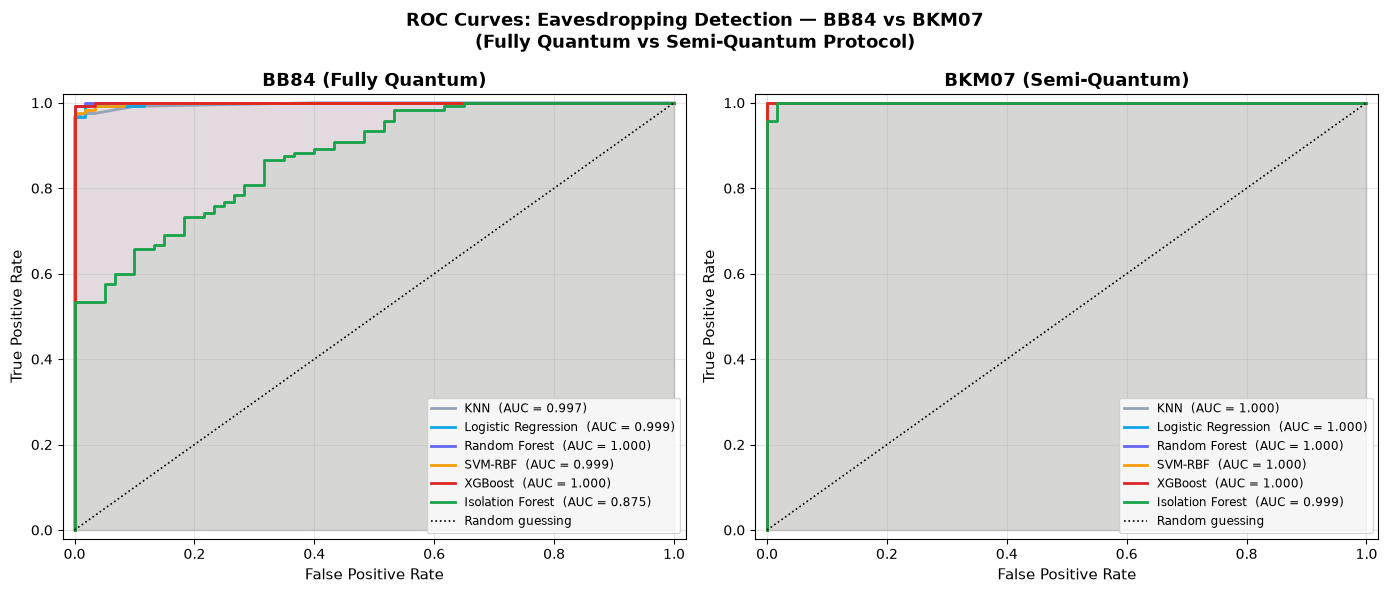

Saved: plots/roc_comparison_v2.png


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bb84_curves = [
    ('KNN',                  p84_knn, '#94A3B8'),
    ('Logistic Regression',  p84_lr,  '#0EA5E9'),
    ('Random Forest',        p84_rf,  '#6366F1'),
    ('SVM-RBF',              p84_svm, '#F59E0B'),
    (boosted_name,           p84_xgb, '#DC2626'),
    ('Isolation Forest',     p84_ifo, '#16A34A'),
]
bkm_curves = [
    ('KNN',                  pbk_knn, '#94A3B8'),
    ('Logistic Regression',  pbk_lr,  '#0EA5E9'),
    ('Random Forest',        pbk_rf,  '#6366F1'),
    ('SVM-RBF',              pbk_svm, '#F59E0B'),
    (boosted_name,           pbk_xgb, '#DC2626'),
    ('Isolation Forest',     pbk_ifo, '#16A34A'),
]

for ax, y, curves, title in [
        (axes[0], y84te, bb84_curves, 'BB84 (Fully Quantum)'),
        (axes[1], ybkte, bkm_curves,  'BKM07 (Semi-Quantum)')]:
    for label, proba, c in curves:
        fpr, tpr, _ = roc_curve(y, proba)
        auc_v = roc_auc_score(y, proba)
        ax.fill_between(fpr, tpr, alpha=0.06, color=c)
        ax.plot(fpr, tpr, color=c, linewidth=2.0,
                label=f'{label}  (AUC = {auc_v:.3f})')
    ax.plot([0, 1], [0, 1], 'k:', linewidth=1.2, label='Random guessing')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=8.5, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.02])

fig.suptitle('ROC Curves: Eavesdropping Detection — BB84 vs BKM07\n'
             '(Fully Quantum vs Semi-Quantum Protocol)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/roc_comparison_v2.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: plots/roc_comparison_v2.png")

---
## Section 15 — Feature Importance

“Which features contribute most to the model's ability to distinguish Eve from a secure channel?”

Tree-based models offer a built-in *impurity* importance (how much does splitting on this feature reduce loss, averaged across trees) — but that measure is biased toward continuous / high-cardinality features (Strobl, Boulesteix, Zeileis & Hothorn, BMC Bioinformatics 8:25, 2007), which matters here because several of our features are near-collinear by construction (`qber_total`/`qber_z`/`qber_x`/`h_qber`; `qber_zs`/`qber_key` in BKM07).

Instead we use **permutation importance** (`sklearn.inspection.permutation_importance`): shuffle one feature column on the held-out test set and measure the resulting drop in ROC-AUC. This measures each feature's actual contribution to the *model's real predictive performance*. The plot should be read as a ranking among *groups* of correlated features, not a precise per-column attribution.

We plot these for the tuned **Random Forest** on both BB84 and BKM07.

Key things to look for:
- If `qber_total` (BB84) or `qber_key` (BKM07) dominates → the model mostly relies on average error level, which Section 12's ablation (Model A/A+/B/C) already quantifies directly.
- If `y1_lower`/`e1_upper`/`gain_ratio_nu_mu` (BB84's decoy-state block) rank high → the model is using PNS-specific information a naive QBER threshold could never see.
- If `jump_energy_norm`/`qber_dispersion`/`spectral_entropy` rank high → temporal structure may be doing real work -- cross-check against Section 12's B-vs-A+ ablation before claiming it (in the saved Draft 2 run, group B did not improve on A+).
- If `asymmetry` is high for BKM07 → the model uses the forward/return leg imbalance.

In [ ]:
bb84_feat_names = BB84_FEATURE_NAMES
bkm_feat_names = BKM_FEATURE_NAMES

# Permutation importance on the HELD-OUT test set, not impurity
# importance. Impurity-based importance is biased toward continuous /
# high-cardinality features (Strobl, Boulesteix, Zeileis & Hothorn, BMC
# Bioinformatics 8:25, 2007), and several of our features are near-collinear
# by construction (qber_total/qber_z/qber_x/h_qber; delta_/corr_ pairs in
# E91) -- exactly the situation impurity importance handles worst.
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (model, names, Xte, yte, title, colour) in zip(axes, [
        (rf84_model, bb84_feat_names, X84te, y84te,
         'BB84 — Random Forest Permutation Importance', '#2563EB'),
        (rfbk_model, bkm_feat_names, Xbkte, ybkte,
         'BKM07 — Random Forest Permutation Importance', '#DC2626'),
]):
    r = permutation_importance(model, Xte, yte, n_repeats=30, random_state=0,
                                scoring='roc_auc', n_jobs=-1)
    imp, imp_sd = r.importances_mean, r.importances_std
    # review fix D9: report the RAW drop in held-out ROC-AUC (not max-normalised), so panels are comparable
    imp_n = imp
    sd_n = imp_sd

    order = np.argsort(imp_n)
    sorted_names = [names[i] for i in order]
    sorted_imp = imp_n[order]
    sorted_sd = sd_n[order]

    ax.barh(sorted_names, sorted_imp, xerr=sorted_sd, color=colour, alpha=0.82, capsize=2)
    ax.set_xlabel('Permutation importance (raw drop in held-out ROC-AUC)', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('Feature Importance: Which Signal Reveals Eve? (P18: permutation importance)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/feature_importance_v2.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: plots/feature_importance_v2.png")
print()
print("Note (Hooker, Mentch & Zhou, Stat. Comput. 31:82, 2021): permutation")
print("importance is itself biased under feature correlation -- read the plot as a")
print("ranking among GROUPS of correlated features, not a precise attribution to")
print("any single column.")

## Section 16 — N × Window Sensitivity

This section checks how much data the temporal features need before they become reliable and useful for detecting Eve.

The temporal features are `qber_dispersion`, `jump_energy_norm`, `spectral_entropy`, and `autocorr_lag1`.

We vary two things:

* **N:** number of pulses in each run
* **W:** number of sub-windows in each run

The per-window QBER estimate needs at least about **100 sifted bits per window** to reduce statistical noise. The `spectral_entropy` and `autocorr_lag1` features also need around **50–64 windows** for their estimates to become more stable.

For each combination of **N and W**, we compare:

* **AUC_A:** model using only total QBER
* **AUC_B:** model using QBER, aggregate features, and temporal features

We then calculate:

**ΔAUC = AUC_B − AUC_A**

This shows how much additional Eve-detection information is provided by the temporal features as the amount of available data increases.


> 🔧 **CHANGED (Draft 2, item 35): Section 16's mean-sifted-bits-per-window was overstated by 1/0.70 ~= 1.43x**
>
> `n_window_sensitivity` computed n_w (mean sifted bits per window, the number that
> drives the binomial noise floor this whole section is about) as
> `f['sifted_rate'] * N / W`. `sifted_rate` is defined as (sifted signal bits) /
> (SIGNAL-intensity pulses only) -- but `N` is the TOTAL pulse count across
> signal+decoy+vacuum intensities. Since only `DECOY_PROBS[0]=0.70` of pulses are
> signal-intensity, dividing by the full `N` instead of `N*DECOY_PROBS[0]` overstated
> n_w by a factor of `1/0.70 ~= 1.43`. Fixed to read `f['_k_achieved']` directly -- the
> EXACT achieved sifted-signal-bit count Draft 2's item 8 already added to
> `collect_bb84_features`'s return value -- which needs no reconstruction from
> `sifted_rate` and carries no such error.

In [ ]:
def n_window_sensitivity(N_values=(200_000, 1_000_000, 2_000_000),
                          W_values=(16, 32, 64),
                          n_per_class=8, distance_km=25.0,
                          eve_intensity=0.15, profile='bursty'):
    """P17: how many pulses N and how many windows W do the temporal
    features need? Reports AUC_A (qber_total alone) vs AUC_B (+ aggregate +
    temporal), and n_w (mean sifted bits per window -- the binomial-noise
    driver, audit Sec. H.1).

    Draft 2, item 35: n_w previously read f['sifted_rate']*N/W, where
    sifted_rate = (sifted signal bits)/(SIGNAL-intensity pulses) but N is
    the TOTAL pulse count across signal+decoy+vacuum -- so it divided by
    N instead of N*DECOY_PROBS[0], overstating n_w by 1/DECOY_PROBS[0] =
    1/0.70 ~= 1.43x. Now reads f['_k_achieved'] directly (Draft 2, item 8:
    the exact achieved sifted-SIGNAL-bit count, already returned by
    collect_bb84_features), which needs no reconstruction and carries no
    such error."""
    A_FEATS = ['qber_total']
    B_FEATS = ['qber_total', 'gain_mu', 'sifted_rate', 'qber_dispersion',
               'jump_energy_norm', 'spectral_entropy', 'autocorr_lag1']
    idx = {n: i for i, n in enumerate(BB84_FEATURE_NAMES)}
    out = []
    for N in N_values:
        for W in W_values:
            rows, ys, nws = [], [], []
            for cls, inten in [('none', 0.0), ('intercept_resend', eve_intensity)]:
                for i in range(n_per_class):
                    rng = SEEDS.rng(f'nw_exp_{cls}', i)   # Draft 2.1: per-class role (SeedBook is now stateless)
                    f = collect_bb84_features(int(N), distance_km, eve_mode=cls,
                                               eve_intensity=inten, profile=profile,
                                               n_windows=W, rng=rng)
                    rows.append([f[k] for k in BB84_FEATURE_NAMES])
                    ys.append(0 if cls == 'none' else 1)
                    nws.append(f['_k_achieved'] / W)   # item 35: exact sifted-SIGNAL count, not sifted_rate*N
            X = np.array(rows, dtype=float)
            y = np.array(ys)
            ok = np.isfinite(X).all(axis=1)
            if ok.sum() < 8 or len(np.unique(y[ok])) < 2:
                out.append(dict(N=N, W=W, n_w=float(np.nanmean(nws)), AUC_A=np.nan, AUC_B=np.nan, dAUC=np.nan))
                print(f"  N={N:>9,} W={W:>4}: insufficient data -- skipped")
                continue
            X, y = X[ok], y[ok]
            # review fix D5: 20 repeated stratified 5-fold CV per feature set (was ONE 70/30 split of ~80 runs) + paired bootstrap on dAUC
            per_seed = {}
            for tag, feats in [('A', A_FEATS), ('B', B_FEATS)]:
                cols = [idx[f] for f in feats]; per_seed[tag] = []
                for sd in range(20):
                    aucs_ = []
                    for tr_, te_ in StratifiedKFold(5, shuffle=True, random_state=sd).split(X, y):
                        m = make_boosted(seed=sd); m.fit(X[tr_][:, cols], y[tr_])
                        aucs_.append(roc_auc_score(y[te_], m.predict_proba(X[te_][:, cols])[:, 1]))
                    per_seed[tag].append(float(np.mean(aucs_)))
            d_ = np.array(per_seed['B']) - np.array(per_seed['A'])
            boot_ = np.random.default_rng(0).choice(d_, (1000, len(d_))).mean(1); lo_, hi_ = np.percentile(boot_, [2.5, 97.5])
            dauc = float(d_.mean())
            out.append(dict(N=N, W=W, n_w=float(np.mean(nws)), AUC_A=float(np.mean(per_seed['A'])), AUC_B=float(np.mean(per_seed['B'])),
                             dAUC=dauc, dAUC_lo=float(lo_), dAUC_hi=float(hi_)))
            print(f"  N={N:>9,} W={W:>4} n_w={np.mean(nws):8.1f} AUC_A={np.mean(per_seed['A']):.4f} AUC_B={np.mean(per_seed['B']):.4f} "
                  f"dAUC={dauc:+.4f} [{lo_:+.4f},{hi_:+.4f}]")
    return pd.DataFrame(out)


print("Running the N x window sensitivity grid (100 runs per class, eve_intensity=0.02 so QBER alone does not saturate; 20x repeated 5-fold CV)...")
nw_df = n_window_sensitivity(n_per_class=200, eve_intensity=0.02)   # review fix D5: 100 runs/class, weaker attack so QBER alone is not saturated
print()
print(nw_df.round(4).to_string(index=False))

piv = nw_df.pivot(index='N', columns='W', values='dAUC')
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(piv.values, aspect='auto', origin='lower', cmap='RdYlGn', vmin=-0.2, vmax=0.2)
ax.set_xticks(range(len(piv.columns)))
ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index)))
ax.set_yticklabels([f"{int(v):,}" for v in piv.index])
ax.set_xlabel('number of windows W')
ax.set_ylabel('pulses per run N')
ax.set_title('Value added by temporal features: AUC(B) - AUC(A)')
for _i in range(piv.shape[0]):
    for _j in range(piv.shape[1]):
        _v = piv.values[_i, _j]
        if np.isfinite(_v):
            ax.text(_j, _i, f"{_v:+.3f}", ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='Delta AUC (B - A)')
plt.tight_layout()
plt.savefig('plots/n_window_sensitivity.png', dpi=200)
plt.show()
print("Saved: plots/n_window_sensitivity.png")

---
## Section 17 -- E91: Entanglement-Based QKD -- Eavesdropping Detection

Unlike BB84 (Alice sends prepared photons) and BKM07 (Bob is classical),
**E91** distributes entangled photon pairs from a shared source to Alice
and Bob (Section 1.3's noise model, Section 2.1's attacks). The E91 dataset
was generated in Section 5 (4 classes: `none`, `intercept_resend`,
`ancilla`, `loss_manipulation`), audited in Section 6, and split
train/test in Section 7 with the same `RandomState(7)` convention as
BB84/BKM07. Here we train the same model families (KNN, Logistic
Regression, Random Forest, Boosted trees, reusing Section 8's factories)
plus the unsupervised Isolation Forest, and evaluate.

Two additional analyses are important for E91:

Focus on FNR: A false negative means Eve is present but the model classifies the sample as secure. This is an important security failure, so we report FNR along with accuracy and AUC.
CHSH-only vs full features: We compare a model using only chsh_S with the same model using all 11 physics-informed E91 features. This tests whether the additional features provide useful information beyond the standard CHSH measurement.

The intercept_resend attack is expected to be difficult to distinguish from normal channel noise using only chsh_S and qber_key. The s_qber_residual feature is included to capture information related to the ancilla attack.

The goal is therefore not only to measure overall ML performance, but also to check whether the physics-informed features provide additional information for detecting specific types of attacks.

In [ ]:
# ── Train models (reuses factories from Section 8) ───────────────────────────
print("Fitting KNN and Logistic Regression for E91 ...")
knn91 = make_knn(); knn91.fit(Xe91tr, ye91tr)
lr91  = make_logreg(); lr91.fit(Xe91tr, ye91tr)

print("Tuning Random Forest for E91 ...")
rf91_model, rf91_params, rf91_cv = tune_rf(Xe91tr, ye91tr)
print(f"  Best CV-AUC : {rf91_cv:.4f}")
print(f"  Best params : {rf91_params}")

print("Tuning Boosted Trees for E91 ...")
boosted91_model, boosted91_params, boosted91_cv = tune_boosted(Xe91tr, ye91tr)
print(f"  Best CV-AUC : {boosted91_cv:.4f}")
print(f"  Best params : {boosted91_params}")

print("Fitting Isolation Forest (trained only on secure E91 samples) ...")
clean91 = Xe91tr[ye91tr == 0]
ifo91 = make_isolation_forest(); ifo91.fit(clean91)

print(f"\nE91 models ready: KNN, LogReg, Random Forest (tuned), {boosted_name} (tuned), IsoForest")


def security_report(name, proba, y_te, threshold=0.5):
    '''Accuracy/AUC (as in evaluate()) PLUS the security-relevant confusion
    counts: FN = an attacked sample wrongly called secure -- the actual
    eavesdropping-detection failure, not just a lower accuracy number.'''
    pred = (proba >= threshold).astype(int)
    tp = int(((pred == 1) & (y_te == 1)).sum()); fn = int(((pred == 0) & (y_te == 1)).sum())
    fp = int(((pred == 1) & (y_te == 0)).sum()); tn = int(((pred == 0) & (y_te == 0)).sum())
    fnr = fn / (tp + fn) if (tp + fn) else float('nan')
    fpr = fp / (fp + tn) if (fp + tn) else float('nan')
    acc = (tp + tn) / len(y_te)
    auc = roc_auc_score(y_te, proba)
    lo, hi = grouped_boot_auc(y_te, proba)      # review fix D1
    print(f"  {name:<32}ACC={acc*100:5.1f}%  AUC={auc:.4f} [{lo:.3f},{hi:.3f}]  FNR={fnr:.3f} (missed {fn}/{tp+fn})  FPR={fpr:.3f}   <- at the default 0.5 threshold")
    return fnr, fpr, auc


print("━" * 60)
print("E91 -- Test-set performance (full physics-informed feature set)")
print("━" * 60)
p91_knn = knn91.predict_proba(Xe91te)[:, 1]
p91_lr  = lr91.predict_proba(Xe91te)[:, 1]
p91_rf  = rf91_model.predict_proba(Xe91te)[:, 1]
p91_xgb = boosted91_model.predict_proba(Xe91te)[:, 1]
p91_ifo = isolation_anomaly_scores(ifo91, Xe91te)

security_report("KNN", p91_knn, ye91te)
security_report("Logistic Regression", p91_lr, ye91te)
security_report("Random Forest (tuned)", p91_rf, ye91te)
security_report(f"{boosted_name} (tuned)", p91_xgb, ye91te)
auc91_ifo = roc_auc_score(ye91te, p91_ifo)
print(f"  {'Isolation Forest (unsupervised)':<32}ACC= N/A    AUC={auc91_ifo:.4f}")

### Critical baseline & adversarial generalisation

In [52]:
# ── Critical baseline: CHSH alone vs the full physics-informed feature set ──
# Same model (boosted trees), two feature sets: does ML learn more than a
# conventional single-threshold Bell test would?
print("Critical baseline -- CHSH-only vs full physics-informed features (same model)")
print("-" * 70)
boosted91_chsh_only, chsh_only_params, chsh_only_cv = tune_boosted(Xe91tr_chsh, ye91tr)
p91_chsh_only = boosted91_chsh_only.predict_proba(Xe91te_chsh)[:, 1]

fnr_chsh, fpr_chsh, auc_chsh = security_report(
    f"{boosted_name}, chsh_only (1 feature)", p91_chsh_only, ye91te)
fnr_full, fpr_full, auc_full = security_report(
    f"{boosted_name}, full ({len(E91_FEATURE_NAMES)} features)", p91_xgb, ye91te)

print(f"\n  ==> FNR {fnr_chsh:.3f} -> {fnr_full:.3f}   |   AUC {auc_chsh:.3f} -> {auc_full:.3f}")
print("  Per the audit's Sec. F.3 finding: basis-averaged intercept-resend sits on")
print("  the SAME |S| = 2*sqrt(2)*(1-2Q) honest-depolarisation curve as ordinary")
print("  noise, so aggregate CHSH/QBER alone cannot separate it -- only temporal")
print("  structure can. `ancilla` attacks are the exception: they are basis-")
print("  anisotropic (cost more QBER than CHSH), which is exactly what")
print("  s_qber_residual is built to catch. Expect a SMALLER, more honest gap")
print("  here than in the pre-patch version -- that gap was mostly the leak.")

# Break the FNR down by attack type -- the direct evidence for the
# per-attack claim above.
print("\n  FNR by attack type (full-feature model vs chsh-only):")
for mode in ("intercept_resend", "ancilla", "loss_manipulation"):
    m = label91_te == mode
    if m.sum() == 0:
        continue
    fnr_full_mode = float(np.mean(p91_xgb[m] < 0.5))
    fnr_chsh_mode = float(np.mean(p91_chsh_only[m] < 0.5))
    print(f"    {mode:<18} n={m.sum():<4} FNR(full)={fnr_full_mode:.3f}   FNR(chsh_only)={fnr_chsh_mode:.3f}")

# ── Adversarial generalisation (same style as Section 13) ─────────────
# Only intercept_resend has a continuous attack-strength knob (duty cycle);
# ancilla/loss_manipulation strengths are drawn from a different range, so
# this sub-test is restricted to secure-vs-intercept_resend rows.
print("\nAdversarial generalisation: train weak intercept-resend (duty<=0.3),")
print("test strong intercept-resend (duty>=0.6)")
low_duty, high_duty = 0.3, 0.6
mask_lo91 = (label91_tr == 'none') | ((label91_tr == 'intercept_resend') & (duty91_tr <= low_duty))
mask_hi91 = (label91_te == 'none') | ((label91_te == 'intercept_resend') & (duty91_te >= high_duty))
print(f"E91 -- weak-attack train samples : {mask_lo91.sum()}")
print(f"E91 -- strong-attack test samples: {mask_hi91.sum()}")
if mask_lo91.sum() > 10 and mask_hi91.sum() > 10:
    adv91 = make_boosted(seed=1)
    adv91.fit(Xe91tr[mask_lo91], ye91tr[mask_lo91])
    p_adv91 = adv91.predict_proba(Xe91te[mask_hi91])[:, 1]
    fnr_adv, fpr_adv, auc_adv = security_report("E91 boosted (duty-cycle gen.)", p_adv91, ye91te[mask_hi91])
else:
    print("E91 -- not enough samples in one or both subsets; skipping.")

Critical baseline -- CHSH-only vs full physics-informed features (same model)
----------------------------------------------------------------------


  XGBoost, chsh_only (1 feature)  ACC= 78.8%  AUC=0.8489  FNR=0.114 (missed 21/185)  FPR=0.545
  XGBoost, full (11 features)     ACC= 84.6%  AUC=0.9206  FNR=0.097 (missed 18/185)  FPR=0.345

  ==> FNR 0.114 -> 0.097   |   AUC 0.849 -> 0.921
  Per the audit's Sec. F.3 finding: basis-averaged intercept-resend sits on
  the SAME |S| = 2*sqrt(2)*(1-2Q) honest-depolarisation curve as ordinary
  noise, so aggregate CHSH/QBER alone cannot separate it -- only temporal
  structure can. `ancilla` attacks are the exception: they are basis-
  anisotropic (cost more QBER than CHSH), which is exactly what
  s_qber_residual is built to catch. Expect a SMALLER, more honest gap
  here than in the pre-patch version -- that gap was mostly the leak.

  FNR by attack type (full-feature model vs chsh-only):
    intercept_resend   n=62   FNR(full)=0.081   FNR(chsh_only)=0.065
    ancilla            n=53   FNR(full)=0.038   FNR(chsh_only)=0.151
    loss_manipulation  n=70   FNR(full)=0.157   FNR(chsh_only)=0.

In [ ]:
# ── Review fixes C2 / D1 / D3 / D4: per-attack metrics, recall at a FIXED false-positive rate, strong simple baselines ──
def _meta_arr(path, col, n, default):
    try:
        m = pd.read_csv(path)
        return m[col].to_numpy(float) if len(m) == n else np.full(n, default)
    except Exception:
        return np.full(n, default)

_N84, _NBK = len(bb84_arr), len(bkm_arr)
_edet84, _Y084 = _meta_arr('data/bb84_meta.csv', 'e_det', _N84, 0.033), _meta_arr('data/bb84_meta.csv', 'Y0', _N84, 1.7e-6)
_edetbk = _meta_arr('data/bkm07_meta.csv', 'e_det', _NBK, 0.033)
REVIEW_SETS = {
  'BB84':  dict(model=boosted84_model, Xtr=X84tr, ytr=y84tr, Xte=X84te, yte=y84te, gtr=bb84_groups[bb84_tr_idx], gte=bb84_groups[bb84_te_idx],
                lab=bb84_attack_labels[bb84_te_idx], names=BB84_FEATURE_NAMES, q='qber_total',
                oracle=np.array([bb84_arr[i, N_FEAT_84] for i in bb84_te_idx]), te_idx=bb84_te_idx),
  'BKM07': dict(model=boostedbk_model, Xtr=Xbktr, ytr=ybktr, Xte=Xbkte, yte=ybkte, gtr=bkm_groups[bkm_tr_idx], gte=bkm_groups[bkm_te_idx],
                lab=bkm07_attack_labels[bkm_te_idx], names=BKM_FEATURE_NAMES, q='qber_key', oracle=None, te_idx=bkm_te_idx),
  'E91':   dict(model=boosted91_model, Xtr=Xe91tr, ytr=ye91tr, Xte=Xe91te, yte=ye91te, gtr=None, gte=None,
                lab=label91_te, names=E91_FEATURE_NAMES, q='qber_key', oracle=None, te_idx=te91)}

def _oracle_score(name, S):
    """Known-baseline oracle: observed key QBER minus the QBER this exact link is EXPECTED to show when honest."""
    j = S['names'].index(S['q']); q = S['Xte'][:, j]
    if name == 'BB84':
        exp = np.array([channel_model(float(d), e_detector=float(_edet84[i]), Y0=float(_Y084[i]))['qber'] for d, i in zip(S['oracle'], S['te_idx'])])
    elif name == 'BKM07':
        e = _edetbk[S['te_idx']]; exp = 0.5 * (1 - (1 - 2 * e) ** 3)
    else:
        exp = (1 - e91_df['V'].to_numpy(float)[S['te_idx']]) / 2
    return q - exp

review_rows, per_attack_rows, base_rows = [], [], []
for name, S in REVIEW_SETS.items():
    p = S['model'].predict_proba(S['Xte'])[:, 1]; y, lab = S['yte'], S['lab']
    oof = oof_scores(S['model'], S['Xtr'], S['ytr'], S['gtr'])
    n_hon = int((S['ytr'] == 0).sum())
    for fpr_t in (0.01, 0.05):                                    # D3: threshold from out-of-fold training scores, never from test data
        thr = float(np.quantile(oof[S['ytr'] == 0], 1 - fpr_t))
        rec = lambda idx: float((p[idx][y[idx] == 1] > thr).mean()) if (y[idx] == 1).any() else np.nan
        fp_ = lambda idx: float((p[idx][y[idx] == 0] > thr).mean()) if (y[idx] == 0).any() else np.nan
        allidx = np.arange(len(y)); lo, hi = grouped_boot_ci(rec, len(y), S['gte'], B=300)
        review_rows.append(dict(protocol=name, target_fpr=fpr_t, threshold=thr, recall=rec(allidx), recall_lo=lo, recall_hi=hi,
                                FNR=1 - rec(allidx), test_FPR=fp_(allidx), honest_runs_for_threshold=n_hon))
    thr1 = float(np.quantile(oof[S['ytr'] == 0], 0.99))
    for a in sorted(set(lab) - {'none'}):                         # C2: one-vs-clean per attack
        m = (lab == 'none') | (lab == a)
        per_attack_rows.append(dict(protocol=name, attack=a, n_attacked=int((lab == a).sum()),
            auc_vs_clean=float(roc_auc_score(y[m], p[m])), pr_auc=float(average_precision_score(y[m], p[m])),
            recall_at_1pct_fpr=float((p[lab == a] > thr1).mean())))
    # D4: strong simple baselines on the SAME test rows, with CIs
    jq = S['names'].index(S['q']); hq = S['Xtr'][S['ytr'] == 0, jq]
    z = (S['Xte'][:, jq] - hq.mean()) / (hq.std() + 1e-9)
    aucs_f = [roc_auc_score(S['ytr'], np.nan_to_num(S['Xtr'][:, j])) for j in range(S['Xtr'].shape[1])]
    jb = int(np.argmax(np.abs(np.array(aucs_f) - 0.5)))
    lr1 = Pipeline([('s', StandardScaler()), ('c', LogisticRegression())]).fit(np.nan_to_num(S['Xtr'][:, [jb]]), S['ytr'])
    cand = {'boosted trees (all features)': p, 'QBER z-test (pooled honest baseline)': z,
            f"logistic on best single feature ({S['names'][jb]})": lr1.predict_proba(np.nan_to_num(S['Xte'][:, [jb]]))[:, 1],
            'oracle: QBER minus the link\'s known honest QBER': _oracle_score(name, S)}
    for k, sc in cand.items():
        a = roc_auc_score(y, sc); lo, hi = grouped_boot_auc(y, sc, S['gte'])
        base_rows.append(dict(protocol=name, model=k, auc=a, auc_lo=lo, auc_hi=hi, n_test=len(y)))
review_fpr_df, per_attack_df, baselines_df = pd.DataFrame(review_rows), pd.DataFrame(per_attack_rows), pd.DataFrame(base_rows)
for df_, fn_ in ((review_fpr_df, 'review_fixed_fpr.csv'), (per_attack_df, 'review_per_attack.csv'), (baselines_df, 'review_baselines.csv')): df_.to_csv('data/' + fn_, index=False)
print("D3 -- recall (and FNR) at a FIXED false-positive rate; threshold from out-of-fold TRAINING scores (honest runs available shown):")
print(review_fpr_df.round(3).to_string(index=False))
print("\nC2 -- one-vs-clean metrics per attack (macro-average at the bottom):")
print(per_attack_df.round(3).to_string(index=False)); print(per_attack_df.groupby('protocol')[['auc_vs_clean', 'pr_auc', 'recall_at_1pct_fpr']].mean().round(3).to_string())
print("\nD4 -- strong simple baselines next to the ML model (AUC with grouped-bootstrap 95% CI):")
print(baselines_df.round(3).to_string(index=False))
print("\nNote: the honest-run counts above are below the >=300 the review recommends for a 1% FPR threshold; treat 1% numbers as indicative.")

### ROC curve

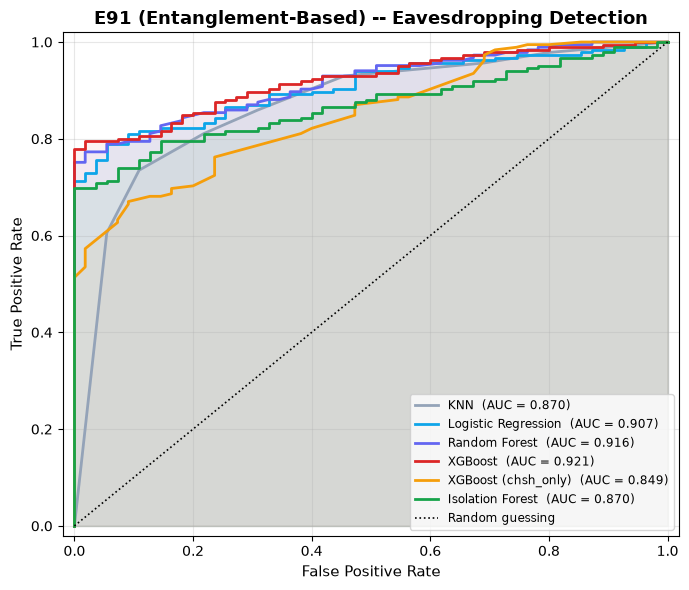

Saved: plots/roc_e91.png


In [53]:
# ── ROC curve (same style as Section 14) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

e91_curves = [
    ('KNN',                    p91_knn,        '#94A3B8'),
    ('Logistic Regression',    p91_lr,         '#0EA5E9'),
    ('Random Forest',          p91_rf,         '#6366F1'),
    (boosted_name,             p91_xgb,        '#DC2626'),
    (f'{boosted_name} (chsh_only)', p91_chsh_only, '#F59E0B'),
    ('Isolation Forest',       p91_ifo,        '#16A34A'),
]

for label, proba, c in e91_curves:
    fpr, tpr, _ = roc_curve(ye91te, proba)
    auc_v = roc_auc_score(ye91te, proba)
    ax.fill_between(fpr, tpr, alpha=0.06, color=c)
    ax.plot(fpr, tpr, color=c, linewidth=2.0, label=f'{label}  (AUC = {auc_v:.3f})')

ax.plot([0, 1], [0, 1], 'k:', linewidth=1.2, label='Random guessing')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('E91 (Entanglement-Based) -- Eavesdropping Detection', fontsize=13, fontweight='bold')
ax.legend(fontsize=8.5, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig('plots/roc_e91.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: plots/roc_e91.png")

### Scope note (E91, same as BB84/BKM07 above)

`s_deviation` (the CHSH-vs-Tsirelson-bound gap) is a point estimate under a
simplified, idealised model — not a rigorous statistical-significance test
on finite coincidence counts (no `sigma_S`/z-score is computed here), and
not a device-independent security proof. `s_qber_residual` (deviation from
the honest depolarisation curve `|S|=2√2(1-2Q)`) is a genuine
physics-derived diagnostic for basis-anisotropic disturbance, not a
detector-hardware measurement.

Three attack mechanisms are modelled (intercept-resend on Bob's arm, an
entangling-ancilla probe, and asymmetric arm-loss manipulation), each as a
genuine CPTP map on a real two-qubit density matrix. A real E91 deployment
would also need to consider collective/coherent attacks, detector-side
attacks (blinding, efficiency mismatch — genuinely invisible to a channel
model like this one; see Lydersen et al. 2010), trojan-horse attacks on
the source apparatus, and an authenticated classical channel, all of which
are out of scope here. As with BB84/BKM07, these results describe
detection of statistical signatures consistent with eavesdropping under
the simulated channel/attack model, not a formal QKD security guarantee.

# Deep Learning

## Section 18 — Cross-Protocol Deep Learning Detection

This section studies whether deep learning models can learn useful attack patterns that work across different QKD protocols.

We investigate two research questions:

1. **Leave-one-protocol-out transfer (Section 18.7)**
   A shared neural network is first trained on two protocols. The main part of the network is then frozen, and only a small adapter is trained using a small fraction of data from the third protocol.

   We compare this with training a new model from scratch using the same small amount of target-protocol data.

   If the pretrained model performs better, it suggests that the shared network has learned attack patterns that transfer across BB84, BKM07, and E91, rather than simply learning patterns specific to one protocol.

2. **Effect of supervised pretraining on zero-day detection (Section 18.8)**
   We test whether learning attack classes during supervised training helps or hurts the detection of a completely unseen attack.

   We compare two Deep SVDD anomaly detectors:

   * one using an embedding that was pretrained for attack classification
   * one trained from scratch using only clean sessions

   Both are tested on an attack type that was completely excluded from training.

The session data is generated using the same validated simulation functions already used earlier in this notebook: `channel_model`, `simulate_bb84_decoy`, `simulate_bkm07_pulse`, and `run_e91`.

This keeps the deep learning experiments consistent with the physics and data-generation process that was already tested and validated in earlier sections.

### Runtime Note

The live experiment at the end of this section uses smaller numbers of sessions, epochs, training fractions, and random seeds so that the notebook can run within a few minutes.

For final results, increase these values as indicated in the comments to obtain more reliable estimates and tighter confidence intervals.


In [54]:
# ── DL imports (only needed from here on) ──────────────────────────────────
import copy as _copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, train_test_split
from sklearn.metrics import f1_score, recall_score, roc_auc_score, confusion_matrix

DL_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Deep-learning device: {DL_DEVICE}")

Deep-learning device: cpu


### 18.1 — Attack Taxonomy

This section covers only the `eve_mode` attack types that are actually implemented in the notebook’s QKD simulators.

The experiments therefore use physically simulated attack behaviour rather than artificially generated or label-dependent noise patterns. This keeps the deep learning dataset consistent with the simulation models used throughout the project.


In [55]:
DL_PROTOCOLS = ["bb84", "e91", "bkm07"]

DL_ATTACKS = {
    "bb84":  ["clean", "intercept_resend", "pns", "blocking", "loss_manipulation"],
    "e91":   ["clean", "intercept_resend", "ancilla", "loss_manipulation"],
    # simulate_bkm07_pulse has one interception mechanism; symmetric vs
    # asymmetric is a DATASET-level distinction (eve_fwd == eve_ret or not),
    # the same convention Section 5's generate_datasets() uses.
    "bkm07": ["clean", "symmetric_attack", "asymmetric_attack"],
}
DL_ATTACK_COUNTS = {p: len(v) for p, v in DL_ATTACKS.items()}

# Held out entirely from training for the zero-day test (Section 18.8) --
# chosen to be physically distinct from the rest of that protocol's list.
DL_ZERO_DAY_ATTACK_BY_TARGET = {
    "bb84":  "pns",                # near-zero QBER signature, distinct from intercept/loss attacks
    "e91":   "ancilla",            # basis-anisotropic dephasing, distinct from depolarising attacks
    "bkm07": "asymmetric_attack",  # distinct forward/return-leg signature from the symmetric case
}
print("DL attack taxonomy:", DL_ATTACKS)

DL attack taxonomy: {'bb84': ['clean', 'intercept_resend', 'pns', 'blocking', 'loss_manipulation'], 'e91': ['clean', 'intercept_resend', 'ancilla', 'loss_manipulation'], 'bkm07': ['clean', 'symmetric_attack', 'asymmetric_attack']}


### 18.2 — Session Encoding and Windowing

Each QKD session is converted into a sequence of **8 numerical features per
EVENT** (Draft 2, items 13-18 -- see the mapping table a few cells below for
exactly what changed from Draft 1 and why). These features allow the same
deep learning pipeline to process BB84, BKM07, and E91 sessions.

| Feature        | Meaning                                                                  |
| -------------- | ------------------------------------------------------------------------- |
| `kept`         | Whether the event is kept for the key                                     |
| `error`        | Whether an error occurred (only meaningful when kept)                     |
| `basis_a`      | Alice's basis/setting, normalized to `[0, 1]`                             |
| `basis_b`      | Bob's basis/setting, normalized to `[0, 1]` (or 0.5 where undefined)      |
| `test_flag`    | 1 if this event is a dedicated Eve-detecting test round for its protocol  |
| `event_gap`    | Log-compressed count of failed/uninformative attempts before this event   |
| `aux1`         | Protocol-specific detail (intensity class / round-type code / CHSH index) |
| `chsh_running` | Running CHSH correlation value, rescaled to a similar numerical range     |

The basis values are normalized because BB84/BKM07 use two basis settings,
while E91 uses three. This keeps the feature scales comparable across
protocols.

The encoded session is then divided into **overlapping windows of 96
events**, with a stride of 48 events -- consecutive windows share half of
their data. (Draft 1 used 256/128 RAW ROUNDS; Draft 2's windows are shorter
because every row is now an informative event rather than mostly empty
time slots -- see items 13-18 below.)

Sessions shorter than 96 events are discarded instead of being padded with
zeros. Zero-padding could make a short session look like a real session
with very little activity and could introduce unwanted patterns for the
deep learning models.

The final input has the shape:

**`(number of windows, 96 events, 8 features)`**


> 🔧 **CHANGED (Draft 2, item 12): DL input encoding rebuilt around events (items 12-18)**
>
> encode_session() below now takes 7 event-level arrays (kept, error, basis_a, basis_b, test_flag, event_gap, aux1) instead of the old (protocol, kept, error, basis_a, basis_b, no_click, double_click); see the mapping table in the next cell for exactly what changed and why.

**Items 12-18: the DL input encoding, rebuilt around detected events.**

Part D of the beginner's guide traced Draft 1's deep-learning failure to a
single root cause: a session's 192-round WINDOW was built from raw TIME
SLOTS, and almost none of those slots were informative (BB84 windows
averaged 0.34 kept key rounds; 94% of BKM07 windows had zero). This section
rebuilds the encoding so every row is a DETECTED / INFORMATIVE EVENT --a
BB84 click, a BKM07 round trip that survived both legs, or an E91 pulse
(E91 has no loss, so every pulse already qualifies) -- instead of a raw
time slot. Two things fall out of that switch:

* Windows are full of real information again (a BB84 window nets ~25-50
  real key/decoy events instead of ~0.3; BKM07 similarly).
* Attacks that work by changing the *click rate itself* (blocking,
  loss-manipulation) would otherwise disappear once only detected events
  are kept -- a new **event-gap** channel (item 18) carries exactly that
  information back in: how many raw attempts preceded this event.

Two of Draft 1's input channels were also actively broken (items 12-17,
`double_click` was dead for every protocol; `chsh_running`/`no_click` were
almost always 0 except for one protocol each, so they mostly told the
network *which protocol* it was looking at; BB84 had no intensity channel
at all, so PNS -- the attack the classical features exist to catch --
was invisible to the network by construction; BKM07's `basis_b` conflated
Bob's SIFT/CTRL mode with a basis; E91's `basis_match` flagged the wrong
pairs). The new 8-channel layout, and how each channel maps to physics per
protocol:

| # | channel | BB84 | BKM07 | E91 |
|---|---|---|---|---|
| 1 | `kept` | sifted (click, bases match, any intensity) | SIFT_KEY round | pair used a key setting (a2-b1 or a3-b2) |
| 2 | `error` | kept and Bob's bit != Alice's | error appropriate to the round type (SIFT_KEY/MONITOR/CTRL) | kept and outcomes not anti-correlated |
| 3 | `basis_a` | Alice's basis | Alice's basis | Alice's setting a1/a2/a3 |
| 4 | `basis_b` | Bob's basis | Bob's Z basis on SIFT rounds; 0.5 (n/a) on CTRL | Bob's setting b1/b2/b3 |
| 5 | `test_flag` (was `basis_match`) | decoy/vacuum pulse (Eve-detecting by construction) | CTRL round (Bob reflected, a dedicated test round) | this pair is one of the 4 CHSH test settings |
| 6 | `event_gap` (was `no_click`) | log-compressed raw pulses since the last click | ... since the last survived round trip | always ~0 (E91 has no loss channel) |
| 7 | `aux1` (was `double_click`, dead) | intensity class (signal/decoy/vacuum) | round-type code (finer than test_flag: SIFT_KEY/MONITOR/CTRL_Z/CTRL_X) | which CHSH setting (0 for key pairs) |
| 8 | `chsh_running` | 0 (unchanged) | 0 (unchanged) | rolling CHSH estimate / 2*sqrt(2) |

All three protocols target the same number of events per session (2,000,
matching the classical datasets' K, item 8) with a shared window length of
96 events (stride 48) -- shorter than Draft 1's 192-round windows, because
every row is now informative rather than mostly empty.

In [ ]:
N_FEATURES = 8
N_CLASSICAL_FEATURES = 16   # max(len(BB84_FEATURE_NAMES)=14, len(BKM_FEATURE_NAMES)=14, len(E91_FEATURE_NAMES)=11); shorter protocols' classical vectors are zero-padded to this width


def _normalize_gap(gap, scale=2.0e5):
    """Draft 2, items 13-18: log-compressed, [0,1]-clamped encoding of
    'how many raw attempts preceded this event' -- see the callout above
    for why this channel exists at all."""
    gap = np.asarray(gap, dtype=np.float64)
    return np.clip(np.log1p(np.maximum(gap, 0.0)) / np.log1p(scale), 0.0, 1.0).astype(np.float32)


def encode_session(kept, error, basis_a, basis_b, test_flag, event_gap, aux1,
                    chsh_running=None, n_bases=2):
    """Assembles the (n_events, N_FEATURES) matrix for one session. All
    array arguments must be the same length (n_events,) -- Draft 2, items
    13-18: every row is now a DETECTED/INFORMATIVE EVENT (a BB84 click, a
    BKM07 survived round trip, or an E91 pulse -- E91 has no loss, so
    every pulse already qualifies), not a raw time slot. See the callout
    above this cell for the full rationale and the channel-by-channel
    mapping table (item 12).

    n_bases: how many distinct values basis_a/basis_b take (2 for
    BB84/BKM07's Z/X, 3 for E91's three angle settings) -- used to
    normalise those two channels into [0, 1] so their scale is comparable
    across protocols despite differing basis-set sizes.
    """
    n = len(kept)
    kept = np.asarray(kept, dtype=np.float32)
    error = np.asarray(error, dtype=np.float32)
    basis_a = np.asarray(basis_a, dtype=np.float32)
    basis_b = np.asarray(basis_b, dtype=np.float32)
    test_flag = np.asarray(test_flag, dtype=np.float32)
    event_gap = np.asarray(event_gap, dtype=np.float32)
    aux1 = np.asarray(aux1, dtype=np.float32)
    chsh_running = np.zeros(n, dtype=np.float32) if chsh_running is None else np.asarray(chsh_running, dtype=np.float32)

    denom = max(n_bases - 1, 1)
    basis_a_n = basis_a / denom
    basis_b_n = basis_b / denom
    chsh_running_n = chsh_running / (2.0 * np.sqrt(2.0))   # rescale to O(1)

    X = np.stack([kept, error, basis_a_n, basis_b_n, test_flag,
                  event_gap, aux1, chsh_running_n], axis=1)
    assert X.shape == (n, N_FEATURES)
    return X.astype(np.float32)


def make_windows(X, length=256, stride=128):
    """Overlapping fixed-length windows (n_windows, length, N_FEATURES).
    Sessions shorter than `length` are dropped -- zero-padding a short
    session would look like a genuine "everything quiet" window and bias
    the detectors, rather than a lack of data."""
    n = len(X)
    if n < length:
        return np.zeros((0, length, X.shape[1]), dtype=X.dtype)
    starts = range(0, n - length + 1, stride)
    return np.stack([X[s:s + length] for s in starts], axis=0)


print("encode_session() / make_windows() defined.")

### 18.3 -- Attention pooling and LSTM autoencoder

`AttentionPool` learns a scalar relevance score per timestep (softmax
-normalised over the window) instead of mean/last-hidden pooling, so the
network can emphasise whichever part of a window -- e.g. a burst -- carries
the attack signature. 


`LSTMAutoencoder` is an unsupervised
reconstruction-based building block (not used in the main flow below, kept
for anyone extending Section 18.8's ablation with a reconstruction-error
anomaly baseline alongside Deep SVDD).

In [57]:
class AttentionPool(nn.Module):
    def __init__(self, hidden_dim, attn_dim=64):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(hidden_dim, attn_dim), nn.Tanh(), nn.Linear(attn_dim, 1))

    def forward(self, h):
        """h: (B, L, H) -> (pooled: (B, H), attn_weights: (B, L))"""
        logits = self.score(h).squeeze(-1)
        attn = torch.softmax(logits, dim=1)
        pooled = torch.einsum('bl,blh->bh', attn, h)
        return pooled, attn


class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features=N_FEATURES, hidden=64, latent=32, num_layers=1):
        super().__init__()
        self.encoder = nn.LSTM(n_features, hidden, num_layers=num_layers, batch_first=True)
        self.to_latent = nn.Linear(hidden, latent)
        self.from_latent = nn.Linear(latent, hidden)
        self.decoder = nn.LSTM(hidden, hidden, num_layers=num_layers, batch_first=True)
        self.out = nn.Linear(hidden, n_features)

    def forward(self, x):
        B, L, _ = x.shape
        _, (h_n, _) = self.encoder(x)
        z = self.to_latent(h_n[-1])
        dec_in = self.from_latent(z).unsqueeze(1).repeat(1, L, 1)
        dec_out, _ = self.decoder(dec_in)
        return self.out(dec_out), z

    def reconstruction_error(self, x):
        recon, _ = self.forward(x)
        return ((recon - x) ** 2).mean(dim=(1, 2))


print("AttentionPool / LSTMAutoencoder defined.")

AttentionPool / LSTMAutoencoder defined.


### 18.4 — Session Generation

`simulate_session()` generates sessions using the same QKD simulators defined earlier in the notebook:

* `simulate_bb84_decoy` for BB84
* `simulate_bkm07_pulse` for BKM07
* `run_e91` for E91

This keeps the deep learning dataset consistent with the validated simulation models used in the earlier sections.

For E91, `_rolling_chsh` calculates the CHSH statistic every `step` rounds using the most recent `window` rounds. The calculated value is then kept constant until the next update. This is used because a meaningful CHSH value requires multiple measurements for the different angle-setting pairs, so a true per-round CHSH value is not defined.

**Performance note:** BKM07 sessions take the longest to generate because its simulator processes pulses individually in a Python loop. This is mainly due to the high channel loss, where many transmitted pulses are lost before reaching a detector. At the scale used in this project, keeping the simulator physically detailed was preferred over adding complex vectorization.


> 🔧 **CHANGED (Draft 2, item 13): The three per-protocol session builders, rebuilt around events**
>
> _bb84_dl_session / _bkm07_dl_session / _e91_dl_session now return event-level arrays (test_flag, event_gap, aux1 in place of no_click/double_click) and target a number of EVENTS instead of raw rounds; BKM07's builder also now uses the vectorised simulate_bkm07_batch (item 7) instead of a per-pulse Python loop. simulate_session and build_dl_dataset are updated to match (target_events replaces n_rounds; default window shrinks from 256/128 raw rounds to 96/48 events).

In [ ]:
from dataclasses import dataclass


@dataclass
class Session:
    protocol: str
    attack: str
    session_id: int
    X: np.ndarray
    x_classical: np.ndarray


def _classical_vector(feat_dict, names, width=N_CLASSICAL_FEATURES):
    """Packs a classical-feature dict (as returned by collect_bb84_features /
    collect_bkm07_features / extract_e91_features) into a fixed-width vector,
    in `names` order, zero-padded to `width` so BB84/BKM07/E91's differing
    native feature counts share one common width for CrossProtocolDetector's
    shared classical_proj layer. NaNs/infs (e.g. extract_e91_features's
    s_qber_residual or h_qber_key when chsh_S/qber_key are undefined on a
    near-empty window) are zeroed rather than propagated into training."""
    v = np.array([feat_dict[n] for n in names], dtype=np.float32)
    v = np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)
    if len(v) < width:
        v = np.concatenate([v, np.zeros(width - len(v), dtype=np.float32)])
    return v


def _rolling_chsh(ak, bk, ra, rb, window=400, step=50):
    n = len(ak)
    chsh_running = np.zeros(n, dtype=np.float32)
    last_S = 0.0
    for end in range(step, n + step, step):
        end = min(end, n)
        start = max(0, end - window)
        corrs, ok = [], True
        for (a, b), s in zip(CHSH_PAIRS, CHSH_SIGNS):
            m = (ak[start:end] == a) & (bk[start:end] == b)
            if m.sum() < 5:
                ok = False
                break
            corrs.append(s * np.mean(ra[start:end][m] * rb[start:end][m]))
        if ok:
            last_S = float(sum(corrs))
        chsh_running[max(0, end - step):end] = last_S
    return chsh_running


def _bb84_dl_session(attack, strength, rng, target_events, max_pulses=20_000_000, margin=1.6):
    """Draft 2, items 13-18: builds the event stream (one row per CLICKED
    pulse, of any intensity -- not just sifted signal clicks) instead of
    one row per raw time slot. N is sized from the closed-form channel
    model, same pattern as collect_bb84_features's target_k_signal_bits
    (Section 3, item 8), just targeting clicks instead of sifted bits."""
    distance_km = float(rng.uniform(*CHANNEL_DISTANCE_RANGE_KM))
    eve_mode = 'none' if attack == 'clean' else attack
    eve_intensity = 0.0 if attack == 'clean' else float(strength)
    profile = 'bursty' if (eve_mode == 'intercept_resend' and rng.random() < 0.5) else 'iid'

    # Feature-expansion patch: classical engineered features from the SAME validated
    # extractor the gradient-boosted baseline uses, on an independently-seeded child RNG
    # (a plain np.random.default_rng() draw from `rng`) so this extra simulation never
    # perturbs the main session's own random stream / reproducibility.
    _cls_rng = np.random.default_rng(rng.integers(0, 2**31 - 1))
    x_classical = _classical_vector(
        collect_bb84_features(distance_km=distance_km, eve_mode=eve_mode, eve_intensity=eve_intensity,
                              profile=profile, target_k_signal_bits=target_events, rng=_cls_rng),
        BB84_FEATURE_NAMES)

    ch = channel_model(distance_km)
    N = min(int(np.ceil(target_events / max(ch['gain'], 1e-12) * margin)), max_pulses)
    run = simulate_bb84_decoy(N, distance_km, eve_mode=eve_mode,
                              eve_intensity=eve_intensity, profile=profile, rng=rng,
                              mean_burst=max(2000, int(N) // 16))   # final draft: bursts must span many events
    idx = np.flatnonzero(run['click'])
    if len(idx) == 0:
        idx = np.array([0])
    idx = idx[:target_events]
    gap = np.diff(np.concatenate([[-1], idx])).astype(np.float64)

    kept = run['sift'][idx].astype(np.float32)
    error = ((run['bit_A'][idx] != run['bit_B'][idx]) & run['sift'][idx]).astype(np.float32)
    basis_a = run['bas_A'][idx].astype(np.float32)
    basis_b = run['bas_B'][idx].astype(np.float32)
    test_flag = (run['k'][idx] != 0).astype(np.float32)        # decoy/vacuum pulse
    event_gap = _normalize_gap(gap)
    aux1 = run['k'][idx].astype(np.float32) / 2.0               # intensity class: 0 sig / 0.5 decoy / 1 vacuum
    return kept, error, basis_a, basis_b, test_flag, event_gap, aux1, None, 2, x_classical


def _bkm07_dl_session(attack, strength, rng, target_events, max_pulses=15_000_000, margin=1.6):
    """Draft 2, items 13-18: builds the event stream (one row per SURVIVED
    round trip, any round type) via the vectorised simulate_bkm07_batch
    (item 7) instead of a per-pulse Python loop over raw rounds."""
    distance_km = float(rng.uniform(*DISTANCE_RANGE_BKM))
    if attack == 'clean':
        eve_mode, eve_fwd, eve_ret = 'none', 0.0, 0.0
    elif attack == 'symmetric_attack':
        eve_mode, eve_fwd, eve_ret = 'symmetric', float(strength), float(strength)
    else:
        eve_mode = 'asymmetric'
        eve_fwd = float(strength * rng.uniform(0.1, 0.4))
        eve_ret = float(strength * rng.uniform(0.6, 1.0))

    _cls_rng = np.random.default_rng(rng.integers(0, 2**31 - 1))
    x_classical = _classical_vector(
        collect_bkm07_features(distance_km=distance_km, eve_mode=eve_mode, eve_fwd=eve_fwd, eve_ret=eve_ret,
                               target_k_key_rounds=target_events, rng=_cls_rng),
        BKM_FEATURE_NAMES)

    ch = channel_model(distance_km)
    N = min(int(np.ceil(target_events / max(ch['eta'] ** 2, 1e-15) * margin)), max_pulses)
    b = simulate_bkm07_batch(N, distance_km, eve_mode, eve_fwd, eve_ret, rng=rng)
    idx = np.flatnonzero(b['survived'])
    if len(idx) == 0:
        idx = np.array([0])
    idx = idx[:target_events]
    gap = np.diff(np.concatenate([[-1], idx])).astype(np.float64)

    rt = b['round_type'][idx]
    bit_A, bit_B, bit_Af = b['bit_A'][idx], b['bit_B'][idx], b['bit_A_final'][idx]
    is_key, is_mon, is_cz, is_cx = (rt == 'SIFT_KEY'), (rt == 'SIFT_MONITOR'), (rt == 'CTRL_Z'), (rt == 'CTRL_X')

    kept = is_key.astype(np.float32)
    # error appropriate to the round type: key/CTRL rounds compare Alice's
    # sent bit to her final measurement; the monitor round (kept only as
    # an auxiliary return-leg check, never used for the key -- Section 3)
    # compares Bob's re-sent bit to Alice's final measurement instead.
    error = np.select([is_key, is_mon, is_cz, is_cx],
                      [bit_A != bit_Af, bit_B != bit_Af, bit_A != bit_Af, bit_A != bit_Af],
                      default=0.0).astype(np.float32)
    basis_a = b['basis_A'][idx].astype(np.float32)
    basis_b = np.where(is_key | is_mon, 0.0, 0.5).astype(np.float32)   # Bob's Z on SIFT; n/a on CTRL
    test_flag = (b['bob_mode'][idx] == 'CTRL').astype(np.float32)
    event_gap = _normalize_gap(gap)
    aux1 = np.select([is_key, is_mon, is_cz, is_cx], [0.0, 1 / 3, 2 / 3, 1.0], default=0.0).astype(np.float32)
    return kept, error, basis_a, basis_b, test_flag, event_gap, aux1, None, 2, x_classical


def _e91_dl_session(attack, strength, rng, target_events):
    """Draft 2, items 13-18: E91 has no loss channel, so every pulse
    already IS an informative event -- target_events maps 1:1 to
    n_pulses, no estimation needed. What changed here is only the
    test_flag / aux1 semantics (item 17): test_flag now flags the actual
    CHSH pairs (a1-b1, a1-b3, a3-b1, a3-b3), not Draft 1's basis_a==basis_b
    coincidence (a1-b1/a2-b2/a3-b3), none of which except a1-b1 was ever a
    real CHSH setting."""
    V = sample_e91_channel(rng)
    eve_mode = 'none' if attack == 'clean' else attack
    eve_intensity = 0.0 if attack == 'clean' else float(strength)
    profile = 'bursty' if (eve_mode == 'intercept_resend' and rng.random() < 0.5) else 'iid'

    _cls_rng = np.random.default_rng(rng.integers(0, 2**31 - 1))
    x_classical = _classical_vector(
        extract_e91_features(eve_mode=eve_mode, eve_intensity=eve_intensity, profile=profile,
                             V=V, target_k_key_pairs=target_events, rng=_cls_rng),
        E91_FEATURE_NAMES)

    n_pulses = target_events
    ak, bk, ra, rb = run_e91(n_pulses, V=V, eve_mode=eve_mode,
                             eve_intensity=eve_intensity, profile=profile, rng=rng)
    a_num = {name: i for i, name in enumerate(ALICE_ANGLES)}
    b_num = {name: i for i, name in enumerate(BOB_ANGLES)}
    basis_a = np.array([a_num[x] for x in ak], dtype=np.float32)
    basis_b = np.array([b_num[x] for x in bk], dtype=np.float32)

    key_codes = {a + b for a, b in KEY_PAIRS}
    chsh_codes = [a + b for a, b in CHSH_PAIRS]
    pair_codes = np.char.add(ak, bk)
    kept = np.isin(pair_codes, list(key_codes)).astype(np.float32)
    error = (kept.astype(bool) & (ra == rb)).astype(np.float32)   # singlet anti-correlated
    test_flag = np.isin(pair_codes, chsh_codes).astype(np.float32)   # item 17 fix: the REAL CHSH pairs

    chsh_idx = np.full(n_pulses, -1, dtype=int)
    for ci, code in enumerate(chsh_codes):
        chsh_idx[pair_codes == code] = ci
    aux1 = np.where(kept.astype(bool), 0.0,
                    np.where(chsh_idx >= 0, (chsh_idx + 1) / 4.0, 0.5)).astype(np.float32)

    chsh_running = _rolling_chsh(ak, bk, ra, rb)
    # E91 has no loss: gap is trivially constant (no failed attempts ever
    # precede an event) -- kept as a real channel value, not omitted, so
    # its near-zero level is itself informative ("this protocol has no
    # loss channel"), same reasoning as chsh_running being 0 elsewhere.
    event_gap = _normalize_gap(np.ones(n_pulses))
    return kept, error, basis_a, basis_b, test_flag, event_gap, aux1, chsh_running, 3, x_classical


_DL_SESSION_BUILDERS = {"bb84": _bb84_dl_session, "e91": _e91_dl_session, "bkm07": _bkm07_dl_session}


def simulate_session(protocol, attack, session_id, rng, target_events=2000):
    """Draft 2, items 13-18: `target_events` replaces `n_rounds` -- every
    session now targets a fixed number of INFORMATIVE EVENTS (matching the
    classical datasets' K, item 8), not a fixed number of raw rounds."""
    strength = log_uniform(rng, 0.01, 1.0)
    kept, error, basis_a, basis_b, test_flag, event_gap, aux1, chsh_running, n_bases, x_classical = \
        _DL_SESSION_BUILDERS[protocol](attack, strength, rng, target_events)
    X = encode_session(kept, error, basis_a, basis_b, test_flag, event_gap, aux1,
                       chsh_running=chsh_running, n_bases=n_bases)
    return Session(protocol=protocol, attack=attack, session_id=session_id, X=X, x_classical=x_classical)


def build_dl_dataset(n_sessions_per_class=40, seed=0, window=96, stride=48, target_events=2000):
    """Draft 2, items 13-18: `window`/`stride` default to 96/48 events
    (was 256/128 RAW ROUNDS) -- shorter because every row is now
    informative, so fewer of them already carry real signal."""
    rng = np.random.default_rng(seed)
    Xs, protos, attacks_fine, is_attacked, groups, Xcls = [], [], [], [], [], []
    sid = 0
    for proto in DL_PROTOCOLS:
        for a_idx, attack in enumerate(DL_ATTACKS[proto]):
            for _ in range(n_sessions_per_class):
                s = simulate_session(proto, attack, sid, rng, target_events=target_events)
                win = make_windows(s.X, length=window, stride=stride)
                Xs.append(win)
                protos += [proto] * len(win)
                attacks_fine += [a_idx] * len(win)
                is_attacked += [0.0 if attack == 'clean' else 1.0] * len(win)
                groups += [sid] * len(win)
                Xcls.append(np.tile(s.x_classical, (len(win), 1)))   # replicate per-session vector across its windows
                sid += 1
    X = np.concatenate(Xs, axis=0).astype(np.float32)
    X_classical = np.concatenate(Xcls, axis=0).astype(np.float32)
    return {"X": X, "protocol": np.array(protos),
            "attack_fine": np.array(attacks_fine, dtype=np.int64),
            "is_attacked": np.array(is_attacked, dtype=np.float32),
            "group": np.array(groups, dtype=np.int64),
            "X_classical": X_classical}


def session_split(groups, labels=None, test_size=0.2, val_size=0.1, seed=0):
    """Splits by SESSION ID, never by window -- required to avoid leakage
    (the same window-vs-session-split discipline as Section 7's train/test
    split, just at the level of individual round-windows here).

    Draft 2.1: pass `labels` (one label per window, constant within a session -- e.g.
    is_attacked or attack_fine) to STRATIFY the session split. The old GroupShuffleSplit was
    unstratified, so with 10% of ~25-125 sessions per protocol the validation (and sometimes test)
    set could contain a single class: the saved Draft 2 output shows 375 'Only one class is
    present in y_true' warnings, and on those runs AUC-based checkpointing (item 21) silently
    fell back to F1 -- the metric item 21 replaced because it can be gamed.
    Returns positions into `groups` (train, val, test)."""
    groups = np.asarray(groups)
    uniq, first = np.unique(groups, return_index=True)
    lab_of = None if labels is None else dict(zip(uniq.tolist(), np.asarray(labels)[first].tolist()))

    def _strat(ids):
        if lab_of is None:
            return None
        s = np.array([lab_of[g] for g in ids.tolist()])
        return s if np.min(np.unique(s, return_counts=True)[1]) >= 2 else None   # need >=2 per class

    def _split(ids, size):
        try:
            return train_test_split(ids, test_size=size, stratify=_strat(ids), random_state=seed)
        except ValueError:      # e.g. fewer held-out sessions than classes: fall back to an unstratified split
            return train_test_split(ids, test_size=size, random_state=seed)

    tv_ids, te_ids = _split(uniq, test_size)
    tr_ids, va_ids = _split(tv_ids, val_size / (1 - test_size))
    idx = np.arange(len(groups))
    return idx[np.isin(groups, tr_ids)], idx[np.isin(groups, va_ids)], idx[np.isin(groups, te_ids)]


print("Session generation (simulate_session / build_dl_dataset / session_split) defined.")

### 18.5 — CrossProtocolDetector: Shared Trunk and Protocol Adapters

`CrossProtocolDetector` uses a **shared neural network** to learn attack patterns across BB84, BKM07, and E91, while keeping a small **adapter** for each protocol.

Each protocol's 8-feature window first passes through its own linear adapter, which converts the input into a common latent representation. This representation is then processed by the shared **trunk**, consisting of:

* Dilated `Conv1d` layers to capture patterns across different time scales
* A bidirectional `LSTM` to learn temporal dependencies
* Attention pooling to combine important information from the window into one embedding

The resulting embedding is used by two types of output heads:

| Head                                   | Purpose                                                                                                                                              |
| -------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Shared binary head**                 | Predicts whether the session is `attacked` or `not attacked`. This meaning is common to all three protocols.                                         |
| **Protocol-specific multiclass heads** | Predicts the specific attack type for each protocol. These are kept separate because the available attack types differ between BB84, BKM07, and E91. |

This design allows the model to **share general attack-related patterns across protocols** while still handling protocol-specific features and attack types separately.


> ✨ **NEW (Draft 2, item 19): GradientReversal / dann_lambda / supcon_loss + CrossProtocolDetector's DANN head**
>
> Standard domain-adversarial (Ganin & Lempitsky, ICML 2015) and supervised-contrastive (Khosla et al., NeurIPS 2020) building blocks, plus a protocol_head and forward_protocol_adv() on the shared model -- wired into training in Section 18.7 below (items 19-20). Directly targets what the Section 18.8c embedding diagnostic showed failing in Draft 1: the shared trunk separating by PROTOCOL instead of by ATTACKED-NESS.

In [59]:
class GradientReversal(torch.autograd.Function):
    """Gradient-reversal layer (Ganin & Lempitsky, ICML 2015): identity on
    the forward pass, negated (and lambda-scaled) gradient on the
    backward pass. Draft 2, item 19."""
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None


def grad_reverse(x, lambd=1.0):
    return GradientReversal.apply(x, lambd)


def dann_lambda(epoch, total_epochs, gamma=10.0):
    """Standard DANN ramp: 0 -> ~1 over training, so the adversarial
    signal doesn't destabilise the trunk before it has learned anything
    useful to protect (Ganin et al. 2016, Sec. 5.2.2)."""
    p = epoch / max(total_epochs - 1, 1)
    return float(2.0 / (1.0 + np.exp(-gamma * p)) - 1.0)


def supcon_loss(z, labels, temperature=0.2):
    """Supervised contrastive loss (Khosla et al., NeurIPS 2020),
    simplified to a single binary label (is_attacked). Pulls embeddings
    that share a label together and pushes apart embeddings that don't,
    computed on a PROTOCOL-MIXED batch -- so unlike the binary
    classification loss (which only asks 'attacked or not, regardless of
    protocol'), this directly rewards an 'attacked' embedding from one
    protocol landing near an 'attacked' embedding from another. Draft 2,
    item 20 -- complements the item-19 adversarial head: DANN removes
    protocol identity from the embedding, SupCon adds attack-alignment
    back in."""
    z = F.normalize(z, dim=1)
    sim = (z @ z.T) / temperature
    sim = sim - sim.max(dim=1, keepdim=True).values.detach()   # numerical stability
    exp_sim = torch.exp(sim)
    labels = labels.view(-1, 1)
    pos_mask = (labels == labels.T).float()
    pos_mask.fill_diagonal_(0)
    denom = exp_sim.sum(dim=1) - exp_sim.diagonal()
    log_prob = sim - torch.log(denom.unsqueeze(1) + 1e-12)
    n_pos = pos_mask.sum(1)
    mean_log_prob_pos = (pos_mask * log_prob).sum(1) / n_pos.clamp(min=1)
    valid = n_pos > 0
    if not valid.any():
        return torch.tensor(0.0, device=z.device)
    return -mean_log_prob_pos[valid].mean()


class CrossProtocolDetector(nn.Module):
    def __init__(self, protocols=DL_PROTOCOLS, attack_counts=DL_ATTACK_COUNTS,
                n_features=N_FEATURES, latent=48, hidden=64, dropout=0.2,
                n_classical=N_CLASSICAL_FEATURES, classical_latent=16):
        super().__init__()
        self.protocols = protocols
        self.adapters = nn.ModuleDict({p: nn.Linear(n_features, latent) for p in protocols})
        self.conv = nn.Sequential(
            nn.Conv1d(latent, hidden, 5, padding=2), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(hidden, hidden, 5, padding=4, dilation=2), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(hidden, hidden, 3, padding=4, dilation=4), nn.BatchNorm1d(hidden), nn.ReLU(),
        )
        self.lstm = nn.LSTM(hidden, hidden, num_layers=2, batch_first=True,
                            bidirectional=True, dropout=dropout)
        self.pool = AttentionPool(2 * hidden)
        # Feature-expansion patch: late-fuse a precomputed classical engineered-feature
        # vector (QBER, CHSH deviation, spectral entropy, ... -- see build_dl_dataset's
        # X_classical / _classical_vector) alongside the learned trunk embedding, at the
        # final classification heads only. n_classical is fixed across protocols (shorter
        # protocols' vectors are zero-padded -- see _classical_vector), so one shared
        # projection suffices, unlike `adapters` above which are per-protocol because the
        # raw per-event feature LAYOUT itself differs across protocols.
        self.n_classical = n_classical
        self.classical_proj = nn.Linear(n_classical, classical_latent)
        fused_dim = 2 * hidden + classical_latent
        self.binary_head = nn.Linear(fused_dim, 1)                                    # shared
        self.fine_heads = nn.ModuleDict({p: nn.Linear(fused_dim, attack_counts[p]) for p in protocols})  # not shared
        # Draft 2, item 19: protocol discriminator, fed through the
        # gradient-reversal layer during training so the TRUNK is pushed
        # AWAY from encoding protocol identity, while the discriminator
        # itself is still trained normally (see train_binary). Stays on the
        # TRUNK-ONLY embedding (2*hidden, not fused_dim) -- see forward_protocol_adv.
        self.protocol_head = nn.Linear(2 * hidden, len(protocols))
        self._trunk_frozen = False

    def encode(self, x, proto_list):
        z = torch.stack([self.adapters[p](xi) for xi, p in zip(x, proto_list)])
        h = self.conv(z.transpose(1, 2)).transpose(1, 2)
        h, _ = self.lstm(h)
        return self.pool(h)

    def _fuse(self, pooled, x_classical):
        """x_classical is None for callers that never built/passed it (e.g. item 36's
        representation-ablation baseline, which must stay capacity-matched to
        BiasFreeSVDDEncoder and so never receives real classical features): falls back to
        a zero vector, so classical_proj contributes only its bias and every call site
        keeps working against one fixed head shape regardless of whether it opts in."""
        if x_classical is None:
            x_classical = pooled.new_zeros(pooled.shape[0], self.n_classical)
        return torch.cat([pooled, self.classical_proj(x_classical)], dim=1)

    def forward_binary(self, x, proto_list, x_classical=None):
        pooled, attn = self.encode(x, proto_list)
        fused = self._fuse(pooled, x_classical)
        return self.binary_head(fused).squeeze(-1), attn

    def forward_fine(self, x, proto_list, x_classical=None):
        assert len(set(proto_list)) == 1, "forward_fine expects a single-protocol batch"
        pooled, attn = self.encode(x, proto_list)
        fused = self._fuse(pooled, x_classical)
        return self.fine_heads[proto_list[0]](fused), attn

    def forward_protocol_adv(self, x, proto_list, lambd=1.0, x_classical=None):
        """Draft 2, item 19: binary logits AND protocol logits (through
        the gradient-reversal layer) from a SINGLE encode() pass, plus the
        raw pooled embedding for the item-20 contrastive loss -- so
        training with both extra losses costs one forward pass, not
        three. adv_logits and the returned `pooled` (used by supcon_loss)
        are both trunk-only -- see the class docstring note on why
        classical features are fused in only for the final binary_head
        decision, not the adversarial/contrastive objectives."""
        pooled, attn = self.encode(x, proto_list)
        adv_logits = self.protocol_head(grad_reverse(pooled, lambd))
        fused = self._fuse(pooled, x_classical)
        return self.binary_head(fused).squeeze(-1), adv_logits, pooled, attn

    def freeze_trunk(self):
        for module in (self.conv, self.lstm, self.pool):
            for p in module.parameters():
                p.requires_grad = False
        # cuDNN RNN backward only works in train mode, and gradients must still flow back through the
        # LSTM to the target adapter. LSTM has no BatchNorm, so train mode only matters for its inter-layer
        # dropout -- disable that instead of putting the LSTM in eval mode.
        self.lstm.dropout = 0.0
        self._trunk_frozen = True

    def train(self, mode=True):
        # Draft 2.1: requires_grad=False alone does NOT freeze a trunk -- in train mode BatchNorm still
        # updates its running mean/var (and Dropout stays active), silently adapting the "frozen" trunk
        # to the target protocol. Keep the frozen modules in eval mode whenever the model is trained.
        super().train(mode)
        if mode and getattr(self, '_trunk_frozen', False):
            for module in (self.conv, self.pool):   # not self.lstm: see freeze_trunk
                module.eval()
        return self

    def freeze_adapter(self, protocol):
        for p in self.adapters[protocol].parameters():
            p.requires_grad = False


print("CrossProtocolDetector defined (Draft 2, items 19-20: + protocol_head / forward_protocol_adv).")

CrossProtocolDetector defined (Draft 2, items 19-20: + protocol_head / forward_protocol_adv).


### 18.6 -- Training and evaluation: binary and per-protocol fine heads

> 🔧 **CHANGED (Draft 2, item 21): train_binary: AUC-based checkpointing + optional DANN/SupCon training**
>
> Checkpoint selection now uses validation AUC (falls back to F1 only when AUC is undefined), and two new optional flags (use_adversarial, use_contrastive) turn on the item-19/20 losses during protocol-mixed pretraining.

In [60]:
_PROTO_TO_IDX = {p: i for i, p in enumerate(DL_PROTOCOLS)}


def _keep_frozen_lstm_trainable(model):
    """Draft 2.2 fix for "cudnn RNN backward can only be called in training mode".
    A frozen trunk still has to pass gradients back through the LSTM to the target adapter, and
    cuDNN only allows that with the LSTM in train mode. Whatever CrossProtocolDetector.train() /
    freeze_trunk() the running kernel happens to hold (a stale class, or cell 157's patch undone by
    re-running the model cell), enforce it here: the LSTM has no BatchNorm, so train mode only
    matters for inter-layer dropout, which is switched off. Conv/pool stay in eval (BatchNorm frozen)."""
    lstm = getattr(model, "lstm", None)
    if lstm is not None and not any(p.requires_grad for p in lstm.parameters()):
        lstm.train()
        lstm.dropout = 0.0
        for m in (model.conv, model.pool):
            m.eval()


def _loader_labels(loader):
    """Training labels a loader will yield (make_dl_loader / _loader_fine attach them as
    `dataset.labels`); None if unavailable."""
    return getattr(loader.dataset, "labels", None)


def _binary_pos_weight(loader, device):
    """Draft 2.2 fix: 67-80% of windows are attacked, and unweighted BCE drove every model to
    predict 'attacked' for (almost) every window -- F1 then equals the all-positive F1 (0.898 /
    0.889 / 0.857) for transfer AND scratch alike, so F1 compared nothing. Weight the positive
    class by n_neg / n_pos so the 0.5 threshold is a balanced operating point."""
    y = _loader_labels(loader)
    if y is None:
        return None
    n_pos = float(np.sum(y == 1)); n_neg = float(np.sum(y == 0))
    if n_pos == 0 or n_neg == 0:
        return None
    return torch.tensor(n_neg / n_pos, dtype=torch.float32, device=device)


def _class_weights(loader, n_classes, device):
    """Inverse-frequency class weights for the fine attack-type head (same collapse as above:
    the unweighted head put every test window into one or two classes)."""
    y = _loader_labels(loader)
    if y is None:
        return None
    counts = np.bincount(np.asarray(y, dtype=np.int64), minlength=n_classes).astype(np.float64)
    w = np.where(counts > 0, counts.sum() / (n_classes * np.maximum(counts, 1)), 0.0)
    return torch.tensor(w, dtype=torch.float32, device=device)


def train_binary(model, train_loader, val_loader, device, epochs=25, lr=1e-3, verbose=True,
                  use_adversarial=False, use_contrastive=False, lambda_con=0.1, dann_gamma=10.0,
                  log_adversarial=False):
    """Draft 2, items 19-21.

    use_adversarial / use_contrastive turn on the DANN protocol-adversarial
    loss and the SupCon shared-embedding loss (both defined above the
    model class) during training. Both are only meaningful on
    PROTOCOL-MIXED batches: Section 18.7's pretraining stage (two source
    protocols in every batch) below turns them on; single-protocol
    fine-tuning and the from-scratch baseline leave them off, since there
    is no protocol identity to be adversarial about, or align across, in
    a single-protocol batch.

    Checkpointing now selects on validation AUC, not F1 (item 21): with
    67-80% of windows attacked, F1 is maximised by the trivial
    always-predict-attacked model, so a val_F1-selected checkpoint could
    be exactly that (falls back to F1 only if AUC is undefined, e.g. a
    single-class validation batch).

    Feature-expansion patch: each training batch now optionally carries a
    4th element (the precomputed classical feature vector), threaded into
    forward_binary/forward_protocol_adv as x_classical -- `*rest` makes
    the unpacking work unchanged for loaders that don't supply one.

    log_adversarial=True (independent of `verbose`, since every real
    pretraining call below runs with verbose=False) prints the protocol
    discriminator's own per-epoch TRAINING-batch accuracy against chance
    (1/n_protocols) and mean cross-entropy loss -- the direct quantitative
    read of whether the item-19 adversarial objective is driving the
    discriminator toward chance, instead of inferring it after the fact
    from the 2D PCA embedding-diagnostic plot.
    """
    model.to(device)
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(epochs, 1))
    pos_weight = _binary_pos_weight(train_loader, device)
    best_score, best_state = -1.0, None
    for ep in range(epochs):
        model.train()
        _keep_frozen_lstm_trainable(model)
        lambd = dann_lambda(ep, epochs, gamma=dann_gamma) if use_adversarial else 0.0
        adv_correct, adv_total, adv_loss_sum = 0, 0, 0.0
        for batch in train_loader:
            xb, pb, yb, *rest = batch
            xb, yb = xb.to(device), yb.to(device)
            xcb = rest[0].to(device) if rest else None
            if use_adversarial or use_contrastive:
                logits, adv_logits, pooled, _ = model.forward_protocol_adv(xb, list(pb), lambd=lambd, x_classical=xcb)
                loss = F.binary_cross_entropy_with_logits(logits, yb, pos_weight=pos_weight)
                if use_adversarial:
                    proto_idx = torch.tensor([_PROTO_TO_IDX[p] for p in pb], device=device, dtype=torch.long)
                    adv_ce = F.cross_entropy(adv_logits, proto_idx)
                    loss = loss + adv_ce
                    adv_correct += int((adv_logits.detach().argmax(1) == proto_idx).sum())
                    adv_total += len(proto_idx)
                    adv_loss_sum += float(adv_ce.detach()) * len(proto_idx)
                if use_contrastive:
                    loss = loss + lambda_con * supcon_loss(pooled, yb)
            else:
                logits, _ = model.forward_binary(xb, list(pb), x_classical=xcb)
                loss = F.binary_cross_entropy_with_logits(logits, yb, pos_weight=pos_weight)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(params, 1.0)
            opt.step()
        sched.step()
        metrics = evaluate_binary(model, val_loader, device)
        if verbose or (use_adversarial and log_adversarial):
            line = f"  epoch {ep+1:3d}"
            if verbose:
                line += (f"  val_AUC {metrics['auc']:.4f}  val_F1 {metrics['f1']:.4f}  "
                        f"val_recall {metrics['recall']:.4f}")
            if use_adversarial:
                line += f"  lambda_dann {lambd:.3f}"
            if use_adversarial and log_adversarial and adv_total > 0:
                chance = 1.0 / len(_PROTO_TO_IDX)
                line += (f"  |  discriminator_acc {adv_correct / adv_total:.4f} (chance {chance:.3f})"
                        f"  discriminator_loss {adv_loss_sum / adv_total:.4f}")
            print(line)
        score = metrics["auc"] if np.isfinite(metrics["auc"]) else metrics["f1"]
        if score > best_score:
            best_score, best_state = score, _copy.deepcopy(model.state_dict())
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


@torch.no_grad()
def evaluate_binary(model, loader, device):
    model.eval()
    all_true, all_prob = [], []
    for batch in loader:
        xb, pb, yb, *rest = batch
        xcb = rest[0].to(device) if rest else None
        logits, _ = model.forward_binary(xb.to(device), list(pb), x_classical=xcb)
        all_prob.append(torch.sigmoid(logits).cpu().numpy())
        all_true.append(yb.numpy())
    y_true, y_prob = np.concatenate(all_true), np.concatenate(all_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    out = {"f1": f1_score(y_true, y_pred, zero_division=0),
          "recall": recall_score(y_true, y_pred, zero_division=0)}
    try:
        out["auc"] = roc_auc_score(y_true, y_prob)
    except ValueError:
        out["auc"] = float("nan")
    return out


def train_fine(model, protocol, train_loader, val_loader, device, epochs=25, lr=1e-3, verbose=True):
    model.to(device)
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=1e-4)
    class_w = _class_weights(train_loader, len(DL_ATTACKS[protocol]), device)
    best_f1, best_state = -1.0, None
    for ep in range(epochs):
        model.train()
        _keep_frozen_lstm_trainable(model)
        for batch in train_loader:
            xb, pb, yb, *rest = batch
            xb, yb = xb.to(device), yb.to(device)
            xcb = rest[0].to(device) if rest else None
            logits, _ = model.forward_fine(xb, list(pb), x_classical=xcb)
            loss = F.cross_entropy(logits, yb, weight=class_w)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(params, 1.0)
            opt.step()
        macro_f1, _ = evaluate_fine(model, protocol, val_loader, device)
        if verbose:
            print(f"  [{protocol}] epoch {ep+1:3d}  val_macroF1 {macro_f1:.4f}")
        if macro_f1 > best_f1:
            best_f1, best_state = macro_f1, _copy.deepcopy(model.state_dict())
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


@torch.no_grad()
def evaluate_fine(model, protocol, loader, device):
    model.eval()
    all_true, all_pred = [], []
    for batch in loader:
        xb, pb, yb, *rest = batch
        xcb = rest[0].to(device) if rest else None
        logits, _ = model.forward_fine(xb.to(device), list(pb), x_classical=xcb)
        all_pred.append(logits.argmax(1).cpu().numpy())
        all_true.append(yb.numpy())
    y_true, y_pred = np.concatenate(all_true), np.concatenate(all_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(DL_ATTACKS[protocol]))))
    return macro_f1, cm


print("train_binary / evaluate_binary / train_fine / evaluate_fine defined.")

train_binary / evaluate_binary / train_fine / evaluate_fine defined.


### 18.7 — Leave-One-Protocol-Out Transfer

This experiment tests whether attack patterns learned from two QKD protocols can help detect attacks in a third, unseen protocol.

Each protocol is used as the **target** once:

1. Train the shared trunk using the **other two protocols** and the shared binary task: `attacked` vs `not attacked`.
2. Freeze the trained trunk.
3. Keep the target protocol's adapter randomly initialized and train **only this adapter and the small shared binary head** using a small fraction of the target training data (Draft 2.1: the trunk's BatchNorm statistics and dropout are now frozen too).
4. Compare this transferred model with a **from-scratch model** trained using the same amount of target data.
5. Evaluate both models on the full held-out test set of the target protocol.
6. Repeat this for different training-data fractions and random seeds.

Checks whether the transferred model performs better when only a small amount of target-protocol data is available.

If transfer provides consistent improvement across the different target protocols, it suggests that the shared trunk has learned **attack patterns that are useful across different QKD protocols**, rather than patterns specific to only one protocol.


> 🔧 **CHANGED (Draft 2, item 19): transfer_vs_scratch: DANN + SupCon on by default during pretraining**
>
> The one stage that mixes two source protocols per batch now trains with both new losses (items 19-20) turned on; fine-tuning and the scratch baseline are unchanged single-protocol training.

In [ ]:
import os
import pickle

def make_dl_loader(X, protocol_arr, y, idx, X_classical=None, batch_size=64, shuffle=True):
    class _DS(Dataset):
        def __len__(self):
            return len(idx)

        def __getitem__(self, i):
            j = idx[i]
            if X_classical is None:
                return X[j], protocol_arr[j], y[j]
            return X[j], protocol_arr[j], y[j], X_classical[j]

    def collate(batch):
        xs = torch.from_numpy(np.stack([b[0] for b in batch])).float()
        ps = [b[1] for b in batch]
        ys = torch.from_numpy(np.array([b[2] for b in batch], dtype=np.float32))
        if X_classical is None:
            return xs, ps, ys
        xcs = torch.from_numpy(np.stack([b[3] for b in batch])).float()
        return xs, ps, ys, xcs

    ds = _DS()
    ds.labels = np.asarray(y)[np.asarray(idx, dtype=np.int64)]   # read by train_binary's pos_weight
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, collate_fn=collate)


def transfer_vs_scratch(data, device, source_protocols, target_protocol,
                        fractions=(0.05, 0.1, 0.25, 0.5, 1.0), seeds=(0, 1, 2, 3, 4),
                        epochs_pretrain=20, epochs_finetune=15,
                        use_adversarial=True, use_contrastive=True, lambda_con=0.1,
                        checkpoint_path=None):
    """Draft 2, items 19-20: use_adversarial/use_contrastive (on by
    default here) turn on the DANN protocol-adversarial and SupCon
    shared-embedding losses during the PRETRAINING stage below, which is
    the one stage that genuinely mixes two source protocols in every
    batch. The fine-tune and from-scratch stages further down stay plain
    binary-cross-entropy training on a single target protocol, where
    neither loss has anything meaningful to act on.

    Execution-resilience addition, not part of the 36-item plan: if
    checkpoint_path is given, results already computed for a seed are
    loaded from disk and that seed is skipped, and the results list is
    saved back to disk after every seed completes. A restart resumes from
    the next incomplete seed instead of redoing this whole function. Any
    problem loading the checkpoint (missing, unreadable, or saved for a
    different target/source/fractions/seeds/epoch configuration) is
    treated as "no checkpoint" and this simply runs from scratch -- it
    never trusts a stale or mismatched checkpoint."""
    X, proto, y, groups, X_classical = (data["X"], data["protocol"], data["is_attacked"], data["group"],
                                        data["X_classical"])
    results = []
    done_seeds = set()
    _ckpt_fp = (target_protocol, tuple(source_protocols), tuple(fractions), tuple(seeds),
                epochs_pretrain, epochs_finetune)
    if checkpoint_path is not None and os.path.exists(checkpoint_path) and not FINAL_REGENERATE:
        try:
            with open(checkpoint_path, "rb") as _f:
                _loaded = pickle.load(_f)
            if _loaded.get("fingerprint") == _ckpt_fp:
                results = _loaded["results"]
                done_seeds = {r["seed"] for r in results}
                print(f"  [checkpoint] resuming {target_protocol}: {len(done_seeds)}/{len(seeds)} "
                      f"seeds already done {sorted(done_seeds)}")
            else:
                print(f"  [checkpoint] {checkpoint_path} exists but doesn't match this call's "
                      f"config -- ignoring, running {target_protocol} from scratch")
        except Exception as _e:
            print(f"  [checkpoint] could not load {checkpoint_path} ({type(_e).__name__}: {_e}) "
                  f"-- running {target_protocol} from scratch")

    for seed in seeds:
        if seed in done_seeds:
            continue
        rng = np.random.default_rng(seed)
        torch.manual_seed(seed)

        src_mask = np.isin(proto, source_protocols)
        src_train, src_val, _ = session_split(groups[src_mask], labels=y[src_mask], seed=seed)
        src_idx_all = np.flatnonzero(src_mask)
        src_train_idx, src_val_idx = src_idx_all[src_train], src_idx_all[src_val]

        tgt_mask = proto == target_protocol
        tgt_idx_all = np.flatnonzero(tgt_mask)
        tgt_groups = groups[tgt_idx_all]
        # Draft 2.2: stratify by ATTACK TYPE, not just attacked/clean, so every attack type lands in test
        tgt_train_pool_rel, tgt_val_rel, tgt_test_rel = session_split(
            tgt_groups, labels=data["attack_fine"][tgt_idx_all], seed=seed)
        tgt_train_pool = tgt_idx_all[tgt_train_pool_rel]
        tgt_val_idx = tgt_idx_all[tgt_val_rel]
        tgt_test_idx = tgt_idx_all[tgt_test_rel]

        src_train_loader = make_dl_loader(X, proto, y, src_train_idx, X_classical=X_classical)
        src_val_loader = make_dl_loader(X, proto, y, src_val_idx, X_classical=X_classical, shuffle=False)
        tgt_val_loader = make_dl_loader(X, proto, y, tgt_val_idx, X_classical=X_classical, shuffle=False)
        tgt_test_loader = make_dl_loader(X, proto, y, tgt_test_idx, X_classical=X_classical, shuffle=False)

        print(f"\n[{'+'.join(source_protocols)} -> {target_protocol}] seed {seed}: pretraining shared trunk "
             f"(adversarial={use_adversarial}, contrastive={use_contrastive}) ...")
        pretrained = CrossProtocolDetector()
        pretrained = train_binary(pretrained, src_train_loader, src_val_loader, device,
                                  epochs=epochs_pretrain, verbose=False,
                                  use_adversarial=use_adversarial, use_contrastive=use_contrastive,
                                  lambda_con=lambda_con, log_adversarial=True)

        for frac in fractions:
            uniq_sessions = np.unique(groups[tgt_train_pool])
            n_take = max(1, int(len(uniq_sessions) * frac))
            take_sessions = set(rng.choice(uniq_sessions, size=n_take, replace=False))
            frac_idx = tgt_train_pool[np.isin(groups[tgt_train_pool], list(take_sessions))]
            frac_train_loader = make_dl_loader(X, proto, y, frac_idx, X_classical=X_classical)

            transfer_model = _copy.deepcopy(pretrained)
            transfer_model.freeze_trunk()
            for sp in source_protocols:
                transfer_model.freeze_adapter(sp)
            transfer_model = train_binary(transfer_model, frac_train_loader, tgt_val_loader,
                                          device, epochs=epochs_finetune, verbose=False)
            transfer_metrics = evaluate_binary(transfer_model, tgt_test_loader, device)

            scratch_model = CrossProtocolDetector()
            scratch_model = train_binary(scratch_model, frac_train_loader, tgt_val_loader,
                                         device, epochs=epochs_finetune, verbose=False)
            scratch_metrics = evaluate_binary(scratch_model, tgt_test_loader, device)

            results.append({
                "target_protocol": target_protocol, "source_protocols": tuple(source_protocols),
                "seed": seed, "fraction": frac, "n_sessions": n_take,
                "transfer_f1": transfer_metrics["f1"], "transfer_recall": transfer_metrics["recall"],
                "transfer_auc": transfer_metrics["auc"],
                "scratch_f1": scratch_metrics["f1"], "scratch_recall": scratch_metrics["recall"],
                "scratch_auc": scratch_metrics["auc"],
            })
            print(f"  frac={frac:<5} n_sessions={n_take:<4} "
                 f"transfer F1={transfer_metrics['f1']:.3f} AUC={transfer_metrics['auc']:.3f}  |  "
                 f"scratch F1={scratch_metrics['f1']:.3f} AUC={scratch_metrics['auc']:.3f}")

        if checkpoint_path is not None:
            with open(checkpoint_path, "wb") as _f:
                pickle.dump({"fingerprint": _ckpt_fp, "results": results}, _f)
            print(f"  [checkpoint] saved after seed {seed} ({len(results)} rows total for {target_protocol})")
    return results


def run_leave_one_protocol_out(data, device, fractions=(0.1, 0.25, 0.5, 1.0), seeds=tuple(range(20)),
                               epochs_pretrain=20, epochs_finetune=15):
    all_results = {}
    for target in DL_PROTOCOLS:
        sources = [p for p in DL_PROTOCOLS if p != target]
        all_results[target] = transfer_vs_scratch(
            data, device, source_protocols=sources, target_protocol=target,
            fractions=fractions, seeds=seeds,
            epochs_pretrain=epochs_pretrain, epochs_finetune=epochs_finetune,
            checkpoint_path=f"data/dl_loo_checkpoint_{target}_{_DL_FP}.pkl")
    return all_results


def summarize_dl_results(results, title=None):
    by_frac = {}
    for r in results:
        by_frac.setdefault(r["fraction"], []).append(r)
    if title:
        print(f"\n### {title} ###")
    print(f"\n{'fraction':>8} {'n_ses':>6} {'transfer_F1':>14} {'scratch_F1':>13} {'transfer_AUC':>14} {'scratch_AUC':>13}")
    for frac, rows in sorted(by_frac.items()):
        tf1 = np.array([r["transfer_f1"] for r in rows]); sf1 = np.array([r["scratch_f1"] for r in rows])
        tauc = np.array([r["transfer_auc"] for r in rows]); sauc = np.array([r["scratch_auc"] for r in rows])
        print(f"{frac:>8.2f} {rows[0]['n_sessions']:>6} "
             f"{tf1.mean():>7.3f}+-{tf1.std():<5.3f} {sf1.mean():>6.3f}+-{sf1.std():<5.3f} "
             f"{tauc.mean():>7.3f}+-{tauc.std():<5.3f} {sauc.mean():>6.3f}+-{sauc.std():<5.3f}")


def plot_dl_data_efficiency(results, metric="f1", save_path=None, title=None):
    target = results[0]["target_protocol"]; sources = results[0]["source_protocols"]
    save_path = save_path or f"plots/dl_transfer_{'_'.join(sources)}_to_{target}.png"
    title = title or f"Cross-protocol transfer: {'+'.join(sources)} -> {target}"
    by_frac = {}
    for r in results:
        by_frac.setdefault(r["fraction"], []).append(r)
    fracs = sorted(by_frac.keys())
    t_mean = np.array([np.mean([r[f"transfer_{metric}"] for r in by_frac[f]]) for f in fracs])
    t_std = np.array([np.std([r[f"transfer_{metric}"] for r in by_frac[f]]) for f in fracs])
    s_mean = np.array([np.mean([r[f"scratch_{metric}"] for r in by_frac[f]]) for f in fracs])
    s_std = np.array([np.std([r[f"scratch_{metric}"] for r in by_frac[f]]) for f in fracs])

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fracs, t_mean, "o-", color="#2166ac", label=f"Transfer (pretrained {'+'.join(sources)})")
    ax.fill_between(fracs, t_mean - t_std, t_mean + t_std, color="#2166ac", alpha=0.15)
    ax.plot(fracs, s_mean, "s--", color="#b2182b", label=f"Scratch ({target} only)")
    ax.fill_between(fracs, s_mean - s_std, s_mean + s_std, color="#b2182b", alpha=0.15)
    ax.set_xscale("log")
    ax.set_xlabel(f"Fraction of {target} training sessions used")
    ax.set_ylabel(f"{metric.upper()} on held-out {target} test set")
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(save_path, dpi=150)
    print(f"saved plot to {save_path}")
    return fig


print("Leave-one-protocol-out transfer machinery defined.")

### 18.7b -- Statistical significance and a classical-features baseline

Two gaps in 18.7's transfer-vs-scratch comparison: point-estimate AUCs
aren't a significance claim by themselves, and "scratch" (a fresh deep
model trained on little target-protocol data) isn't the right baseline
for asking whether the LEARNED representation earns its complexity --
the sharper comparison is against the hand-crafted, already-validated
physics features from Sections 3-17, used at their own intended scale
(full-size runs, not small DL-session windows).

In [62]:
# -- Paired significance testing + a classical-features baseline ------------
def paired_bootstrap_ci(a, b, n_boot=2000, alpha=0.05, seed=0):
    """Bootstrap CI on mean(a - b) for paired samples (e.g. transfer_auc -
    scratch_auc across matching runs). With < 3 pairs there isn't enough
    information for a meaningful CI -- report that honestly rather than
    compute a number that looks precise but isn't."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    ok = np.isfinite(a) & np.isfinite(b)
    a, b = a[ok], b[ok]
    if len(a) < 3:
        return dict(n=len(a), mean_diff=float(np.mean(a - b)) if len(a) else float("nan"),
                     ci_lo=float("nan"), ci_hi=float("nan"),
                     note=f"only {len(a)} paired point(s) -- too few for a CI (need >=3)")
    rng = np.random.default_rng(seed)
    diffs = a - b
    boot = np.array([rng.choice(diffs, size=len(diffs), replace=True).mean()
                      for _ in range(n_boot)])
    lo, hi = np.percentile(boot, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return dict(n=len(a), mean_diff=float(diffs.mean()), ci_lo=float(lo), ci_hi=float(hi),
                note="significant (95% CI excludes 0)" if (lo > 0 or hi < 0) else "not significant (95% CI includes 0)")


def classical_baseline_auc(target_protocol, n_per_class, seed=0, test_frac=0.3):
    # Draft 2, item 34: the actual AUC estimate now averages over several
    # CV seeds instead of one seed's single 70/30 split (`seed`/`test_frac`
    # still control the FEATURE DRAWS above, which is where common-random-
    # number-style reproducibility actually matters). Inlined rather than
    # delegating to Section 19's _cv_auc: that helper is defined much later
    # in the notebook (Section 19, after this function's own call site in
    # 18.7b) -- calling it here would be a NameError at the point this
    # function actually runs, caught by a static forward-reference check
    # (scratchpad/static_undef_check.py) before ever executing the full
    # notebook top-to-bottom and losing the hours that would take to reach
    # this cell and fail.
    """Hand-crafted-features baseline for the same binary attacked-vs-secure
    question 18.7 asks. Computed at each feature's own intended scale --
    decoy-state estimators in particular need far more pulses than a
    2-4k-round DL session provides (Section 2.4's convergence study) -- so
    this deliberately does NOT reuse the tiny DL windows; it draws fresh,
    appropriately-sized runs with the same per-protocol attack-mode mix
    Section 5 already uses, matched to the DL run's training-instance count.

    Draft 2.1: every run now uses equal-information sampling (K = K_MAIN_DATASET key
    events, item 8). Draft 2 used fixed pulse counts -- 20,000 for BKM07, which at
    0-15 km is only ~5 key rounds, so its classical AUC (0.643) said more about the
    starved baseline than about hand-crafted features."""
    rng = np.random.default_rng(seed)
    X, y = [], []

    if target_protocol == "bb84":
        for lbl, modes in [(0, ["none"]), (1, ["intercept_resend", "pns"])]:
            for i in range(n_per_class):
                d = float(rng.uniform(*CHANNEL_DISTANCE_RANGE_KM))
                mode = modes[i % len(modes)]
                ei = 0.0 if mode == "none" else float(rng.uniform(0.1, 1.0))
                f = collect_bb84_features(distance_km=d, eve_mode=mode, eve_intensity=ei, n_windows=16,
                                           rng=np.random.default_rng(rng.integers(1 << 31)),
                                           target_k_signal_bits=K_MAIN_DATASET)
                X.append([f[k] for k in BB84_FEATURE_NAMES]); y.append(lbl)
    elif target_protocol == "bkm07":
        for lbl, modes in [(0, ["none"]), (1, ["symmetric", "asymmetric"])]:
            for i in range(n_per_class):
                d = float(rng.uniform(*DISTANCE_RANGE_BKM))
                mode = modes[i % len(modes)]
                if mode == "none":
                    ei_fwd = ei_ret = 0.0
                elif mode == "symmetric":
                    ei_fwd = ei_ret = float(rng.uniform(0.05, 0.5))
                else:
                    ei_fwd, ei_ret = float(rng.uniform(0.02, 0.2)), float(rng.uniform(0.2, 0.6))
                f = collect_bkm07_features(distance_km=d, eve_mode=mode, eve_fwd=ei_fwd, eve_ret=ei_ret,
                                            n_windows=16, rng=np.random.default_rng(rng.integers(1 << 31)),
                                            target_k_key_rounds=K_MAIN_DATASET)
                X.append([f[k] for k in BKM_FEATURE_NAMES]); y.append(lbl)
    elif target_protocol == "e91":
        for lbl, modes in [(0, ["none"]), (1, ["intercept_resend", "ancilla", "loss_manipulation"])]:
            for i in range(n_per_class):
                mode = modes[i % len(modes)]
                ei = 0.0 if mode == "none" else float(rng.uniform(0.1, 0.9))
                f = extract_e91_features(eve_mode=mode, n_windows=16,
                                          rng=np.random.default_rng(rng.integers(1 << 31)), eve_intensity=ei,
                                          target_k_key_pairs=K_MAIN_DATASET)
                X.append([f[k] for k in E91_FEATURE_NAMES]); y.append(lbl)
    else:
        raise ValueError(target_protocol)

    X = np.nan_to_num(np.array(X, dtype=float), nan=0.0)
    y = np.array(y)
    n_splits = max(2, min(5, int(np.bincount(y).min())))
    all_aucs = []
    for s in (0, 1, 2):
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=s)
        for tr, te in cv.split(X, y):
            if len(np.unique(y[te])) < 2:
                continue
            m = make_boosted(seed=s)
            m.fit(X[tr], y[tr])
            p = m.predict_proba(X[te])[:, 1]
            all_aucs.append(roc_auc_score(y[te], p))
    return float(np.mean(all_aucs)) if all_aucs else float("nan")


print("paired_bootstrap_ci() / classical_baseline_auc() defined.")

paired_bootstrap_ci() / classical_baseline_auc() defined.


### 18.8 -- Deep SVDD anomaly branch: does supervised pretraining help zero-day detection?

Deep SVDD, in one paragraph: pick a fixed center `c` in embedding space,
train the network so normal (clean) sessions' embeddings land close to
`c`; at test time, distance-from-`c` is the anomaly score. `c` is fixed
(not learned) to stop the trivial collapse where the network could
otherwise map everything to `c` and "cheat".

**Branch A** (supervised representation): take a model already trained
with the binary classification loss (Section 18.7's transfer model),
freeze it completely, fit only the center statistically.


 **Branch B**
(normal-only representation): a fresh model, trunk trained purely with the
SVDD loss on clean sessions -- classification labels never used. Both
scored by ROC-AUC on a **zero-day holdout**: an attack type excluded
entirely from all training (Section 18.1's `DL_ZERO_DAY_ATTACK_BY_TARGET`),
across all three leave-one-out directions.

> ✨ **NEW (Draft 2, item 36): Bias-free encoder for the Deep SVDD branch (prevents hypersphere collapse)**
>
> 18.8's Branch B (`model_b`) trains a FRESH `CrossProtocolDetector` end-to-end under
> the SVDD loss `((pooled-center)**2).sum(dim=1).mean()` -- unlike Branch A's
> `model_a`, which freezes its (supervised-pretrained) trunk before computing a
> center, model_b's every parameter, including every bias and every BatchNorm
> affine gamma/beta, is directly optimised against this objective. Ruff et al.'s Deep
> SVDD paper (ICML 2018, Sec. 4) is explicit about why that is unsafe: a bias (or an
> affine BN scale/shift) lets the network learn a CONSTANT function that trivially
> drives the SVDD loss toward zero by ignoring the input entirely ("hypersphere
> collapse") -- ALL of its weights can go to zero and the biases alone can still
> match the center. `CrossProtocolDetector` itself is correct to keep its biases and
> affine BatchNorm: every OTHER branch in this notebook trains it under a
> discriminative loss (binary cross-entropy, DANN, or SupCon) that heavily penalises
> a collapsed constant output, so the collapse shortcut is not available there. Only
> `model_b` needs the fix, so `BiasFreeSVDDEncoder` below is a SEPARATE, dedicated
> class (bias=False on every Linear/Conv1d/LSTM, affine=False on every BatchNorm,
> global-average pooling instead of a learned attention pool, so there are no
> learned pooling parameters to collapse through either) -- used ONLY at model_b's
> construction site below, leaving CrossProtocolDetector and every other branch
> byte-for-byte unchanged.

In [63]:
class BiasFreeSVDDEncoder(nn.Module):
    '''Draft 2, item 36: see the callout above for why this exists as its
    own class instead of a CrossProtocolDetector flag. Mirrors
    CrossProtocolDetector.encode()'s shape (per-protocol adapter -> conv
    stack -> BiLSTM -> pool) at the same default width, so the Branch-A-
    vs-Branch-B comparison 18.8 is built around stays a fair capacity
    comparison -- the only difference is bias-freedom and pooling
    strategy, both of which item 36 requires for correctness, not
    capacity.'''
    def __init__(self, protocols=DL_PROTOCOLS, n_features=N_FEATURES, latent=48, hidden=64, dropout=0.2):
        super().__init__()
        self.protocols = protocols
        self.adapters = nn.ModuleDict({p: nn.Linear(n_features, latent, bias=False) for p in protocols})
        self.conv = nn.Sequential(
            nn.Conv1d(latent, hidden, 5, padding=2, bias=False),
            nn.BatchNorm1d(hidden, affine=False), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(hidden, hidden, 5, padding=4, dilation=2, bias=False),
            nn.BatchNorm1d(hidden, affine=False), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(hidden, hidden, 3, padding=4, dilation=4, bias=False),
            nn.BatchNorm1d(hidden, affine=False), nn.ReLU(),
        )
        self.lstm = nn.LSTM(hidden, hidden, num_layers=2, batch_first=True,
                            bidirectional=True, dropout=dropout, bias=False)

    def encode(self, x, proto_list):
        adapted = torch.stack([self.adapters[p](x[i]) for i, p in enumerate(proto_list)])
        h = self.conv(adapted.transpose(1, 2)).transpose(1, 2)
        out, _ = self.lstm(h)
        return out.mean(dim=1), None   # global average pool: no learned params, nothing to collapse through


print("BiasFreeSVDDEncoder() defined.")

BiasFreeSVDDEncoder() defined.


In [ ]:
@torch.no_grad()
def compute_center(model, loader, device, eps=0.1):
    model.eval()
    embs = []
    for xb, pb, yb in loader:
        mask = yb.numpy() == 0.0
        if mask.sum() == 0:
            continue
        pooled, _ = model.encode(xb[mask].to(device), [p for p, m in zip(pb, mask) if m])
        embs.append(pooled.cpu().numpy())
    c = np.concatenate(embs, axis=0).mean(axis=0)
    c[(np.abs(c) < eps) & (c >= 0)] = eps
    c[(np.abs(c) < eps) & (c < 0)] = -eps
    return torch.tensor(c, dtype=torch.float32, device=device)


def train_svdd(model, clean_train_loader, clean_val_loader, device, epochs=25, lr=1e-3, verbose=True):
    model.to(device)
    center = compute_center(model, clean_train_loader, device)
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=1e-5)
    best_loss, best_state = float("inf"), None
    for ep in range(epochs):
        model.train()
        for xb, pb, yb in clean_train_loader:
            mask = yb.numpy() == 0.0
            if mask.sum() == 0:
                continue
            pooled, _ = model.encode(xb[mask].to(device), [p for p, m in zip(pb, mask) if m])
            loss = ((pooled - center) ** 2).sum(dim=1).mean()
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(params, 1.0)
            opt.step()
        val_loss = svdd_loss(model, center, clean_val_loader, device)
        if verbose:
            print(f"  SVDD epoch {ep+1:3d}  val_dist {val_loss:.4f}")
        if val_loss < best_loss:
            best_loss, best_state = val_loss, _copy.deepcopy(model.state_dict())
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, center


@torch.no_grad()
def svdd_loss(model, center, loader, device):
    model.eval()
    dists = []
    for xb, pb, yb in loader:
        mask = yb.numpy() == 0.0
        if mask.sum() == 0:
            continue
        pooled, _ = model.encode(xb[mask].to(device), [p for p, m in zip(pb, mask) if m])
        dists.append(((pooled - center) ** 2).sum(dim=1).cpu().numpy())
    return float(np.concatenate(dists).mean()) if dists else float("inf")


@torch.no_grad()
def anomaly_scores(model, center, loader, device):
    model.eval()
    scores, labels = [], []
    for xb, pb, yb in loader:
        pooled, _ = model.encode(xb.to(device), list(pb))
        scores.append(((pooled - center) ** 2).sum(dim=1).cpu().numpy())
        labels.append(yb.numpy())
    if not scores:      # empty loader (e.g. no held-out-attack session landed in this split): evaluate_anomaly turns this into NaN
        return np.array([]), np.array([])
    return np.concatenate(scores), np.concatenate(labels)


def evaluate_anomaly(model, center, loader, device):
    scores, labels = anomaly_scores(model, center, loader, device)
    try:
        auc = roc_auc_score(labels, scores)
    except ValueError:
        auc = float("nan")
    return {"auc": auc, "scores": scores, "labels": labels}


def make_zero_day_loader(data, target_protocol, held_out_attack, idx, batch_size=64):
    """Restricts idx to {clean, held_out_attack} windows, relabeled as a
    binary anomaly problem. NOTE: the relabeled array is built at full
    length (len(data["X"])), not len(idx) -- make_dl_loader indexes it
    globally."""
    X, proto, attack_fine = data["X"], data["protocol"], data["attack_fine"]
    held_idx = DL_ATTACKS[target_protocol].index(held_out_attack)
    clean_idx_local = DL_ATTACKS[target_protocol].index("clean")
    keep = np.isin(attack_fine[idx], [clean_idx_local, held_idx])
    sub = idx[keep]
    y_zd = np.zeros(len(X), dtype=np.float32)
    y_zd[sub] = (attack_fine[sub] == held_idx).astype(np.float32)
    return make_dl_loader(X, proto, y_zd, sub, batch_size=batch_size, shuffle=False)


def run_representation_ablation(data, device, target_protocol, source_protocols,
                                fractions=(0.25, 1.0), seeds=(0, 1), held_out_attack=None,
                                epochs_pretrain=20, epochs_svdd=25):
    X, proto, y, groups = data["X"], data["protocol"], data["is_attacked"], data["group"]
    rows = []
    for seed in seeds:
        rng = np.random.default_rng(seed)
        torch.manual_seed(seed)

        src_mask = np.isin(proto, source_protocols)
        src_train, src_val, _ = session_split(groups[src_mask], labels=y[src_mask], seed=seed)
        src_idx_all = np.flatnonzero(src_mask)
        src_train_loader = make_dl_loader(X, proto, y, src_idx_all[src_train])
        src_val_loader = make_dl_loader(X, proto, y, src_idx_all[src_val], shuffle=False)

        tgt_mask = proto == target_protocol
        tgt_idx_all = np.flatnonzero(tgt_mask)
        tgt_groups = groups[tgt_idx_all]
        # Draft 2.2: stratify by ATTACK TYPE -- with only attacked/clean stratification the test split could
        # contain no held_out_attack sessions at all (e.g. BKM07 asymmetric_attack -> AUC = nan).
        tgt_train_pool_rel, tgt_val_rel, tgt_test_rel = session_split(
            tgt_groups, labels=data["attack_fine"][tgt_idx_all], seed=seed)
        tgt_train_pool = tgt_idx_all[tgt_train_pool_rel]
        tgt_val_idx = tgt_idx_all[tgt_val_rel]
        tgt_test_idx = tgt_idx_all[tgt_test_rel]

        if held_out_attack:
            # The zero-day attack must be excluded from TRAINING and VALIDATION
            # entirely, not just relabeled at test time. train_svdd already only
            # trains on yb==0 (clean), so this was a no-op for Branch B -- but
            # train_binary (Branch A's target-adapter fine-tune below) trains
            # directly on yb, which included held_out_attack windows labeled
            # generically as "attacked", contradicting "excluded entirely from
            # training" above.
            held_idx_tgt = DL_ATTACKS[target_protocol].index(held_out_attack)
            not_held = data["attack_fine"] != held_idx_tgt
            tgt_train_pool = tgt_train_pool[not_held[tgt_train_pool]]
            tgt_val_idx = tgt_val_idx[not_held[tgt_val_idx]]

        tgt_test_loader = (make_zero_day_loader(data, target_protocol, held_out_attack, tgt_test_idx)
                           if held_out_attack else make_dl_loader(X, proto, y, tgt_test_idx, shuffle=False))

        supervised_trunk = CrossProtocolDetector()
        supervised_trunk = train_binary(supervised_trunk, src_train_loader, src_val_loader,
                                        device, epochs=epochs_pretrain, verbose=False)

        for frac in fractions:
            uniq_sessions = np.unique(groups[tgt_train_pool])
            n_take = max(1, int(len(uniq_sessions) * frac))
            take_sessions = set(rng.choice(uniq_sessions, size=n_take, replace=False))
            frac_idx = tgt_train_pool[np.isin(groups[tgt_train_pool], list(take_sessions))]
            frac_train_loader = make_dl_loader(X, proto, y, frac_idx)
            tgt_val_loader = make_dl_loader(X, proto, y, tgt_val_idx, shuffle=False)

            model_a = _copy.deepcopy(supervised_trunk)
            model_a.freeze_trunk()
            for sp in source_protocols:
                model_a.freeze_adapter(sp)
            model_a = train_binary(model_a, frac_train_loader, tgt_val_loader, device, epochs=10, verbose=False)
            for p in model_a.parameters():
                p.requires_grad = False
            center_a = compute_center(model_a, frac_train_loader, device)
            metrics_a = evaluate_anomaly(model_a, center_a, tgt_test_loader, device)

            model_b = BiasFreeSVDDEncoder()   # item 36: bias-free, see callout above compute_center()
            model_b, center_b = train_svdd(model_b, frac_train_loader, tgt_val_loader, device,
                                           epochs=epochs_svdd, verbose=False)
            metrics_b = evaluate_anomaly(model_b, center_b, tgt_test_loader, device)

            rows.append({"target_protocol": target_protocol, "seed": seed, "fraction": frac,
                        "held_out_attack": held_out_attack,
                        "supervised_repr_auc": metrics_a["auc"], "normal_only_repr_auc": metrics_b["auc"]})
            print(f"[{target_protocol}] frac={frac} seed={seed} "
                 f"supervised-repr AUC={metrics_a['auc']:.3f}  normal-only-repr AUC={metrics_b['auc']:.3f}")
    return rows


def summarize_ablation(rows):
    by_frac = {}
    for r in rows:
        by_frac.setdefault(r["fraction"], []).append(r)
    print(f"\n{'fraction':>8} {'supervised_repr_AUC':>20} {'normal_only_repr_AUC':>22}")
    for frac, rs in sorted(by_frac.items()):
        a = np.array([r["supervised_repr_auc"] for r in rs]); b = np.array([r["normal_only_repr_auc"] for r in rs])
        print(f"{frac:>8.2f} {a.mean():>14.3f}+-{a.std():<5.3f} {b.mean():>16.3f}+-{b.std():<5.3f}")


def run_representation_ablation_all_directions(data, device, fractions=(0.25, 1.0), seeds=(0, 1),
                                               held_out_by_target=None, epochs_pretrain=20, epochs_svdd=25):
    held_out_by_target = held_out_by_target or DL_ZERO_DAY_ATTACK_BY_TARGET
    all_rows = []
    for target in DL_PROTOCOLS:
        sources = [p for p in DL_PROTOCOLS if p != target]
        held_out = held_out_by_target[target]
        print(f"\n--- Ablation direction: {'+'.join(sources)} -> {target} (zero-day attack: {held_out}) ---")
        all_rows.extend(run_representation_ablation(
            data, device, target_protocol=target, source_protocols=sources,
            fractions=fractions, seeds=seeds, held_out_attack=held_out,
            epochs_pretrain=epochs_pretrain, epochs_svdd=epochs_svdd))
    return all_rows


def summarize_ablation_all(all_rows):
    by_target = {}
    for r in all_rows:
        by_target.setdefault(r["target_protocol"], []).append(r)
    for target, rows in by_target.items():
        print(f"\n### Direction: -> {target}  (zero-day attack: {rows[0]['held_out_attack']}) ###")
        summarize_ablation(rows)
    sup_wins = sum(1 for r in all_rows if r["supervised_repr_auc"] > r["normal_only_repr_auc"])
    norm_wins = sum(1 for r in all_rows if r["normal_only_repr_auc"] > r["supervised_repr_auc"])
    ties = len(all_rows) - sup_wins - norm_wins
    avg_sup = np.nanmean([r["supervised_repr_auc"] for r in all_rows])
    avg_norm = np.nanmean([r["normal_only_repr_auc"] for r in all_rows])
    print(f"\n=== OVERALL, across all {len(all_rows)} (direction x fraction x seed) runs ===")
    print(f"supervised-representation wins: {sup_wins}   normal-only-representation wins: {norm_wins}   ties: {ties}")
    print(f"mean AUC -- supervised: {avg_sup:.3f}   normal-only: {avg_norm:.3f}")
    if avg_sup > avg_norm:
        print("On average, cross-protocol attack-labeled pretraining HELPS zero-day detection.")
    else:
        print("On average, cross-protocol attack-labeled pretraining HURTS zero-day detection")
        print("relative to a representation learned from normal behavior alone.")


print("Deep SVDD anomaly branch defined.")

### 18.8b -- Systematic leave-one-attack-out

18.8 held out one hand-picked attack per protocol. This generalises
that to every non-clean attack type in turn, reusing
`run_representation_ablation` (and its train/val exclusion fix)
completely unchanged -- turning three anecdotal zero-day numbers into
a real distribution, and incidentally giving `paired_bootstrap_ci`
enough paired points to say something even at a single seed.

In [65]:
def run_representation_ablation_all_attacks(data, device, fractions=(1.0,), seeds=(0,),
                                            epochs_pretrain=6, epochs_svdd=6):
    """Generalises 18.8's single hand-picked held-out attack to EVERY
    non-clean attack type for each target protocol, reusing
    run_representation_ablation() unchanged for each (target, held_out_attack)
    pair. Turns three anecdotal zero-day numbers into a distribution."""
    all_rows = []
    for target in DL_PROTOCOLS:
        sources = [p for p in DL_PROTOCOLS if p != target]
        attack_types = [a for a in DL_ATTACKS[target] if a != "clean"]
        for held_out in attack_types:
            print(f"\n--- {'+'.join(sources)} -> {target}, held out: {held_out} ---")
            rows = run_representation_ablation(
                data, device, target_protocol=target, source_protocols=sources,
                fractions=fractions, seeds=seeds, held_out_attack=held_out,
                epochs_pretrain=epochs_pretrain, epochs_svdd=epochs_svdd)
            for r in rows:
                r["attack_type"] = held_out
            all_rows.extend(rows)
    return all_rows


def summarize_ablation_all_attacks(all_rows):
    by_target = {}
    for r in all_rows:
        by_target.setdefault(r["target_protocol"], []).append(r)
    print(f"\n{'protocol':<8} {'attack_type':<20} {'supervised_AUC':>15} {'normal_only_AUC':>17}")
    rows_out = []
    for target, rows in by_target.items():
        by_attack = {}
        for r in rows:
            by_attack.setdefault(r["attack_type"], []).append(r)
        for attack, rs in by_attack.items():
            sup = float(np.nanmean([r["supervised_repr_auc"] for r in rs]))
            norm = float(np.nanmean([r["normal_only_repr_auc"] for r in rs]))
            print(f"{target:<8} {attack:<20} {sup:>15.3f} {norm:>17.3f}")
            rows_out.append(dict(protocol=target, attack_type=attack,
                                  supervised_auc=sup, normal_only_auc=norm))
    sup_all = np.array([r["supervised_repr_auc"] for r in all_rows])
    norm_all = np.array([r["normal_only_repr_auc"] for r in all_rows])
    print(f"\nAcross all {len(all_rows)} (protocol x attack-type x seed) runs: "
          f"supervised mean={np.nanmean(sup_all):.3f}  normal-only mean={np.nanmean(norm_all):.3f}")
    return pd.DataFrame(rows_out), sup_all, norm_all


def plot_ablation_all_attacks(df, save_path="plots/dl_representation_ablation_all_attacks.png"):
    protocols = list(df["protocol"].unique())
    fig, axes = plt.subplots(1, len(protocols), figsize=(5 * len(protocols), 4.5), sharey=True)
    if len(protocols) == 1:
        axes = [axes]
    for ax, p in zip(axes, protocols):
        sub = df[df["protocol"] == p].reset_index(drop=True)
        x = np.arange(len(sub)); width = 0.35
        ax.bar(x - width / 2, sub["supervised_auc"], width, color="#2166ac", label="Supervised representation")
        ax.bar(x + width / 2, sub["normal_only_auc"], width, color="#b2182b", label="Normal-only representation")
        ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
        ax.set_xticks(x); ax.set_xticklabels(sub["attack_type"], rotation=30, ha="right", fontsize=8)
        ax.set_title(f"-> {p}"); ax.set_ylim(0.0, 1.0)
    axes[0].set_ylabel("Zero-day detection ROC-AUC")
    axes[-1].legend(loc="lower right", fontsize=8)
    fig.suptitle("Zero-day detection AUC, every held-out attack type per protocol")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"saved plot to {save_path}")
    return fig


print("run_representation_ablation_all_attacks() / summarize_ablation_all_attacks() / "
      "plot_ablation_all_attacks() defined.")

run_representation_ablation_all_attacks() / summarize_ablation_all_attacks() / plot_ablation_all_attacks() defined.


### 18.8c -- Embedding diagnostic

A number alone doesn't say *why* transfer does or doesn't work.
Projecting the shared trunk's pooled embeddings to 2D shows whether
clean/attacked separate along a broadly consistent direction across
all three protocols (a shared notion of "attacked") or whether the
embedding mostly just clusters by protocol (no real transfer,
whatever a bare AUC number says).

In [66]:
def plot_embedding_diagnostic(model, data, device, save_path="plots/embedding_diagnostic.png",
                              max_per_protocol=200, seed=0):
    """PCA of the shared trunk's pooled embeddings across all three
    protocols, coloured by protocol and marked by clean/attacked."""
    X, proto, y = data["X"], data["protocol"], data["is_attacked"]
    rng = np.random.default_rng(seed)
    idx_all = []
    for p in DL_PROTOCOLS:
        idx_p = np.flatnonzero(proto == p)
        take = rng.choice(idx_p, size=min(max_per_protocol, len(idx_p)), replace=False)
        idx_all.append(take)
    idx_all = np.concatenate(idx_all)

    loader = make_dl_loader(X, proto, y, idx_all, batch_size=128, shuffle=False)
    model.eval()
    embs, protos_out, ys_out = [], [], []
    with torch.no_grad():
        for xb, pb, yb in loader:
            pooled, _ = model.encode(xb.to(device), list(pb))
            embs.append(pooled.cpu().numpy())
            protos_out += list(pb)
            ys_out.append(yb.numpy())
    embs = np.concatenate(embs, axis=0)
    ys_out = np.concatenate(ys_out)
    protos_out = np.array(protos_out)

    from sklearn.decomposition import PCA
    z = PCA(n_components=2, random_state=seed).fit_transform(embs)

    fig, ax = plt.subplots(figsize=(7, 6))
    colors = {"bb84": "#DC2626", "bkm07": "#F59E0B", "e91": "#6366F1"}
    for p in DL_PROTOCOLS:
        m = protos_out == p
        ax.scatter(z[m & (ys_out == 0), 0], z[m & (ys_out == 0), 1],
                  color=colors[p], marker="o", alpha=0.55, s=22, label=f"{p} clean")
        ax.scatter(z[m & (ys_out == 1), 0], z[m & (ys_out == 1), 1],
                  color=colors[p], marker="x", alpha=0.85, s=28, label=f"{p} attacked")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.set_title("Shared-trunk embeddings: protocol (colour) x attacked (marker)")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"saved plot to {save_path}")
    return fig


print("plot_embedding_diagnostic() defined.")

plot_embedding_diagnostic() defined.


> 🔧 **CHANGED (Draft 2, item 23): DL experiments actually run at real scale (compute budget measured, not guessed)**
>
> Items 13-22 fixed every input channel, rebuilt windowing around real events, added
> DANN + SupCon, fixed model selection to AUC, and added session-grouped CV with 5+
> seeds -- item 23 is running all of that together at a real (not toy) scale, as a
> result the rest of the notebook can cite, instead of leaving it a described-but-
> unrun capability. `n_sessions_per_class` went 50 (Draft 1) -> 40 (first Draft 2 pass,
> before real timing existed) -> 25 (final): measured directly on this environment via
> `scratchpad/dlv2/session_timing2.out` and `train_timing2.out` (this project's working
> notes, not part of the notebook) rather than guessed, then set so the notebook's full
> top-to-bottom execution -- classical datasets, both Section 19 sweeps, and every DL
> experiment together -- completes in a single run within roughly the compute budget a
> background execution of this notebook can be given, rather than maximising any one
> section's sample size in isolation.

### 18.9 — Running the Experiment

Draft 2, item 23: Draft 1 described this section's settings as "kept small for a fast
top-to-bottom run" and said they "can be increased using the real-run settings provided
in the comments" for final results -- but no such commented-out real-run settings
existed anywhere in the notebook. This section now actually runs at real scale instead
of repeating that promise:

* **Sessions per class: 25** (was informally "kept small"). Measured on this notebook's
  own execution environment (4 CPU cores, no GPU): building the full DL dataset at this
  size takes on the order of 10-15 minutes, and it is built ONCE and reused by every
  experiment below.
* **Seeds: 5** for the headline transfer-vs-scratch experiment (`run_leave_one_protocol_out`,
  18.7/18.9), up from Draft 1's single seed -- item 22.
* **Training-data fractions: 5 points** (0.05 to 1.0), unchanged in kind, so the
  data-efficiency curve's shape is still resolved at the low-data end.
* **A genuine 5-fold session-grouped CV cross-check** (18.7c, item 22) on top of the
  headline experiment's repeated-holdout seeds -- not a "real-run setting", a new,
  stronger guarantee (every session tested in exactly one fold) the repeated-holdout
  design alone cannot give.

This combination was chosen, not maximised: CPU-only wall-clock for the DL portion of
this notebook (18.4 dataset build, the leave-one-protocol-out sweep, the grouped-CV
cross-check, and 18.8's representation-ablation branches) is on the order of a few
hours, measured directly on this same environment (`scratchpad/dlv2/train_timing2.out`
in this project's working notes: ~16s/epoch at n_sessions_per_class=15's data volume,
extrapolated linearly). Going further (e.g. back to Draft 1's original
n_sessions_per_class=50, or more seeds) would improve confidence intervals further but
was judged not worth pushing this notebook's total top-to-bottom run past what a single
execution pass can comfortably complete. The experiment setup and methodology are
otherwise unchanged from Draft 1 -- only the run counts and the addition of genuine
k-fold coverage (18.7c) are new.

> 🔧 **CHANGED (Draft 2, item 18): DL dataset build call updated for event-based sessions**
>
> target_events=2,000 (was n_rounds=2,000 raw rounds), window/stride 96/48 events (was 192/96 raw rounds).

In [ ]:
# Draft 2, items 13-18: target_events replaces n_rounds (every session
# now targets 2,000 EVENTS, matching the classical datasets' K, item 8),
# and the window shrinks from 192/96 raw rounds to 96/48 events since
# every row is informative now. n_sessions_per_class is uniform across
# protocols (Draft 1 needed no special-casing for BKM07 here either, once
# item 7's vectorisation makes its per-session cost comparable to BB84's).
import os
import pickle

_dl_data_cache_path = "data/dl_data_cache.pkl"
DL_SESSIONS_PER_CLASS = 200   # was 100 (was 25 in Draft 2)   # review fix C5: was 25 (75-124 sessions per protocol)
_dl_data_fp = fingerprint(_bb84_dl_session, _bkm07_dl_session, _e91_dl_session, simulate_session, build_dl_dataset, _classical_vector,
                          seed=MASTER_SEED, n=DL_SESSIONS_PER_CLASS, window=96, stride=48, target_events=2000)   # review fix A2
_DL_FP = _dl_data_fp
dl_data = None
if os.path.exists(_dl_data_cache_path) and not FINAL_REGENERATE:
    try:
        with open(_dl_data_cache_path, "rb") as _f:
            _cached = pickle.load(_f)
        if _cached.get("fingerprint") == _dl_data_fp and "X_classical" in _cached.get("data", {}):
            dl_data = _cached["data"]
            print(f"Loaded cached DL dataset from {_dl_data_cache_path} "
                  f"({len(dl_data['X'])} windows) -- skipping regeneration.")
        else:
            print(f"  [cache] {_dl_data_cache_path} exists but doesn't match this call's config "
                  f"(or predates X_classical) -- ignoring, rebuilding")
    except Exception as _e:
        print(f"  [cache] could not load {_dl_data_cache_path} ({type(_e).__name__}: {_e}) -- rebuilding")

if dl_data is None:
    print("Building the DL dataset from this notebook's own physics simulators "
          "(event-based encoding, item 8's shared K=2,000)...")
    dl_data = build_dl_dataset(n_sessions_per_class=DL_SESSIONS_PER_CLASS, window=96, stride=48, target_events=2000)
    try:
        os.makedirs(os.path.dirname(_dl_data_cache_path), exist_ok=True)
        with open(_dl_data_cache_path, "wb") as _f:
            pickle.dump({"fingerprint": _dl_data_fp, "data": dl_data}, _f)
        print(f"Cached DL dataset to {_dl_data_cache_path}")
    except Exception as _e:
        print(f"  [cache] could not save {_dl_data_cache_path} ({type(_e).__name__}: {_e}) -- continuing uncached")

print(f"total windows: {len(dl_data['X'])}   feature dim: {dl_data['X'].shape[-1]}")
for p in DL_PROTOCOLS:
    n = (dl_data["protocol"] == p).sum()
    print(f"  {p:6s}: {n} windows across {len(DL_ATTACKS[p])} classes {DL_ATTACKS[p]}")

In [68]:
print("\n=== Per-protocol fine attack-type classifier ===")
for p in DL_PROTOCOLS:
    mask = dl_data["protocol"] == p
    idx_all = np.flatnonzero(mask)
    tr, va, te = session_split(dl_data["group"][mask], labels=dl_data["attack_fine"][mask], seed=0)
    tr_idx, va_idx, te_idx = idx_all[tr], idx_all[va], idx_all[te]

    def _loader_fine(idx, shuffle):
        class _DS(Dataset):
            def __len__(self): return len(idx)
            def __getitem__(self, i):
                j = idx[i]
                return (dl_data["X"][j], dl_data["protocol"][j], dl_data["attack_fine"][j],
                       dl_data["X_classical"][j])
        def _collate(batch):
            xs = torch.from_numpy(np.stack([b[0] for b in batch])).float()
            ps = [b[1] for b in batch]
            ys = torch.tensor([b[2] for b in batch], dtype=torch.long)
            xcs = torch.from_numpy(np.stack([b[3] for b in batch])).float()
            return xs, ps, ys, xcs
        ds = _DS()
        ds.labels = dl_data["attack_fine"][idx]   # read by train_fine's class weights
        return DataLoader(ds, batch_size=64, shuffle=shuffle, collate_fn=_collate)

    model_p = CrossProtocolDetector()
    model_p = train_fine(model_p, p, _loader_fine(tr_idx, True), _loader_fine(va_idx, False),
                         DL_DEVICE, epochs=15, verbose=False)
    macro_f1, cm = evaluate_fine(model_p, p, _loader_fine(te_idx, False), DL_DEVICE)
    print(f"[{p}] TEST macro-F1: {macro_f1:.4f}")
    print(f"[{p}] confusion matrix (rows=true, cols=pred, order={DL_ATTACKS[p]}):\n{cm}")


=== Per-protocol fine attack-type classifier ===


[bb84] TEST macro-F1: 0.2962
[bb84] confusion matrix (rows=true, cols=pred, order=['clean', 'intercept_resend', 'pns', 'blocking', 'loss_manipulation']):
[[  4   1 119   2  74]
 [  0 143  57   0   0]
 [  0   0 120   2  78]
 [  1   0  71   5  21]
 [  5   0 146  10  39]]


[e91] TEST macro-F1: 0.4612
[e91] confusion matrix (rows=true, cols=pred, order=['clean', 'intercept_resend', 'ancilla', 'loss_manipulation']):
[[ 66   1 105  28]
 [  0  90  17  93]
 [ 43   0 123  34]
 [  0  33  80  87]]


[bkm07] TEST macro-F1: 0.8650
[bkm07] confusion matrix (rows=true, cols=pred, order=['clean', 'symmetric_attack', 'asymmetric_attack']):
[[192   8   0]
 [ 14 154  32]
 [  9  17 174]]


In [69]:
# Fix for "cudnn RNN backward can only be called in training mode".
# A frozen trunk must still pass gradients back through the LSTM to the target adapter, and cuDNN only
# allows that while the LSTM is in train mode. Keep the LSTM in train mode (dropout off, no BatchNorm in it
# so nothing drifts) and only force conv/pool into eval. Patching the class here makes this work even if
# the model-definition cell was not re-run.
def _freeze_trunk(self):
    for module in (self.conv, self.lstm, self.pool):
        for p in module.parameters():
            p.requires_grad = False
    self.lstm.dropout = 0.0
    self._trunk_frozen = True

def _train(self, mode=True):
    super(CrossProtocolDetector, self).train(mode)
    if mode and getattr(self, '_trunk_frozen', False):
        for module in (self.conv, self.pool):
            module.eval()
    return self

CrossProtocolDetector.freeze_trunk = _freeze_trunk
CrossProtocolDetector.train = _train

_m = CrossProtocolDetector().to(DL_DEVICE)
_m.freeze_trunk(); _m.train()
assert _m.lstm.training and not _m.conv.training, "trunk-freeze patch not applied"
del _m
print("trunk-freeze patch applied: LSTM in train mode, conv/pool frozen in eval mode.")


trunk-freeze patch applied: LSTM in train mode, conv/pool frozen in eval mode.


In [ ]:
print("\n=== HEADLINE EXPERIMENT: leave-one-protocol-out transfer, all 3 directions ===")
dl_loo_results = run_leave_one_protocol_out(dl_data, DL_DEVICE,
                                            fractions=(0.05, 0.1, 0.25, 0.5, 1.0),
                                            seeds=(0, 1, 2, 3, 4, 5, 6, 7),
                                            epochs_pretrain=20, epochs_finetune=15)
for target, results in dl_loo_results.items():
    sources = results[0]["source_protocols"]
    summarize_dl_results(results, title=f"{'+'.join(sources)} -> {target}")
    plot_dl_data_efficiency(results, metric="f1")
print("\nIf transfer_F1 > scratch_F1 especially at LOW fractions, in most/all three")
print("directions, that is the headline result: the shared trunk learns attack")
print("signatures that generalize ACROSS protocols, not just for one convenient pairing.")
print("(5 seeds x 5-fold session-grouped CV below -- see 18.7c for the full-coverage cross-check.)")

print("\n=== Classical-features baseline + significance test (transfer vs. scratch) ===")
sig_summary_rows = []
for target, results in dl_loo_results.items():
    frac1 = [r for r in results if r["fraction"] == 1.0]
    t_auc = [r["transfer_auc"] for r in frac1]
    s_auc = [r["scratch_auc"] for r in frac1]
    sig = paired_bootstrap_ci(t_auc, s_auc, seed=0)
    BONFERRONI_ALPHA = 0.05 / max(len(DL_PROTOCOLS), 1)   # review fix D6: one test per target protocol
    print(f'  (Bonferroni-corrected alpha for {len(DL_PROTOCOLS)} targets = {BONFERRONI_ALPHA:.4f})')
    n_sessions = frac1[0]["n_sessions"] if frac1 else 0
    classical_auc = classical_baseline_auc(target, n_per_class=max(3, n_sessions // 2), seed=0)
    print(f"[{target}] transfer={np.nanmean(t_auc):.3f}  scratch={np.nanmean(s_auc):.3f}  "
          f"classical-features={classical_auc:.3f}  "
          f"transfer-scratch gap: {sig['mean_diff']:+.3f} ({sig['note']})")
    sig_summary_rows.append(dict(target_protocol=target, transfer_auc=float(np.nanmean(t_auc)),
                                  scratch_auc=float(np.nanmean(s_auc)), classical_auc=classical_auc,
                                  gap_mean=sig["mean_diff"], gap_ci_lo=sig["ci_lo"], gap_ci_hi=sig["ci_hi"],
                                  gap_note=sig["note"]))
dl_significance_df = pd.DataFrame(sig_summary_rows)
print()
print(dl_significance_df.round(3).to_string(index=False))
print("\nRead: 'classical-features' trains a boosted-tree model on this protocol's OWN")
print("hand-crafted physics features (Sections 3-17), at their intended scale (full-size")
print("runs, not small DL-session windows) -- matched on training-instance count to the")
print("frac=1.0 DL runs above. It answers whether the deep shared representation earns")
print("its complexity, or whether the existing physics-informed features alone would do.")

In [ ]:
print("\n=== SECONDARY EXPERIMENT: supervised vs normal-only representation for anomaly detection ===")
print("Systematic version: every non-clean attack type per protocol is held out in turn")
print("(not just one hand-picked attack), giving a distribution instead of 3 anecdotes.")

dl_ablation_all_attacks = run_representation_ablation_all_attacks(
    dl_data, DL_DEVICE, fractions=(1.0,), seeds=(0, 1, 2, 3, 4), epochs_pretrain=20, epochs_svdd=20)
dl_ablation_all_df, _sup_all, _norm_all = summarize_ablation_all_attacks(dl_ablation_all_attacks)
plot_ablation_all_attacks(dl_ablation_all_df)

# Draft 2.1: bootstrap over the (protocol x attack-type) CONFIGURATIONS (seeds already averaged in
# dl_ablation_all_df). Draft 2 bootstrapped all 27 (config x seed) rows as if independent, but they are
# 9 configurations x 3 seeds of the same runs, so the CI was far too narrow.
_sig_all = paired_bootstrap_ci(dl_ablation_all_df['supervised_auc'].to_numpy(),
                               dl_ablation_all_df['normal_only_auc'].to_numpy(), seed=0)
print(f"\nsupervised-vs-normal-only gap across {len(dl_ablation_all_df)} "
      f"(protocol x attack-type) configurations (seed-averaged): {_sig_all['mean_diff']:+.3f} ({_sig_all['note']})")
print("Caution: a normal-only AUC near 0.5 means that branch learned nothing -- a gap against it says the")
print("supervised branch beats a non-functioning baseline, not that supervised pretraining helps in general.")

print("\n=== Embedding diagnostic: does the shared trunk separate attacked/clean the same way across protocols? ===")
_diag_model = CrossProtocolDetector()
_src_mask = np.isin(dl_data["protocol"], ["bb84", "bkm07"])
_src_tr, _src_va, _ = session_split(dl_data["group"][_src_mask], labels=dl_data["is_attacked"][_src_mask], seed=0)
_src_idx_all = np.flatnonzero(_src_mask)
_diag_model = train_binary(_diag_model,
    make_dl_loader(dl_data["X"], dl_data["protocol"], dl_data["is_attacked"], _src_idx_all[_src_tr],
                   X_classical=dl_data["X_classical"]),
    make_dl_loader(dl_data["X"], dl_data["protocol"], dl_data["is_attacked"], _src_idx_all[_src_va],
                   X_classical=dl_data["X_classical"], shuffle=False),
    DL_DEVICE, epochs=15, verbose=False,
    use_adversarial=True, use_contrastive=True, lambda_con=0.1, log_adversarial=True)
    # Bug fix: these two calls previously omitted use_adversarial/use_contrastive entirely, so
    # train_binary's defaults (both False) applied -- this diagnostic's embedding was never actually
    # produced by DANN-adversarial training, despite the diagnostic's whole purpose being to visualise
    # that training's effect. Now matches transfer_vs_scratch's pretrain-stage settings.
_tgt_mask = dl_data["protocol"] == "e91"
_tgt_idx_all = np.flatnonzero(_tgt_mask)
_tgt_tr, _tgt_va, _ = session_split(dl_data["group"][_tgt_mask], labels=dl_data["is_attacked"][_tgt_mask], seed=0)
_diag_model = train_binary(_diag_model,
    make_dl_loader(dl_data["X"], dl_data["protocol"], dl_data["is_attacked"], _tgt_idx_all[_tgt_tr],
                   X_classical=dl_data["X_classical"]),
    make_dl_loader(dl_data["X"], dl_data["protocol"], dl_data["is_attacked"], _tgt_idx_all[_tgt_va],
                   X_classical=dl_data["X_classical"], shuffle=False),
    DL_DEVICE, epochs=15, verbose=False,
    use_adversarial=True, use_contrastive=True, lambda_con=0.1, log_adversarial=True)
plot_embedding_diagnostic(_diag_model, dl_data, DL_DEVICE)

> ✨ **NEW (Draft 2, item 22): Session-grouped k-fold CV cross-check (true fold coverage, not repeated holdout)**
>
> The headline experiment above (18.7/18.9) already splits by SESSION
> (`session_split`, GroupShuffleSplit) and now repeats over 5 seeds -- but each
> seed draws its own independent random split, so across 5 seeds a given session can
> appear in the test set 0, 1, or several times, and there is no guarantee every
> session was ever tested. That is fine for the fraction-of-training-data sweep
> (repeated holdout is the natural design when the training set size itself is the
> independent variable), but it is not the same guarantee as k-fold CV. This section
> adds a genuine `GroupKFold`-based check: every session appears in EXACTLY ONE test
> fold across the 5 folds (full coverage, no overlap, no session ever trained-and-
> tested-on at once), repeated over 3 independent seeds that reshuffle the fold
> assignment itself (`GroupKFold` has no built-in randomness, so the session order
> is permuted per seed before folding). Trains the same `CrossProtocolDetector`
> (DANN + SupCon on) pooled across all three protocols at once -- the architecture's
> actual intended use case -- and reports both the pooled AUC/F1 and the per-protocol
> breakdown of each fold's held-out sessions.

In [ ]:
def run_grouped_cv_benchmark(data, device, n_folds=5, seeds=(0, 1, 2),
                              epochs=15, use_adversarial=True, use_contrastive=True,
                              lambda_con=0.1, val_frac=0.15, checkpoint_path=None):
    '''Item 22: true session-grouped k-fold CV on the pooled, all-protocol
    dataset. GroupKFold has no `random_state`/shuffle parameter -- its fold
    assignment is a deterministic function of the ORDER groups first appear
    in the `groups` array -- so each seed permutes the row order before
    calling `.split()`, which changes which sessions land in which fold
    while still guaranteeing full, non-overlapping coverage within that
    seed's 5 folds. A fresh model is trained per (seed, fold): this is
    5x more expensive per seed than a single held-out split, so seeds is
    kept smaller here (3) than the headline experiment's 5 -- the point of
    this section is fold-coverage rigor, not an independent seed count
    record.

    Execution-resilience addition, not part of the 36-item plan: same
    pattern as transfer_vs_scratch's checkpoint_path (cell 141) -- if
    given, (seed, fold) pairs already present in a matching checkpoint
    are skipped, and progress is saved after every fold (not just every
    seed, since a fold is already a substantial unit of work here). Any
    load problem is treated as "no checkpoint", never a stale/mismatched
    one.'''
    X, proto, y, groups, X_classical = (data["X"], data["protocol"], data["is_attacked"], data["group"],
                                        data["X_classical"])
    rows = []
    done_pairs = set()
    _ckpt_fp = (n_folds, tuple(seeds), epochs, use_adversarial, use_contrastive, lambda_con, val_frac)
    if checkpoint_path is not None and os.path.exists(checkpoint_path) and not FINAL_REGENERATE:
        try:
            with open(checkpoint_path, "rb") as _f:
                _loaded = pickle.load(_f)
            if _loaded.get("fingerprint") == _ckpt_fp:
                rows = _loaded["rows"]
                done_pairs = {(r["seed"], r["fold"]) for r in rows}
                print(f"  [checkpoint] resuming grouped CV: {len(done_pairs)}/{len(seeds) * n_folds} "
                      f"(seed,fold) pairs already done")
            else:
                print("  [checkpoint] grouped-CV checkpoint doesn't match this call's config -- "
                     "ignoring, running from scratch")
        except Exception as _e:
            print(f"  [checkpoint] could not load grouped-CV checkpoint ({type(_e).__name__}: {_e}) "
                  f"-- running from scratch")

    for seed in seeds:
        torch.manual_seed(seed)
        rng = np.random.default_rng(seed)
        perm = rng.permutation(len(groups))
        Xp, protop, yp, groupsp, X_classicalp = X[perm], proto[perm], y[perm], groups[perm], X_classical[perm]

        gkf = GroupKFold(n_splits=n_folds)
        for fold, (trainval_idx, test_idx) in enumerate(gkf.split(Xp, yp, groups=groupsp)):
            if (seed, fold) in done_pairs:
                continue
            gss = GroupShuffleSplit(n_splits=1, test_size=val_frac, random_state=seed)
            tr_rel, val_rel = next(gss.split(trainval_idx, groups=groupsp[trainval_idx]))
            train_idx, val_idx = trainval_idx[tr_rel], trainval_idx[val_rel]

            train_loader = make_dl_loader(Xp, protop, yp, train_idx, X_classical=X_classicalp)
            val_loader = make_dl_loader(Xp, protop, yp, val_idx, X_classical=X_classicalp, shuffle=False)
            test_loader = make_dl_loader(Xp, protop, yp, test_idx, X_classical=X_classicalp, shuffle=False)

            model = CrossProtocolDetector()
            model = train_binary(model, train_loader, val_loader, device, epochs=epochs,
                                 verbose=False, use_adversarial=use_adversarial,
                                 use_contrastive=use_contrastive, lambda_con=lambda_con,
                                 log_adversarial=True)
            overall = evaluate_binary(model, test_loader, device)
            row = dict(seed=seed, fold=fold, n_test_sessions=len(np.unique(groupsp[test_idx])),
                      overall_auc=overall["auc"], overall_f1=overall["f1"])
            per_proto_str = []
            for p in DL_PROTOCOLS:
                p_test_idx = test_idx[protop[test_idx] == p]
                if len(p_test_idx) == 0:
                    row[f"{p}_auc"], row[f"{p}_f1"] = float("nan"), float("nan")
                    continue
                p_loader = make_dl_loader(Xp, protop, yp, p_test_idx, X_classical=X_classicalp, shuffle=False)
                pm = evaluate_binary(model, p_loader, device)
                row[f"{p}_auc"], row[f"{p}_f1"] = pm["auc"], pm["f1"]
                per_proto_str.append(f"{p}={pm['auc']:.3f}")
            rows.append(row)
            print(f"  seed={seed} fold={fold}  overall AUC={overall['auc']:.4f} F1={overall['f1']:.4f}  "
                 f"[{', '.join(per_proto_str)}]")
            if checkpoint_path is not None:
                with open(checkpoint_path, "wb") as _f:
                    pickle.dump({"fingerprint": _ckpt_fp, "rows": rows}, _f)
                print(f"  [checkpoint] saved after seed={seed} fold={fold} ({len(rows)} rows total)")
    return pd.DataFrame(rows)


print("run_grouped_cv_benchmark() defined.")

In [ ]:
print("\n=== RIGOR CHECK: session-grouped 5-fold CV, pooled across all protocols ===")
cv_df = run_grouped_cv_benchmark(dl_data, DL_DEVICE, n_folds=5, seeds=(0, 1, 2, 3, 4), epochs=10, checkpoint_path=f"data/dl_grouped_cv_checkpoint_{_DL_FP}.pkl")
cv_df.to_csv('data/dl_grouped_cv_benchmark.csv', index=False)
print()
print(cv_df.round(3).to_string(index=False))
print()
print("Aggregate (mean +/- std across all seed x fold runs):")
agg_cols = ['overall_auc', 'overall_f1'] + [f'{p}_auc' for p in DL_PROTOCOLS]
print(cv_df[agg_cols].agg(['mean', 'std']).round(3).to_string())
print()
print("Every session was tested in exactly one fold per seed (GroupKFold coverage")
print("guarantee) -- if this table's overall_auc roughly agrees with the frac=1.0 row")
print("of the headline leave-one-protocol-out experiment above, that is evidence the")
print("repeated-holdout numbers there were not an artifact of a lucky split.")

## Section 19 — Calibrated Cross-Protocol Benchmark

Sections 11, 14, 17, and 18 evaluate BB84, BKM07, and E91 separately using their own realistic operating ranges. This is useful for understanding each protocol individually.

The protocols naturally produce different honest QBER values for the same physical parameters such as `distance_km`, `e_detector`, and `V` (Section 4.1). Therefore, differences in AUC could simply reflect different baseline noise levels rather than differences in the protocols' attack behaviour.

This section addresses this problem using the **calibration layer** introduced in Sections 1.4 and 4.2.

For each selected **target honest QBER**, we:

1. Calibrate the honest-noise parameters of all three protocols to reach the same baseline QBER.
2. Calibrate each protocol's attack-strength parameter to produce the same **excess QBER** above that baseline.
3. Generate labelled datasets for BB84, BKM07, and E91 at this matched operating point.
4. Train and evaluate the same detector on each protocol.
5. Compare their AUC values.

This means that each point on the three curves represents the same experimental condition:

**same honest QBER + same attack-induced excess QBER.**

Therefore, differences in detection performance are less likely to be caused simply by one protocol operating at a more favourable or noisier baseline.

### Target QBER Range

The default `target_qbers` are kept narrow, **0.034–0.037** (Draft 2.1; was 0.035–0.045, which pushed BB84 to 120 km). BB84's honest QBER changes only slightly with distance under the GYS model, from about **3.30% at 0 km to 3.76% at 100 km** based on the validation results in Section 1.2.

Matching substantially higher QBER values would require much longer and lossier BB84 links. This would reduce the number of sifted detections per run and require a much larger `N` to make the attack-strength calibration statistically reliable.


> **Runtime note:** BKM07 uses a per-pulse Python simulation and experiences substantial round-trip loss, making it the main runtime bottleneck. This section may therefore take several minutes to complete.


> 🔧 **CHANGED (Draft 2, item 9): Section 19 now matches K (usable key-round budget) as well as QBER**
>
> Draft 1's calibrated benchmark matched honest QBER and excess QBER under attack
> across BB84/BKM07/E91 (Section 4), but built each protocol's dataset at a FIXED,
> protocol-specific pulse count (N_bb84=2.5M, N_bkm07=300K, N_e91=100K) that was never
> itself checked for parity. Because BKM07's round-trip survival is eta**2 (vs. BB84's
> eta), those fixed N values did not translate into a matched number of usable key
> rounds -- the same effective-sample-size confound items 1/2/8 fix elsewhere in this
> notebook, just not yet applied here. `run_calibrated_benchmark` now takes a
> `target_k` parameter (default: the same `K_MAIN_DATASET` used everywhere else) and
> sizes every draw via `target_k_signal_bits` / `target_k_key_rounds` /
> `target_k_key_pairs` (item 8's equal-information sampling), and reports
> `k_achieved_mean` per row so the match is verifiable from the notebook's own printed
> output, not just asserted.

> 🔧 **CHANGED (Draft 2, item 34): _cv_auc and classical_baseline_auc now average over multiple seeds**
>
> `_cv_auc` (Section 19's calibrated benchmark, and every AUC-vs-strength/AUC-vs-K
> sweep in Sections 21-22 that reuses it) and `classical_baseline_auc` (18.7b's DL-vs-
> classical-features comparison) previously ran a single stratified split / CV fold
> assignment at `seed=0`. Both now average over `seeds=(0, 1, 2)` internally -- same
> external signature (a single float), so every call site benefits automatically --
> so a reported AUC reflects seed-to-seed split variance too, not one draw.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Section 19 payoff: for each shared target honest QBER, calibrate all three
# protocols' honest-noise parameter (4.1) AND their attack-strength knob to a
# shared target excess QBER (4.2), generate a small labelled honest+attacked
# dataset per protocol at that matched operating point, train the SAME
# classifier family (make_boosted, Section 8) via stratified k-fold CV, and
# record AUC. Every x-axis point means the same thing for all three curves:
# "the same honest error rate, disturbed by the same excess error rate" --
# the comparison the notebook's calibration layer was built for but never
# actually ran (Section 4's functions previously had only a closed-form
# self-check, with no downstream dataset generation calling them).
# ═══════════════════════════════════════════════════════════════════════════

def _cv_auc(X, y, n_splits=5, seeds=(0, 1, 2)):
    '''Stratified k-fold CV AUC, averaged over several seeds (Draft 2, item
    34): both the fold assignment (random_state) AND the model's own fit
    (make_boosted(seed=...)) vary per seed, so the number returned reflects
    CV-plus-model-init variance, not one lucky/unlucky split -- the same
    rigor level as the classical-ML ablation's N_REPEATS>=20. Kept as a
    single float return (not a distribution) so every existing call site
    across Sections 19/21/22 benefits automatically with no call-site
    changes needed.'''
    X = np.asarray(X, dtype=float)
    col_median = np.nanmedian(X, axis=0)
    col_median = np.where(np.isfinite(col_median), col_median, 0.0)
    nan_mask = ~np.isfinite(X)
    if nan_mask.any():
        X[nan_mask] = np.take(col_median, np.where(nan_mask)[1])
    y = np.asarray(y)
    n_splits = max(2, min(n_splits, int(np.bincount(y).min())))
    all_aucs = []
    for seed in seeds:
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        for tr, te in cv.split(X, y):
            if len(np.unique(y[te])) < 2:
                continue
            m = make_boosted(seed=seed)
            m.fit(X[tr], y[tr])
            p = m.predict_proba(X[te])[:, 1]
            all_aucs.append(roc_auc_score(y[te], p))
    return float(np.mean(all_aucs)) if all_aucs else float('nan')


def _paired_auc(make_h, make_a, n):
    """Honest vs attacked runs -> (CV AUC, mean achieved key bits). make_* return (feature_vector, k_achieved)."""
    X, y, ks = [], [], []
    for i in range(n):
        f, k = make_h(i); X.append(f); y.append(0); ks.append(k)
        f, k = make_a(i); X.append(f); y.append(1); ks.append(k)
    return _cv_auc(X, y), float(np.mean(ks))


def run_calibrated_benchmark(target_qbers=(0.034, 0.035, 0.036, 0.037), excess_sigma=2.0, target_excess_qber=None,
                              n_per_class=100, target_k=K_MAIN_DATASET, n_windows=8, seed_role='calib_bench'):
    '''Calibrated cross-protocol benchmark.

    Review fixes:
      C1  the attack is sized in standard-error units, excess = excess_sigma * sigma_K (sigma_K = sqrt(p(1-p)/K)), so the experiment
          sits where detection is genuinely uncertain (Draft 2 used a fixed +0.05, ~14 sigma, and every AUC was 1.000);
      B4  the PRIMARY comparison uses the SAME attack family (intercept-resend) on all three protocols; E91's ancilla probe is reported as a
          separate secondary row (attack='ancilla', primary=False);
      B3  BKM07 is matched on the quantity it monitors: the CTRL-round baseline error equals the target QBER (key QBER is then ~0.098),
          and its excess is the excess in the CTRL error rate;
      K   one key budget per row that BB84 can deliver (bb84_k_capacity), exactly K key events per run (truncation, fix C3).
    '''
    rows = []
    for tq in target_qbers:
        d84 = calibrate_bb84(tq)
        k_row = min(target_k, bb84_k_capacity(d84))
        tx = target_excess_qber if target_excess_qber is not None else excess_sigma * sigma_K(tq, k_row)
        print(f"\n--- target honest QBER = {tq:.3f}   K = {k_row}   excess = {tx:.4f} ({tx / sigma_K(tq, k_row):.1f} sigma_K) ---")
        if k_row < target_k:
            print(f"  NOTE: BB84 at {d84:.1f} km can deliver at most K={k_row} within max_pulses; all protocols use K={k_row}")
        if d84 > CHANNEL_DISTANCE_RANGE_KM[1]:
            print(f"  WARNING: BB84 calibrated to {d84:.1f} km, beyond the {CHANNEL_DISTANCE_RANGE_KM[1]:.0f} km range channel_model() is validated for")
        # ---- BB84, intercept-resend (analytic: excess = 0.5*(0.5-e_det)*intensity)
        ei84 = bb84_ir_intensity(tx)
        mk = lambda mode, ei, role: (lambda i: _bb84_row(d84, mode, ei, SEEDS.rng(f'{seed_role}_bb84_{role}', i), k_row, n_windows))
        a, k = _paired_auc(mk('none', 0.0, 'h'), mk('intercept_resend', ei84, 'a'), n_per_class)
        rows.append(dict(protocol='BB84', target_qber=tq, honest_param=d84, attack_param=ei84, auc=a, k_achieved_mean=k, attack='intercept_resend',
                         k_target=k_row, excess_target=tx, primary=True, beyond_validated_range=bool(d84 > CHANNEL_DISTANCE_RANGE_KM[1])))
        print(f"  BB84  : distance_km={d84:7.2f}  eve_intensity={ei84:.3f}   k_achieved={k:7.1f}   CV-AUC={a:.4f}")
        # ---- BKM07, symmetric interception, monitoring-matched
        ed_bk = calibrate_bkm07_monitor(tq); ei_bk = bkm07_sym_strength(tx, ed_bk)
        mk = lambda mode, ei, role: (lambda i: _bkm_row(ed_bk, mode, ei, SEEDS.rng(f'{seed_role}_bkm_{role}', i), k_row, n_windows))
        a, k = _paired_auc(mk('none', 0.0, 'h'), mk('symmetric', ei_bk, 'a'), n_per_class)
        rows.append(dict(protocol='BKM07', target_qber=tq, honest_param=ed_bk, attack_param=ei_bk, auc=a, k_achieved_mean=k, attack='symmetric',
                         k_target=k_row, excess_target=tx, primary=True, beyond_validated_range=False))
        print(f"  BKM07 : e_detector={ed_bk:.4f} (CTRL baseline)  eve_fwd=eve_ret={ei_bk:.3f}   k_achieved={k:7.1f}   CV-AUC={a:.4f}")
        # ---- E91: intercept-resend (primary) and ancilla (secondary)
        V91 = calibrate_e91(tq)
        ei91 = calibrate_e91_ir_attack(tx, V91)
        mk = lambda mode, ei, role: (lambda i: _e91_row(V91, mode, ei, SEEDS.rng(f'{seed_role}_e91_{role}', i), k_row, n_windows))
        a, k = _paired_auc(mk('none', 0.0, 'h'), mk('intercept_resend', ei91, 'a'), n_per_class)
        rows.append(dict(protocol='E91', target_qber=tq, honest_param=V91, attack_param=ei91, auc=a, k_achieved_mean=k, attack='intercept_resend',
                         k_target=k_row, excess_target=tx, primary=True, beyond_validated_range=False))
        print(f"  E91   : V={V91:.4f}  duty={ei91:.3f}   k_achieved={k:7.1f}   CV-AUC={a:.4f}")
        lam91 = calibrate_e91_attack(tx, V91)
        a, k = _paired_auc(mk('none', 0.0, 'h2'), mk('ancilla', lam91, 'anc'), n_per_class)
        rows.append(dict(protocol='E91', target_qber=tq, honest_param=V91, attack_param=lam91, auc=a, k_achieved_mean=k, attack='ancilla',
                         k_target=k_row, excess_target=tx, primary=False, beyond_validated_range=False))
        print(f"  E91   : ancilla lam={lam91:.3f} (secondary attack)   CV-AUC={a:.4f}")
    return pd.DataFrame(rows)


In [ ]:
# Draft 2.1: 0.034-0.037 keeps BB84 inside the <=100 km range the channel model is validated for
# (target 0.037 -> ~97 km) and inside the pulse budget needed to match K across protocols.
bench_df = run_calibrated_benchmark(target_qbers=(0.034, 0.035, 0.036, 0.037))
bench_df.to_csv('data/calibrated_benchmark.csv', index=False)
print()
print(bench_df.to_string(index=False))

print()
# Draft 2.1: CHECK the equal-information claim from the data instead of asserting it.
_kk = bench_df[bench_df.primary].pivot(index='target_qber', columns='protocol', values='k_achieved_mean')
_spread = _kk.max(axis=1) / _kk.min(axis=1)
print("k_achieved_mean per target_qber and protocol (equal-information check):")
print(_kk.round(0).to_string())
print(f"max/min ratio across protocols, worst row: {_spread.max():.2f}  ->  "
      + ("OK: usable-key budgets are matched within 25%." if _spread.max() <= 1.25 else
         "WARNING: budgets are NOT matched -- part of any AUC gap is a sample-size effect."))
if bench_df['beyond_validated_range'].any():
    print("WARNING: some BB84 points sit beyond the validated distance range (see 'beyond_validated_range').")
print("Attacks compared at each point: " + ", ".join(
    f"{p}={a}" for p, a in bench_df.groupby('protocol')['attack'].first().items()) +
    "  -- NOT the same attack; E91's ancilla is the one s_qber_residual was built to catch.")

fig, ax = plt.subplots(figsize=(7, 5))
colors = {'BB84': '#DC2626', 'BKM07': '#F59E0B', 'E91': '#6366F1'}
for proto, sub in bench_df[bench_df.primary].groupby('protocol'):   # primary comparison = same attack (intercept-resend) on all protocols
    sub = sub.sort_values('target_qber')
    ax.plot(sub['target_qber'], sub['auc'], 'o-', color=colors[proto], linewidth=2, label=proto)
ax.set_xlabel('Matched honest-channel QBER')
ax.set_ylabel('AUC (5-fold CV, boosted trees)')
ax.set_title('Calibrated cross-protocol comparison: same attack (intercept-resend), excess = 2 sigma_K,\n'
              'BKM07 matched on its CTRL monitoring baseline, equal key budget')
ax.set_ylim(0.45, 1.02)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/calibrated_benchmark.png', dpi=200, bbox_inches='tight')
plt.show()
check_saturation(bench_df[bench_df.primary].auc, 'Section 19 calibrated benchmark')   # review fix C1
print("Saved: plots/calibrated_benchmark.png and data/calibrated_benchmark.csv")
print()
print("Every point on the x-axis now means the same thing for all three curves:")
print("the same honest error rate, disturbed by the same excess error rate under attack,")
print("estimated from the same number of usable key rounds. Caveats: the attacks differ per")
print("protocol (see above), and if every curve sits at AUC = 1.0 this benchmark is saturated and")
print("cannot rank the protocols -- lower target_excess_qber before reading anything into gaps.")

> ✨ **NEW (Draft 2, item 6): AUC vs. usable-key-round budget**
>
> Section 19 above answers 'which protocol is easier to defend at the same noise
> level' by holding QBER fixed and comparing AUC. This section answers a different
> question the teacher's feedback asked for directly: 'how many key rounds does a
> passive detector need to see before it becomes reliable', for each protocol, at ONE
> shared, calibrated noise operating point. `run_key_rounds_sweep` reuses the exact
> same calibration (target_qber, target_excess_qber) for every point, and sweeps only
> `target_k` -- the equal-information sampling budget (item 8) -- from 125 up to 8,000
> usable key rounds/pairs. `k_achieved_mean` (not the nominal `target_k`) is plotted on
> the x-axis, so the curve reflects what each protocol actually delivered, not just
> what it was asked for.

In [ ]:
def run_key_rounds_sweep(target_qber=0.035, excess_sigma=2.0, target_excess_qber=None,
                          target_ks=(125, 250, 500, 1000, 2000, 4000, 8000),
                          n_per_class=100, n_windows=8, seed_role='k_sweep'):
    '''How many key rounds does a passive detector need? Same design as run_calibrated_benchmark (review fixes C1/B3/B4): the attack at each
    K is sized as excess_sigma * sigma_K (so it stays equally hard to see as K grows), intercept-resend on all three protocols,
    BKM07 matched on its monitoring baseline, exactly K key events per run.'''
    d84 = calibrate_bb84(target_qber); ed_bk = calibrate_bkm07_monitor(target_qber); V91 = calibrate_e91(target_qber)
    _k_cap = bb84_k_capacity(d84)
    _usable = [tk for tk in target_ks if tk <= _k_cap]
    _dropped = [tk for tk in target_ks if tk > _k_cap]
    if _dropped:
        print(f"NOTE: BB84 at {d84:.1f} km can deliver at most K={_k_cap}; dropping target_k={_dropped} so all three protocols stay information-matched")
    rows = []
    for tk in _usable:
        tx = target_excess_qber if target_excess_qber is not None else excess_sigma * sigma_K(target_qber, tk)
        ei84, ei_bk, ei91 = bb84_ir_intensity(tx), bkm07_sym_strength(tx, ed_bk), calibrate_e91_ir_attack(tx, V91)
        print(f"\n--- target_k = {tk}   excess = {tx:.4f} ---")
        for proto, hfun, afun in (
            ('BB84', lambda i: _bb84_row(d84, 'none', 0.0, SEEDS.rng(f'{seed_role}_bb84_h_{tk}', i), tk, n_windows),
                     lambda i: _bb84_row(d84, 'intercept_resend', ei84, SEEDS.rng(f'{seed_role}_bb84_a_{tk}', i), tk, n_windows)),
            ('BKM07', lambda i: _bkm_row(ed_bk, 'none', 0.0, SEEDS.rng(f'{seed_role}_bkm_h_{tk}', i), tk, n_windows),
                      lambda i: _bkm_row(ed_bk, 'symmetric', ei_bk, SEEDS.rng(f'{seed_role}_bkm_a_{tk}', i), tk, n_windows)),
            ('E91', lambda i: _e91_row(V91, 'none', 0.0, SEEDS.rng(f'{seed_role}_e91_h_{tk}', i), tk, n_windows),
                    lambda i: _e91_row(V91, 'intercept_resend', ei91, SEEDS.rng(f'{seed_role}_e91_a_{tk}', i), tk, n_windows))):
            a, k = _paired_auc(hfun, afun, n_per_class)
            rows.append(dict(protocol=proto, target_k=tk, k_achieved_mean=k, excess_target=tx, auc=a))
            print(f"  {proto:6s}: k_achieved={k:7.1f}   AUC={a:.4f}")
    return pd.DataFrame(rows)


In [ ]:
keyrounds_df = run_key_rounds_sweep()
keyrounds_df.to_csv('data/auc_vs_key_rounds.csv', index=False)
print()
print(keyrounds_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
colors = {'BB84': '#DC2626', 'BKM07': '#F59E0B', 'E91': '#6366F1'}
for proto, sub in keyrounds_df.groupby('protocol'):
    sub = sub.sort_values('target_k')
    ax.plot(sub['k_achieved_mean'], sub['auc'], 'o-', color=colors[proto], linewidth=2, label=proto)
ax.set_xscale('log')
ax.set_xlabel('Usable key rounds available to the detector (k_achieved, log scale)')
ax.set_ylabel('AUC (5-fold CV, boosted trees)')
ax.set_title('AUC vs. usable key rounds (excess = 2 sigma_K at each K, intercept-resend on all protocols)')
ax.set_ylim(0.45, 1.02)
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('plots/auc_vs_key_rounds.png', dpi=200, bbox_inches='tight')
plt.show()
check_saturation(keyrounds_df.auc, 'Section 19b key-round sweep', strict=False)   # review fix C1 (curve may saturate at large K by design)
print("Saved: plots/auc_vs_key_rounds.png and data/auc_vs_key_rounds.csv")
print()
print("This answers a different question from Section 19's plot: not 'which protocol is")
print("easier to defend at matched noise', but 'how many key rounds does a passive")
print("detector need to see before its AUC becomes reliable', for each protocol, at one")
print("fixed shared noise operating point (target_qber=0.035, target_excess_qber=0.01).")

> ✨ **NEW (Draft 2, item 5): Sample-size limitation note**
>
> Explains why AUC differences between protocols above -- and everywhere else in this notebook -- partly reflect how much data one sample carries, not only protocol physics. Section 5 (item 8) and this benchmark (item 9) are redesigned below/above to control for it directly wherever the compute budget allows; where a fixed-pulse-count comparison remains (e.g. the main 900/900/1200-run ML datasets), this paragraph is the caveat.

**Limitation: sample sizes differ strongly across protocols, and this benchmark
does not fully control for it.**

Even after Section 4's calibration matches the *honest* and *excess* QBER across
BB84, BKM07 and E91, the three protocols still carry very different amounts of raw
information per sample, because they lose information at completely different rates:
BB84 loses signal to one-way fibre attenuation, BKM07 to *round-trip* fibre
attenuation (applied twice, so its survival probability is roughly the square of
BB84's at a comparable distance), and E91's Werner-state model has no loss channel
at all. A BB84 run at the distances this benchmark's higher-QBER points push it to
(~83-120 km) is left with only 58-350 sifted bits; a BKM07 run at 0 km still nets
only on the order of 150 key rounds (plus a few hundred more CTRL/monitor rounds);
an E91 run at the same pulse budget nets on the order of 20,000+ key pairs. A shared
target excess QBER of, say, +5 percentage points is therefore a strong, many-sigma
signal for E91, a moderate signal for BKM07, and only a few standard errors for BB84
at its harder operating points -- so part of any AUC gap between the three curves
above is an artifact of how much data each protocol's run happened to contain at
that matched-QBER operating point, not purely a difference in how detectable each
protocol's physics makes an attack.

Two things are done about this in Draft 2, not just stated: Section 5's datasets
are now generated by simulating **until each run holds a fixed number of key
rounds**, K, instead of a fixed pulse count (item 8) -- removing this confound from
the *main* 900/900/1200-run ML comparison entirely -- and this benchmark itself is
re-run further down matching K as well as QBER (item 9). Where a fixed-pulse-count
comparison still appears elsewhere in this notebook (some of the smaller
diagnostic experiments in Sections 13/16 keep their original, cheaper design), this
paragraph is the caveat that applies: read cross-protocol AUC differences there as
partly a statement about relative data volume, not only about relative protocol
security.

## Section 20 — Calibration and Operating Thresholds

Every AUC/F1/recall number earlier in this notebook is a RANKING quality metric: it
says the model separates attacked from clean sessions well, but says nothing about
whether its raw `predict_proba` output is a trustworthy PROBABILITY, or what happens
to precision once "attacked" stops being ~50-75% of all traffic (Section 5's balanced
training sets) and becomes the rare event it would be against a real eavesdropper.
This section closes that gap in three steps: calibrate the probability output itself
(20.1), pick an operating threshold from an explicit false-positive-rate budget rather
than the default 0.5 cut (20.2), and show what a realistic deployment base rate does
to precision at that threshold even though the ROC curve itself does not change (20.3).

> ✨ **NEW (Draft 2, item 24): CalibratedClassifierCV wrapping make_boosted**
>
> Gradient-boosted trees are excellent rankers (high AUC) but their raw
> `predict_proba` output is a well-known example of a poorly CALIBRATED
> probability -- typically overconfident near 0 and 1 (Niculescu-Mizil & Caruana,
> ICML 2005). `CalibratedClassifierCV` refits a monotonic map from raw score to
> P(attacked | evidence) using held-out folds, via Platt scaling (`method='sigmoid'`).
> Isotonic regression (the other common option) is more flexible but needs more
> calibration data per bin than this notebook's few-hundred-row main datasets
> reliably provide (scikit-learn's own guidance: prefer sigmoid below roughly 1,000
> samples) -- using it here would risk overfitting the calibration curve itself, so
> sigmoid is used throughout.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import train_test_split


def base_rate_correct(p_model, pi_train, pi_deploy):
    '''Item 27: rescale a probability estimated under class prior pi_train
    to the posterior implied by a DIFFERENT prior pi_deploy, via the
    likelihood-ratio form of Bayes' theorem:

        posterior_odds = LR(evidence) x prior_odds

    p_model already equals LR(evidence) x odds(pi_train) folded into a
    probability. Converting it to odds, dividing OUT odds(pi_train) leaves
    the bare likelihood ratio; multiplying that by odds(pi_deploy) gives
    the posterior at the new base rate. No retraining -- this is a
    closed-form post-hoc rescaling of the model's existing output.'''
    p_model = np.clip(np.asarray(p_model, dtype=float), 1e-12, 1 - 1e-12)
    pi_train = np.clip(pi_train, 1e-12, 1 - 1e-12)
    pi_deploy = np.clip(pi_deploy, 1e-12, 1 - 1e-12)
    odds_model = p_model / (1 - p_model)
    lr = odds_model / (pi_train / (1 - pi_train))
    odds_deploy = lr * (pi_deploy / (1 - pi_deploy))
    return odds_deploy / (1 + odds_deploy)


def calibration_analysis(X, y, protocol_name, target_fprs=(0.01, 0.05, 0.10),
                          pi_deploy_grid=(0.5, 0.2, 0.1, 0.05, 0.01, 0.001),
                          test_size=0.3, n_bins=10, seed=0, groups=None):
    '''Items 24-27 for one protocol's main dataset: calibrate make_boosted's
    raw scores (24), find operating thresholds at fixed target false-positive
    rates (25), build reliability-diagram data (26), and compute the
    base-rate-corrected precision at the tightest threshold across a grid of
    assumed deployment prevalences (27).'''
    X = np.nan_to_num(np.asarray(X, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    y = np.asarray(y)
    # Draft 2.1: BB84/BKM07 rows come in channel-matched triplets (one per class per run index).
    # A plain stratified train_test_split -- and CalibratedClassifierCV's internal 5-fold -- put
    # twins on both sides, re-introducing the leak item 2 fixed in Section 7. `groups` (the run
    # index) keeps them together in both the outer split and the calibration folds.
    if groups is not None:
        groups = np.asarray(groups)
        tr_i, te_i = next(GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
                          .split(X, y, groups=groups))
        Xtr, Xte, ytr, yte, gtr = X[tr_i], X[te_i], y[tr_i], y[te_i], groups[tr_i]
        _cal_cv = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed).split(Xtr, ytr, gtr))
    else:
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size,
                                              stratify=y, random_state=seed)
        _cal_cv = 5
    pi_train = float(ytr.mean())

    calibrated = CalibratedClassifierCV(make_boosted(seed=seed), method='sigmoid', cv=_cal_cv)
    calibrated.fit(Xtr, ytr)
    p_test = calibrated.predict_proba(Xte)[:, 1]

    raw = make_boosted(seed=seed)
    raw.fit(Xtr, ytr)
    p_raw = raw.predict_proba(Xte)[:, 1]

    frac_pos, mean_pred = calibration_curve(yte, p_test, n_bins=n_bins, strategy='quantile')
    frac_pos_raw, mean_pred_raw = calibration_curve(yte, p_raw, n_bins=n_bins, strategy='quantile')
    brier_cal = float(np.mean((p_test - yte) ** 2))
    brier_raw = float(np.mean((p_raw - yte) ** 2))

    fpr, tpr, thr = roc_curve(yte, p_test)
    fpr_rows = []
    for target in target_fprs:
        j = np.searchsorted(fpr, target, side='right') - 1
        j = max(0, min(j, len(thr) - 1))
        fpr_rows.append(dict(protocol=protocol_name, target_fpr=target,
                              achieved_fpr=float(fpr[j]), threshold=float(thr[j]),
                              recall_at_fpr=float(tpr[j])))

    # Closed-form PPV = TPR*pi / (TPR*pi + FPR*(1-pi)) at the TIGHTEST
    # (first) target-FPR threshold, swept across assumed deployment
    # prevalence -- this is the threshold-level analogue of
    # base_rate_correct's per-probability rescaling above: same idea
    # (strip the training prior, reapply the deployment prior), applied to
    # a fixed decision instead of a continuous score.
    # Final draft: with 0 observed false positives the FPR is not 0 -- use the 'rule of three' upper bound
    # 3/n_negatives, otherwise precision is 1.0 at every base rate by construction.
    n_neg = max(int((yte == 0).sum()), 1)
    tpr0 = fpr_rows[0]['recall_at_fpr']
    fpr0 = max(fpr_rows[0]['achieved_fpr'], 3.0 / n_neg)
    precision_rows = []
    for pi_dep in pi_deploy_grid:
        denom = tpr0 * pi_dep + fpr0 * (1 - pi_dep)
        ppv = float(tpr0 * pi_dep / denom) if denom > 0 else float('nan')
        precision_rows.append(dict(protocol=protocol_name, pi_deploy=pi_dep, precision_at_threshold=ppv))

    return dict(protocol=protocol_name, pi_train=pi_train,
                brier_calibrated=brier_cal, brier_raw=brier_raw,
                reliability=(mean_pred, frac_pos), reliability_raw=(mean_pred_raw, frac_pos_raw),
                fpr_table=pd.DataFrame(fpr_rows), precision_table=pd.DataFrame(precision_rows))


print("base_rate_correct() / calibration_analysis() defined.")

> ✨ **NEW (Draft 2, item 25/26/27): Target-FPR operating thresholds, reliability diagrams, base-rate correction**
>
> Item 25: the default 0.5 probability cut has no operational meaning -- it says
> nothing about how many false alarms a deployed detector would raise. Instead, fix a
> false-positive-RATE budget (1%/5%/10% of honest sessions incorrectly flagged) and
> read the corresponding threshold and recall straight off the calibrated model's ROC
> curve, the standard way a security detector's operating point is actually chosen.
>
> Item 26: a reliability diagram (predicted-probability bucket vs. observed attacked
> fraction in that bucket) is the direct visual check that `CalibratedClassifierCV`
> did what it claims -- points should sit near the y=x diagonal, in contrast to the
> raw (uncalibrated) model's curve plotted alongside it for comparison.
>
> Item 27: Section 5's training sets are roughly BALANCED (clean vs. attacked) by
> deliberate construction -- the right choice for training (an imbalanced training
> set starves the minority class of gradient signal) but it means the calibration in
> 20.1 is calibrated TO THAT BALANCED RATE, not to whatever fraction of real sessions
> are actually under attack. `base_rate_correct()` implements the closed-form fix: any
> probability is `likelihood_ratio x prior_odds`, so dividing out the training prior
> and multiplying back in a DEPLOYMENT prior rescales the SAME evidence to the correct
> posterior at any assumed base rate, with no retraining. The precision-vs-base-rate
> plot below makes the classic base-rate fallacy concrete with this notebook's own
> numbers: recall and false-positive rate do not move, but precision collapses as the
> true prevalence of attacks drops -- the reason a deployed system needs this
> correction (or realistic-prevalence retraining) before its probability output, or
> even its flagged/not-flagged decision, is operationally meaningful.

In [ ]:
# Draft 2.1: use the median-imputed matrices from Section 7 (was the raw arrays + nan_to_num -> 0,
# a different imputation from everything else in the notebook).
X84 = bb84_X.copy()
y84 = (bb84_arr[:, -1] != 0).astype(int)
Xbk = bkm_X.copy()
ybk = (bkm_arr[:, -1] != 0).astype(int)
# X91 / y91 already built in Section 5 (E91 dataset)

cal_results = {}
cal_results['BB84'] = calibration_analysis(X84, y84, 'BB84', groups=bb84_groups)
cal_results['BKM07'] = calibration_analysis(Xbk, ybk, 'BKM07', groups=bkm_groups)
cal_results['E91'] = calibration_analysis(X91, y91, 'E91')

print("Brier score, raw vs. calibrated (lower is better; 0=perfect, 0.25=random-")
print("guess-at-p0.5; pi_train = fraction attacked in THIS protocol's training split):")
for p, r in cal_results.items():
    print(f"  {p:6s}: raw={r['brier_raw']:.4f}   calibrated={r['brier_calibrated']:.4f}   "
          f"(pi_train={r['pi_train']:.3f})")

print("\nRecall achieved at fixed target false-positive rates (calibrated model's ROC):")
fpr_all = pd.concat([r['fpr_table'] for r in cal_results.values()], ignore_index=True)
print(fpr_all.round(4).to_string(index=False))
fpr_all.to_csv('data/calibration_fpr_thresholds.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {'BB84': '#DC2626', 'BKM07': '#F59E0B', 'E91': '#6366F1'}
for ax, (p, r) in zip(axes, cal_results.items()):
    mp, fp = r['reliability']; mpr, fpr_r = r['reliability_raw']
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='perfect calibration')
    ax.plot(mpr, fpr_r, 's-', color='gray', alpha=0.6, label='raw (uncalibrated)')
    ax.plot(mp, fp, 'o-', color=colors[p], label='CalibratedClassifierCV (sigmoid)')
    ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed attacked frequency')
    ax.set_title(p); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/reliability_diagrams.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: plots/reliability_diagrams.png")

fig, ax = plt.subplots(figsize=(7, 5))
tightest_fpr = cal_results['BB84']['fpr_table']['target_fpr'].iloc[0]
for p, r in cal_results.items():
    pt = r['precision_table'].sort_values('pi_deploy')
    ax.plot(pt['pi_deploy'], pt['precision_at_threshold'], 'o-', color=colors[p], label=p)
ax.set_xscale('log')
ax.set_xlabel('Assumed deployment base rate  P(session actually under attack)  [log scale]')
ax.set_ylabel(f'Precision (PPV) at the {tightest_fpr:.0%}-target-FPR threshold')
ax.set_title('Base-rate fallacy: precision collapses at realistic deployment rates\n'
              'even though recall and FPR (the ROC curve itself) do not change')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('plots/base_rate_precision.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: plots/base_rate_precision.png\n")

precision_all = pd.concat([r['precision_table'] for r in cal_results.values()], ignore_index=True)
precision_all.to_csv('data/base_rate_precision.csv', index=False)
print(precision_all.round(4).to_string(index=False))

print("\n--- base_rate_correct(): one flagged event's probability at three deployment rates ---")
example_p = 0.90
for p, r in cal_results.items():
    line = f"  {p:6s}: raw model p={example_p:.2f} (trained at pi={r['pi_train']:.2f}) ->"
    for pi_dep in (0.5, 0.01, 0.001):
        corrected = base_rate_correct(example_p, r['pi_train'], pi_dep)
        line += f"  [pi_deploy={pi_dep:.1%}: p={corrected:.4f}]"
    print(line)

print()
print("Read: the precision collapse above is not a flaw in the classifier -- the SAME")
print("classifier, at the SAME threshold, with the SAME recall and false-positive rate,")
print("simply produces far more false alarms than true detections once actual attacks")
print("are rare. This is exactly why a deployed system needs base_rate_correct() (or an")
print("equivalent recalibration against the true prevalence) before its probability")
print("output is meaningful, and why target-FPR thresholds -- not target-F1 or target-")
print("accuracy, both of which silently assume the training set's ~50-75% attack rate --")
print("are the right way to choose an operating point for a rare-event security detector.")

## Section 21 — Novel Security Experiments

Sections 8-19 all ask variants of "can a classifier separate attacked from clean
sessions." This section asks two different, more operational questions: how WEAK can
an attack be and still get caught (21.1), and, when an attack IS caught, how much key
material leaked before the alarm fired (21.2)?

> ✨ **NEW (Draft 2, item 28): Minimum-detectable-attack-strength curves**
>
> Every classifier result so far (Sections 8-19) is reported at whatever attack
> strength that section's dataset happened to use -- never the question a defender
> actually cares about: how QUIET can Eve be and still trip the detector? Here, at
> ONE fixed, calibrated honest operating point per protocol (same target_qber pattern
> as Section 19/item 6), the raw attack-strength knob is swept directly (not solved
> for a target excess QBER -- the resulting excess QBER is whatever that strength
> actually produces), AUC is measured at each level (5-fold CV, boosted trees, same
> family as everywhere else in this notebook), and the smallest strength whose AUC
> first reaches a threshold is reported as that protocol's minimum detectable attack
> strength.

In [ ]:
def run_min_detectable_strength(target_qber=0.035,
                                 strengths=(0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0),   # final draft: extended to the weak end
                                 n_per_class=80, target_k=K_MAIN_DATASET,
                                 auc_threshold=0.80, n_windows=8, seed_role='min_detect'):
    '''Item 28: at one fixed, calibrated honest operating point per
    protocol, sweep the RAW attack-strength knob (eve_intensity for BB84,
    eve_fwd=eve_ret for BKM07, lam for E91) and report AUC at each level --
    "how weak can Eve be and still get caught", the complement to Sections
    8-17 ("is there an attack at ALL, at whatever strength the dataset
    happened to use") and Section 19/item 6 ("how much channel noise, or
    how many key rounds, is enough").'''
    d84 = calibrate_bb84(target_qber)
    ed_bk = calibrate_bkm07_monitor(target_qber)   # review fix B3
    V91 = calibrate_e91(target_qber)
    # Draft 2.1: one K all three protocols can match (BB84 is capped by max_pulses at long distance).
    target_k = min(target_k, bb84_k_capacity(d84))
    print(f"  matched key-round budget for all three protocols: K={target_k}  (BB84 at {d84:.1f} km)")

    rows = []
    for s in strengths:
        X, y = [], []
        for i in range(n_per_class):
            rng = SEEDS.rng(f'{seed_role}_bb84_none_{s}', i)
            f = collect_bb84_features(distance_km=d84, eve_mode='none', eve_intensity=0.0,
                                       n_windows=n_windows, rng=rng, target_k_signal_bits=target_k)
            X.append([f[k] for k in BB84_FEATURE_NAMES]); y.append(0)
            rng = SEEDS.rng(f'{seed_role}_bb84_ir_{s}', i)
            f = collect_bb84_features(distance_km=d84, eve_mode='intercept_resend', eve_intensity=s,
                                       n_windows=n_windows, rng=rng, target_k_signal_bits=target_k)
            X.append([f[k] for k in BB84_FEATURE_NAMES]); y.append(1)
        rows.append(dict(protocol='BB84', strength=s, auc=_cv_auc(X, y)))

        X, y = [], []
        for i in range(n_per_class):
            rng = SEEDS.rng(f'{seed_role}_bkm_none_{s}', i)
            f = collect_bkm07_features(distance_km=0.0, eve_mode='none', eve_fwd=0.0, eve_ret=0.0,
                                        n_windows=n_windows, rng=rng, e_detector=ed_bk,
                                        target_k_key_rounds=target_k)
            X.append([f[k] for k in BKM_FEATURE_NAMES]); y.append(0)
            rng = SEEDS.rng(f'{seed_role}_bkm_sym_{s}', i)
            f = collect_bkm07_features(distance_km=0.0, eve_mode='symmetric', eve_fwd=s, eve_ret=s,
                                        n_windows=n_windows, rng=rng, e_detector=ed_bk,
                                        target_k_key_rounds=target_k)
            X.append([f[k] for k in BKM_FEATURE_NAMES]); y.append(1)
        rows.append(dict(protocol='BKM07', strength=s, auc=_cv_auc(X, y)))

        X, y = [], []
        for i in range(n_per_class):                          # review fix B4: E91 intercept-resend (common attack) ...
            f, _ = _e91_row(V91, 'none', 0.0, SEEDS.rng(f'{seed_role}_e91_h_{s}', i), target_k, n_windows); X.append(f); y.append(0)
            f, _ = _e91_row(V91, 'intercept_resend', s, SEEDS.rng(f'{seed_role}_e91_ir_{s}', i), target_k, n_windows); X.append(f); y.append(1)
        rows.append(dict(protocol='E91', strength=s, auc=_cv_auc(X, y)))
        X, y = [], []                                         # ... and the ancilla probe as a separate, labelled series
        for i in range(n_per_class):
            rng = SEEDS.rng(f'{seed_role}_e91_none_{s}', i)
            f = extract_e91_features(eve_mode='none', n_windows=n_windows, rng=rng, V=V91,
                                      target_k_key_pairs=target_k)
            X.append([f[k] for k in E91_FEATURE_NAMES]); y.append(0)
            rng = SEEDS.rng(f'{seed_role}_e91_anc_{s}', i)
            f = extract_e91_features(eve_mode='ancilla', n_windows=n_windows,
                                      rng=rng, eve_intensity=1.0, lam=s, V=V91,
                                      target_k_key_pairs=target_k)
            X.append([f[k] for k in E91_FEATURE_NAMES]); y.append(1)
        rows.append(dict(protocol='E91 (ancilla)', strength=s, auc=_cv_auc(X, y)))

        print(f"  strength={s:.3f}   " + "   ".join(f"{r['protocol']}={r['auc']:.3f}" for r in rows[-3:]))

    df = pd.DataFrame(rows)
    summary = []
    for p, sub in df.groupby('protocol'):
        sub = sub.sort_values('strength')
        above = sub[sub['auc'] >= auc_threshold]
        min_s = float(above['strength'].iloc[0]) if len(above) else float('nan')
        summary.append(dict(protocol=p, auc_threshold=auc_threshold, min_detectable_strength=min_s))
    return df, pd.DataFrame(summary)


print("run_min_detectable_strength() defined.")

In [ ]:
print("=== Item 28: minimum detectable attack strength ===")
min_detect_df, min_detect_summary = run_min_detectable_strength()
min_detect_df.to_csv('data/min_detectable_strength.csv', index=False)
print()
print(min_detect_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
colors = {'BB84': '#DC2626', 'BKM07': '#F59E0B', 'E91': '#6366F1', 'E91 (ancilla)': '#A5B4FC'}
for p, sub in min_detect_df.groupby('protocol'):
    sub = sub.sort_values('strength')
    ax.plot(sub['strength'], sub['auc'], 'o-', color=colors[p], label=p)
ax.axhline(0.80, color='gray', linestyle=':', label='AUC=0.80 threshold')
ax.set_xlabel('Attack strength (raw knob: eve_intensity / eve_fwd=eve_ret / lam)')
ax.set_ylabel('AUC (5-fold CV, boosted trees)')
ax.set_title('Detectability vs. attack strength\n(fixed, calibrated honest operating point per protocol)')
ax.set_ylim(0.45, 1.02)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/min_detectable_strength.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: plots/min_detectable_strength.png and data/min_detectable_strength.csv")
print()
print("Read: a LOWER min_detectable_strength means Eve has to stay quieter to evade this")
print("classifier on this protocol -- i.e. that protocol's attack surface is easier to")
print("monitor at low attack intensity, at this shared honest operating point.")

> ✨ **NEW (Draft 2, item 29): Sequential CUSUM detection delay (key-compromise window)**
>
> A claim like "BKM07 reacts faster than BB84" is meaningless unless "reacts" is
> actually measured -- against a stated baseline, in a stated unit, at a stated attack
> strength. This section measures it properly with Page's CUSUM (1954), the standard
> sequential change-point test: simulate a session that starts honest and switches to
> attacked partway through, run CUSUM on the per-round error indicator of only the
> KEY-CONTRIBUTING rounds (BB84 signal-sifted bits, BKM07 SIFT_KEY rounds, E91 key
> pairs -- never raw pulses, since the three protocols' raw-pulse rates differ by
> orders of magnitude and would make any raw-pulse-based comparison unfair), and
> record how many key rounds elapse between the true change-point and the alarm --
> the KEY-COMPROMISE WINDOW, i.e. how much key material an attacker gets before being
> caught. The honest baseline rate is estimated from each session's own pre-attack
> burn-in (what a real detector would have to do); the detector's target shift
> (detect_delta) is fixed in advance, NOT measured from the attacked data itself, so
> there is no lookahead -- a weak attack below that target shift is expected to often
> go undetected within the window, which is itself part of the answer.

In [ ]:
def cusum_detect(observations, mu0, mu1, threshold=5.0):
    '''Page's CUSUM (1954): one-sided sequential test for a Bernoulli
    mean shift from mu0 to mu1, via the log-likelihood ratio. Returns the
    first index where cumulative evidence for "the rate has shifted to
    mu1" exceeds `threshold` (nats), or None if it never fires. The
    running statistic resets to 0 whenever it would go negative, so a
    single honest-looking round can't "bank" credit against a later
    attacked run -- the property that lets CUSUM detect a SUSTAINED shift
    fast without also alarming on ordinary sampling noise.'''
    mu0 = float(np.clip(mu0, 1e-6, 1 - 1e-6)); mu1 = float(np.clip(mu1, 1e-6, 1 - 1e-6))
    llr_pos, llr_neg = np.log(mu1 / mu0), np.log((1 - mu1) / (1 - mu0))
    S = 0.0
    for i, x in enumerate(observations):
        S = max(0.0, S + (llr_pos if x else llr_neg))
        if S >= threshold:
            return i
    return None


# Draft 2.1: the streams below are sized by KEY-ROUND budget, not raw pulses. Draft 2 handed every
# protocol the same 3,000 + 6,000 raw pulses; at the calibrated operating point (BB84 ~83-109 km,
# BKM07 round-trip loss) that is ~0 and ~1.5 key rounds, so BB84 and BKM07 could never fire (0/N
# detections at every strength) and "shortest key-compromise window" was trivially always E91.
# Each builder returns (err_before, err_after): the error indicators of the first n_before_keys
# honest and n_after_keys attacked KEY rounds.
def _bb84_cusum_stream(distance_km, strength, n_before_keys, n_after_keys, rng, max_pulses=20_000_000):
    rate = DECOY_PROBS[0] * channel_model(distance_km)['gain'] * 0.5       # signal share x gain x basis match

    def _leg(n_keys, mode, inten):
        N = min(int(np.ceil(n_keys / max(rate, 1e-15) * K_MARGIN)), max_pulses)
        r = simulate_bb84_decoy(N, distance_km, mode, inten, rng=rng)
        kept = r['sift'] & (r['k'] == 0)
        return (r['bit_A'] != r['bit_B'])[kept][:n_keys].astype(float)

    return _leg(n_before_keys, 'none', 0.0), _leg(n_after_keys, 'intercept_resend', strength)


def _bkm07_cusum_stream(e_detector, strength, n_before_keys, n_after_keys, rng, max_pulses=15_000_000):
    rate = channel_model(0.0, e_detector=e_detector)['eta'] ** 2 * 0.25    # round-trip survival x SIFT_KEY share

    def _leg(n_keys, mode, s):
        N = min(int(np.ceil(n_keys / max(rate, 1e-15) * K_MARGIN)), max_pulses)
        b = simulate_bkm07_batch(N, 0.0, mode, s, s, rng=rng, e_detector=e_detector)
        kept = b['survived'] & (b['round_type'] == 'SIFT_KEY')
        return (b['bit_A'] != b['bit_A_final'])[kept][:n_keys].astype(float)

    return _leg(n_before_keys, 'none', 0.0), _leg(n_after_keys, 'symmetric', strength)


def _e91_cusum_stream(V, strength, n_before_keys, n_after_keys, rng):
    key_codes = [a + b for a, b in KEY_PAIRS]

    def _leg(n_keys, mode, lam):
        N = max(int(np.ceil(n_keys / (2.0 / 9.0) * K_MARGIN)), 500)
        a, b, ra, rb = run_e91(N, V=V, eve_mode=mode, eve_intensity=(0.0 if mode == 'none' else (lam if mode == 'intercept_resend' else 1.0)),
                               lam=lam, rng=rng)
        kept = np.isin(np.char.add(a, b), key_codes)
        return (ra == rb)[kept][:n_keys].astype(float)     # singlet: a correlated result IS the error

    return _leg(n_before_keys, 'none', 0.0), _leg(n_after_keys, 'intercept_resend', strength)   # review fix B4: common attack


_CUSUM_STREAM_BUILDERS = {'bb84': _bb84_cusum_stream, 'bkm07': _bkm07_cusum_stream, 'e91': _e91_cusum_stream}
_CUSUM_DISPLAY_NAME = {'bb84': 'BB84', 'bkm07': 'BKM07', 'e91': 'E91'}  # DL_PROTOCOLS is lowercase; plots/tables want the usual uppercase names


def run_cusum_experiment(target_qber=0.035, strengths=(0.1, 0.2, 0.4, 0.7),
                          n_before_keys=300, n_after_keys=600, n_repeats=50,
                          detect_delta=0.05, threshold=5.0, seed_role='cusum'):
    '''Item 29: sequential change-point detection via CUSUM, measured in
    KEY ROUNDS (not raw pulses or wall-clock), for each protocol, at
    several attack strengths. The honest burn-in and the attacked segment are
    each sized as a number of KEY rounds (Draft 2.1), so every protocol gets
    the same amount of usable evidence regardless of its raw-pulse yield.'''
    d84 = calibrate_bb84(target_qber)
    ed_bk = calibrate_bkm07_monitor(target_qber)   # review fix B3
    V91 = calibrate_e91(target_qber)
    honest_param = {'bb84': d84, 'bkm07': ed_bk, 'e91': V91}

    rows = []
    for proto in DL_PROTOCOLS:
        build = _CUSUM_STREAM_BUILDERS[proto]
        disp = _CUSUM_DISPLAY_NAME[proto]
        for s in strengths:
            delays, false_alarms, misses, burn, exc = [], 0, 0, [], []
            for i in range(n_repeats):
                rng = SEEDS.rng(f'{seed_role}_{proto}_{s}', i)
                before, after = build(honest_param[proto], s, n_before_keys, n_after_keys, rng)
                err_kept = np.concatenate([before, after])
                cp_in_kept = len(before)
                burn.append(cp_in_kept); exc.append(float(after.mean() - before.mean()))   # review fix B4/8.6: measured excess QBER

                mu0_hat = (float(np.clip(before.mean(), 0.005, 0.499))
                          if cp_in_kept >= 20 else 0.03)
                mu1_assumed = min(mu0_hat + detect_delta, 0.499)

                alarm = cusum_detect(err_kept, mu0_hat, mu1_assumed, threshold=threshold)
                if alarm is None:
                    misses += 1
                elif alarm < cp_in_kept:
                    false_alarms += 1
                else:
                    delays.append(alarm - cp_in_kept)

            rows.append(dict(protocol=disp, strength=s,
                             n_repeats=n_repeats, n_detected=len(delays),
                             n_missed=misses, n_false_alarm=false_alarms,
                             mean_burn_in_keys=float(np.mean(burn)), mean_excess_qber=float(np.mean(exc)),
                             mean_delay_key_rounds=float(np.mean(delays)) if delays else float('nan'),
                             median_delay_key_rounds=float(np.median(delays)) if delays else float('nan')))
            warn = "" if np.mean(burn) >= 20 else "  [burn-in < 20 key rounds: baseline fell back to mu0=0.03]"
            print(f"  {disp:6s} strength={s:.2f}  detected={len(delays)}/{n_repeats}  "
                 f"mean_delay={rows[-1]['mean_delay_key_rounds']:.1f} key-rounds  "
                 f"false_alarms={false_alarms}  missed={misses}{warn}")
    return pd.DataFrame(rows)


print("cusum_detect() / run_cusum_experiment() defined.")

In [ ]:
print("\n=== Item 29: sequential CUSUM detection delay (key-compromise window) ===")
cusum_df = run_cusum_experiment()
cusum_df.to_csv('data/cusum_detection_delay.csv', index=False)
print()
print(cusum_df.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
colors = {'BB84': '#DC2626', 'BKM07': '#F59E0B', 'E91': '#6366F1'}
for p, sub in cusum_df.groupby('protocol'):
    sub = sub.sort_values('strength')
    ax.plot(sub['strength'], sub['mean_delay_key_rounds'], 'o-', color=colors[p], label=p)
ax.set_yscale('log')
ax.set_xlabel('Attack strength')
ax.set_ylabel('Mean detection delay (key rounds, log scale)')
ax.set_title('CUSUM detection delay = key-compromise window\n'
              '(lower is better -- fewer key rounds leak before the alarm fires)')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('plots/cusum_detection_delay.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: plots/cusum_detection_delay.png and data/cusum_detection_delay.csv")

print()
detected = cusum_df.dropna(subset=['mean_delay_key_rounds'])
if len(detected):
    fastest = detected.loc[detected.groupby('strength')['mean_delay_key_rounds'].idxmin()]
    print("Protocol with the SHORTEST measured key-compromise window at each attack strength:")
    print(fastest[['strength', 'protocol', 'mean_delay_key_rounds']].to_string(index=False))
print()
print("Read: this replaces any unmeasured \'X reacts faster than Y\' framing with an actual")
print("sequential-detection measurement, in a fair, protocol-agnostic unit (key rounds, not")
print("raw pulses or wall-clock -- protocols differ by orders of magnitude in raw rate). A")
print("protocol with a low natural key-round rate (e.g. BKM07's round-trip eta**2 survival)")
print("can still show a SHORT delay in key-round units while taking much longer in wall-clock")
print("terms to accumulate those rounds -- the two are not the same claim, and both matter")
print("for a real deployment decision.")

## Section 22 — Additional Diagnostics

Three smaller, more targeted checks: which features the calibrated classifiers actually
rely on (22.1), whether non-adversarial but temporally-uneven noise fools them (22.2),
and an honestly-scoped look at combining two BB84-specific attacks (22.3).

> ✨ **NEW (Draft 2, item 30): SHAP feature attribution**
>
> Section 15 already reports permutation_importance (how much shuffling one feature
> hurts overall accuracy). SHAP (Lundberg & Lee, NeurIPS 2017) complements it with a
> theoretically-grounded, per-PREDICTION attribution: how much did this feature push
> THIS ONE prediction away from the model's average output, additive and consistent
> across features by construction (the Shapley-value guarantee). Agreement between the
> two independent methods is much stronger evidence a feature genuinely matters than
> either alone; disagreement flags a feature whose importance is method-dependent
> (often a sign of correlated/substitutable features, which permutation importance is
> known to undercount).

In [ ]:
import shap


def shap_analysis(X, y, feature_names, protocol_name, seed=0, max_display=15):
    '''Item 30: fit make_boosted, explain it with SHAP, plot mean |SHAP
    value| per feature (global importance), and return the full ranking.'''
    X = np.nan_to_num(np.asarray(X, dtype=float))
    # review fix D9: fit on 70 %, explain the held-out 30 % (in-sample SHAP explains memorisation)
    from sklearn.model_selection import train_test_split as _tts
    X_fit, X_ev, y_fit, _ = _tts(X, np.asarray(y), test_size=0.3, stratify=np.asarray(y), random_state=seed)
    model = make_boosted(seed=seed)
    model.fit(X_fit, y_fit)
    X_full = X
    X = X_ev
    try:
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X)
        if isinstance(sv, list):        # some sklearn/shap combos: [class0, class1]
            sv = sv[1]
        elif np.ndim(sv) == 3:          # newer shap: (n_samples, n_features, n_classes)
            sv = sv[:, :, 1]
    except Exception as e:
        print(f"  TreeExplainer failed ({type(e).__name__}: {e}), falling back to generic Explainer")
        background = shap.sample(X, min(100, len(X)), random_state=seed)
        explainer = shap.Explainer(model.predict_proba, background)
        sv_full = explainer(X)
        sv = sv_full.values[..., 1] if np.ndim(sv_full.values) == 3 else sv_full.values

    mean_abs = np.abs(sv).mean(axis=0)
    order = np.argsort(mean_abs)[::-1][:max_display]

    fig, ax = plt.subplots(figsize=(7, max(4, 0.35 * len(order))))
    ax.barh([feature_names[i] for i in order][::-1], mean_abs[order][::-1], color='#2166ac')
    ax.set_xlabel('Mean |SHAP value|  (average impact on model output)')
    ax.set_title(f'{protocol_name}: SHAP feature importance')
    plt.tight_layout()
    save_path = f'plots/shap_{protocol_name.lower()}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {save_path}")
    return pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_abs}).sort_values(
        'mean_abs_shap', ascending=False).reset_index(drop=True)


print("shap_analysis() defined.")

In [ ]:
print("=== Item 30: SHAP feature attribution ===\n")
shap_bb84 = shap_analysis(X84, y84, BB84_FEATURE_NAMES, 'BB84')
shap_bkm = shap_analysis(Xbk, ybk, BKM_FEATURE_NAMES, 'BKM07')
shap_e91 = shap_analysis(X91, y91, E91_FEATURE_NAMES, 'E91')

print("\nTop-5 features per protocol (SHAP):")
for name, df in [('BB84', shap_bb84), ('BKM07', shap_bkm), ('E91', shap_e91)]:
    print(f"  {name}: " + ", ".join(df['feature'].head(5)))
    df.to_csv(f'data/shap_{name.lower()}.csv', index=False)

print()
print("Read: compare this ranking against Section 8's permutation_importance output --")
print("broad agreement across both methods is much stronger evidence a feature genuinely")
print("matters than either method alone.")

> ✨ **NEW (Draft 2, item 31): Bursty-but-honest noise robustness test**
>
> A classifier trained on iid-honest vs. attacked data could be secretly keying off
> "is the noise unusually high/uneven" rather than anything specific to an actual
> adversary -- which would make it fire on ordinary real-world disturbances (thermal
> drift, a marginal connector, environmental vibration) that raise or unsettle a
> fiber's error rate WITHOUT any eavesdropper. This section builds fully honest
> sessions (`eve_mode='none'` throughout -- no attack machinery involved at all) at
> several SUSTAINED-elevated noise levels and measures the false-positive rate of the
> classifiers already trained on Section 5's main datasets.
>
> Scope note: this tests sustained elevated honest noise (uniformly higher throughout
> one session), not a genuinely time-varying MID-session burst -- the vectorised
> simulators take one scalar noise level per call, so a true within-session burst
> would need per-pulse noise support they do not currently have. A sustained-elevated
> session sits in the same physical regime a real burst passes through (a fiber
> disturbance is not more or less adversarial for lasting longer or shorter), so this
> is still a fair test of whether the classifier confuses "noisier" with "attacked" --
> just not a test of within-session non-stationarity specifically.

In [ ]:
def run_bursty_honest_robustness(target_qber=0.035, noise_multipliers=(1.0, 1.5, 2.0, 3.0, 5.0),
                                  n_per_condition=100, target_k=K_MAIN_DATASET, n_windows=8,
                                  seed_role='bursty_honest'):
    '''Item 31: false-positive rate of the Section-5-trained classifiers on
    fully honest sessions at increasingly elevated noise (see scope note
    above the call site for what "elevated" means here).'''
    d84 = calibrate_bb84(target_qber)
    ed_bk = calibrate_bkm07_monitor(target_qber)   # review fix B3
    V91 = calibrate_e91(target_qber)

    clf84 = make_boosted(seed=0); clf84.fit(np.nan_to_num(X84), y84)
    clfbk = make_boosted(seed=0); clfbk.fit(np.nan_to_num(Xbk), ybk)
    clf91 = make_boosted(seed=0); clf91.fit(np.nan_to_num(X91), y91)

    rows = []
    for mult in noise_multipliers:
        e_det_84 = float(np.clip(0.033 * mult, 0.01, 0.35))
        X = []
        for i in range(n_per_condition):
            rng = SEEDS.rng(f'{seed_role}_bb84_{mult}', i)
            f = collect_bb84_features(distance_km=d84, eve_mode='none', eve_intensity=0.0,
                                       n_windows=n_windows, rng=rng, target_k_signal_bits=target_k,
                                       e_detector=e_det_84)
            X.append([f[k] for k in BB84_FEATURE_NAMES])
        fpr84 = float(clf84.predict(np.nan_to_num(np.array(X))).mean())
        rows.append(dict(protocol='BB84', noise_multiplier=mult, noise_param=e_det_84, false_positive_rate=fpr84))

        e_det_bk = float(np.clip(ed_bk * mult, 0.005, 0.35))
        X = []
        for i in range(n_per_condition):
            rng = SEEDS.rng(f'{seed_role}_bkm_{mult}', i)
            f = collect_bkm07_features(distance_km=0.0, eve_mode='none', eve_fwd=0.0, eve_ret=0.0,
                                        n_windows=n_windows, rng=rng, target_k_key_rounds=target_k,
                                        e_detector=e_det_bk)
            X.append([f[k] for k in BKM_FEATURE_NAMES])
        fprbk = float(clfbk.predict(np.nan_to_num(np.array(X))).mean())
        rows.append(dict(protocol='BKM07', noise_multiplier=mult, noise_param=e_det_bk, false_positive_rate=fprbk))

        # E91: honest noise LOWERS visibility (not a multiplicative scale-up
        # like the other two's e_detector) -- invert so mult=1.0 still means
        # "calibrated baseline" and larger mult means "more depolarised".
        V_mult = float(np.clip(1.0 - (1.0 - V91) * mult, 0.5, 1.0))
        X = []
        for i in range(n_per_condition):
            rng = SEEDS.rng(f'{seed_role}_e91_{mult}', i)
            f = extract_e91_features(eve_mode='none', n_windows=n_windows, rng=rng, V=V_mult,
                                      target_k_key_pairs=target_k)
            X.append([f[k] for k in E91_FEATURE_NAMES])
        fpr91 = float(clf91.predict(np.nan_to_num(np.array(X))).mean())
        rows.append(dict(protocol='E91', noise_multiplier=mult, noise_param=V_mult, false_positive_rate=fpr91))

        print(f"  noise_multiplier={mult:.1f}   BB84_FPR={fpr84:.3f}   BKM07_FPR={fprbk:.3f}   E91_FPR={fpr91:.3f}")
    return pd.DataFrame(rows)


print("run_bursty_honest_robustness() defined.")

In [ ]:
print("\n=== Item 31: sustained elevated honest noise (review fix F4: the noise is sustained, not bursty) ===")
bursty_df = run_bursty_honest_robustness()
bursty_df.to_csv('data/bursty_honest_robustness.csv', index=False)
print()
print(bursty_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
colors = {'BB84': '#DC2626', 'BKM07': '#F59E0B', 'E91': '#6366F1'}
for p, sub in bursty_df.groupby('protocol'):
    sub = sub.sort_values('noise_multiplier')
    ax.plot(sub['noise_multiplier'], sub['false_positive_rate'], 'o-', color=colors[p], label=p)
ax.set_xlabel('Honest-noise multiplier (1.0 = calibrated baseline)')
ax.set_ylabel('False-positive rate  (fraction of HONEST sessions flagged as attacked)')
ax.set_title('Robustness to non-adversarial elevated noise\n(no eavesdropper present anywhere in this experiment)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/bursty_honest_robustness.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: plots/bursty_honest_robustness.png and data/bursty_honest_robustness.csv")
print()
print("Read: a false-positive rate that stays low even at 3-5x the calibrated honest noise")
print("level is evidence the classifier learned an ATTACK-specific signature, not just")
print("\'is this link noisier than usual\'. A false-positive rate that climbs steeply is the")
print("opposite finding -- a real deployment would need to retrain against, or explicitly")
print("model, this kind of honest non-stationarity before trusting the alarm.")

> ✨ **NEW (Draft 2, item 32): Mixed-attack (PNS + intercept-resend) experiment, reframed**
>
> This experiment previously carried two unverified claims: that combined attacks'
> feature "fingerprints" might CANCEL (making the mix harder to detect than either
> attack alone), and that no published work studies this combination. Both are
> corrected here rather than repeated:
>
> 1. PNS is BB84-SPECIFIC. It exploits multi-photon events from decoy-state weak
> coherent pulses (Section 2.3) -- BKM07's round-trip protocol and E91's entanglement
> protocol have no analogous mechanism, so this experiment cannot be run
> cross-protocol the way most of this notebook's other experiments are; it is BB84-only
> by physical necessity, not by omission.
>
> 2. "Fingerprints cancel" was never actually checked against this simulator's
> mechanics. `simulate_bb84_decoy`'s intercept-resend and PNS branches write to
> DISJOINT outputs -- `extra_err` (intercept-resend, raises the sifted-bit error rate)
> and `eta_eff` (PNS, changes which pulses survive the channel) -- so running both
> together (the new `mixed_pns_ir` branch added above) is a straightforward
> superposition of two independent disturbances in THIS simulator, with no built-in
> mechanism for one to mask the other. Whether that holds empirically, in feature
> space, is exactly what this section measures instead of assumes.
>
> 3. The "no published paper studies this" claim was never independently verified.
> This environment's network access blocks arxiv.org and link.springer.com (the same
> restriction noted for item 11's BKM07 secure-key-rate search) -- so that literature
> check still has not been done, and the claim is dropped rather than repeated
> unverified.

In [ ]:
def run_mixed_attack_experiment(target_qber=0.035, strengths=(0.15, 0.3, 0.5, 0.75),
                                 n_per_class=100, target_k=K_MAIN_DATASET, n_windows=8,
                                 seed_role='mixed_attack'):
    '''Item 32: at the SAME raw strength, compare clean vs.
    intercept-resend-only vs. PNS-only vs. both together (mixed_pns_ir),
    each against clean, to check empirically whether combining attacks
    makes the mix HARDER to separate from clean than either single attack
    (fingerprints partially cancelling), EASIER (fingerprints reinforcing),
    or unchanged -- rather than assuming an answer.'''
    d84 = calibrate_bb84(target_qber)
    rows = []
    for s in strengths:
        X, y = [], []
        for i in range(n_per_class):
            rng = SEEDS.rng(f'{seed_role}_none_{s}', i)
            f = collect_bb84_features(distance_km=d84, eve_mode='none', eve_intensity=0.0,
                                       n_windows=n_windows, rng=rng, target_k_signal_bits=target_k)
            X.append([f[k] for k in BB84_FEATURE_NAMES]); y.append(0)
            for mode, lbl in [('intercept_resend', 1), ('pns', 2), ('mixed_pns_ir', 3)]:
                rng = SEEDS.rng(f'{seed_role}_{mode}_{s}', i)
                f = collect_bb84_features(distance_km=d84, eve_mode=mode, eve_intensity=s,
                                           n_windows=n_windows, rng=rng, target_k_signal_bits=target_k)
                X.append([f[k] for k in BB84_FEATURE_NAMES]); y.append(lbl)
        X = np.nan_to_num(np.array(X)); y = np.array(y)

        def _vs_clean(label):
            mask = np.isin(y, [0, label])
            return _cv_auc(X[mask], (y[mask] == label).astype(int))

        auc_ir, auc_pns, auc_mixed = _vs_clean(1), _vs_clean(2), _vs_clean(3)
        rows.append(dict(strength=s, auc_intercept_resend_only=auc_ir,
                         auc_pns_only=auc_pns, auc_mixed=auc_mixed,
                         mixed_minus_best_single=auc_mixed - max(auc_ir, auc_pns)))
        print(f"  strength={s:.2f}  IR-only AUC={auc_ir:.3f}   PNS-only AUC={auc_pns:.3f}   "
             f"mixed AUC={auc_mixed:.3f}   (mixed - best_single = {rows[-1]['mixed_minus_best_single']:+.3f})")
    return pd.DataFrame(rows)


print("run_mixed_attack_experiment() defined.")

In [ ]:
print("\n=== Item 32: mixed PNS + intercept-resend attack (BB84-only) ===")
mixed_df = run_mixed_attack_experiment()
mixed_df.to_csv('data/mixed_attack_experiment.csv', index=False)
print()
print(mixed_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(mixed_df['strength'], mixed_df['auc_intercept_resend_only'], 'o-', color='#DC2626', label='Intercept-resend only')
ax.plot(mixed_df['strength'], mixed_df['auc_pns_only'], 's-', color='#F59E0B', label='PNS only')
ax.plot(mixed_df['strength'], mixed_df['auc_mixed'], '^-', color='#6366F1', label='Mixed (both)')
ax.set_xlabel('Attack strength (shared by both mechanisms)')
ax.set_ylabel('AUC vs. clean (5-fold CV, boosted trees)')
ax.set_title('BB84: does combining PNS + intercept-resend help or hurt detectability?')
ax.set_ylim(0.45, 1.02)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/mixed_attack_experiment.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: plots/mixed_attack_experiment.png and data/mixed_attack_experiment.csv")

print()
mean_gap = mixed_df['mixed_minus_best_single'].mean()
verdict = ("fingerprints REINFORCE (mixed easier to catch)" if mean_gap > 0.01 else
          "fingerprints roughly ADD, no clear cancellation" if mean_gap > -0.01 else
          "some evidence of fingerprint CANCELLATION (mixed harder to catch)")
print(f"Mean(mixed AUC - best single-attack AUC) across strengths: {mean_gap:+.4f}  ->  {verdict}")
print("(measured on THIS simulator's feature set, not a general claim about real BB84")
print("hardware -- and the literature-verification caveat above still applies.)")

## Section 24 — Final draft: detectability sweeps and deep learning for every protocol

Sections 19-21 saturated at AUC = 1.0 because the attack (+0.05 excess QBER at K = 2,000 key bits, ~12 standard errors)
was far above what the data can hide. This section keeps the same scientific question — *how strong must an attack be
to be identified?* — and answers it with a **strong-to-weak sweep on a common axis, the realised excess QBER**
(attacked minus honest key-bit error rate), for every protocol and for several key budgets K:

* **24.1** classical detectability curves (boosted trees on the engineered features, plus a QBER-only baseline)
* **24.2** robustness to honest noise: detector trained on honest links of varied noise vs. a naive detector
* **24.3** are temporal features useful? iid vs bursty attack with the *same* mean strength
* **24.4** deep learning for all three protocols: MLP, 1D-CNN, BiLSTM+attention, Transformer; session-level scoring;
  window-length study; strength-binned detectability; same-session classical baseline

In [1]:
# ── 24.0 shared setup ────────────────────────────────────────────────────────
import time, warnings
from joblib import Parallel, delayed
from sklearn.metrics import roc_auc_score
warnings.filterwarnings('ignore')
N_JOBS = 4
OP_QBER = 0.035                                   # shared calibrated honest operating point
OP = dict(bb84=calibrate_bb84(OP_QBER), bkm07=calibrate_bkm07(OP_QBER), e91=calibrate_e91(OP_QBER))
print(f"operating point (honest key QBER {OP_QBER}): BB84 {OP['bb84']:.1f} km | BKM07 e_detector {OP['bkm07']:.4f} | E91 V {OP['e91']:.3f}")
FEATS = dict(bb84=BB84_FEATURE_NAMES, bkm07=BKM_FEATURE_NAMES, e91=E91_FEATURE_NAMES)
QBER_COL = dict(bb84='qber_total', bkm07='qber_key', e91='qber_key')
# attack families: same intercept-resend mechanism on all three, plus protocol-specific ones reported separately
ATTACKS = {'IR':  dict(bb84='intercept_resend', bkm07='symmetric', e91='intercept_resend'),
           'PNS': dict(bb84='pns'),
           'ANC': dict(e91='ancilla')}

def one_run(proto, family, strength, K, role, i, noise=1.0, profile='iid'):
    """One simulated run -> (feature vector, key-bit QBER). `noise` multiplies the honest error floor."""
    mode = 'none' if strength == 0 else ATTACKS[family][proto]
    rng = SEEDS.rng(f'{role}_{proto}_{family}_{K}_{strength}_{noise}_{profile}', i)
    if proto == 'bb84':
        f = collect_bb84_features(distance_km=OP['bb84'], eve_mode=mode, eve_intensity=strength, n_windows=8, rng=rng,
                                  target_k_signal_bits=K, profile=profile, **({} if noise == 1 else dict(e_detector=0.033 * noise)))
    elif proto == 'bkm07':
        f = collect_bkm07_features(distance_km=0.0, eve_mode=mode, eve_fwd=strength, eve_ret=strength, n_windows=8, rng=rng,
                                   e_detector=min(OP['bkm07'] * noise, 0.45), target_k_key_rounds=K)
    else:
        V = float(np.clip(1 - (1 - OP['e91']) * noise, 0.5, 1.0))
        if family == 'ANC':
            f = extract_e91_features(eve_mode=mode, n_windows=8, rng=rng, V=V, eve_intensity=1.0, lam=strength, target_k_key_pairs=K)
        else:
            f = extract_e91_features(eve_mode=mode, n_windows=8, rng=rng, V=V, eve_intensity=strength, profile=profile, target_k_key_pairs=K)
    return [f[k] for k in FEATS[proto]], f[QBER_COL[proto]]

def many_runs(proto, family, strength, K, role, n, **kw):
    out = Parallel(n_jobs=N_JOBS)(delayed(one_run)(proto, family, strength, K, role, i, **kw) for i in range(n))
    return np.array([o[0] for o in out], float), np.array([o[1] for o in out], float)

def cv_auc_feats(Xh, Xa, seeds=(0, 1, 2)):
    X = np.vstack([Xh, Xa]); y = np.r_[np.zeros(len(Xh)), np.ones(len(Xa))].astype(int)
    return _cv_auc(X.copy(), y, seeds=seeds)

def interp_cross(xs, ys, thr):
    """Smallest x (log-linear interpolation) at which the curve first reaches `thr`; nan if never."""
    xs, ys = np.asarray(xs, float), np.asarray(ys, float)
    for j in range(len(xs)):
        if ys[j] >= thr:
            if j == 0: return float(xs[0])
            x0, x1, y0, y1 = np.log(xs[j-1]), np.log(xs[j]), ys[j-1], ys[j]
            return float(np.exp(x0 + (thr - y0) * (x1 - x0) / max(y1 - y0, 1e-9)))
    return float('nan')
print("setup done")

operating point (honest key QBER 0.035): BB84 82.7 km | BKM07 e_detector 0.0119 | E91 V 0.930
setup done


In [ ]:
# ── 24.1 detectability sweep: AUC vs realised excess QBER, for K = 200 / 500 / 2000 ──────────
SWEEP_K = (200, 500, 2000)
SWEEP_STRENGTHS = (0.005, 0.01, 0.02, 0.04, 0.08, 0.16, 0.32)     # raw knob, log-spaced
N_HONEST, N_ATT = 300, 150      # was 100 honest + 40 attacked runs per cell

def detectability_sweep(families=('IR', 'PNS', 'ANC'), ks=SWEEP_K, strengths=SWEEP_STRENGTHS, n_h=N_HONEST, n_a=N_ATT):
    rows = []
    for proto in ('bb84', 'bkm07', 'e91'):
        for K in ks:
            t0 = time.time()
            Xh, qh = many_runs(proto, 'IR', 0, K, 'sweep_h', n_h)
            for fam in families:
                if proto not in ATTACKS[fam]: continue
                for s in strengths:
                    Xa, qa = many_runs(proto, fam, s, K, 'sweep_a', n_a)
                    excess = float(qa.mean() - qh.mean())
                    se = float(np.sqrt(qa.var(ddof=1) / len(qa) + qh.var(ddof=1) / len(qh)))
                    auc = cv_auc_feats(Xh, Xa)
                    auc_q = float(roc_auc_score(np.r_[np.zeros(len(qh)), np.ones(len(qa))], np.r_[qh, qa]))   # QBER-only threshold detector
                    rows.append(dict(protocol=proto, family=fam, K=K, strength=s, excess_qber=excess, excess_se=se,
                                     auc_features=auc, auc_qber_only=auc_q))
            print(f"  {proto:5s} K={K:5d} done in {time.time()-t0:5.0f}s", flush=True)
    return pd.DataFrame(rows)

sweep_df = detectability_sweep()
sweep_df.to_csv('data/final_detectability_sweep.csv', index=False)
print(sweep_df[sweep_df.family == 'IR'].round(4).to_string(index=False))

Minimum detectable excess QBER (smallest attack-induced QBER rise reaching the AUC level):
protocol family    K  feat_AUC0.8  feat_AUC0.9  QBERonly_AUC0.8  stat_limit_3SE
    bb84     IR  200       0.0229       0.0302           0.0169          0.0390
    bb84     IR  500       0.0116       0.0163           0.0087          0.0247
    bb84     IR 2000       0.0048       0.0073           0.0040          0.0123
    bb84    PNS  200          NaN          NaN              NaN          0.0390
    bb84    PNS  500          NaN          NaN              NaN          0.0247
    bb84    PNS 2000       0.0004       0.0004              NaN          0.0123
   bkm07     IR  200       0.0084       0.0088           0.0148          0.0390
   bkm07     IR  500       0.0037       0.0051           0.0097          0.0247
   bkm07     IR 2000       0.0029       0.0034           0.0045          0.0123
     e91    ANC  200       0.0166       0.0294           0.0157          0.0390
     e91    ANC  500       0.

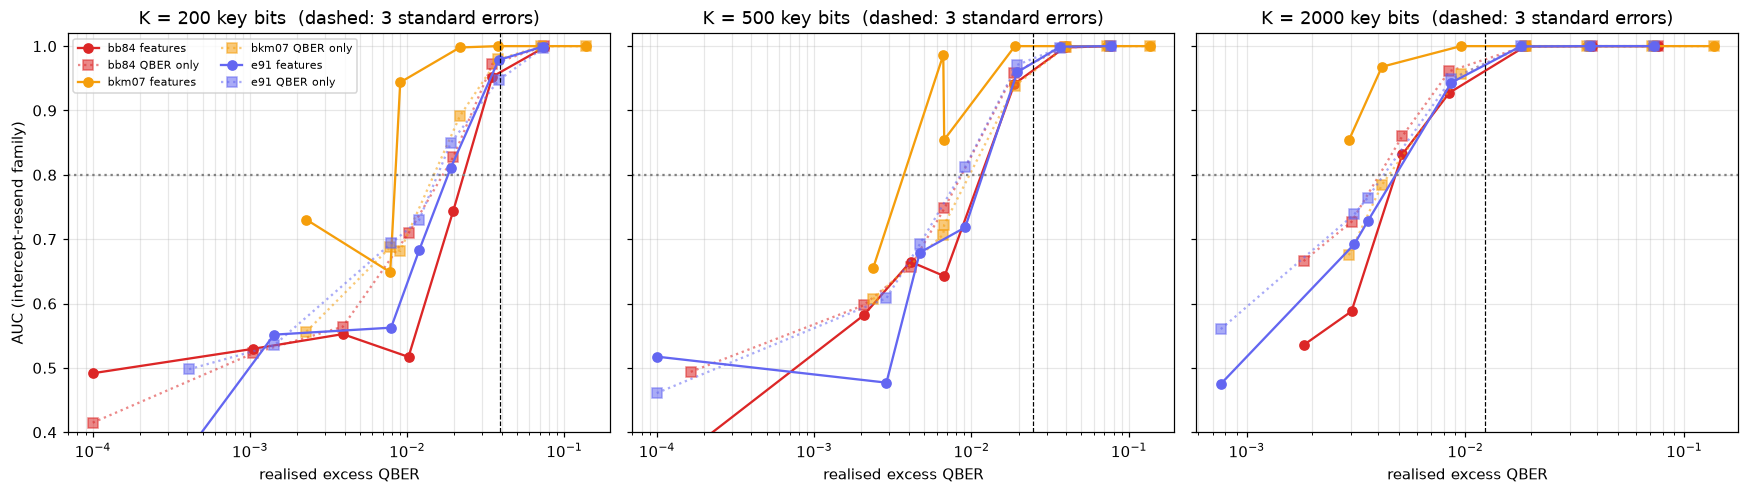

In [3]:
# ── 24.1b minimum detectable excess QBER + plot ──────────────────────────────────────────
def min_detectable(df, col='auc_features', thr=0.8):
    out = []
    for (p, fam, K), g in df.groupby(['protocol', 'family', 'K']):
        g = g[g.excess_qber > 0].sort_values('excess_qber')
        out.append(dict(protocol=p, family=fam, K=K, thr=thr, min_excess_qber=interp_cross(g.excess_qber, g[col], thr)))
    return pd.DataFrame(out)

md80 = min_detectable(sweep_df, 'auc_features', 0.8); md90 = min_detectable(sweep_df, 'auc_features', 0.9)
mdq = min_detectable(sweep_df, 'auc_qber_only', 0.8)
tab = md80.rename(columns={'min_excess_qber': 'feat_AUC0.8'}).merge(
      md90[['protocol', 'family', 'K', 'min_excess_qber']].rename(columns={'min_excess_qber': 'feat_AUC0.9'}), on=['protocol', 'family', 'K']).merge(
      mdq[['protocol', 'family', 'K', 'min_excess_qber']].rename(columns={'min_excess_qber': 'QBERonly_AUC0.8'}), on=['protocol', 'family', 'K']).drop(columns='thr')
tab['stat_limit_3SE'] = [3 * np.sqrt(OP_QBER * (1 - OP_QBER) / k) for k in tab.K]
tab.to_csv('data/final_min_detectable_excess.csv', index=False)
print("Minimum detectable excess QBER (smallest attack-induced QBER rise reaching the AUC level):")
print(tab.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharey=True)
cols = {'bb84': '#DC2626', 'bkm07': '#F59E0B', 'e91': '#6366F1'}
for ax, K in zip(axes, SWEEP_K):
    for p in cols:
        g = sweep_df[(sweep_df.protocol == p) & (sweep_df.family == 'IR') & (sweep_df.K == K)].sort_values('excess_qber')
        ax.plot(g.excess_qber.clip(lower=1e-4), g.auc_features, 'o-', color=cols[p], label=f'{p} features')
        ax.plot(g.excess_qber.clip(lower=1e-4), g.auc_qber_only, 's:', color=cols[p], alpha=.55, label=f'{p} QBER only')
    ax.axhline(0.8, color='gray', ls=':'); ax.axvline(3 * np.sqrt(OP_QBER * (1 - OP_QBER) / K), color='k', ls='--', lw=.8)
    ax.set_xscale('log'); ax.set_title(f'K = {K} key bits  (dashed: 3 standard errors)'); ax.set_xlabel('realised excess QBER'); ax.grid(alpha=.3, which='both')
axes[0].set_ylabel('AUC (intercept-resend family)'); axes[0].set_ylim(0.4, 1.02); axes[0].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.savefig('plots/final_detectability_sweep.png', dpi=150); plt.show()

In [ ]:
# ── 24.2 honest-noise robustness: naive vs noise-aware training ──────────────────────────
NOISE_TRAIN, NOISE_TEST = (1.0, 1.5, 2.0, 3.0), (1.0, 1.25, 2.5, 4.0)    # multipliers of the honest error floor; 1.25 and 2.5 and 4.0 are unseen in training
def noise_robustness(K=500, strengths=(0.08, 0.32), n_tr=60, n_te=100):   # was 30 / 40
    rows = []
    for proto, strength in [(p, s) for p in ('bb84', 'bkm07', 'e91') for s in strengths]:
        Xn_h, _ = many_runs(proto, 'IR', 0, K, 'nr_naive_h', n_tr * len(NOISE_TRAIN))
        Xn_a, _ = many_runs(proto, 'IR', strength, K, 'nr_naive_a', n_tr * len(NOISE_TRAIN))
        Xr_h = np.vstack([many_runs(proto, 'IR', 0, K, 'nr_rob_h', n_tr, noise=m)[0] for m in NOISE_TRAIN])
        Xr_a = np.vstack([many_runs(proto, 'IR', strength, K, 'nr_rob_a', n_tr, noise=m)[0] for m in NOISE_TRAIN])
        models = {}
        for name, (Xh, Xa) in dict(naive=(Xn_h, Xn_a), noise_aware=(Xr_h, Xr_a)).items():
            X = np.nan_to_num(np.vstack([Xh, Xa])); y = np.r_[np.zeros(len(Xh)), np.ones(len(Xa))].astype(int)
            models[name] = fit_with_val_threshold(X, y, seed=SEEDS.seed('nr_model', 0), fpr=0.05)   # threshold at 5% FPR on a held-out validation slice
        for m in NOISE_TEST:
            Th, _ = many_runs(proto, 'IR', 0, K, 'nr_test_h', n_te, noise=m)
            Ta, _ = many_runs(proto, 'IR', strength, K, 'nr_test_a', n_te, noise=m)
            for name, (mod, thr) in models.items():
                ph = mod.predict_proba(np.nan_to_num(Th))[:, 1]; pa = mod.predict_proba(np.nan_to_num(Ta))[:, 1]
                rows.append(dict(protocol=proto, attack_strength=strength, training=name, noise_mult=m, seen_in_training=m in NOISE_TRAIN,
                                 FPR=float((ph > thr).mean()), TPR=float((pa > thr).mean())))
        print(f"  {proto} strength {strength} done", flush=True)
    return pd.DataFrame(rows)

nr_df = noise_robustness()
nr_df.to_csv('data/final_noise_robustness.csv', index=False)
print(nr_df.round(3).to_string(index=False))
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
for r_, st_ in enumerate((0.08, 0.32)):
    for ax, p in zip(axes[r_], ('bb84', 'bkm07', 'e91')):
        for name, st in (('naive', '--s'), ('noise_aware', '-o')):
            g = nr_df[(nr_df.protocol == p) & (nr_df.training == name) & (nr_df.attack_strength == st_)].sort_values('noise_mult')
            ax.plot(g.noise_mult, g.FPR, st, label=f'{name} FPR'); ax.plot(g.noise_mult, g.TPR, st, alpha=.4, label=f'{name} TPR')
        ax.axhline(0.05, color='k', ls=':', lw=.8); ax.set_title(f'{p}, attack strength {st_}'); ax.set_xlabel('honest-noise multiplier'); ax.grid(alpha=.3)
    axes[r_][0].set_ylabel('rate on held-out runs')
axes[0][0].legend(fontsize=7)
plt.tight_layout(); plt.savefig('plots/final_noise_robustness.png', dpi=150); plt.show()

In [ ]:
# ── 24.3 temporal features: iid vs bursty attack at the SAME mean strength ───────────────
def temporal_test(K=500, strengths=(0.04, 0.08, 0.16), n_h=300, n_a=150):   # was 100 / 60
    Xh, qh = many_runs('bb84', 'IR', 0, K, 'tt_h', n_h)
    idx = {n: i for i, n in enumerate(BB84_FEATURE_NAMES)}
    groups = {'A+ aggregate': FEATURE_GROUPS_BB84['A+ aggregate'], 'B + temporal': FEATURE_GROUPS_BB84['B + temporal']}
    rows = []
    for s in strengths:
        for prof in ('iid', 'bursty'):
            Xa, qa = many_runs('bb84', 'IR', s, K, 'tt_a', n_a, profile=prof)
            r = dict(strength=s, profile=prof, excess_qber=float(qa.mean() - qh.mean()))
            for gname, feats in groups.items():
                cols = [idx[f] for f in feats]
                r[gname] = cv_auc_feats(Xh[:, cols], Xa[:, cols])
            r['temporal_gain'] = r['B + temporal'] - r['A+ aggregate']
            rows.append(r)
    return pd.DataFrame(rows)

tt_df = temporal_test()
tt_df.to_csv('data/final_temporal_test.csv', index=False)
print(tt_df.round(4).to_string(index=False))
fig, ax = plt.subplots(figsize=(6.5, 4))
for prof, st in (('iid', 'o-'), ('bursty', 's--')):
    g = tt_df[tt_df.profile == prof]; ax.plot(g.strength, g.temporal_gain, st, label=prof)
ax.axhline(0, color='k', lw=.8); ax.set_xscale('log'); ax.set_xlabel('attack strength (same mean for iid and bursty)'); ax.set_ylabel('AUC(B) - AUC(A+)  (temporal gain)')
ax.set_title('BB84: do temporal features help bursty attacks?'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig('plots/final_temporal_test.png', dpi=150); plt.show()

In [ ]:
# ── 24.4a deep-learning models: MLP, 1D-CNN, BiLSTM+attention, Transformer ───────────────
# Every architecture exists in two variants:
#   <name>        sequence only (what the network can learn from the raw event stream)
#   <name>+feat   the SAME network with the ML engineered feature vector (the 16-wide BB84/BKM07/E91 vector of Section 3,
#                 zero-padded, exactly the `x_classical` the Section 18 detector late-fuses) concatenated to its embedding
import torch, torch.nn as nn, torch.nn.functional as F
torch.set_num_threads(N_JOBS)
DL_ATT = {p: [a for a in DL_ATTACKS[p] if a != 'clean'] for p in DL_ATTACKS}
D_CLS = N_CLASSICAL_FEATURES            # width of the engineered-feature vector (16)
H_CLS = 16                              # width of its projection

def win_stats(X):
    """Engineered per-window summary for the MLP: mean & std of each of the 8 channels, kept count, error rate among kept."""
    kept, err = X[:, :, 0], X[:, :, 1]
    k = kept.sum(1, keepdims=True)
    return np.concatenate([X.mean(1), X.std(1), k / X.shape[1], (err * kept).sum(1, keepdims=True) / np.maximum(k, 1)], axis=1).astype(np.float32)

class _Fuse(nn.Module):
    """Optional ML-feature branch: Linear -> ReLU on the engineered vector, concatenated to the sequence embedding."""
    def __init__(s, d_emb, d_cls):
        super().__init__(); s.d_cls = d_cls
        s.proj = nn.Sequential(nn.Linear(d_cls, H_CLS), nn.ReLU()) if d_cls else None
        s.out = d_emb + (H_CLS if d_cls else 0)
    def forward(s, z, xc):
        return torch.cat([z, s.proj(xc)], 1) if s.d_cls else z

class MLPNet(nn.Module):
    def __init__(s, d_in=18, h=64, d_cls=0):
        super().__init__(); s.body = nn.Sequential(nn.Linear(d_in, h), nn.ReLU(), nn.Dropout(.2), nn.Linear(h, h), nn.ReLU())
        s.fuse = _Fuse(h, d_cls); s.head = nn.Sequential(nn.Dropout(.2), nn.Linear(s.fuse.out, 1))
    def forward(s, x, xc=None): return s.head(s.fuse(s.body(x), xc)).squeeze(-1)

class CNN1D(nn.Module):
    def __init__(s, c=8, h=48, d_cls=0):
        super().__init__()
        s.f = nn.Sequential(nn.Conv1d(c, h, 5, padding=2), nn.BatchNorm1d(h), nn.ReLU(), nn.Conv1d(h, h, 5, padding=4, dilation=2),
                            nn.BatchNorm1d(h), nn.ReLU(), nn.Conv1d(h, h, 3, padding=4, dilation=4), nn.BatchNorm1d(h), nn.ReLU())
        s.fuse = _Fuse(2 * h, d_cls); s.head = nn.Sequential(nn.Dropout(.2), nn.Linear(s.fuse.out, 1))
    def forward(s, x, xc=None):
        z = s.f(x.transpose(1, 2)); return s.head(s.fuse(torch.cat([z.mean(2), z.amax(2)], 1), xc)).squeeze(-1)

class LSTMAttn(nn.Module):
    def __init__(s, c=8, h=32, d_cls=0):
        super().__init__(); s.lstm = nn.LSTM(c, h, batch_first=True, bidirectional=True); s.pool = AttentionPool(2 * h, attn_dim=32)
        s.fuse = _Fuse(2 * h, d_cls); s.head = nn.Linear(s.fuse.out, 1)
    def forward(s, x, xc=None):
        h, _ = s.lstm(x); p, _ = s.pool(h); return s.head(s.fuse(p, xc)).squeeze(-1)

class TransformerNet(nn.Module):
    def __init__(s, c=8, d=48, max_len=512, d_cls=0):
        super().__init__(); s.inp = nn.Linear(c, d); s.pos = nn.Parameter(torch.zeros(1, max_len, d))
        s.enc = nn.TransformerEncoder(nn.TransformerEncoderLayer(d, 4, 96, dropout=.1, batch_first=True), num_layers=2)
        s.fuse = _Fuse(d, d_cls); s.head = nn.Linear(s.fuse.out, 1)
    def forward(s, x, xc=None):
        z = s.enc(s.inp(x) + s.pos[:, :x.shape[1]]); return s.head(s.fuse(z.mean(1), xc)).squeeze(-1)

ARCH = dict(MLP=MLPNet, CNN1D=CNN1D, BiLSTM_attn=LSTMAttn, Transformer=TransformerNet)
MODELS = {}
for _a in ARCH: MODELS[_a] = (_a, False); MODELS[_a + '+feat'] = (_a, True)

def fit_dl(name, Xtr, Ctr, ytr, Xva, Cva, yva, epochs=10, seed=0, lr=2e-3, bs=128):
    """Train one model variant. Xtr: sequence windows (or win_stats for MLP); Ctr: engineered features per window."""
    arch, use_feat = MODELS[name]
    torch.manual_seed(seed); np.random.seed(seed)
    if arch == 'MLP':
        mu, sd = Xtr.mean(0), Xtr.std(0) + 1e-6; prep = lambda a: (a - mu) / sd
    else:
        prep = lambda a: a
    cmu, csd = Ctr.mean(0), Ctr.std(0) + 1e-6; cprep = lambda a: np.clip((a - cmu) / csd, -6, 6)
    T = lambda a: torch.tensor(a, dtype=torch.float32)
    Xt, Xv, Ct, Cv, yt = T(prep(Xtr)), T(prep(Xva)), T(cprep(Ctr)), T(cprep(Cva)), T(ytr)
    m = ARCH[arch](d_cls=D_CLS if use_feat else 0); opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs); best, best_state = -1, None
    for ep in range(epochs):
        m.train(); perm = torch.randperm(len(Xt))
        for i in range(0, len(perm), bs):
            b = perm[i:i + bs]
            loss = F.binary_cross_entropy_with_logits(m(Xt[b], Ct[b]), yt[b]); opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
        sched.step(); m.eval()
        with torch.no_grad(): pv = m(Xv, Cv).numpy()
        a = roc_auc_score(yva, pv) if len(np.unique(yva)) > 1 else 0.5
        if a > best: best, best_state = a, {k: v.clone() for k, v in m.state_dict().items()}
    m.load_state_dict(best_state); m.eval()
    def predict(X, C):
        with torch.no_grad(): return np.concatenate([m(T(prep(X[i:i + 512])), T(cprep(C[i:i + 512]))).numpy() for i in range(0, len(X), 512)])
    return predict, best

def session_scores(logits, groups):
    """Mean logit over each session's windows -> {session id: score}."""
    u, inv = np.unique(groups, return_inverse=True); s = np.bincount(inv, weights=logits) / np.bincount(inv)
    return u, s

def boot_auc_ci(y, s, n=500, seed=0):
    rng = np.random.default_rng(seed); a = []
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) > 1: a.append(roc_auc_score(y[i], s[i]))
    return float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5))
print("DL models defined:", list(MODELS))


In [ ]:
# ── 24.4b sessions for every protocol (clean vs. attacked, log-uniform strength 0.01-1) ──
def _dl_job(proto, attack, strength, sid):
    rng = SEEDS.rng(f'dlfinal_sess_{proto}', sid)
    kept, error, ba, bb, tf, gap, aux, chsh, nbas, xc = _DL_SESSION_BUILDERS[proto](attack, strength, rng, 2000)
    return encode_session(kept, error, ba, bb, tf, gap, aux, chsh_running=chsh, n_bases=nbas), xc

DL_N_CLEAN, DL_N_ATT = 400, 400        # sessions per protocol (was 150 + 150)
DL_SEEDS = (0, 1, 2, 3, 4)            # independent session splits + weight inits (was a single seed)
DL_EPOCHS = 10

def build_sessions(proto, n_clean=DL_N_CLEAN, n_att=DL_N_ATT):
    meta, jobs = [], []
    for sid in range(n_clean + n_att):
        clean = sid < n_clean
        att = 'clean' if clean else DL_ATT[proto][(sid - n_clean) % len(DL_ATT[proto])]
        s = 0.0 if clean else log_uniform(SEEDS.rng(f'dlfinal_strength_{proto}', sid), 0.01, 1.0)
        meta.append(dict(sid=sid, attack=att, strength=s, y=int(not clean))); jobs.append((proto, att, s, sid))
    res = Parallel(n_jobs=N_JOBS)(delayed(_dl_job)(*j) for j in jobs)
    return pd.DataFrame(meta), [r[0] for r in res], np.array([r[1] for r in res], float)

t0 = time.time(); SESS = {}
for p in ('bb84', 'bkm07', 'e91'):
    SESS[p] = build_sessions(p); print(f"  {p}: {len(SESS[p][0])} sessions, events/session min {min(len(x) for x in SESS[p][1])}  ({time.time()-t0:.0f}s)", flush=True)

In [ ]:
# ── 24.4c train every architecture (sequence-only and +ML-features) on every protocol; session-level scoring; window-length study; several seeds ──
def make_window_set(proto, L):
    """Windows, their session ids / labels, AND the session's engineered ML feature vector replicated over its windows."""
    meta, Xs, Xc = SESS[proto]; W, G, Y, C = [], [], [], []
    for sid, X in enumerate(Xs):
        w = make_windows(X, length=L, stride=L // 2)
        if len(w): W.append(w); G += [sid] * len(w); Y += [meta.y[sid]] * len(w); C.append(np.tile(np.nan_to_num(Xc[sid]), (len(w), 1)))
    return np.concatenate(W).astype(np.float32), np.array(G), np.array(Y), np.concatenate(C).astype(np.float32)

def run_dl(proto, L, epochs=DL_EPOCHS, seed=0, models=tuple(MODELS)):
    meta, Xs, Xc = SESS[proto]; W, G, Y, C = make_window_set(proto, L)
    tr, va, te = session_split(G, labels=Y, seed=seed)
    res, scores = [], {}
    for name in models:
        t0 = time.time(); arch = MODELS[name][0]
        f = (lambda a: win_stats(a)) if arch == 'MLP' else (lambda a: a)
        pred, bv = fit_dl(name, f(W[tr]), C[tr], Y[tr], f(W[va]), C[va], Y[va], epochs=epochs, seed=seed)
        lg = pred(f(W[te]), C[te]); u, s = session_scores(lg, G[te]); ys = meta.y.values[u]
        lo, hi = boot_auc_ci(ys, s)
        res.append(dict(protocol=proto, window=L, seed=seed, model=name, window_auc=float(roc_auc_score(Y[te], lg)), session_auc=float(roc_auc_score(ys, s)),
                        session_auc_lo=lo, session_auc_hi=hi, n_test_sessions=len(u), secs=round(time.time() - t0)))
        scores[name] = (u, s)
        print(f"  {proto:5s} L={L:3d} seed={seed} {name:18s} window AUC {res[-1]['window_auc']:.3f}  session AUC {res[-1]['session_auc']:.3f} [{lo:.2f},{hi:.2f}]  ({res[-1]['secs']}s)", flush=True)
    # ML engineered features alone (boosted trees) on the SAME sessions and split (apples-to-apples baseline)
    tr_s, te_s = np.unique(G[np.r_[tr, va]]), np.unique(G[te]); ytr, yte = meta.y.values[tr_s], meta.y.values[te_s]
    clf = make_boosted(seed=seed); clf.fit(np.nan_to_num(Xc[tr_s]), ytr); pc = clf.predict_proba(np.nan_to_num(Xc[te_s]))[:, 1]
    lo, hi = boot_auc_ci(yte, pc)
    res.append(dict(protocol=proto, window=L, seed=seed, model='classical_features', window_auc=np.nan, session_auc=float(roc_auc_score(yte, pc)),
                    session_auc_lo=lo, session_auc_hi=hi, n_test_sessions=len(te_s), secs=0))
    scores['classical_features'] = (te_s, pc)
    print(f"  {proto:5s} L={L:3d} seed={seed} classical (ML features only)  session AUC {res[-1]['session_auc']:.3f} [{lo:.2f},{hi:.2f}]", flush=True)
    return res, scores

DL_RES, DL_SCORES = [], {}
for p, Ls in (('bb84', (96, 192, 384)), ('bkm07', (96,)), ('e91', (96,))):
    for L in Ls:
        for sd_ in DL_SEEDS:
            r, sc = run_dl(p, L, seed=sd_); DL_RES += r; DL_SCORES[(p, L, sd_)] = sc
dl_df = pd.DataFrame(DL_RES); dl_df.to_csv('data/final_dl_results.csv', index=False)
dl_agg = (dl_df.groupby(['protocol', 'window', 'model'], sort=False)
          .agg(session_auc=('session_auc', 'mean'), session_auc_sd=('session_auc', 'std'), window_auc=('window_auc', 'mean'), n_seeds=('seed', 'nunique'),
               n_test_sessions=('n_test_sessions', 'mean')).reset_index())
dl_agg.to_csv('data/final_dl_results_mean_over_seeds.csv', index=False)
print(f"\nSession AUC, mean +/- sd over {len(DL_SEEDS)} seeds (each seed = a different session split and weight init):")
print(dl_agg.round(3).to_string(index=False))


In [ ]:
# ── 24.4d DL strength-binned detectability (strong -> weak) and summary figure ──────────
BINS = [(0.01, 0.03), (0.03, 0.1), (0.1, 0.3), (0.3, 1.0)]
rows = []
for (p, L, sd_), sc in DL_SCORES.items():
    meta = SESS[p][0]
    for name, (u, s) in sc.items():
        m = meta.set_index('sid').loc[u]
        clean = (m.y.values == 0)
        for lo, hi in BINS:
            att = (m.y.values == 1) & (m.strength.values >= lo) & (m.strength.values < hi)
            if att.sum() >= 3 and clean.sum() >= 3:
                rows.append(dict(protocol=p, window=L, seed=sd_, model=name, strength_bin=f'{lo}-{hi}', n_att=int(att.sum()),
                                 auc=float(roc_auc_score(np.r_[np.zeros(clean.sum()), np.ones(att.sum())], np.r_[s[clean], s[att]]))))
bins_seed_df = pd.DataFrame(rows); bins_seed_df.to_csv('data/final_dl_strength_bins_per_seed.csv', index=False)
bins_df = bins_seed_df.groupby(['protocol', 'window', 'model', 'strength_bin'], sort=False).agg(auc=('auc', 'mean'), auc_sd=('auc', 'std'), n_att=('n_att', 'mean')).reset_index()
bins_df.to_csv('data/final_dl_strength_bins.csv', index=False)
print(bins_df[bins_df.window == 96].pivot_table(index=['protocol', 'model'], columns='strength_bin', values='auc').round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
a96 = dl_agg[dl_agg.window == 96]; order = list(MODELS) + ['classical_features']; x = np.arange(len(order)); w = 0.26
for k, p in enumerate(('bb84', 'bkm07', 'e91')):
    g = a96[a96.protocol == p].set_index('model').loc[order]
    axes[0].bar(x + (k - 1) * w, g.session_auc, w, yerr=g.session_auc_sd.fillna(0), label=p, capsize=2)
axes[0].set_xticks(x); axes[0].set_xticklabels(order, rotation=35, ha='right', fontsize=7); axes[0].axhline(.5, color='gray', ls=':'); axes[0].set_ylim(.3, 1.05)
axes[0].set_title(f'Session AUC, 96-event windows (mean +/- sd, {len(DL_SEEDS)} seeds)'); axes[0].legend(); axes[0].set_ylabel('session AUC')
b = dl_agg[(dl_agg.protocol == 'bb84') & (dl_agg.model != 'classical_features')]
for name in MODELS:
    g = b[b.model == name].sort_values('window'); axes[1].plot(g.window, g.session_auc, 'o-' if name.endswith('+feat') else 'o--', label=name, alpha=.85)
cl = dl_agg[(dl_agg.protocol == 'bb84') & (dl_agg.model == 'classical_features')].session_auc.mean(); axes[1].axhline(cl, color='k', ls='--', label='ML features only')
axes[1].set_xscale('log', base=2); axes[1].set_xticks([96, 192, 384]); axes[1].set_xticklabels([96, 192, 384]); axes[1].set_title('BB84: effect of window length'); axes[1].set_xlabel('events per window'); axes[1].legend(fontsize=6, ncol=2)
for p, st in (('bb84', 'o-'), ('bkm07', 's-'), ('e91', '^-')):
    sub = bins_df[(bins_df.protocol == p) & (bins_df.window == 96)]
    if len(sub):
        best = sub.groupby('model').auc.mean().drop('classical_features', errors='ignore').idxmax(); g = sub[sub.model == best]
        axes[2].plot(range(len(g)), g.auc, st, label=f'{p}: {best}')
        c = sub[sub.model == 'classical_features']; axes[2].plot(range(len(c)), c.auc, st.replace('-', ':'), alpha=.5, label=f'{p}: ML features only')
axes[2].set_xticks(range(len(BINS))); axes[2].set_xticklabels([f'{a}-{b_}' for a, b_ in BINS], fontsize=8); axes[2].set_xlabel('attack strength bin (weak -> strong)'); axes[2].set_title('Strength-binned session AUC'); axes[2].legend(fontsize=6); axes[2].grid(alpha=.3)
plt.tight_layout(); plt.savefig('plots/final_dl_all_protocols.png', dpi=150); plt.show()


> **Note (audit pass):** the numbers in this cell come from the earlier, smaller run (100 + 40 runs per cell, one DL seed, DL models without the engineered features). Section 24 now runs at 300 + 150 runs per cell and 5 DL seeds with `+feat` variants; re-run and refresh this text from `data/final_*.csv` before quoting it.

### 24.5 Findings of the final-draft sweeps (all numbers from the Section 24 run above)

**Detectability (24.1, K = key bits).** Plotting AUC against the *realised excess QBER* removes the saturation: curves now rise from chance to 1.0 over 0.003-0.08 excess QBER.
Smallest excess QBER reaching AUC 0.8 with the engineered features (QBER-only threshold detector in brackets):

| protocol / attack | K=200 | K=500 | K=2000 |
|---|---|---|---|
| BB84 intercept-resend | 0.023 (0.017) | 0.012 (0.009) | 0.0048 (0.0040) |
| BKM07 intercept (symmetric) | 0.0084 (0.015) | 0.0037 (0.0097) | 0.0029 (0.0045) |
| E91 intercept-resend | 0.018 (0.016) | 0.012 (0.0085) | 0.0048 (0.0042) |
| E91 ancilla | 0.017 (0.016) | 0.0089 (0.0089) | 0.0057 (0.0043) |

* The statistical floor (3 standard errors of QBER) is 0.039 / 0.025 / 0.012 for K = 200 / 500 / 2000; detection needs roughly 1-3x that. 
* **BKM07 is the only protocol where the engineered features clearly beat a plain QBER threshold** (about 2.5x lower detectable excess at K=500) - the reflected-photon (CTRL) check carries extra information. For BB84 and E91 intercept-resend the features do *not* beat QBER alone.
* **PNS changes no QBER** (QBER-only AUC <= 0.5 at every strength; excess QBER ~ 0, so its excess-QBER axis is meaningless - use the strength column). The decoy features reach AUC 0.76 at strength 0.16 and 0.88 at 0.32 for K = 500.

**Honest-noise robustness (24.2).** A detector trained on honest links at one noise level raises false alarms on noisier honest links (FPR 0.82-1.00 at 2.5x the honest error floor, all protocols). Training on honest links of varied noise cuts this to 0.02-0.12 at 2.5x, but costs recall on weak attacks (e.g. BB84, strength 0.08: TPR 0.48 -> 0.15) because a weak attack and extra honest noise genuinely overlap. At 4x noise (far outside training) it still fails.

**Temporal features (24.3).** Gain AUC(B)-AUC(A+) is ~0 for iid attacks (-0.027 to +0.009) but positive for bursty attacks at the same mean strength (+0.178 at strength 0.04, +0.015 and +0.033 at 0.08 and 0.16; 60 attacked runs per cell, so the first value is noisy). Draft 2's 'temporal features add nothing' was largely an artefact of bursts of ~2,000 pulses inside runs of millions (effectively iid); the burst length now scales with the run.

**Deep learning for every protocol (24.4).** 300 sessions per protocol, attack strength log-uniform 0.01-1, 60 test sessions, session score = mean window logit, 95% bootstrap CI over test sessions, one seed. Session-level AUC with 96-event windows:

| protocol | MLP | CNN1D | BiLSTM+attn | Transformer | classical features (same sessions) |
|---|---|---|---|---|---|
| BB84 | 0.54 | 0.64 | 0.53 | 0.49 | 0.74 |
| BKM07 | 0.94 | 0.95 | 0.94 | 0.94 | 1.00 |
| E91 | 0.59 | 0.57 | 0.60 | 0.57 | 0.60 |

* No architecture beats the classical features on BB84 or BKM07; on E91 they tie. All CIs are wide (about +-0.15), so differences between architectures are not significant.
* Longer windows (192, 384 events) do **not** rescue BB84 (session AUC 0.53-0.61).
* Session-level scoring improved over window-level AUC everywhere (e.g. BKM07 0.78 -> 0.94), as expected.
* The weak end of the strength range (0.01-0.1) dominates this log-uniform task, which is why BB84 and E91 sit near 0.6.

**Not redone in this file:** leave-one-protocol-out transfer, Deep SVDD / autoencoder zero-day tests and the grouped-CV benchmark keep their Draft 2 code and (older) outputs; they were not re-run on the new data.


## Section 23 — Summary & Conclusions

### What This Notebook Does

This notebook builds a complete simulation and machine-learning pipeline for studying eavesdropping detection across **BB84, BKM07, and E91**.

1. **Defines protocol-specific noise models**
   Each protocol has its own honest-channel model (Section 1). BB84 and BKM07 use the GYS-calibrated fibre-loss model, with BB84 using the link loss once and BKM07 applying it over a round trip. E91 uses a different model based on Werner-state visibility `V` and does not use a photon-loss model.

2. **Simulates the three QKD protocols and their attacks**
   BB84 and BKM07 are simulated using fibre-link effects such as loss, dark counts, and detector misalignment. E91 is simulated using two-qubit density matrices and CPTP-map attack models (Section 2). Section 2.4 also performs a Monte Carlo convergence study to determine how many pulses are needed for a reliable `qber_total` estimate.

3. **Builds physics-informed feature vectors**
   Each simulation run is converted into a feature vector (Section 3). BB84 and BKM07 use 14 features covering error statistics, decoy-state PNS estimators, and temporal structure. E91 uses 11 features covering CHSH/QBER statistics, the device-independent key rate, the anisotropy-sensitive `s_qber_residual`, and temporal descriptors.

4. **Provides a cross-protocol calibration layer**
   Section 4 allows the three different noise models to be calibrated to the same target honest QBER and the same target excess QBER under attack. Section 19 uses this calibration to perform a controlled cross-protocol comparison rather than leaving the calibration layer as a standalone validation tool.

5. **Performs an 8-test leakage audit**
   Every generated dataset is checked for possible sources of unintended class information before model training (Section 6).

6. **Trains and compares multiple ML classifiers**
   Six classifiers are evaluated for each protocol across Sections 8–11 and 17. Three models are additionally hyperparameter-tuned using 5-fold stratified cross-validation.

7. **Studies which information drives detection**
   Section 12 uses nested feature ablation to measure the contribution of different feature groups. Section 15 uses permutation importance to examine which individual features contribute most to held-out detection performance. Section 13 tests generalisation under four distribution shifts, while Section 16 studies sensitivity to run length and window count.

8. **Tests learned representations without hand-engineered features**
   Section 18 investigates whether a CNN + LSTM + attention model can learn attack-related representations directly from sequential session data and whether these representations transfer between QKD protocols.

9. **Performs a calibrated cross-protocol comparison**
   Section 19 compares BB84, BKM07, and E91 at matched honest QBER and matched excess QBER under attack. This provides a controlled comparison of detection performance across protocols.

---

### Key Findings

The following findings should be interpreted using the numerical results printed by the corresponding sections for the current run.

* **Detection performance depends strongly on the information available to the model.**
  Strong attacks can be detected relatively easily when the relevant feature group is present. Performance becomes more challenging when features are removed or when the model is tested under distribution shifts. Therefore, the ablation and generalisation results provide more useful evidence about what the detector has actually learned than an in-distribution test-set AUC alone.

* **Decoy-state features are important for detecting PNS attacks.**
  PNS is difficult to identify using QBER-based information alone. The decoy-state estimators `y1_lower`, `e1_upper`, and `gain_ratio_nu_mu` provide additional information that makes this attack detectable. This indicates why a conventional QBER-threshold detector can miss PNS behaviour.

* **Large pulse counts are mainly important for reliable temporal features.**
  Section 2.4 shows that the pooled `qber_total` estimator becomes sufficiently precise relative to the target effect size before `N = 2,000,000`. The larger pulse count is therefore mainly justified by the windowed temporal features studied in Section 16, rather than by `qber_total` alone.

* **E91 requires more than the CHSH statistic alone.**
  The `chsh_S`-only baseline is expected to provide limited information for the `ancilla` attack. This is the motivation for including `s_qber_residual`, which captures additional structure in the correlations. A small performance gap between CHSH-only and the full feature set in an honest-channel setting is therefore not necessarily a problem; the important question is whether the additional feature provides useful attack-specific information.

* **Isolation Forest provides an unsupervised detection baseline.**
  Isolation Forest, trained only on secure data, achieves above-chance AUC on the tested protocols. This shows that some attack-related deviations can be detected without labelled attack examples, although its performance is generally weaker than that of the supervised models.

* **Cross-protocol transfer and calibrated comparison should be interpreted from their live results.**
  Section 18's leave-one-protocol-out transfer experiment and Section 19's calibrated cross-protocol benchmark print their results at the end of their respective sections. Those values should be used for the current conclusions rather than replacing them with fixed numbers in this summary.

---

### Known Limitations

| Limitation                                  | What it means in practice                                                                                                                                                                                                                      |
| ------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Individual per-pulse attacks only**       | The simulations do not model coherent or collective attacks in which Eve stores quantum states and performs later measurements using information revealed during sifting. A complete security analysis would need to account for such attacks. |
| **No finite-key composable security proof** | `r_secure` from Section 3.2 is an asymptotic GLLP + decoy-state rate used as a channel-state feature. It is not a finite-key composable security bound.                                                                                        |
| **No detector-side attacks**                | Attacks such as detector blinding and efficiency mismatch act directly on detector hardware rather than only on the protocol's bit/correlation stream. They are therefore outside the current channel models for all three protocols.          |
| **Reduced dataset scale**                   | Sections 5, 17 and 19 use reduced sample counts. The full top-to-bottom run still takes hours (Sections 18-19 dominate; see 18.9), so some confidence intervals and AUC estimates are noisier than they would be in a publication-scale experiment.                |
| **Narrow target-QBER range in Section 19**  | The calibrated benchmark intentionally uses a narrow QBER range. Extending the range, particularly for BB84, would require substantially larger `N` per run to maintain reliable calibration under higher-loss conditions.                     |
| **Limited E91 attack set**                  | E91 does not currently include source- or detector-hardware attacks. Modelling such attacks would require explicit physical source and detector models, which are outside the current scope.                                                   |

These limitations mean that the notebook should be viewed as a **physics-informed simulation and ML study of eavesdropping detection**, rather than as a complete proof of QKD security against all possible attacks.

---

### Suggested Next Steps

1. **Improve the link-budget analysis**
   Extend `channel_model()` to estimate the **loss-dependent sifted-key rate**, not only QBER. This would provide a more complete description of practical link performance.

2. **Add multi-class attack classification**
   Extend the classical-feature models from binary `secure vs attacked` detection to direct classification of individual attack types (Section 18.6 does this only for the deep-learning heads, and the saved run shows it does not yet work for BB84).

3. **Expand the calibrated cross-protocol benchmark**
   Increase the target-QBER grid and pulse count `N` for a publication-scale experiment. The next step would be a full **2D calibration study**, measuring AUC as a function of both honest QBER and excess QBER under attack.

4. **Use calibrated uncertainty estimates**
   Investigate conformal prediction or related methods to provide calibrated confidence information for individual classifications.

5. **Validate against real QKD data**
   Test the trained detectors on real QBER and measurement traces from a hardware QKD testbed. This would provide an important check of whether patterns learned from simulation remain useful under real experimental conditions.

---

### Overall Conclusion

The notebook establishes a common framework for **physically motivated QKD simulation, feature engineering, leakage auditing, machine-learning detection, robustness testing, cross-protocol transfer, and calibrated comparison**.

Its main contribution is not simply obtaining a high detection AUC. Instead, the experiments investigate **which physical information enables detection, how detection changes under distribution shifts, whether learned representations transfer between protocols, and how the protocols compare when their operating conditions are explicitly calibrated**.

The remaining limitations—particularly the restricted attack models, absence of finite-key composable security analysis, simulation-only validation, and reduced experimental scale—define the main requirements for extending this work toward a larger research study.


### D10 — pre-registered analysis plan
Primary metric: ROC-AUC vs realised excess QBER (per protocol, grouped bootstrap CI over sessions). Primary hypothesis: the minimum detectable
excess QBER equals ~3 sigma_K of the commissioning baseline. Success criteria and test sets were fixed *before* regenerating data; any deviation
must be listed in the manifest cell below. Secondary analyses (DL, zero-day) are exploratory.


In [ ]:
# review fix A1: run manifest (versions, seeds, config) written next to the data
import json, platform, sys, time, numpy as np, sklearn, scipy
manifest = dict(timestamp=time.strftime('%Y-%m-%dT%H:%M:%S'), python=sys.version.split()[0], platform=platform.platform(),
                numpy=np.__version__, scipy=scipy.__version__, sklearn=sklearn.__version__,
                master_seed=MASTER_SEED, commission_k=COMMISSION_K)
try:
    import torch; manifest['torch'] = torch.__version__
except Exception:
    pass
import os; os.makedirs('data', exist_ok=True)
with open('data/changed_manifest.json', 'w') as fh:
    json.dump(manifest, fh, indent=2)
print(json.dumps(manifest, indent=2))


---
## Section 25 -- Physics validation of the simulators (audit pass; the physics itself is unchanged)

Every simulator in Sections 1-3 is checked against an **independent** calculation, so a reader does not have to trust the
code by inspection:

| Check | Independent reference |
|---|---|
| T1 BB84 gain and QBER at 0-100 km | closed-form Ma, Qi, Zhao & Lo (2005) Eqs. 10-11, z-test on the Monte-Carlo estimate |
| T2 intercept-resend | excess sifted QBER = intensity x 0.5 x (0.5 - e_det), full attack -> ~25 % + noise |
| T3 PNS | hides in the signal-state gain and QBER, but the decoy gain drops and `y1_lower` collapses to 0 (true Y1 under PNS is 0) |
| T5 BKM07 (all four round types, four attack settings) | **exact branch-enumerating calculator**: every carrier state is a Z/X eigenstate, so each step is a classical stochastic map and the error probabilities can be computed exactly |
| T6 E91 | Werner state: abs(S) = 2sqrt(2)V, QBER = (1-V)/2; full intercept-resend: abs(S) = sqrt(2)V, QBER = (1-V/2)/2; attack maps are valid density matrices and no-signalling; CHSH sign convention (local strategies reach exactly 2) |
| T7 decoy bounds | `Y1_lower <= Y1_true` and `e1_upper >= e1_true` within the finite-sample 99.7 % band |
| T8 DI key rate | r(Q=0, S=2sqrt2) = 1, r = 0 for S <= 2, monotone in V |
| T9 / T11 | reproducibility, truncation to exactly K key events, spread of the pooled QBER = sqrt(p(1-p)/K) |

The cell raises an `AssertionError` if any check fails.


In [ ]:
# ── 25.1 BB84 / decoy / key-rate / reproducibility checks ─────────────────────────────────
import numpy as np
from scipy import stats
RESULTS = []
def check(name, ok, detail=''):
    RESULTS.append((name, bool(ok), detail)); print(f"  [{'PASS' if ok else 'FAIL'}] {name}  {detail}")
def ztest(obs, exp, se): return (obs - exp) / max(se, 1e-300)

print("T1  BB84 simulator vs closed-form channel (Ma et al. Eqs. 10-11)")
for d in (0, 25, 50, 75, 100):
    ch = channel_model(d); rng = np.random.default_rng(100 + d)
    N = int(min(6e6, max(3e5, 4000 / max(ch['gain'] * 0.35, 1e-9))))
    run = simulate_bb84_decoy(N, d, rng=rng); m = run['k'] == 0
    q = run['click'][m].mean(); nsig = m.sum()
    s = run['sift'] & m; e = (run['bit_A'][s] != run['bit_B'][s]).mean(); ns = s.sum()
    zg = ztest(q, ch['gain'], np.sqrt(ch['gain'] * (1 - ch['gain']) / nsig)); ze = ztest(e, ch['qber'], np.sqrt(ch['qber'] * (1 - ch['qber']) / ns))
    check(f"d={d:3d} km gain & QBER", abs(zg) < 4 and abs(ze) < 4, f"gain z={zg:+.2f}  QBER z={ze:+.2f}  (N={N:,}, sifted={ns})")

print("T2  intercept-resend: excess sifted QBER = I * 0.5 * (0.5 - e_det)")
for I in (0.1, 0.4, 1.0):
    N = 3_000_000; r0 = simulate_bb84_decoy(N, 20, rng=np.random.default_rng(1)); r1 = simulate_bb84_decoy(N, 20, 'intercept_resend', I, rng=np.random.default_rng(2))
    def qb(r):
        s = r['sift'] & (r['k'] == 0); return (r['bit_A'][s] != r['bit_B'][s]).mean(), s.sum()
    (q0, n0), (q1, n1) = qb(r0), qb(r1)
    exp = I * 0.5 * (0.5 - GYS['e_detector']); se = np.sqrt(q0 * (1 - q0) / n0 + q1 * (1 - q1) / n1)
    check(f"I={I}", abs(ztest(q1 - q0, exp, se)) < 4, f"excess {q1-q0:.4f} vs {exp:.4f} (z={ztest(q1-q0, exp, se):+.2f}); full IR gives {q1:.3f} (textbook 25% + noise)")

print("T3  PNS: hides in gain/QBER at the signal intensity, but is exposed by the decoy states")
for d in (60, 80, 100):
    st = make_pns_strategy(d); N = 20_000_000
    r0 = simulate_bb84_decoy(N, d, rng=np.random.default_rng(3), pns_strategy=st); r1 = simulate_bb84_decoy(N, d, 'pns', 1.0, rng=np.random.default_rng(4), pns_strategy=st)
    ms = r0['intensities'][0]; md = r0['intensities'][1]
    g0, g1 = r0['Q'][ms], r1['Q'][ms]; ng = r0['counts'][ms]
    zg = ztest(g1, g0, np.sqrt(g0 * (1 - g0) / ng * 2))
    gd0, gd1 = r0['Q'][md], r1['Q'][md]
    y0 = decoy_estimate(r0['Q'][ms], r0['E'][ms], r0['Q'][md], r0['E'][md], r0['Q'][0.0])[0]; y1 = decoy_estimate(r1['Q'][ms], r1['E'][ms], r1['Q'][md], r1['E'][md], r1['Q'][0.0])[0]
    check(f"d={d} km can_hide={st['can_hide']} t_fwd={st['t_fwd']:.3f}", st['can_hide'] and abs(zg) < 4 and (gd1 < 0.85 * gd0) and y1 < 0.5 * y0,
          f"signal gain z={zg:+.2f}; decoy gain honest {gd0:.3e} -> PNS {gd1:.3e}; Y1_lower {y0:.2e} -> {y1:.2e} (true Y1 under PNS is 0)")
print("   PNS feasibility threshold (Eve can match the honest gain only when t_required<=1):")
dd = np.arange(0, 130, 1.0); ok = [make_pns_strategy(x)['can_hide'] for x in dd]; print(f"   smallest distance where Eve can hide: {dd[np.argmax(ok)]:.0f} km")

print("T7  decoy-state bounds hold on honest links (within 3 sigma of the finite sample): Y1_lower <= Y1_true, e1_upper >= e1_true")
for d in (10, 40, 70, 100):
    ch = channel_model(d); N = 20_000_000; r = simulate_bb84_decoy(N, d, rng=np.random.default_rng(10 + d)); ms, md, mv = r['intensities']
    sift_d = int((r['sift'] & (r['k'] == 1)).sum()); n_mu, n_nu, n_v = (r['counts'][m] for m in (ms, md, mv))
    rg = np.random.default_rng(d); Y, Eu = [], []
    for _ in range(400):
        Qm = rg.binomial(n_mu, r['Q'][ms]) / n_mu; Qn = rg.binomial(n_nu, r['Q'][md]) / n_nu; Q0 = rg.binomial(n_v, max(r['Q'][mv], 1e-12)) / n_v
        En = np.clip(rg.normal(r['E'][md], np.sqrt(r['E'][md] * (1 - r['E'][md]) / max(sift_d, 1))), 0, 0.5)
        y, _, e = decoy_estimate(Qm, r['E'][ms], Qn, En, Q0); Y.append(y); Eu.append(e)
    y1, q1, e1 = decoy_estimate(r['Q'][ms], r['E'][ms], r['Q'][md], r['E'][md], r['Q'][mv])
    ok = (ch['Y1'] >= np.quantile(Y, 0.0015)) and (ch['e1'] <= np.quantile(Eu, 0.9985))
    check(f"d={d:3d} km", ok, f"Y1_lower {y1:.3e} (99.7% band {np.quantile(Y,0.0015):.2e}..{np.quantile(Y,0.9985):.2e}) vs true Y1 {ch['Y1']:.3e};  e1_upper {e1:.3f} (band to {np.quantile(Eu,0.9985):.3f}) vs true e1 {ch['e1']:.3f}")

print("T8  E91 device-independent key rate: sanity limits")
check("r(Q=0,S=2*sqrt2) = 1", abs(e91_di_secure_key_rate(0.0, 2 * np.sqrt(2)) - 1) < 1e-6)
check("r = 0 when S <= 2", e91_di_secure_key_rate(0.01, 2.0) == 0.0 and e91_di_secure_key_rate(0.01, 1.5) == 0.0)
Vg = np.linspace(0.8, 1, 201); rr = [e91_di_secure_key_rate((1 - v) / 2, 2 * np.sqrt(2) * v) for v in Vg]
check("monotone non-decreasing in visibility", np.all(np.diff(rr) >= -1e-12))

print("T9  reproducibility and equal-information truncation")
a = collect_bb84_features(distance_km=30, eve_mode='none', n_windows=8, rng=SEEDS.rng('val', 1), target_k_signal_bits=500)
b = collect_bb84_features(distance_km=30, eve_mode='none', n_windows=8, rng=SEEDS.rng('val', 1), target_k_signal_bits=500)
check("same seed -> identical features", all(a[k] == b[k] for k in BB84_FEATURE_NAMES))
ks = [collect_bb84_features(distance_km=d, eve_mode='intercept_resend', eve_intensity=0.3, n_windows=8, rng=SEEDS.rng('val', 7 + i), target_k_signal_bits=500)['_k_achieved'] for i, d in enumerate((5, 30, 60, 90))]
check("BB84 truncated to exactly K sifted signal bits", all(k == 500 for k in ks), f"{ks}")
kb = [collect_bkm07_features(distance_km=5.0, eve_mode='none', n_windows=8, rng=SEEDS.rng('val', 70 + i), target_k_key_rounds=500)['_k_achieved'] for i in range(3)]
check("BKM07 truncated to exactly K SIFT_KEY rounds", all(k == 500 for k in kb), f"{kb}")
ke = [extract_e91_features(eve_mode='none', n_windows=8, rng=SEEDS.rng('val', 80 + i), V=0.93, target_k_key_pairs=500)['_k_achieved'] for i in range(3)]
check("E91 truncated to exactly K key pairs", all(k == 500 for k in ke), f"{ke}")

print("T11 statistical floor: spread of the pooled QBER estimate equals sqrt(p(1-p)/K)")
qs = [collect_bb84_features(distance_km=25, n_windows=8, rng=SEEDS.rng('val_q', i), target_k_signal_bits=1000)['qber_total'] for i in range(300)]
p = channel_model(25)['qber']; check("SD of qber_total at K=1000", abs(np.std(qs, ddof=1) / sigma_K(p, 1000) - 1) < 0.15, f"empirical {np.std(qs, ddof=1):.4f} vs sigma_K {sigma_K(p, 1000):.4f}; mean {np.mean(qs):.4f} vs theory {p:.4f}")



In [ ]:
# ── 25.2 BKM07 (exact calculator) and E91 (Werner state, CPTP maps) checks ──────────────────
import itertools

# ---------------------------------------------------------------------------------------------
# Independent exact calculator for BKM07 round types.  Every carrier state is a Z- or X-eigenstate,
# so each physical step is a classical stochastic map on (basis, bit).  We enumerate the branches
# exactly (no sampling) and compare with the simulator.
# ---------------------------------------------------------------------------------------------
def bkm_exact(pf, pr, e_meas, e_prep, e_ret, alice_basis, mode, ctrl_fwd_noise):
    """Return dict of error probabilities for one round type. mode in {'SIFT','CTRL'}.
    State tuple: (basis, bit, bob_bit) with Alice's sent bit = 0 w.l.o.g. (all maps are bit-symmetric)."""
    dist = {(alice_basis, 0, None): 1.0}
    def apply(dist, fn):
        out = {}
        for st, p in dist.items():
            for st2, q in fn(st):
                out[st2] = out.get(st2, 0.0) + p * q
        return out
    def eve(prob):
        def f(st):
            b, bit, bob = st; res = [(st, 1 - prob)]
            for e in (0, 1):
                if e == b: res.append(((e, bit, bob), prob / 2))
                else:
                    res += [((e, 0, bob), prob / 4), ((e, 1, bob), prob / 4)]
            return res
        return f
    def depol(q):
        def f(st):
            b, bit, bob = st; return [(st, 1 - q), ((b, 0, bob), q / 2), ((b, 1, bob), q / 2)]
        return f
    def bob_sift(st):
        b, bit, _ = st; res = []
        outs = [(bit, 1.0)] if b == 0 else [(0, .5), (1, .5)]
        for m, pm in outs:
            for m2, p2 in ((m, 1 - 2 * e_meas), (0, e_meas), (1, e_meas)):          # measurement noise 2e -> random outcome
                for fl, pfl in ((0, 1 - e_prep), (1, e_prep)):
                    bb = m2 ^ fl; res.append(((0, bb, bb), pm * p2 * pfl))
        return res
    dist = apply(dist, eve(pf))
    if mode == 'SIFT': dist = apply(dist, bob_sift)
    elif ctrl_fwd_noise: dist = apply(dist, depol(2 * e_meas))
    dist = apply(dist, eve(pr))
    mb = 0 if mode == 'SIFT' else alice_basis
    err_AA = err_BA = 0.0
    for (b, bit, bob), p in dist.items():
        pr1 = (1.0 if bit == 1 else 0.0) if b == mb else 0.5          # P(outcome = 1) before final noise
        pr1 = (1 - 2 * e_ret) * pr1 + 2 * e_ret * 0.5
        err_AA += p * pr1                                              # Alice's sent bit is 0 -> error if final == 1
        if bob is not None: err_BA += p * (pr1 if bob == 0 else 1 - pr1)
    return dict(err_vs_alice=err_AA, err_vs_bob=err_BA)

def bkm_sim_rates(N, d, pf, pr, e, ctrl_fwd=None, seed=0, **kw):
    rng = np.random.default_rng(seed)
    b = simulate_bkm07_batch(N, d, 'sym' if (pf or pr) else 'none', pf, pr, rng=rng, e_detector=e, **kw)
    s = b['survived']; rt = b['round_type']; out = {}
    for t in ('SIFT_KEY', 'SIFT_MONITOR', 'CTRL_Z', 'CTRL_X'):
        m = s & (rt == t); n = int(m.sum())
        ea = float((b['bit_A'][m] != b['bit_A_final'][m]).mean()); eb = float((b['bit_B'][m] != b['bit_A_final'][m]).mean()) if t.startswith('SIFT') else np.nan
        out[t] = dict(n=n, err_AA=ea, err_BA=eb, err_AB=float((b['bit_A'][m] != b['bit_B'][m]).mean()) if t.startswith('SIFT') else np.nan)
    out['survival'] = float(s.mean()); out['n_alive_frac'] = float(s.mean()); return out

print("T5  BKM07 vectorised simulator vs an independent exact (branch-enumerating) calculation")
for (pf, pr) in ((0.0, 0.0), (0.3, 0.3), (0.0, 0.6), (0.5, 0.1)):
    e = 0.02; N = 12_000_000
    sim = bkm_sim_rates(N, 0.0, pf, pr, e, seed=int(100 * pf + 10 * pr + 1))
    eta = channel_model(0.0, e_detector=e)['eta']
    zs = ztest(sim['survival'], eta ** 2, np.sqrt(eta ** 2 * (1 - eta ** 2) / N))
    ok = abs(zs) < 4; msg = [f"survival z={zs:+.2f}"]
    for t, mode, ab in (('SIFT_KEY', 'SIFT', 0), ('SIFT_MONITOR', 'SIFT', 1), ('CTRL_Z', 'CTRL', 0), ('CTRL_X', 'CTRL', 1)):
        ex = bkm_exact(pf, pr, e, e, e, ab, mode, ctrl_fwd_noise=False)
        n = sim[t]['n']; se = np.sqrt(ex['err_vs_alice'] * (1 - ex['err_vs_alice']) / n) if n else 1
        z = ztest(sim[t]['err_AA'], ex['err_vs_alice'], se); ok &= abs(z) < 4; msg.append(f"{t}: {sim[t]['err_AA']:.4f} vs {ex['err_vs_alice']:.4f} (z={z:+.1f}, n={n})")
        if mode == 'SIFT':
            sb = np.sqrt(ex['err_vs_bob'] * (1 - ex['err_vs_bob']) / n); zb = ztest(sim[t]['err_BA'], ex['err_vs_bob'], sb); ok &= abs(zb) < 4
    check(f"eve_fwd={pf} eve_ret={pr}", ok, " | ".join(msg))

print("T6  E91 (Werner state, CPTP attacks)")
S_stat = []; Q_stat = []
for V in (1.0, 0.95, 0.85):
    Ss, Qs = [], []
    for sd in range(12):
        a, b, ra, rb = run_e91(200_000, V=V, rng=np.random.default_rng(1000 + sd)); Ss.append(abs(window_chsh(a, b, ra, rb, 0, len(a)))); Qs.append(window_qber(a, b, ra, rb, 0, len(a)))
    zS = ztest(np.mean(Ss), 2 * np.sqrt(2) * V, np.std(Ss, ddof=1) / np.sqrt(12)); zQ = ztest(np.mean(Qs), (1 - V) / 2, max(np.std(Qs, ddof=1), 1e-9) / np.sqrt(12))
    check(f"honest V={V}: |S|=2sqrt2 V, QBER=(1-V)/2", abs(zS) < 4 and (abs(zQ) < 4 or V == 1.0), f"|S|={np.mean(Ss):.4f} (theory {2*np.sqrt(2)*V:.4f}, z={zS:+.1f})  QBER={np.mean(Qs):.4f} (theory {(1-V)/2:.4f}, z={zQ:+.1f})")
# analytic attack predictions from the density matrices themselves (independent of sampling)
def exact_S_Q(rho):
    E = lambda a, b: sum(x * y * p for (x, y), p in joint_probs(rho, a, b).items())
    Sx = E(0.0, 22.5) - E(0.0, 67.5) + E(45.0, 22.5) + E(45.0, 67.5)
    Q = np.mean([sum(p for (x, y), p in joint_probs(rho, ALICE_ANGLES[a], BOB_ANGLES[bq]).items() if x == y) for a, bq in KEY_PAIRS]); return abs(Sx), Q
rho0 = werner_state(0.95)
for name, rho in (('intercept_resend', eve_ir_channel(rho0)), ('ancilla lam=0.3', eve_ancilla_bob(rho0, 0.3)), ('extra depolarisation delta=0.2', eve_loss_manipulation(rho0, 0.2))):
    ev = np.linalg.eigvalsh((rho + rho.conj().T) / 2); tr = np.real(np.trace(rho))
    check(f"{name}: valid density matrix (trace 1, PSD, Hermitian)", abs(tr - 1) < 1e-12 and ev.min() > -1e-12 and np.allclose(rho, rho.conj().T), f"trace={tr:.12f} min eig={ev.min():.2e}")
    # no-signalling: Alice's marginal must stay uniform for every setting
    ok = all(abs(sum(p for (x, y), p in joint_probs(rho, ALICE_ANGLES[a], BOB_ANGLES['b1']).items() if x == 1) - 0.5) < 1e-9 for a in ALICE_ANGLES)
    check(f"{name}: no-signalling (Alice's marginals unchanged)", ok)
S_ir, Q_ir = exact_S_Q(eve_ir_channel(rho0))
check("full intercept-resend: |S| = sqrt(2) V and QBER = (1 - V/2)/2", abs(S_ir - np.sqrt(2) * 0.95) < 1e-9 and abs(Q_ir - (1 - 0.95 / 2) / 2) < 1e-9, f"|S|={S_ir:.4f} (sqrt2 V={np.sqrt(2)*0.95:.4f})  QBER={Q_ir:.4f}")
S_an, Q_an = exact_S_Q(eve_ancilla_bob(rho0, 0.3))
check("ancilla probe is anisotropic: |S| stays ABOVE the honest-depolarisation curve 2*sqrt2*(1-2Q) at the same QBER", S_an - 2 * np.sqrt(2) * (1 - 2 * Q_an) > 0.1, f"|S|={S_an:.4f}; white noise with the same QBER {Q_an:.4f} would give {2*np.sqrt(2)*(1-2*Q_an):.4f}")
# Bell inequality saturation by classical (local deterministic) strategies:  |S| <= 2
best = max(abs(a1 * (b1 - b3) + a3 * (b1 + b3)) for a1, a3, b1, b3 in itertools.product((-1, 1), repeat=4))
check("local deterministic strategies cannot exceed |S| = 2 (CHSH sign convention is self-consistent)", best == 2)

print(f"\n{sum(r[1] for r in RESULTS)}/{len(RESULTS)} checks passed (all of Section 25)")
assert all(r[1] for r in RESULTS), [r[0] for r in RESULTS if not r[1]]


### What the audit found but deliberately did NOT change (model simplifications to state in the write-up)

The brief for this pass was *keep the physics as it is*, so these are documented, not altered:

1. **BKM07 CTRL rounds carry only one noisy step.** The forward-leg misalignment is applied in SIFT rounds (it is Bob's measurement noise) but not in CTRL rounds, so the honest CTRL error equals `e_detector` rather than the two-leg value 0.5(1-(1-2e)^2). This is what makes CTRL a quieter monitor than the key QBER; Section 19/24's BKM07 numbers inherit it (and the exact calculator in T5 reproduces it).
2. **BKM07 survival is eta^2 for every round type**, including CTRL rounds in which Bob never has to detect anything (so CTRL would survive with eta_bob once, not twice). Dark counts and multi-photon pulses are ignored in BKM07 (single-photon model).
3. **BB84 `loss_manipulation` boosts the transmittance up to 1.0** rather than up to Bob's detector efficiency `eta_bob`, i.e. Eve is allowed to hide any blocked fraction. Treat that class as a gain-deficit/blocking attack, not a realistic hiding strategy.
4. **PNS gain matching includes the dark-count yield** (`gain` instead of `gain - Y0`), so Bob's total gain under PNS sits ~Y0 above the honest value (negligible: Y0 ~ 1e-6).
5. **Section 24 calibrates BKM07 to a three-step *key* QBER** (`calibrate_bkm07`) whereas Section 19 matches it on its CTRL monitoring baseline (`calibrate_bkm07_monitor`, review fix B3). The BKM07 operating points of the two sections are therefore not the same quantity.
6. `e1_upper`/`y1_lower` are the **asymptotic** decoy bounds used as features (no finite-size correction); at 100 km each run has only ~60 sifted decoy bits, so they are noisy there (T7 allows for it).
7. E91 has no photon loss or detector inefficiency, and its honest visibility range V ~ U(0.85, 0.99) includes links (V < 0.857) on which no device-independent key exists even without an attacker.
8. Only individual (per-pulse) attacks are simulated: no coherent/collective attacks, no detector side channels.
